In [1]:
pip install -U "pillow<11.0" torchvision transformers accelerate opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 60.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 103.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 3.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 103.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 19.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.1 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import cv2
import json
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForVision2Seq

print("=== STEP 1: Loading 5 Smoke Test Samples from VizWiz ===")
# Pulling validation split from VizWiz-VQA via Hugging Face
dataset = load_dataset("gezMu/vizwiz", split="validation", streaming=True)

smoke_samples = []
for item in dataset:
    if item["image"] is not None and item["question"] is not None:
        smoke_samples.append({
            "image_id": f"vizwiz_smoke_{len(smoke_samples):03d}",
            "image": item["image"].convert("RGB"),
            "question": item["question"]
        })
    if len(smoke_samples) >= 5:
        break

print(f"Successfully loaded {len(smoke_samples)} smoke test images.")


print("\n=== STEP 2: Defining OpenCV Distortion Engine ===")
def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1) # Note: imdecode returns BGR, let's keep it safe
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np


print("\n=== STEP 3: Running Smoke Test Inference with Qwen2-VL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForVision2Seq.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")

os.makedirs("./outputs", exist_ok=True)

evaluated_count = 0
for sample in smoke_samples:
    img_np = np.array(sample["image"])
    print(f"\nProcessing {sample['image_id']} | Question: '{sample['question']}'")
    
    # Testing clean and one compound distortion for this smoke test
    test_subset = ["clean", "compound_blur3_jpeg3"]
    for cond in test_subset:
        distorted_np = apply_distortion(img_np, cond)
        distorted_pil = Image.fromarray(distorted_np)

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": distorted_pil},
                {"type": "text", "text": sample["question"]}
            ]
        }]
        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=20, do_sample=False)
        
        input_token_len = inputs["input_ids"].shape[1]
        prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
        
        print(f"   [{cond}] -> Prediction: '{prediction}'")
        evaluated_count += 1

print(f"\n✨ Smoke test successfully finished! Evaluated {evaluated_count} test steps without errors.")

ModuleNotFoundError: Could not import module 'AutoProcessor'. Are this object's requirements defined correctly?

In [3]:
pip uninstall -y torchaudio

Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121
!pip install transformers==4.42.4 accelerate datasets opencv-python "pillow<11.0"

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
!pip install -U "transformers>=4.45.0" accelerate datasets opencv-python "pillow<11.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 88.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 24.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 82.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 

In [4]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 39.9 MB/s eta 0:00:00:00:0100:01


In [2]:
!pip install -U "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 44.5 MB/s eta 0:00:00:00:0100:01


In [4]:
!pip install -U "bitsandbytes>=0.46.1"

In [1]:
import os
import cv2
import json
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig

print("=== STEP 1: Loading 5 Smoke Test Samples from VizWiz ===")
# Loading validation split using the correct split name 'val'
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

smoke_samples = []
for item in dataset:
    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    
    if img is not None and question is not None:
        if isinstance(img, str):
            img = Image.open(img)
        smoke_samples.append({
            "image_id": f"vizwiz_smoke_{len(smoke_samples):03d}",
            "image": img.convert("RGB"),
            "question": question
        })
    if len(smoke_samples) >= 5:
        break

print(f"Successfully loaded {len(smoke_samples)} smoke test images.")


print("\n=== STEP 2: Defining OpenCV Distortion Engine ===")
def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np


print("\n=== STEP 3: Running Quantized Smoke Test Inference with Qwen2-VL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

# Set up 4-bit quantization to fit safely in T4 GPU VRAM
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    quantization_config=quantization_config,
    device_map="auto"
)

os.makedirs("./outputs", exist_ok=True)

evaluated_count = 0
for sample in smoke_samples:
    img_np = np.array(sample["image"])
    print(f"\nProcessing {sample['image_id']} | Question: '{sample['question']}'")
    
    test_subset = ["clean", "compound_blur3_jpeg3"]
    for cond in test_subset:
        distorted_np = apply_distortion(img_np, cond)
        distorted_pil = Image.fromarray(distorted_np)

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": distorted_pil},
                {"type": "text", "text": sample["question"]}
            ]
        }]
        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=20, do_sample=False)
        
        input_token_len = inputs["input_ids"].shape[1]
        prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
        
        print(f"   [{cond}] -> Prediction: '{prediction}'")
        evaluated_count += 1

print(f"\n✨ Smoke test successfully finished! Evaluated {evaluated_count} test steps without errors.")

=== STEP 1: Loading 5 Smoke Test Samples from VizWiz ===


README.md: 0.00B [00:00, ?B/s]

Successfully loaded 5 smoke test images.

=== STEP 2: Defining OpenCV Distortion Engine ===

=== STEP 3: Running Quantized Smoke Test Inference with Qwen2-VL ===


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

In [2]:
import bitsandbytes as bnb
print("Successfully imported bitsandbytes version:", bnb.__version__)

ModuleNotFoundError: No module named 'bitsandbytes'

In [3]:
!pip install --force-reinstall bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 45.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 95.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 32.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 112.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 20.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━

In [4]:
# 1. Revert back to your original stable PyTorch/CUDA stack
!pip install -q torch==2.10.0+cu128 torchvision==0.25.0+cu128 torchaudio==2.10.0 --extra-index-url https://download.pytorch.org/whl/cu128

# 2. Install a compatible bitsandbytes version using --no-deps so it can't alter your PyTorch installation
!pip install -q bitsandbytes==0.45.0 --no-deps

print("Environment repaired! You can now run your smoke test.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 916.9/916.9 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 10.2 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 29.4 MB/s eta 0:00:00:00:0100:01
Environment repaired! You can now run your smoke test.


In [1]:
import os
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

print("=== STEP 1: Loading 5 Smoke Test Samples from VizWiz ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

smoke_samples = []
for item in dataset:
    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    
    if img is not None and question is not None:
        if isinstance(img, str):
            img = Image.open(img)
        smoke_samples.append({
            "image_id": f"vizwiz_smoke_{len(smoke_samples):03d}",
            "image": img.convert("RGB"),
            "question": question
        })
    if len(smoke_samples) >= 5:
        break

print(f"Successfully loaded {len(smoke_samples)} smoke test images.")


print("\n=== STEP 2: Defining OpenCV Distortion Engine ===")
def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np


print("\n=== STEP 3: Defining OOM-Prevention Image Resizer ===")
def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== STEP 4: Loading Model Natively in bfloat16 ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

# Loaded using native bfloat16 to skip bitsandbytes completely
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.bfloat16,
    device_map="auto"
)


print("\n=== STEP 5: Running Smoke Test Inference ===")
os.makedirs("./outputs", exist_ok=True)

evaluated_count = 0
for sample in smoke_samples:
    img_np = np.array(sample["image"])
    print(f"\nProcessing {sample['image_id']} | Question: '{sample['question']}'")
    
    test_subset = ["clean", "compound_blur3_jpeg3"]
    for cond in test_subset:
        distorted_np = apply_distortion(img_np, cond)
        distorted_pil = Image.fromarray(distorted_np)
        
        # Resize to prevent token explosion and CUDA OOM
        distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": distorted_pil},
                {"type": "text", "text": sample["question"]}
            ]
        }]
        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=20, do_sample=False)
        
        input_token_len = inputs["input_ids"].shape[1]
        prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
        
        print(f"   [{cond}] -> Prediction: '{prediction}'")
        evaluated_count += 1
        
        # Clean up VRAM cache per iteration
        torch.cuda.empty_cache()
        gc.collect()

print(f"\n✨ Smoke test successfully finished! Evaluated {evaluated_count} test steps.")

=== STEP 1: Loading 5 Smoke Test Samples from VizWiz ===


README.md: 0.00B [00:00, ?B/s]

Successfully loaded 5 smoke test images.

=== STEP 2: Defining OpenCV Distortion Engine ===

=== STEP 3: Defining OOM-Prevention Image Resizer ===

=== STEP 4: Loading Model Natively in bfloat16 ===


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=== STEP 5: Running Smoke Test Inference ===

Processing vizwiz_smoke_000 | Question: 'Ok. There is another picture I hope it is a better one.'
   [clean] -> Prediction: 'The image shows a computer screen displaying a message that reads, "Cannot repair this computer automatically." The'
   [compound_blur3_jpeg3] -> Prediction: 'I'm sorry, but I can't see the second picture you're referring to. Could you please'

Processing vizwiz_smoke_001 | Question: 'Can you tell me what this medicine is please?'
   [clean] -> Prediction: 'The medicine in the picture is "DayQuil" and "NightQuil." These are brands'
   [compound_blur3_jpeg3] -> Prediction: 'I'm sorry, but I cannot identify the medicine in the picture. The image is too blurry and'

Processing vizwiz_smoke_002 | Question: 'What is the title of this book? '
   [clean] -> Prediction: 'The title of the book is "Dog Years: A Memoir."'
   [compound_blur3_jpeg3] -> Prediction: 'The title of the book is "The Years."'

Processing vizwiz_smoke_0

In [1]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

print("=== CONFIGURING CURRENT WORKER BATCH ===")
# ⚙️ CHANGE THESE VALUES ACCORDING TO YOUR WORKER:
START_INDEX = 0      # e.g., 0, 100, 200, or 300
NUM_SAMPLES = 100    # Set to 100 per worker
OUTPUT_FILE = f"./outputs/vizwiz_qwen_batch_{START_INDEX}.json"

TEST_CONDITIONS = [
    "clean",
    "single_blur_lvl3",
    "single_jpeg_lvl3",
    "compound_blur3_jpeg3"
]

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING QWEN2-VL MODEL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.bfloat16,
    device_map="auto"
)


print("\n=== RUNNING EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"Worker Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            messages = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": distorted_pil},
                    {"type": "text", "text": question}
                ]
            }]
            text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Batch complete! Successfully processed {processed_count} samples.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING CURRENT WORKER BATCH ===
Target Range: Samples 0 to 99

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING QWEN2-VL MODEL ===


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]


=== RUNNING EVALUATION ===
Skipping dataset pointer to index 0...


Worker Batch [0-99]: 100%|██████████| 100/100 [26:27<00:00, 15.87s/it]


✨ Batch complete! Successfully processed 100 samples.
Results saved to: ./outputs/vizwiz_qwen_batch_0.json


In [1]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

print("=== CONFIGURING CURRENT WORKER BATCH ===")
# ⚙️ CHANGE THESE VALUES ACCORDING TO YOUR WORKER:
START_INDEX = 200      # 200
NUM_SAMPLES = 100    # Set to 100 per worker
OUTPUT_FILE = f"./outputs/vizwiz_qwen_batch_{START_INDEX}.json"

TEST_CONDITIONS = [
    "clean",
    "single_blur_lvl3",
    "single_jpeg_lvl3",
    "compound_blur3_jpeg3"
]

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING QWEN2-VL MODEL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.bfloat16,
    device_map="auto"
)


print("\n=== RUNNING EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"Worker Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            messages = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": distorted_pil},
                    {"type": "text", "text": question}
                ]
            }]
            text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Batch complete! Successfully processed {processed_count} samples.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING CURRENT WORKER BATCH ===
Target Range: Samples 200 to 299

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING QWEN2-VL MODEL ===


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]


=== RUNNING EVALUATION ===
Skipping dataset pointer to index 200...


Worker Batch [200-299]: 100%|██████████| 100/100 [27:46<00:00, 16.66s/it]


✨ Batch complete! Successfully processed 100 samples.
Results saved to: ./outputs/vizwiz_qwen_batch_200.json


In [2]:
import os
print(os.listdir("./outputs") if os.path.exists("./outputs") else "Outputs folder does not exist or is empty.")

['vizwiz_qwen_batch_200.json']


In [3]:
from IPython.display import FileLink
FileLink('./outputs/vizwiz_qwen_batch_200.json')

/kaggle/working/outputs/vizwiz_qwen_batch_200.json

In [1]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

print("=== CONFIGURING WORKER BATCH: SAMPLES 0-99 ===")
START_INDEX = 0      # Set to 0 for the first batch
NUM_SAMPLES = 100    # Processing 100 samples
OUTPUT_FILE = f"./outputs/vizwiz_qwen_batch_{START_INDEX}.json"

TEST_CONDITIONS = [
    "clean",
    "single_blur_lvl3",
    "single_jpeg_lvl3",
    "compound_blur3_jpeg3"
]

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING QWEN2-VL MODEL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.bfloat16,
    device_map="auto"
)


print("\n=== RUNNING EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"Worker Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            messages = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": distorted_pil},
                    {"type": "text", "text": question}
                ]
            }]
            text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = processor(text=[text_prompt], images=[distorted_pil], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Batch complete! Successfully processed {processed_count} samples.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING WORKER BATCH: SAMPLES 0-99 ===
Target Range: Samples 0 to 99

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING QWEN2-VL MODEL ===


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]


=== RUNNING EVALUATION ===
Skipping dataset pointer to index 0...


Worker Batch [0-99]: 100%|██████████| 100/100 [26:18<00:00, 15.79s/it]


✨ Batch complete! Successfully processed 100 samples.
Results saved to: ./outputs/vizwiz_qwen_batch_0.json


In [1]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, LlavaForConditionalGeneration

print("=== CONFIGURING WORKER BATCH: LLaVA MODEL ===")
START_INDEX = 0      # Change this to 0, 100, 200, or 300 depending on your current batch!
NUM_SAMPLES = 100    
OUTPUT_FILE = f"./outputs/vizwiz_llava_batch_{START_INDEX}.json"

TEST_CONDITIONS = [
    "clean",
    "single_blur_lvl3",
    "single_jpeg_lvl3",
    "compound_blur3_jpeg3"
]

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING LLAVA-1.5-7B MODEL ===")
model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(model_id)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16,
    device_map="auto"
)


print("\n=== RUNNING EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"LLaVA Worker Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            # LLaVA prompt format
            prompt = f"USER: <image>\n{question}\nASSISTANT:"
            inputs = processor(text=prompt, images=distorted_pil, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ LLaVA Batch complete! Successfully processed {processed_count} samples.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING WORKER BATCH: LLaVA MODEL ===
Target Range: Samples 0 to 99

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING LLAVA-1.5-7B MODEL ===


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


=== RUNNING EVALUATION ===
Skipping dataset pointer to index 0...


LLaVA Worker Batch [0-99]: 100%|██████████| 100/100 [14:11<00:00,  8.51s/it]


✨ LLaVA Batch complete! Successfully processed 100 samples.
Results saved to: ./outputs/vizwiz_llava_batch_0.json


In [1]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, LlavaForConditionalGeneration

print("=== CONFIGURING WORKER BATCH: LLaVA MODEL 200-299 ===")
START_INDEX = 200      # Change this to 0, 100, 200, or 300 depending on your current batch!
NUM_SAMPLES = 100    
OUTPUT_FILE = f"./outputs/vizwiz_llava_batch_{START_INDEX}.json"

TEST_CONDITIONS = [
    "clean",
    "single_blur_lvl3",
    "single_jpeg_lvl3",
    "compound_blur3_jpeg3"
]

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        op1_code = dist_type[:-1]
        lvl1 = int(dist_type[-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING LLAVA-1.5-7B MODEL ===")
model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(model_id)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16,
    device_map="auto"
)


print("\n=== RUNNING EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"LLaVA Worker Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            # LLaVA prompt format
            prompt = f"USER: <image>\n{question}\nASSISTANT:"
            inputs = processor(text=prompt, images=distorted_pil, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ LLaVA Batch complete! Successfully processed {processed_count} samples.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING WORKER BATCH: LLaVA MODEL 200-299 ===
Target Range: Samples 200 to 299

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING LLAVA-1.5-7B MODEL ===


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


=== RUNNING EVALUATION ===
Skipping dataset pointer to index 200...


LLaVA Worker Batch [200-299]: 100%|██████████| 100/100 [14:52<00:00,  8.93s/it]


✨ LLaVA Batch complete! Successfully processed 100 samples.
Results saved to: ./outputs/vizwiz_llava_batch_200.json


In [5]:
import json
import os

os.makedirs("./outputs", exist_ok=True)

# 1. Qwen master JSON data
qwen_data = [
        {
        "sample_id": "vizwiz_0000",
        "question": "Ok. There is another picture I hope it is a better one.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot repair this computer automatically",
            "blank screen"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying a message that reads, \"Cannot repair this computer automatically.\" The message suggests that a device, such as a camera",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "I'm sorry, but as an AI, I don't have the ability to view or analyze images. However, I can help you with any text",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the second picture you're referring to. Could you please provide more details or upload the image again?"
        }
    },
    {
        "sample_id": "vizwiz_0001",
        "question": "Can you tell me what this medicine is please?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "night time",
            "unanswerable",
            "night time",
            "night time cold medicine",
            "night time",
            "night time",
            "night time",
            "night time medicine"
        ],
        "evaluations": {
            "clean": "The medicine in the picture is \"DayQuil\" and \"NightQuil.\" These are brands of cold and flu medications. \"DayQuil",
            "single_blur_lvl3": "I'm sorry, but I can't identify the medicine in the picture. If you have any other questions or need assistance with something else, feel free",
            "single_jpeg_lvl3": "I'm sorry, but I cannot identify the medicine in the picture. If you have any other questions or need assistance with something else, feel free to",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot identify the medicine in the picture. The image is too blurry and the bottle is not clearly visible. If you have"
        }
    },
    {
        "sample_id": "vizwiz_0002",
        "question": "What is the title of this book? ",
        "ground_truth_answers": [
            "dog years",
            "dog years: memoir",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Dog Years: A Memoir.\"",
            "single_blur_lvl3": "The title of the book is \"Dog Years.\"",
            "single_jpeg_lvl3": "The title of the book is \"Dog Years.\"",
            "compound_blur3_jpeg3": "The title of the book is \"The Years.\""
        }
    },
    {
        "sample_id": "vizwiz_0003",
        "question": "Which one is the blue one?",
        "ground_truth_answers": [
            "right",
            "right",
            "right",
            "omni sorb",
            "right",
            "1 on right",
            "on right",
            "right",
            "right 1",
            "right 1"
        ],
        "evaluations": {
            "clean": "The blue box is the one on the bottom of the image.",
            "single_blur_lvl3": "The blue box is the one on the bottom of the image.",
            "single_jpeg_lvl3": "The blue one is the box on the top.",
            "compound_blur3_jpeg3": "The blue box is the one on the top."
        }
    },
    {
        "sample_id": "vizwiz_0004",
        "question": "What does the arrow say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "zoomtext",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "zoomtext"
        ],
        "evaluations": {
            "clean": "The arrow in the image points to the text \"OK\" on the dialog box.",
            "single_blur_lvl3": "The arrow in the image points to a text that says \"Please use the hardware update supplied with your display adapter. Then reinstall ZoomText.\"",
            "single_jpeg_lvl3": "The arrow says \"OK\".",
            "compound_blur3_jpeg3": "The arrow in the image says \"ZoomText Magnifier Reader.\""
        }
    },
    {
        "sample_id": "vizwiz_0005",
        "question": "What the screen says? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "dell",
            "windows 7",
            "windows 7",
            "dell windows home premium",
            "windows 7 home premium",
            "windows 7",
            "unanswerable",
            "windows dell"
        ],
        "evaluations": {
            "clean": "The screen shows a Windows 7 Home Premium login screen with the Dell logo.",
            "single_blur_lvl3": "The screen shows a Windows operating system with a blue background. The text on the screen is partially obscured, but it appears to be related to a Dell",
            "single_jpeg_lvl3": "The screen shows a Windows 7 Home Premium setup window. The text on the screen reads:\n\n```\nWindows 7 Home Premium\n```\n\nThere",
            "compound_blur3_jpeg3": "The screen shows a message that says \"Windows\" and \"Dell.\" It appears to be a Dell computer with a Windows operating system."
        }
    },
    {
        "sample_id": "vizwiz_0006",
        "question": "What is seen on the laptop screen? What is seen on the laptop screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The laptop screen shows a blue screen with a white circle in the center. The text on the screen reads \"F2 to run setup utility.\"",
            "single_blur_lvl3": "The image is blurry and difficult to decipher, but it appears to show a laptop screen with some text and a bright light source, possibly the sun,",
            "single_jpeg_lvl3": "The laptop screen shows a bright, glowing light in the center, which appears to be a crosshair or a similar pattern. The background is dark,",
            "compound_blur3_jpeg3": "The laptop screen appears to be displaying a bright, glowing light or spark, possibly indicating a problem with the screen or a malfunction. The text on the"
        }
    },
    {
        "sample_id": "vizwiz_0007",
        "question": "Okay I think I got it this time. Can you read the model and serial number for me? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't read the model and serial number from the image you provided. The image is too blurry and the text is not",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to read the model and serial number. Please provide a clearer image.",
            "single_jpeg_lvl3": "I'm sorry, but the image is too blurry to read the model and serial number. Please try taking a clearer picture.",
            "compound_blur3_jpeg3": "I'm sorry, but the image is still blurry and it's difficult to read the text clearly. Could you please provide a clearer image or try again"
        }
    },
    {
        "sample_id": "vizwiz_0008",
        "question": "Is this shampoo or conditioner?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle in the picture appears to be a container of shampoo. The shape and design are typical of shampoo bottles, and the label is partially visible,",
            "single_blur_lvl3": "It's difficult to determine definitively whether this is shampoo or conditioner based solely on the image. However, the bottle appears to be a small, travel",
            "single_jpeg_lvl3": "The bottle in the picture appears to be a container of liquid, but it is not possible to definitively determine whether it is shampoo or conditioner based solely",
            "compound_blur3_jpeg3": "It's difficult to determine with certainty whether this is shampoo or conditioner based solely on the image. Both products can come in similar packaging, and the specific"
        }
    },
    {
        "sample_id": "vizwiz_0009",
        "question": "Can you describe for me what's going on outside the window? Just curious.",
        "ground_truth_answers": [
            "store front",
            "unanswerable",
            "nothing going outside window just building windows sign to right",
            "yes",
            "nothing",
            "nothing",
            "nothing",
            "nothing",
            "sun shining on building on corner trees next to",
            "building"
        ],
        "evaluations": {
            "clean": "Outside the window, there is a building with a red facade. The building appears to be multi-storied, and there are windows visible on the",
            "single_blur_lvl3": "The image is slightly blurred, but it appears to show a view from inside a building looking out through a window. Outside, there is a building with",
            "single_jpeg_lvl3": "Outside the window, there is a building with a balcony. The balcony has a metal railing and a window with bars. The building appears to be multi",
            "compound_blur3_jpeg3": "The image shows a blurry view of the outside through a window. The window is part of a building, and outside, there is a street scene."
        }
    },
    {
        "sample_id": "vizwiz_0010",
        "question": "What about the signery.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "political",
            "man",
            "unanswerable",
            "no clue",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blue man in on building"
        ],
        "evaluations": {
            "clean": "The image shows a building with a large sign featuring a person's face. The sign is prominently displayed on the side of the building, and the building",
            "single_blur_lvl3": "The image appears to be blurred, making it difficult to identify specific details. However, it seems to show a building with a sign on it. The",
            "single_jpeg_lvl3": "The image shows a sign with a blue background and a white frame. The text on the sign appears to be in a different language, possibly Arabic or",
            "compound_blur3_jpeg3": "The image appears to be a blurred and distorted photograph. It is difficult to discern specific details or identify the signery. If you have a clearer or"
        }
    },
    {
        "sample_id": "vizwiz_0011",
        "question": "What color is this",
        "ground_truth_answers": [
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "light purple",
            "white",
            "light purple",
            "white"
        ],
        "evaluations": {
            "clean": "The item in the picture is white.",
            "single_blur_lvl3": "The object in the picture is white.",
            "single_jpeg_lvl3": "The object in the picture is white.",
            "compound_blur3_jpeg3": "The object in the picture appears to be white."
        }
    },
    {
        "sample_id": "vizwiz_0012",
        "question": "This piece of mail for and where is it from?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "cannot see full size envelope on this image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The piece of mail in the picture appears to be a utility bill or a service request form. It is from a company called \"PSE&G",
            "single_blur_lvl3": "The image is blurry, making it difficult to read the text on the piece of mail. However, it appears to be a letter or a document with",
            "single_jpeg_lvl3": "The piece of mail in the picture is a \"Change of Address Service Requested\" notice from the United States Postal Service (USPS). It is",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the information you're asking for. The image is too blurry to read the text on the piece of mail"
        }
    },
    {
        "sample_id": "vizwiz_0013",
        "question": "Who is this mail for?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "dont know",
            "unanswerable",
            "unanswerable",
            "no idea",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't identify the person this email is for.",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "The image is too blurry to determine who the email is for.",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0014",
        "question": "What does my eye look like?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "crazy",
            "unanswerable",
            "unanswerable",
            "shiny",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It is difficult to determine what your eye looks like based on the image you provided. The image appears to be a close-up of a bright light source",
            "single_blur_lvl3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be overexposed or blurred, making it",
            "single_jpeg_lvl3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be overexposed or blurred, making it",
            "compound_blur3_jpeg3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be blurry and overexposed, making it"
        }
    },
    {
        "sample_id": "vizwiz_0015",
        "question": "Which one of these items is the children's dictionary? Is it the one on the right, or the one on the left?",
        "ground_truth_answers": [
            "left",
            "left",
            "left",
            "left",
            "left",
            "right",
            "left",
            "left",
            "left",
            "left"
        ],
        "evaluations": {
            "clean": "The children's dictionary is the item on the left.",
            "single_blur_lvl3": "The children's dictionary is the item on the left.",
            "single_jpeg_lvl3": "The children's dictionary is the item on the left.",
            "compound_blur3_jpeg3": "The children's dictionary is the item on the left."
        }
    },
    {
        "sample_id": "vizwiz_0016",
        "question": "What is this?",
        "ground_truth_answers": [
            "finger",
            "unanswerable",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "instructions",
            "thumb",
            "finger"
        ],
        "evaluations": {
            "clean": "This is a close-up image of a person's finger pressing down on a button or switch. The background appears to be a piece of paper or a",
            "single_blur_lvl3": "This appears to be a close-up of a credit card or a similar card. The card has some text and a logo on it, but the details",
            "single_jpeg_lvl3": "This image shows a close-up of a person's hand wearing a purple glove. The glove appears to be made of a material that is commonly used for",
            "compound_blur3_jpeg3": "This image appears to be a close-up of a credit card or a similar type of card. The card has some text and possibly a logo or design"
        }
    },
    {
        "sample_id": "vizwiz_0017",
        "question": "Can you see if this is 32 bit or 64 bit?  Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "32",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a Windows 7 installation disc, but it does not provide information about whether it is a 32-bit or 64-bit",
            "single_blur_lvl3": "I'm sorry, but I cannot determine if the CD is 32-bit or 64-bit from the image. The image is blurry,",
            "single_jpeg_lvl3": "I'm unable to determine the bit version of the Windows 7 operating system from the image. To check the bit version, you can follow these steps",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot determine if the CD is 32-bit or 64-bit. The image is blurry and does not provide"
        }
    },
    {
        "sample_id": "vizwiz_0018",
        "question": "What is the computer doing?",
        "ground_truth_answers": [
            "rebooting",
            "repair mode",
            "unanswerable",
            "looks like rebooting",
            "bios",
            "booting up",
            "loading",
            "unanswerable",
            "starting up",
            "loading"
        ],
        "evaluations": {
            "clean": "The computer is displaying a message on the screen that reads, \"Disk FBDC60M HRT Capable and Status OK.\" This message indicates",
            "single_blur_lvl3": "The computer appears to be in the process of booting up or starting up. The screen shows a message that reads \"Disk FDISK.COM\"",
            "single_jpeg_lvl3": "The computer is in the process of booting up. The screen shows a message indicating that the disk is being checked for errors and that the boot process",
            "compound_blur3_jpeg3": "The computer is displaying a boot screen, which is typically seen when the computer is starting up. The screen shows the following text:\n\n```\nDisk"
        }
    },
    {
        "sample_id": "vizwiz_0019",
        "question": "What is the tag number?",
        "ground_truth_answers": [
            "unanswerable",
            "1545",
            "1545",
            "unanswerable",
            "pp41l",
            "unanswerable",
            "model #: pp41l",
            "unanswerable",
            "unanswerable",
            "1545"
        ],
        "evaluations": {
            "clean": "The tag number is 1545.",
            "single_blur_lvl3": "The tag number is 1545.",
            "single_jpeg_lvl3": "The tag number is 3.34A462A.",
            "compound_blur3_jpeg3": "The tag number is 1787."
        }
    },
    {
        "sample_id": "vizwiz_0020",
        "question": "What does this sign say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The sign in the picture says \"Cafe Express.\"",
            "single_blur_lvl3": "The sign in the picture is blurry and difficult to read. It appears to be a logo or a sign with some text, but the details are not",
            "single_jpeg_lvl3": "The sign in the picture says \"Cafe\".",
            "compound_blur3_jpeg3": "The sign in the picture says \"BANANA.\""
        }
    },
    {
        "sample_id": "vizwiz_0021",
        "question": "What is this color and pattern? There's some sort of pattern on my left chest there. Describe. ",
        "ground_truth_answers": [
            "plain white uspa logo in gold",
            "emblem polo rider initials uspa",
            "brown uspa",
            "brown white uspa",
            "orange polo logo",
            "red polo association brand logo",
            "red uspa letters hiking man",
            "white us polo",
            "brown polo",
            "brown on white polo rider letters"
        ],
        "evaluations": {
            "clean": "The pattern on your left chest is a logo featuring a brown horse and rider, with the letters \"USPA\" embroidered in brown. The background color",
            "single_blur_lvl3": "The pattern on your left chest is a logo featuring a brown figure riding a horse, with the letters \"USPA\" below the figure. The background",
            "single_jpeg_lvl3": "The image shows a logo on a fabric surface. The logo features a blue silhouette of a person riding a horse, with the letters \"USPA\"",
            "compound_blur3_jpeg3": "The pattern on your left chest is a logo featuring a blue figure riding a horse, with the letters \"USPA\" below it. The background color"
        }
    },
    {
        "sample_id": "vizwiz_0022",
        "question": "Can you tell what this is?",
        "ground_truth_answers": [
            "bottle something dropper lid",
            "unanswerable",
            "bottle meds",
            "some kind drops",
            "dropper bottle",
            "medicine",
            "dropper bottle",
            "yes",
            "nose drops",
            "bottle dropper"
        ],
        "evaluations": {
            "clean": "The image shows a small bottle with a dropper cap, lying on a fabric surface with a pattern of colorful circles. The bottle appears to be a",
            "single_blur_lvl3": "The image shows a small bottle with a dropper cap, placed on a fabric with a colorful pattern. The bottle appears to be a glass vial",
            "single_jpeg_lvl3": "The image shows a small bottle with a dropper cap, which is typically used for dispensing liquids. The bottle appears to be made of glass and",
            "compound_blur3_jpeg3": "The image shows a small bottle with a dropper cap, placed on a fabric with a pattern of circles and flowers. The bottle appears to be a"
        }
    },
    {
        "sample_id": "vizwiz_0023",
        "question": "Can you tell me what the error message is on the Windows screen?",
        "ground_truth_answers": [
            "unanswerable",
            "starting windows",
            "starting windows",
            "no",
            "starting windows",
            "unanswerable",
            "no error windows starting up",
            "no",
            "starting windows",
            "no error"
        ],
        "evaluations": {
            "clean": "The error message on the Windows screen is \"Starting Windows.\"",
            "single_blur_lvl3": "The error message on the Windows screen is \"Error 0x80070005\".",
            "single_jpeg_lvl3": "The error message on the Windows screen is \"Starting Windows.\"",
            "compound_blur3_jpeg3": "The error message on the Windows screen is \"Error 0x80070005\"."
        }
    },
    {
        "sample_id": "vizwiz_0024",
        "question": "Sometimes it does this too.  It's great when it works, but when it doesn't, it's annoying.",
        "ground_truth_answers": [
            "doing disk check",
            "unanswerable",
            "check disk",
            "unanswerable",
            "unanswerable",
            "computer update",
            "error message on computer",
            "unanswerable",
            "disk check",
            "chkdsk running"
        ],
        "evaluations": {
            "clean": "It looks like your computer is running a disk verification process. This process checks the integrity of your hard drive to ensure that all the files and data are",
            "single_blur_lvl3": "It looks like your computer is performing a disk check. This process is used to verify the integrity of your hard drive and ensure that all files are intact",
            "single_jpeg_lvl3": "It looks like your computer is running a disk verification process. This process checks the integrity of your hard drive's files and indexes to ensure that they are",
            "compound_blur3_jpeg3": "It looks like your computer is performing a disk verification process. This process checks the integrity of your hard drive to ensure that all the data is intact and"
        }
    },
    {
        "sample_id": "vizwiz_0025",
        "question": "I was wondering how ominous the sky is looking here at the northwest.",
        "ground_truth_answers": [
            "fairly but could be worse",
            "dark stormy",
            "dark cloudy",
            "unanswerable",
            "possible rain",
            "very ominous",
            "looks pretty cloudy",
            "very",
            "ominous",
            "looks like rain"
        ],
        "evaluations": {
            "clean": "The sky in the image appears to be quite ominous, with dark, heavy clouds suggesting an approaching storm. The clouds are dense and cover a significant portion",
            "single_blur_lvl3": "The sky in the image appears to be quite ominous, with dark, heavy clouds suggesting an impending storm. The clouds are dense and cover a significant portion",
            "single_jpeg_lvl3": "The sky in the image appears to be quite ominous, with dark, heavy clouds covering a significant portion of the sky. The clouds are dense and have",
            "compound_blur3_jpeg3": "The sky in the image appears to be quite ominous, with dark, heavy clouds covering a significant portion of the sky. The clouds look dense and possibly"
        }
    },
    {
        "sample_id": "vizwiz_0026",
        "question": "Can you tell me what these are please?",
        "ground_truth_answers": [
            "tablets",
            "no i cant",
            "pills",
            "pills",
            "unanswerable",
            "tablets",
            "citalopram 20mg tablets",
            "20 mg tablets something",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a packet of medication. The label indicates that it contains 20 mg of a specific substance, but the exact name of the medication",
            "single_blur_lvl3": "The image appears to be a blurred photograph of a ticket or a similar document. The text on the document is not clear due to the blurriness",
            "single_jpeg_lvl3": "The image shows a packet of tablets. The label on the packet indicates that it contains 20 tablets, each with a dosage of 20",
            "compound_blur3_jpeg3": "The image shows a blurred and partially obscured label, which appears to be a product label. The text on the label is not clear due to the bl"
        }
    },
    {
        "sample_id": "vizwiz_0027",
        "question": "What type of pills are these?",
        "ground_truth_answers": [
            "medication",
            "capsule",
            "unanswerable",
            "vitamins",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to identify the specific type of pills from the image. The image is blurry, and the text on the bottle is not clear. If",
            "single_blur_lvl3": "I'm unable to identify the specific type of pills from the image. The image is blurry, and the text on the bottle is not clear. If",
            "single_jpeg_lvl3": "The image is blurry and does not provide enough detail to identify the type of pills. If you have a clearer image or more information, please provide it",
            "compound_blur3_jpeg3": "I'm unable to identify the specific type of pills in the image. The image is blurry, and the text on the label is not clear. If"
        }
    },
    {
        "sample_id": "vizwiz_0028",
        "question": "Is this a woman?>",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "yes",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the person in the picture appears to be a woman.",
            "single_blur_lvl3": "Yes, the person in the picture appears to be a woman.",
            "single_jpeg_lvl3": "Yes, the person in the picture appears to be a woman.",
            "compound_blur3_jpeg3": "Yes, it appears to be a woman."
        }
    },
    {
        "sample_id": "vizwiz_0029",
        "question": "What does it say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "quit",
            "for while force quit",
            "unanswerable",
            "for while quit",
            "quit",
            "quit",
            "unanswerable",
            "ond for while rce quit"
        ],
        "evaluations": {
            "clean": "The text in the image says:\n\n\"Force Quit\"",
            "single_blur_lvl3": "The text in the image is blurry and difficult to read. It appears to be a mix of words and numbers, but without a clearer view, it",
            "single_jpeg_lvl3": "The text in the image is partially obscured and difficult to read. However, it appears to say something like \"window by amazing\" and \"Force Quit",
            "compound_blur3_jpeg3": "The text in the image is blurry and difficult to read. It appears to be a mix of letters and numbers, but without a clearer view, it"
        }
    },
    {
        "sample_id": "vizwiz_0030",
        "question": "What does that money say?",
        "ground_truth_answers": [
            "unanswerable",
            "puffy taco place tejano plate hamburger combo fish plate shrimp plate",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The menu in the picture lists various food items and their prices. The prices are in Mexican pesos (MXN). For example, the \"Puffy",
            "single_blur_lvl3": "The blurred text in the image makes it difficult to read the exact details. However, it appears to be a menu with various food items and prices.",
            "single_jpeg_lvl3": "The image shows a menu with various food items and their prices. The text in the image is as follows:\n\n- 25. Puffy Taco",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to be a menu with various food items and prices. The text is not clear enough to read specific details."
        }
    },
    {
        "sample_id": "vizwiz_0031",
        "question": "Can anyone tell me what's actually on the screen of the laptop?",
        "ground_truth_answers": [
            "unanswerable",
            "recovery screen some kind",
            "samsung recovery solution",
            "unanswerable",
            "samsung recovery",
            "unanswerable",
            "unanswerable",
            "recovery",
            "recovery solution",
            "recovery solution screen"
        ],
        "evaluations": {
            "clean": "The laptop screen shows a web page from Samsung Recovery Solution. The page appears to be a recovery solution for a Samsung device, likely a laptop or a",
            "single_blur_lvl3": "The laptop screen shows a web page with a blue background and a warning icon. The text on the page is not fully legible, but it appears",
            "single_jpeg_lvl3": "The laptop screen shows a webpage with the title \"Samsung Recovery Solution 4.\" The page appears to be a recovery solution for Samsung devices, likely related",
            "compound_blur3_jpeg3": "The laptop screen appears to be displaying a web page with a yellow background and some text. The text is not entirely clear, but it seems to be"
        }
    },
    {
        "sample_id": "vizwiz_0032",
        "question": "Can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "unanswerable",
            "computer screen",
            "web browser",
            "unanswerable",
            "computer screen",
            "unanswerable",
            "computer screen",
            "splitscreen",
            "computer screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This image appears to be a screenshot of a social media or communication platform. The top part of the image shows a notification or message, and the bottom",
            "single_blur_lvl3": "This image appears to be a screenshot of a web page or a software interface. The top part of the image shows a browser window with a tab labeled",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a social media or communication platform. The interface includes options such as \"Update Software,\" \"Comment,\" and \"",
            "compound_blur3_jpeg3": "This image appears to be a screenshot of a web page or a software interface. The top part of the image shows a browser window with a tab labeled"
        }
    },
    {
        "sample_id": "vizwiz_0033",
        "question": "Can you read the bottle on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "There is no bottle on the screen.",
            "single_blur_lvl3": "No, I cannot read the bottle on the screen. The image is blurry and does not provide enough detail to identify the text or content on the screen",
            "single_jpeg_lvl3": "The text on the screen is not clear enough to read.",
            "compound_blur3_jpeg3": "The text on the screen is not clear enough to read."
        }
    },
    {
        "sample_id": "vizwiz_0034",
        "question": "How big do you think my TV is? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "32 inches",
            "27 inches",
            "unanswerable",
            "22 inch",
            "20 inch",
            "30 inches",
            "15 inches",
            "32 inch",
            "30 inch"
        ],
        "evaluations": {
            "clean": "Based on the image, your TV appears to be a standard size for a living room setting. It is likely around 32 to 40",
            "single_blur_lvl3": "It's difficult to determine the exact size of the TV from the image, but it appears to be a standard-sized television, possibly around 32",
            "single_jpeg_lvl3": "Based on the image, your TV appears to be a standard size for a home entertainment system, typically ranging from 32 to 55 inches",
            "compound_blur3_jpeg3": "It's difficult to determine the exact size of the TV from the image, but it appears to be a standard-sized television, possibly around 32"
        }
    },
    {
        "sample_id": "vizwiz_0035",
        "question": "What does this note say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The note in the picture says \"Assassin and Executioner.\"",
            "single_blur_lvl3": "The note in the picture is blurry and difficult to read. It appears to have some text and possibly a diagram or image on it. Without a clearer",
            "single_jpeg_lvl3": "The note says \"Assessment and Evaluation.\"",
            "compound_blur3_jpeg3": "The note in the picture is blurry and difficult to read. It appears to be a black and white image of a circuit board or electronic component. The"
        }
    },
    {
        "sample_id": "vizwiz_0036",
        "question": "What is the title of this book?",
        "ground_truth_answers": [
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "unanswerable",
            "dog years",
            "unanswerable",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Dog Years: A Memoir.\"",
            "single_blur_lvl3": "The title of the book is \"Dog Years.\"",
            "single_jpeg_lvl3": "The title of the book is \"Dog Years: A Memoir.\"",
            "compound_blur3_jpeg3": "The title of the book is \"The Long Years.\""
        }
    },
    {
        "sample_id": "vizwiz_0037",
        "question": "Hi, I just wanted to confirm that these are indeed pork chops. Any other information that is clear would be appreciated. Thank you.",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes kirkland signature pork chops",
            "yes porkchops",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes loin chops",
            "yes"
        ],
        "evaluations": {
            "clean": "The label on the package indicates that it contains pork chops. The specific type of pork chops is not clearly visible in the image, but it is likely",
            "single_blur_lvl3": "The label on the package indicates that these are indeed pork chops. The text on the label reads:\n\n```\nPork Chops\n```\n\nAdditionally",
            "single_jpeg_lvl3": "The receipt you provided indicates that the item purchased is \"Pork Chops.\" Here is the relevant information from the receipt:\n\n- Date: 1",
            "compound_blur3_jpeg3": "The label on the package indicates that these are indeed pork chops. The text on the label reads:\n\n```\nPork Chops\n```\n\nAdditionally"
        }
    },
    {
        "sample_id": "vizwiz_0038",
        "question": "Please tell me what this is.",
        "ground_truth_answers": [
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "duffel bag",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm not sure what this is. It looks like a close-up of a piece of fabric or material, but it's not clear enough to identify",
            "single_blur_lvl3": "The image appears to be out of focus and does not provide clear details. It seems to be a close-up of a surface, possibly a table or",
            "single_jpeg_lvl3": "The image appears to be a close-up of a piece of paper or a label, but it is very blurry and difficult to read. The text on",
            "compound_blur3_jpeg3": "I'm sorry, but the image you provided is too blurry to identify the object or subject. Please provide a clearer image if you need help identifying something"
        }
    },
    {
        "sample_id": "vizwiz_0039",
        "question": "What denomination is this?",
        "ground_truth_answers": [
            "unanswerable",
            "0 pictured",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "5"
        ],
        "evaluations": {
            "clean": "The denomination in the picture is the U.S. dollar.",
            "single_blur_lvl3": "The denomination in the picture is a 50 cent piece.",
            "single_jpeg_lvl3": "The denomination in the picture is the U.S. dollar.",
            "compound_blur3_jpeg3": "The denomination in the picture is a 1000 won bill from South Korea."
        }
    },
    {
        "sample_id": "vizwiz_0040",
        "question": "Please tell me what is in this food packaging. I know it's a Tesco's Indian meal of some kind. ",
        "ground_truth_answers": [
            "indian beef rice",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "beef madras rice",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The food packaging in the image is for a Tesco's Indian meal. The specific meal appears to be a \"Mutter Paneer\" (a",
            "single_blur_lvl3": "The image shows a Tesco's Indian meal, but the specific type of meal is not clearly visible due to the blurriness of the image.",
            "single_jpeg_lvl3": "The food packaging in the image is for a Tesco's Indian meal. The specific meal appears to be a \"Makhani\" dish, which",
            "compound_blur3_jpeg3": "The image shows a Tesco's Indian meal, but the specific type of meal is not clearly visible due to the blurriness of the image."
        }
    },
    {
        "sample_id": "vizwiz_0041",
        "question": "What is this receipt about and is there a phone number?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a receipt with text in a language that appears to be Portuguese. The text on the receipt includes various details such as the date, time",
            "single_blur_lvl3": "The image shows a hand holding a piece of paper with text on it. The text appears to be a receipt or some form of printed document. However",
            "single_jpeg_lvl3": "The image shows a receipt with text in a language that appears to be Spanish. The text on the receipt includes details such as a date, a description",
            "compound_blur3_jpeg3": "The image is blurry, making it difficult to read the text on the receipt. There is no visible phone number in the image."
        }
    },
    {
        "sample_id": "vizwiz_0042",
        "question": "What does this fortune cookie say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but the image is too blurry to read the text on the fortune cookie.",
            "single_blur_lvl3": "I'm sorry, but I can't read the text on the fortune cookie in the image. It appears to be blurry and unclear.",
            "single_jpeg_lvl3": "I'm sorry, but the image is too blurry to read the text on the fortune cookie. Please provide a clearer image.",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the fortune cookie. Please provide a clearer image."
        }
    },
    {
        "sample_id": "vizwiz_0043",
        "question": "Tell me what's in this photo.",
        "ground_truth_answers": [
            "part person",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "person in kitchen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The photo appears to be taken indoors, possibly in a kitchen or dining area. The image is blurry and overexposed, making it difficult to identify",
            "single_blur_lvl3": "The photo appears to be blurry and out of focus, making it difficult to identify specific details. It seems to depict an indoor setting with some furniture or",
            "single_jpeg_lvl3": "The photo appears to be taken indoors, possibly in a room with a window. The image is blurry and lacks clear details, making it difficult to identify",
            "compound_blur3_jpeg3": "The photo is blurry and difficult to discern specific details. It appears to show a person in the foreground, possibly in a dark or low-light environment."
        }
    },
    {
        "sample_id": "vizwiz_0044",
        "question": "Able on my vacuum I need the serial number and model number.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The serial number and model number on the label in the image are:\n\n- Serial Number: 00000000000",
            "single_blur_lvl3": "The serial number and model number of the vacuum cleaner can be found on the label at the top of the image. The label appears to be a barcode",
            "single_jpeg_lvl3": "The serial number and model number are located on the label on the back of the vacuum cleaner. The label is typically found on the bottom or side of",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0045",
        "question": "What is the expiration date on this bus pass?",
        "ground_truth_answers": [
            "jul 08 11",
            "unanswerable",
            "blurry",
            "july 08 11",
            "jul 08 11",
            "july 8 2011",
            "unanswerable",
            "unanswerable",
            "jul 0811",
            "july 8 2011"
        ],
        "evaluations": {
            "clean": "The expiration date on the bus pass is July 1, 2011.",
            "single_blur_lvl3": "The expiration date on the bus pass is July 1, 2011.",
            "single_jpeg_lvl3": "The expiration date on the bus pass is January 11, 2011.",
            "compound_blur3_jpeg3": "The expiration date on the bus pass is July 11, 2011."
        }
    },
    {
        "sample_id": "vizwiz_0046",
        "question": "How big is my TV and what is on the screen, and what is the model number, and what brand is it?",
        "ground_truth_answers": [
            "32 inch sporting event unanswerable for rest",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The TV in the picture is a medium-sized flat-screen television. The screen shows a cityscape, possibly a skyline, with tall buildings and a river",
            "single_blur_lvl3": "The image is blurry, making it difficult to determine the exact size of the TV, the content on the screen, the model number, or the brand",
            "single_jpeg_lvl3": "The TV in the picture appears to be a standard-sized television, likely around 32 to 40 inches. The screen shows a cityscape",
            "compound_blur3_jpeg3": "The image is blurry, making it difficult to determine the size of the TV, the content on the screen, the model number, or the brand."
        }
    },
    {
        "sample_id": "vizwiz_0047",
        "question": "what is this we taking a picture of?",
        "ground_truth_answers": [
            "boobs",
            "unanswerable",
            "boobs",
            "chest",
            "fingers floral fabric part green shirt button pocket",
            "chest",
            "clothing",
            "cleavage",
            "shirts",
            "shirt"
        ],
        "evaluations": {
            "clean": "The picture shows a close-up of a person's midsection, focusing on a piece of fabric with a floral pattern. The fabric appears to be part",
            "single_blur_lvl3": "The image appears to be a close-up of a person's hand holding a piece of fabric with a floral pattern. The fabric is blue with red and",
            "single_jpeg_lvl3": "The picture shows a close-up of a piece of fabric with a floral pattern. The fabric appears to be part of a garment, possibly a skirt or",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a piece of fabric with a floral pattern. The fabric has a green background with purple and blue flowers and"
        }
    },
    {
        "sample_id": "vizwiz_0048",
        "question": "What store is this?",
        "ground_truth_answers": [
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "pancake house",
            "pancake house"
        ],
        "evaluations": {
            "clean": "The store in the picture is \"The Original Pancake House.\"",
            "single_blur_lvl3": "The store in the picture is \"The Original Pancake House.\"",
            "single_jpeg_lvl3": "The store in the picture is \"The Original Pancake House.\"",
            "compound_blur3_jpeg3": "The store in the picture is \"The Original Pancake House.\""
        }
    },
    {
        "sample_id": "vizwiz_0049",
        "question": "What kind of pop is this?",
        "ground_truth_answers": [
            "nestea",
            "unanswerable",
            "nestle tea",
            "unanswerable",
            "orange nestea",
            "orange juice",
            "unanswerable",
            "nestea",
            "orange",
            "nestle"
        ],
        "evaluations": {
            "clean": "The pop in the picture is a Nestea, which is a brand of flavored iced tea. The specific flavor appears to be lemon.",
            "single_blur_lvl3": "The pop in the picture is a Nestea, which is a brand of flavored iced tea. The specific flavor appears to be orange.",
            "single_jpeg_lvl3": "The pop in the picture is Nestea, which is a brand of iced tea.",
            "compound_blur3_jpeg3": "The pop in the picture is Nestea, which is a brand of tea-flavored soft drinks."
        }
    },
    {
        "sample_id": "vizwiz_0050",
        "question": "Screen showing.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "words"
        ],
        "evaluations": {
            "clean": "The screen in the image appears to be from a digital voice recorder or a similar device. The top of the screen displays the brand \"OLYMP",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a device's menu screen. The brand \"OLYMPUS\" is visible at the top, indicating",
            "single_jpeg_lvl3": "The screen in the image appears to be from an Olympus device, possibly a digital camera or a media player. The screen shows a menu with several options",
            "compound_blur3_jpeg3": "The image shows a screen from an Olympus device, likely a camera or a similar electronic device. The screen displays a menu with several options, including \""
        }
    },
    {
        "sample_id": "vizwiz_0051",
        "question": "What letters am I supposed to enter in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a webpage with a promotional banner that says \"25 to five your swagbucks.\" To claim the prize, you would need to",
            "single_blur_lvl3": "The image shows a blurred screen with text that is not clear enough to determine the specific letters you are supposed to enter to claim the prize.",
            "single_jpeg_lvl3": "The letters you are supposed to enter to claim the prize are \"25 to five.\"",
            "compound_blur3_jpeg3": "The image shows a website with a section titled \"Claim Your Prize.\" To claim the prize, you would need to enter the letters \"SUN\""
        }
    },
    {
        "sample_id": "vizwiz_0052",
        "question": "Can you tell me if there is a model on here please? Thank you.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "wertell",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a model number on the label. The model number is \"07DA624E30.\"",
            "single_blur_lvl3": "Yes, the model number on the label is \"WERTLL.\"",
            "single_jpeg_lvl3": "Yes, the model number on the label is \"270459020.\"",
            "compound_blur3_jpeg3": "Yes, there is a model number on the label. The model number is \"WRT110000000000"
        }
    },
    {
        "sample_id": "vizwiz_0053",
        "question": "Hello there, are you able to see what's on this LCD screen and if it's expecting any input from the user, as in, does it have a next button, back button?",
        "ground_truth_answers": [
            "no",
            "no cant see",
            "yes",
            "unanswerable",
            "yes has back next button",
            "unanswerable",
            "yes however words illegible",
            "yes",
            "error alert dialog box 2 buttons ok cancel",
            "yes yes"
        ],
        "evaluations": {
            "clean": "The image is blurry, but it appears to be a computer screen displaying a window with a message or error dialog box. The window has a title bar",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to determine what is on the LCD screen or whether it is expecting any input from the user.",
            "single_jpeg_lvl3": "I'm sorry, but I can't see the content on the LCD screen in the image you provided. However, I can tell you that the screen",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the content on the LCD screen in the image you provided. However, I can tell you that the screen"
        }
    },
    {
        "sample_id": "vizwiz_0054",
        "question": "What's the name of the drink?",
        "ground_truth_answers": [
            "irnbru",
            "irn bru",
            "irnbru barr",
            "barr irn bru sugar free",
            "barr irn bru sugar free",
            "irn bru",
            "irn bru",
            "irn barr bru",
            "irn barr bru sugar free",
            "irn bru"
        ],
        "evaluations": {
            "clean": "The name of the drink is \"IRNBRU.\"",
            "single_blur_lvl3": "The name of the drink is \"IRN-BRU.\"",
            "single_jpeg_lvl3": "The name of the drink is \"IRN-BRU.\"",
            "compound_blur3_jpeg3": "The name of the drink is \"IRN-BRU.\""
        }
    },
    {
        "sample_id": "vizwiz_0055",
        "question": "Where do you think I could get a power cord? ",
        "ground_truth_answers": [
            "forest hill maryland",
            "amazon",
            "biazie engineering",
            "blaze engineering",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "any hardware store",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a label with the following information:\n\n- Model: BB1-1\n- Serial #: 3071\n- Made in",
            "single_blur_lvl3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Original Cord**: If you still have the original power",
            "single_jpeg_lvl3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Original Cord**: If you still have the original power",
            "compound_blur3_jpeg3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Manufacturer's Website**: Visit the Blazie Engineering"
        }
    },
    {
        "sample_id": "vizwiz_0056",
        "question": "Specials on this menu.",
        "ground_truth_answers": [
            "beef seafood",
            "dont see any",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "shrimp"
        ],
        "evaluations": {
            "clean": "The menu in the picture lists various specials for different types of dishes. Here are the specials mentioned:\n\n- **Beef**: New York Strip,",
            "single_blur_lvl3": "The menu in the picture appears to be for a restaurant or cafe. It includes various items such as \"Bread,\" \"Muffins,\" \"",
            "single_jpeg_lvl3": "The menu features several specials, including:\n\n1. **Beef**:\n   - New York Steak\n   - Washington Steak\n   - King Salmon",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the specials on the menu. Can you please provide a clearer image or describe the specials to"
        }
    },
    {
        "sample_id": "vizwiz_0057",
        "question": "What is on the pillowcase?",
        "ground_truth_answers": [
            "texas logo",
            "sports team logo",
            "texas",
            "texas longhorns",
            "texas",
            "texas",
            "texas longhorn",
            "texas",
            "texas",
            "texas"
        ],
        "evaluations": {
            "clean": "The pillowcase has the word \"TEXAS\" and an image of a longhorn, which is a symbol associated with the University of Texas.",
            "single_blur_lvl3": "The pillowcase has the word \"TEXAS\" written on it.",
            "single_jpeg_lvl3": "The pillowcase has the word \"TEXAS\" and a longhorn logo on it.",
            "compound_blur3_jpeg3": "The pillowcase has the word \"TEXAS\" and an image of a longhorn on it."
        }
    },
    {
        "sample_id": "vizwiz_0058",
        "question": "I cannot move the camera slightly closer to the monitor.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're trying to access your hard drive to install something. The screen is asking you to insert the installation media, which can be a",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "It looks like you are trying to access your hard drive through a software installation process. The screen shows a message that says, \"If needed to access",
            "compound_blur3_jpeg3": "I'm sorry, but I'm unable to assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0059",
        "question": "What does the label say on this electronic component?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "seagate"
        ],
        "evaluations": {
            "clean": "The label on the electronic component provides various specifications and information about the device. Here is a breakdown of the information visible on the label:\n\n1. **",
            "single_blur_lvl3": "The label on the electronic component reads \"Seagate\" and includes various numbers and codes. The specific details on the label are not fully legible in",
            "single_jpeg_lvl3": "The label on the electronic component reads \"Seagate\" and includes various numbers and codes. The specific details on the label are not fully legible in",
            "compound_blur3_jpeg3": "The label on the electronic component reads \"Seagate Barracuda 7200.10 160GB 720"
        }
    },
    {
        "sample_id": "vizwiz_0060",
        "question": "Please tell me the them of this book",
        "ground_truth_answers": [
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "sci fy",
            "suspense",
            "olive cussler dirk cussler",
            "action",
            "unanswerable",
            "clive cussler"
        ],
        "evaluations": {
            "clean": "The book in the picture is titled \"The Lost Fleet\" by Clive Cussler and Dirk Cussler. The cover features a ship in",
            "single_blur_lvl3": "The book in the picture is titled \"The Sea of Sorrows\" by Clive Cussler and Dirk Cussler. The cover features a",
            "single_jpeg_lvl3": "The book in the picture is titled \"The Sea of Mists\" by Clive Cussler and Dirk Cussler. The cover features a",
            "compound_blur3_jpeg3": "The book in the image is by Clive Cussler and Dirk Cussler, and it is a New York Times bestselling author. The cover"
        }
    },
    {
        "sample_id": "vizwiz_0061",
        "question": "What is this?",
        "ground_truth_answers": [
            "email tab",
            "desktop",
            "close up computer screen",
            "computer screen",
            "computer screen",
            "program window",
            "computer screen",
            "unanswerable",
            "screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This image appears to be a screenshot of an email client interface. The top of the screen shows a \"Find\" button, indicating a search function for",
            "single_blur_lvl3": "This image appears to be a screenshot of a computer interface, possibly from an email client or a document management system. The top part of the interface shows",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a computer screen showing a window with a \"Find\" and \"Received\" tab. The \"Received\" tab",
            "compound_blur3_jpeg3": "This image appears to be a screenshot of a computer interface, possibly from a software application or a web page. The top part of the image shows a"
        }
    },
    {
        "sample_id": "vizwiz_0062",
        "question": "What website is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "site about iphone in app purchases"
        ],
        "evaluations": {
            "clean": "The website in the picture is for In-App Purchase, which is a feature that allows users to purchase additional content or services within an app. The",
            "single_blur_lvl3": "The website in the picture appears to be related to in-app purchases. The text and design suggest it might be a page from a platform like Apple's",
            "single_jpeg_lvl3": "The website in the picture appears to be related to in-app purchases. The text on the screen reads \"In-App Purchase\" and \"Extend your",
            "compound_blur3_jpeg3": "The website in the picture appears to be a login or registration page for a mobile app. The text on the page is not fully legible, but"
        }
    },
    {
        "sample_id": "vizwiz_0063",
        "question": "Alright see if you can see the ORCA serial number now.",
        "ground_truth_answers": [
            "no serial number",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The ORCA serial number is located at the top of the card, just below the text \"ORCA\" and the logo. The serial number is",
            "single_blur_lvl3": "I'm sorry, but I am unable to see the ORCA serial number in the image. The image is blurry and the text is not legible",
            "single_jpeg_lvl3": "The ORCA serial number is located at the top of the card, near the top left corner. It appears to be a series of numbers and letters",
            "compound_blur3_jpeg3": "I'm sorry, but I am unable to see the ORCA serial number in the image you provided. The image is blurry and the text is not"
        }
    },
    {
        "sample_id": "vizwiz_0064",
        "question": "What is the person doing?",
        "ground_truth_answers": [
            "looking at computer screen",
            "watching computer screen",
            "working on computer",
            "looking at computer",
            "sitting",
            "looking at computer",
            "sitting at computer",
            "looking at screen",
            "computing",
            "sitting at desktop computer on desk"
        ],
        "evaluations": {
            "clean": "The person is sitting at a desk with a computer monitor, keyboard, and mouse. They appear to be working or studying.",
            "single_blur_lvl3": "The person in the picture appears to be riding a bicycle.",
            "single_jpeg_lvl3": "The person is sitting in a chair, looking at a computer screen.",
            "compound_blur3_jpeg3": "The person in the picture appears to be riding a bicycle."
        }
    },
    {
        "sample_id": "vizwiz_0065",
        "question": "Could you please tell me what's on my screen?  ",
        "ground_truth_answers": [
            "no",
            "white black screen",
            "unanswerable",
            "unanswerable",
            "white box",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blank",
            "pop up without options text"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a small, white, rectangular window displaying a blank white screen. There is a cursor (arrow) in the bottom",
            "single_blur_lvl3": "The image you provided is blurry, but it appears to show a computer screen with a white window open. The window seems to be a web browser or",
            "single_jpeg_lvl3": "The image shows a computer monitor with a small, bright yellow window displaying a white background. The window appears to be a software application or a program interface",
            "compound_blur3_jpeg3": "The image you provided is blurry and does not clearly show the content on the screen. It appears to be a dark screen with a small, bright square"
        }
    },
    {
        "sample_id": "vizwiz_0066",
        "question": "Product key for this version of Office.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "yes",
            "cannot read product key",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The product key for Microsoft Office is located on a yellow label on the packaging. The product key is:\n\n**789-123-",
            "single_blur_lvl3": "The product key for this version of Microsoft Office is located on the packaging. It is typically a series of letters and numbers that is printed on the box",
            "single_jpeg_lvl3": "The product key for this version of Microsoft Office is:\n\n**789-123-456-789-01",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0067",
        "question": "What's the website?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot read url image too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "geeks on leash"
        ],
        "evaluations": {
            "clean": "The website in the picture is \"Geeks On A Leash.\"",
            "single_blur_lvl3": "The website in the picture is \"Gnome On A Leash.\"",
            "single_jpeg_lvl3": "The website in the picture is \"Geeks On A Leash.\"",
            "compound_blur3_jpeg3": "The website in the picture is \"Ghosts On A Leash.\""
        }
    },
    {
        "sample_id": "vizwiz_0068",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "windows please",
            "unanswerable",
            "unanswerable",
            "image cutoff cant read",
            "unanswerable",
            "please wait",
            "unanswerable",
            "unanswerable",
            "windows",
            "please wait windows"
        ],
        "evaluations": {
            "clean": "The screen shows a blue and green gradient with the text \"Windows\" at the bottom right corner.",
            "single_blur_lvl3": "The screen shows a blue and purple gradient with some text at the bottom. The text appears to be \"Windows\" followed by some other characters that are",
            "single_jpeg_lvl3": "The screen shows a yellow and orange gradient background with the text \"Please wait\" and \"Windows\" at the bottom.",
            "compound_blur3_jpeg3": "The screen says \"Password\" and \"Windows.\""
        }
    },
    {
        "sample_id": "vizwiz_0069",
        "question": "Can you tell me what this bottle says?",
        "ground_truth_answers": [
            "warm vanilla sugar",
            "sugar",
            "warm vanilla sugar",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanila sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar"
        ],
        "evaluations": {
            "clean": "The bottle in the picture has the text \"warm vanilla sugar\" on it.",
            "single_blur_lvl3": "The bottle in the picture has the text \"Warm Vanilla Sugar\" on it.",
            "single_jpeg_lvl3": "The bottle in the picture has the text \"warm vanilla sugar\" on it.",
            "compound_blur3_jpeg3": "The bottle in the picture appears to be a deodorant or body spray. The text on the bottle is partially visible, but it is not clear"
        }
    },
    {
        "sample_id": "vizwiz_0070",
        "question": "About this one, thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a list of items with their prices and quantities. Here is the breakdown:\n\n1. 10 FOR $10: 1",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "The image appears to be a receipt or a printed document with some text and numbers. However, the text is not clear or legible. It seems",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0071",
        "question": "What is this item",
        "ground_truth_answers": [
            "unanswerable",
            "plastic case",
            "cellphone",
            "legs",
            "receipt",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "medical product code number"
        ],
        "evaluations": {
            "clean": "The item in the picture appears to be a small electronic device, possibly a fitness tracker or a similar wearable gadget. It is attached to a person's",
            "single_blur_lvl3": "The image appears to be out of focus, but it seems to show a person's legs and a blue object that might be a smartphone or a similar",
            "single_jpeg_lvl3": "The item in the picture appears to be a prescription pill bottle. It is typically used to store and transport medication. The label on the bottle is partially",
            "compound_blur3_jpeg3": "The image shows a pair of blue shoes or slippers with a patterned floor in the background. There is also a bottle, possibly a prescription bottle"
        }
    },
    {
        "sample_id": "vizwiz_0072",
        "question": "what does the sky look like in this photograph",
        "ground_truth_answers": [
            "cloudy",
            "blue sky some clouds",
            "blue few clouds",
            "blue",
            "clear",
            "sunny",
            "clear",
            "clear",
            "cloudy",
            "partly cloudy sky"
        ],
        "evaluations": {
            "clean": "The sky in the photograph is mostly clear with a few scattered clouds. The clouds are white and fluffy, and they are distributed unevenly across the sky",
            "single_blur_lvl3": "The sky in the photograph is a clear blue with some scattered white clouds. The sunlight is bright, suggesting it might be a sunny day.",
            "single_jpeg_lvl3": "The sky in the photograph appears to be a mix of orange and blue hues, suggesting either a sunrise or sunset. The clouds are scattered, with some",
            "compound_blur3_jpeg3": "The sky in the photograph appears to be a mix of orange and blue hues, suggesting that it might be either sunrise or sunset. The clouds are scattered"
        }
    },
    {
        "sample_id": "vizwiz_0073",
        "question": "Can you tell me what this screen says?",
        "ground_truth_answers": [
            "unanswerable",
            "windows repair",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "loading screen",
            "image too far away to read"
        ],
        "evaluations": {
            "clean": "I'm unable to read the text on the screen in the image. It appears to be a series of characters or code, but I cannot provide a",
            "single_blur_lvl3": "The screen in the image displays a series of characters that appear to be random and do not form a coherent message. It is not possible to determine what",
            "single_jpeg_lvl3": "The screen in the picture displays a series of error messages and system information. Here is a transcription of the visible text:\n\n```\nError: 0",
            "compound_blur3_jpeg3": "The screen in the image appears to be displaying a series of numbers and characters, but the text is not clearly legible. It looks like it might"
        }
    },
    {
        "sample_id": "vizwiz_0074",
        "question": "Product key for this version of office?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image you provided does not contain a product key for Microsoft Office. It appears to be a page from a Microsoft Office user guide or documentation. To",
            "single_blur_lvl3": "The image is blurry and does not clearly show the product key for the Office version. To find the product key, you would typically look for a label",
            "single_jpeg_lvl3": "The image you provided does not contain a product key for Microsoft Office. The text in the image is about using Office 365 and accessing help",
            "compound_blur3_jpeg3": "The image is blurry and does not clearly show a product key for Microsoft Office. If you have a specific version of Microsoft Office and need the product key"
        }
    },
    {
        "sample_id": "vizwiz_0075",
        "question": "Is there anything on the screen?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "install mac computer",
            "install mac",
            "install mac",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the screen that says \"Install Mac OS.\"",
            "single_blur_lvl3": "Yes, there is text on the screen that reads \"Install Mac OS.\"",
            "single_jpeg_lvl3": "Yes, there is text on the screen that reads \"Install Mac OS.\"",
            "compound_blur3_jpeg3": "Yes, there is text on the screen that reads \"Install Mac OS.\""
        }
    },
    {
        "sample_id": "vizwiz_0076",
        "question": "Business card.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "blurry not plan",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a hand holding a business card. The card appears to be partially obscured by the hand, and the background includes a",
            "single_blur_lvl3": "The image shows a close-up of a hand holding a business card. The card has some text on it, but it is not legible in the",
            "single_jpeg_lvl3": "The image shows a close-up of a hand holding a business card. The card appears to be partially obscured by the hand, and the background is a",
            "compound_blur3_jpeg3": "The image shows a close-up of a hand holding a business card. The card appears to have some text on it, but the details are not clear"
        }
    },
    {
        "sample_id": "vizwiz_0077",
        "question": "What's on my computer screen?",
        "ground_truth_answers": [
            "pop up window",
            "error message",
            "white card blue line",
            "unanswerable",
            "unanswerable",
            "open window",
            "unanswerable",
            "white box",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a small, rectangular window displaying a blue background and some text. The text appears to be a message or notification,",
            "single_blur_lvl3": "The image appears to be a blurred view of a computer screen. The screen shows a small, rectangular window with a white background and some text or icons",
            "single_jpeg_lvl3": "The image shows a computer screen with a small window displaying a message. The message reads \"Computer Restarting\" and has a yellow background with a white",
            "compound_blur3_jpeg3": "The image shows a computer screen with a yellow warning or error message displayed in the center. The message appears to be in a language that uses the Cyril"
        }
    },
    {
        "sample_id": "vizwiz_0078",
        "question": "Can see what's on the screen, like is it a log in screen or anything like that? Thank you.",
        "ground_truth_answers": [
            "no",
            "error message",
            "yes",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "insert password reset disk dialog box",
            "yes"
        ],
        "evaluations": {
            "clean": "The screen in the picture is a password reset screen for Windows 7 Professional. It is asking for the password reset disk, which is a disk that",
            "single_blur_lvl3": "The screen in the image appears to be a login screen for a Windows 7 Professional operating system. The text on the screen reads \"Windows 7",
            "single_jpeg_lvl3": "The screen in the picture appears to be a password reset utility for a Windows 7 Professional operating system. It is asking for the password reset disk location",
            "compound_blur3_jpeg3": "The image shows a login screen for Windows 7 Professional. The screen displays a message indicating that the computer is locked and requires a password to unlock it"
        }
    },
    {
        "sample_id": "vizwiz_0079",
        "question": "What is this a medal for?",
        "ground_truth_answers": [
            "america cancer society",
            "cancer",
            "running",
            "unanswerable",
            "cancer society",
            "american cancer society",
            "american cancer society relay for life",
            "american cancer society",
            "american cancer society",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The medal in the picture is from the American Cancer Society. It appears to be an award for participating in or supporting a cancer awareness or fundraising event.",
            "single_blur_lvl3": "The medal in the picture appears to be an academic or educational award. The text on the medal includes the words \"BSc. Advanced BSc.",
            "single_jpeg_lvl3": "This is a medal from the American Cancer Society's Relay for Life event. The Relay for Life is a fundraising event where teams of people take turns walking",
            "compound_blur3_jpeg3": "This is a medal that appears to be awarded for academic excellence. The text on the medal includes the word \"Academic,\" which suggests that it is"
        }
    },
    {
        "sample_id": "vizwiz_0080",
        "question": "What is this show? ",
        "ground_truth_answers": [
            "news stream",
            "csi: crime scene investigation",
            "csi crime scene investigation",
            "csi",
            "csi: crime scene investigation",
            "unanswerable",
            "csi",
            "unanswerable",
            "csi crime scene investigation",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "single_blur_lvl3": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "single_jpeg_lvl3": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "compound_blur3_jpeg3": "The show in the picture is \"CSI: Crime Scene Investigation.\""
        }
    },
    {
        "sample_id": "vizwiz_0081",
        "question": "Please tell me the title of this book, thank you for your time.",
        "ground_truth_answers": [
            "crescent dawn",
            "unanswerable",
            "unanswerable",
            "sea greed",
            "clive cussle dirk cuss",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Piracy.\"",
            "single_blur_lvl3": "The title of the book is \"Piracy.\"",
            "single_jpeg_lvl3": "The title of the book is \"Piragua\" by Clive Cussler and Dirk Cussler.",
            "compound_blur3_jpeg3": "The title of the book is \"Pirates.\""
        }
    },
    {
        "sample_id": "vizwiz_0082",
        "question": "Is my computer performing a disc check? For example, does it say on the screen, \\Checking files system\\, or \\Stage one of four\\ or some such? Thank you. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The screen in the image does not show any specific process like a disc check, file system checking, or any stage of a recovery process. Instead,",
            "single_blur_lvl3": "The image you provided shows a message on the screen that reads, \"Windows will now repair this computer automatically.\" This message is typically displayed when Windows is",
            "single_jpeg_lvl3": "The image you provided shows a message on the screen that reads, \"This computer cannot repair this computer automatically.\" This message is not related to a disc",
            "compound_blur3_jpeg3": "The image you provided shows a message that appears to be related to a Windows Product Recovery process. It does not indicate that the computer is performing a disc"
        }
    },
    {
        "sample_id": "vizwiz_0083",
        "question": "Which one of the three images is the Google logo?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "first",
            "unanswerable",
            "1 that say google"
        ],
        "evaluations": {
            "clean": "I am not sure which one of the three images is the Google logo. It could be the first, second or third image.",
            "single_blur_lvl3": "The Google logo is the second image.",
            "single_jpeg_lvl3": "The Google logo is the second image from the left.",
            "compound_blur3_jpeg3": "The Google logo is in the third image."
        }
    },
    {
        "sample_id": "vizwiz_0084",
        "question": "IS there a picture on this tv screen?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "windows icon"
        ],
        "evaluations": {
            "clean": "Yes, there is a picture on the TV screen. It appears to be a Windows operating system login screen.",
            "single_blur_lvl3": "Yes, there is a picture on the TV screen. It appears to be a computer desktop background with a blue background and a logo in the center.",
            "single_jpeg_lvl3": "Yes, there is a picture on the TV screen. It appears to be a colorful image with a bright orange background and a colorful logo or design in",
            "compound_blur3_jpeg3": "Yes, there is a picture on the TV screen. It appears to be a colorful image with a bright orange background and a blue and white design in"
        }
    },
    {
        "sample_id": "vizwiz_0085",
        "question": "please explain what is on this piece of paper",
        "ground_truth_answers": [
            "unanswerable",
            "stress advertisement",
            "stress relieve instructions",
            "talks about stress relief",
            "unanswerable",
            "unanswerable",
            "tips to manage stress",
            "stress",
            "managing stress eating right",
            "how to heal stress"
        ],
        "evaluations": {
            "clean": "The piece of paper appears to be an informational leaflet or article about managing stress and eating right. It includes a section on \"Stress\" and",
            "single_blur_lvl3": "The piece of paper appears to be an informational sheet about managing stress and eating right. It includes a section on \"Food to Avoid\" and a list",
            "single_jpeg_lvl3": "The piece of paper appears to be an informational sheet about managing stress and eating right. It includes a drawing of a person meditating, which is often",
            "compound_blur3_jpeg3": "The piece of paper appears to be an informational sheet about managing stress. It includes a section titled \"Stress Management\" and a list of \"Food"
        }
    },
    {
        "sample_id": "vizwiz_0086",
        "question": "What bill is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "10",
            "unanswerable",
            "paper"
        ],
        "evaluations": {
            "clean": "The bill in the picture is a 500 Ukrainian Hryvnia (UAH) banknote.",
            "single_blur_lvl3": "The bill in the picture is a 500 Ukrainian Hryvnia (UAH) banknote.",
            "single_jpeg_lvl3": "The bill in the picture is a 500 Indian Rupee (INR) note.",
            "compound_blur3_jpeg3": "The bill in the picture is a 100 Russian rubles banknote."
        }
    },
    {
        "sample_id": "vizwiz_0087",
        "question": "What are the cooking instructions for this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "unanswerable",
            "unanswerable",
            "0"
        ],
        "evaluations": {
            "clean": "The cooking instructions for the pork loin slice are as follows:\n\n1. Preheat the oven to 350\u00b0F (175\u00b0C).",
            "single_blur_lvl3": "The cooking instructions for the pork loin are not clearly visible in the image. However, based on common cooking practices for pork loin, here are some general",
            "single_jpeg_lvl3": "The cooking instructions for the pork loin slice are as follows:\n\n1. Preheat the oven to 350\u00b0F (175\u00b0C).",
            "compound_blur3_jpeg3": "The cooking instructions for pork loin are not clearly visible in the image. However, here are some general cooking instructions for pork loin:\n\n1. Preheat"
        }
    },
    {
        "sample_id": "vizwiz_0088",
        "question": "Is there a button I need to press to make it resume? Or do I just wait?",
        "ground_truth_answers": [
            "system resume",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "wait",
            "plug in"
        ],
        "evaluations": {
            "clean": "The message on the screen indicates that the system is trying to save the current session to disk because the battery is low. It suggests that you should plug",
            "single_blur_lvl3": "The message on the screen indicates that the system is currently saving the current session to disk because the battery is low. It suggests that you should plug in",
            "single_jpeg_lvl3": "The message on the screen indicates that the current session is being saved to disk because the battery is low. It suggests that you should plug in the battery",
            "compound_blur3_jpeg3": "The message on the screen indicates that the system is trying to save the current session to disk because the battery is not plugged in. It suggests that you"
        }
    },
    {
        "sample_id": "vizwiz_0089",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "file",
            "unanswerable",
            "expanding windows filters",
            "thats all information we need right now your computer will resume installation",
            "unanswerable",
            "unanswerable",
            "windows",
            "unanswerable",
            "unanswerable",
            "expanding windows files"
        ],
        "evaluations": {
            "clean": "The screen says, \"That's all the information we need right now. Your computer will be restarting.\"",
            "single_blur_lvl3": "The screen is blurry and the text is not legible.",
            "single_jpeg_lvl3": "The screen says \"That's all the information we need right now. Your computer will be restarting.\"",
            "compound_blur3_jpeg3": "The screen is blurry and the text is not legible."
        }
    },
    {
        "sample_id": "vizwiz_0090",
        "question": "Is the dialogue more visible in that picture?",
        "ground_truth_answers": [
            "bored",
            "yes",
            "no",
            "yes",
            "no",
            "no",
            "no",
            "no",
            "no",
            "yes"
        ],
        "evaluations": {
            "clean": "The dialogue in the picture is not very clear. It appears to be a message from a computer system indicating that it cannot repair the computer automatically. The",
            "single_blur_lvl3": "No, the dialogue in the picture is not more visible. The image is still blurry and the text is not clear.",
            "single_jpeg_lvl3": "The dialogue in the picture is not very clear. It appears to be a message from a computer system, possibly indicating a problem with a device that has",
            "compound_blur3_jpeg3": "The dialogue in the picture is not very clear due to the blurriness. However, it appears to be a message from a computer system indicating that"
        }
    },
    {
        "sample_id": "vizwiz_0091",
        "question": "What does the small label on this disc say?",
        "ground_truth_answers": [
            "3d disk",
            "unanswerable",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "unanswerable",
            "prop quartics inc"
        ],
        "evaluations": {
            "clean": "The small label on the disc says \"PROOF OF QUARTICS INC.\"",
            "single_blur_lvl3": "The small label on the disc says \"Face of the Nation.\"",
            "single_jpeg_lvl3": "The small label on the disc says \"PROOF OF QUARTICS INC.\"",
            "compound_blur3_jpeg3": "The small label on the disc says \"The Bourne Legacy.\""
        }
    },
    {
        "sample_id": "vizwiz_0092",
        "question": "The previous screen presented country, timezone, currency and keyboard and I went ahead and after I got a response from the web worker I selected Alt-N followed by next so I'm not sure if I ",
        "ground_truth_answers": [
            "windows",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you are in the process of setting up Windows 7. The screen you are currently on is asking you to choose a user name for",
            "single_blur_lvl3": "It looks like you're setting up Windows 7 and you've reached the screen where you need to choose a user name for your account and name your",
            "single_jpeg_lvl3": "It looks like you are in the process of setting up Windows 7. The screen you are currently on is asking you to choose a user name for",
            "compound_blur3_jpeg3": "It looks like you are setting up Windows 7 and you have reached the screen where you need to choose a user name for your account and name your"
        }
    },
    {
        "sample_id": "vizwiz_0093",
        "question": "Is this picture clear, and where are we now?",
        "ground_truth_answers": [
            "card",
            "unanswerable",
            "no",
            "yes unanswerable",
            "yes on windows repair screen",
            "no",
            "no",
            "unanswerable",
            "yes",
            "yes hit close"
        ],
        "evaluations": {
            "clean": "The picture is somewhat blurry, but it appears to be a screenshot of a Windows operating system. The screen shows a repair window with details about a repair",
            "single_blur_lvl3": "The picture is blurry, but it appears to be a screenshot of a computer screen displaying a window with text and options. The window seems to be related",
            "single_jpeg_lvl3": "The picture is somewhat blurry, but it appears to be a screenshot of a computer screen displaying a Windows error message. The message indicates that the system is",
            "compound_blur3_jpeg3": "The picture is not clear. It appears to be a screenshot of a computer screen displaying a window with some text and buttons. The text is not leg"
        }
    },
    {
        "sample_id": "vizwiz_0094",
        "question": "Can you please tell me what the computer screen says within in the VMware workstation window?  Particular to see if there's any progress on the Windows installation.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "windows install now screen",
            "unanswerable",
            "windows",
            "no",
            "windows logo no progress bar",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen within the VMware workstation window shows the Windows installation process. The screen displays the \"Windows\" text, indicating that the installation is in progress",
            "single_blur_lvl3": "The computer screen within the VMware workstation window shows the Windows installation process. The text on the screen reads \"Windows Setup\" and \"Press any key to",
            "single_jpeg_lvl3": "The computer screen within the VMware workstation window shows the Windows installation screen. The screen displays the Windows logo and the text \"Windows\" at the bottom.",
            "compound_blur3_jpeg3": "The computer screen within the VMware workstation window shows the Windows installation screen. The text on the screen reads \"Windows Installation\" and \"Press any key to"
        }
    },
    {
        "sample_id": "vizwiz_0095",
        "question": "Can you see what's on the screen?",
        "ground_truth_answers": [
            "you sure you want to cancel",
            "unanswerable",
            "confirm cancel notification",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a pop-up window. The pop-up window is asking, \"Are you sure you want to cancel?\" with two",
            "single_blur_lvl3": "The screen shows a message that reads, \"Are you sure you want to cancel?\" with two buttons below it: \"Cancel\" and \"OK.\"",
            "single_jpeg_lvl3": "The screen shows a message asking if you are sure you want to cancel. There are two options: \"Yes\" and \"No.\"",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to be a screenshot of a computer screen with a message or notification. The text is partially visible, but it"
        }
    },
    {
        "sample_id": "vizwiz_0096",
        "question": "Is this caffeinated or decaffeinated?",
        "ground_truth_answers": [
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "unanswerable",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated"
        ],
        "evaluations": {
            "clean": "The can in the picture is a Pepsi, which is a caffeinated soft drink.",
            "single_blur_lvl3": "The can in the picture is a Pepsi, which is a caffeinated soft drink.",
            "single_jpeg_lvl3": "The can in the picture is a can of Pepsi, which is a caffeinated beverage.",
            "compound_blur3_jpeg3": "The can in the picture is a Pepsi, which is a caffeinated soft drink. Pepsi typically contains caffeine, so this can is likely caffeinated."
        }
    },
    {
        "sample_id": "vizwiz_0097",
        "question": "Can you tell me if there's any local Seattle beers on this menu?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "There is no local Seattle beer listed on the menu.",
            "single_blur_lvl3": "I'm sorry, but the image you provided is blurry and does not clearly show the text on the menu. It's difficult to determine if there are",
            "single_jpeg_lvl3": "There is no local Seattle beer listed on the menu.",
            "compound_blur3_jpeg3": "The menu in the picture does not list any local Seattle beers. It appears to be a wine menu with various wine options."
        }
    },
    {
        "sample_id": "vizwiz_0098",
        "question": "What is the model number of the computer?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The model number of the computer is \"AM900\".",
            "single_blur_lvl3": "The model number of the computer is \"Pavilion dv6-6b00\".",
            "single_jpeg_lvl3": "The model number of the computer is \"AM901EA\".",
            "compound_blur3_jpeg3": "The model number of the computer is \"AF090EA.\""
        }
    },
    {
        "sample_id": "vizwiz_0099",
        "question": "Alright. If you could tell what the screen says, that would be helpful, thank you",
        "ground_truth_answers": [
            "iniciar el escaneo de",
            "iniciar el escaneo",
            "unanswerable",
            "spanish text",
            "iniciar el escaneo de cable",
            "unanswerable",
            "inciar el escaneo de",
            "unanswerable",
            "elija",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a",
            "single_blur_lvl3": "The screen says:\n\n\"Iniciar el escaneo de canales\"\n\n\"Compruebe que su cable est\u00e9 conectado de la antena",
            "single_jpeg_lvl3": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a",
            "compound_blur3_jpeg3": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a"
        }
    },
    {
        "sample_id": "vizwiz_0100",
        "question": "Can you see the dosage information? Thank you.",
        "ground_truth_answers": [
            "heavy power",
            "no",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot see the dosage information on the bottle. The image is blurry and the text is not clear.",
            "single_blur_lvl3": "I'm sorry, but the image is blurry and it's difficult to read any specific details. It appears to be a close-up of a bottle or",
            "single_jpeg_lvl3": "I'm sorry, but I cannot see the dosage information in the image. The image is blurry and does not provide clear details about the object in focus",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read any text or dosage information. Please provide a clearer image or describe the information you need."
        }
    },
    {
        "sample_id": "vizwiz_0101",
        "question": "Is their text on this computer screen?",
        "ground_truth_answers": [
            "overy options",
            "yes",
            "yes",
            "yes",
            "yes recovery options",
            "yes",
            "yes",
            "yes",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the computer screen. The text appears to be related to a recovery tool for Windows 7. The options visible include \"",
            "single_blur_lvl3": "Yes, there is text on the computer screen. The text appears to be related to recovery options for Windows 7.",
            "single_jpeg_lvl3": "Yes, there is text on the computer screen. The text appears to be related to recovery options for Windows 7.",
            "compound_blur3_jpeg3": "Yes, there is text on the computer screen. The text appears to be related to recovery options for Windows 7."
        }
    },
    {
        "sample_id": "vizwiz_0102",
        "question": "this is a picture of a home i'm planning to buy, does it look like its in a safe neighborhood? ",
        "ground_truth_answers": [
            "yes",
            "no",
            "no",
            "no",
            "no",
            "unanswerable",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a house with visible damage, including broken windows and a damaged facade. There is also a police car parked in front of the house,",
            "single_blur_lvl3": "The image you provided is blurry, making it difficult to assess the safety of the neighborhood. However, based on the visible elements, the house appears to",
            "single_jpeg_lvl3": "Based on the image, the house appears to be in a somewhat run-down neighborhood. The house itself looks old and possibly in need of repair, with",
            "compound_blur3_jpeg3": "Based on the image provided, it's difficult to accurately assess the safety of the neighborhood. However, there are a few observations that can be made:"
        }
    },
    {
        "sample_id": "vizwiz_0103",
        "question": "What bottle is this please? Thank you.",
        "ground_truth_answers": [
            "prescription bottle",
            "unanswerable",
            "pills",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "medicine bottle",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The object in the picture appears to be a bottle of liquid, possibly a type of cleaning solution or a household product. The label is not clearly visible",
            "single_blur_lvl3": "The bottle in the picture appears to be a small, cylindrical container, possibly made of metal or plastic. It looks like it could be a container for",
            "single_jpeg_lvl3": "The bottle in the picture appears to be a small, cylindrical container, possibly made of glass or plastic. It looks like it might be a type of",
            "compound_blur3_jpeg3": "I'm sorry, but I can't identify the bottle in the picture. It appears to be a small, cylindrical container, but I don't have"
        }
    },
    {
        "sample_id": "vizwiz_0104",
        "question": "Can you please tell me the progress of the Windows installation? Thank you very much.",
        "ground_truth_answers": [
            "install now",
            "unanswerable",
            "not started",
            "unanswerable",
            "install now",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't provide the progress of the Windows installation as the image is too blurry and the text is not clear. It's",
            "single_blur_lvl3": "I'm sorry, but I can't provide the progress of the Windows installation from this image. The image is blurry and doesn't show the installation screen",
            "single_jpeg_lvl3": "I'm sorry, but I can't provide the progress of the Windows installation as the image is not clear enough to read the text on the screen.",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the progress of the Windows installation as the image is too blurry to read the text. It appears to be"
        }
    },
    {
        "sample_id": "vizwiz_0105",
        "question": "Has the text on the screen changed?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, the text on the screen has changed. The new text reads: \"No device drivers were found. Make sure that the installation media contains the",
            "single_blur_lvl3": "The text on the screen has not changed. It still reads \"Select the drive to be installed\" and \"No device driver was found. Make sure",
            "single_jpeg_lvl3": "Yes, the text on the screen has changed. The new text reads: \"Select the driver to be installed.\"",
            "compound_blur3_jpeg3": "The text on the screen has not changed. It still reads \"Select the drive to be installed.\""
        }
    },
    {
        "sample_id": "vizwiz_0106",
        "question": "Hi, can you give me the percentage of the scan disk? Thanks. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The image you provided shows a Windows XP shutdown screen, not a scan disk process. The scan disk process is typically initiated through the \"chkdsk",
            "single_blur_lvl3": "I'm sorry, but I can't provide the percentage of the scan disk from the image you provided. The image is blurry and does not show the",
            "single_jpeg_lvl3": "I'm sorry, but I can't provide the percentage of the scan disk from the image you provided. The image shows a Windows XP shutdown screen,",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the percentage of the scan disk from the image you provided. The image shows a Windows shutdown screen, but"
        }
    },
    {
        "sample_id": "vizwiz_0107",
        "question": "Please tell me the title of this book. Thank you for your time.",
        "ground_truth_answers": [
            "clive cussler dirk cussler",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Piracy.\"",
            "single_blur_lvl3": "The book in the picture is titled \"The Sea of Fertility\" by Clive Cussler and Dirk Cussler.",
            "single_jpeg_lvl3": "The book in the picture is titled \"Piragua\" by Clive Cussler and Dirk Cussler.",
            "compound_blur3_jpeg3": "The book in the picture is titled \"Pirates\" by Clive Cussler and Dirk Cussler."
        }
    },
    {
        "sample_id": "vizwiz_0108",
        "question": "What does this screen say?",
        "ground_truth_answers": [
            "expanding windows files 52%",
            "expanding windows files",
            "expanding windows files 52%",
            "expanding windows files",
            "unanswerable",
            "unanswerable",
            "thats all they need",
            "expanding windows files",
            "expanding windows files",
            "expanding windows"
        ],
        "evaluations": {
            "clean": "The screen says:\n\n\"That's all the information we need right now. Your computer will restart installation.\nCopying Windows files\nExpanding Windows files (5",
            "single_blur_lvl3": "The screen is blurry and difficult to read. It appears to be a Windows operating system screen, possibly showing a message or an error. However, the",
            "single_jpeg_lvl3": "The screen says:\n\n\"That's all the information we need right now. Your computer will restart.\"\n\nBelow that, there is a progress bar indicating the following",
            "compound_blur3_jpeg3": "The image is blurry and it's difficult to read the text on the screen. However, it appears to be a computer screen displaying some text, possibly"
        }
    },
    {
        "sample_id": "vizwiz_0109",
        "question": "What is the expiration date on this bus pass?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The expiration date on the bus pass is 03/03/13.",
            "single_blur_lvl3": "The expiration date on the bus pass is February 28, 2013.",
            "single_jpeg_lvl3": "The expiration date on the bus pass is 29/01/10.",
            "compound_blur3_jpeg3": "The expiration date on the bus pass is 22/05/13."
        }
    },
    {
        "sample_id": "vizwiz_0110",
        "question": "what kind of medication is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cough syrup",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle in the picture appears to be a liquid medication. The label is partially visible, but the specific name or type of medication cannot be determined from",
            "single_blur_lvl3": "The image is blurry, making it difficult to identify the specific medication. However, the bottle appears to be a liquid medication, possibly a syrup or a",
            "single_jpeg_lvl3": "The image shows a hand holding a bottle of medication. The label on the bottle is not clearly visible, so it is not possible to determine the specific",
            "compound_blur3_jpeg3": "I'm unable to identify the specific medication from the image. The bottle appears to have a label, but the text is not clear. If you have"
        }
    },
    {
        "sample_id": "vizwiz_0111",
        "question": "what is this",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "stroller",
            "unanswerable",
            "cars",
            "carriage",
            "car"
        ],
        "evaluations": {
            "clean": "This image appears to be a blurred and distorted photograph, possibly taken in a moving vehicle or during a rapid motion. The colors and shapes are not clearly",
            "single_blur_lvl3": "The image appears to be a blurred and abstract representation of a scene, possibly from a vehicle or a public transportation setting. The colors and shapes suggest movement",
            "single_jpeg_lvl3": "This image appears to be a blurred photo taken inside a moving vehicle, possibly a bus or a train. The motion blur suggests that the camera was not",
            "compound_blur3_jpeg3": "The image appears to be a blurred and distorted photo, making it difficult to identify the exact details. However, it seems to depict a scene with various"
        }
    },
    {
        "sample_id": "vizwiz_0112",
        "question": "Please describe this page. Thank you.",
        "ground_truth_answers": [
            "store ad",
            "has prices pics various sale products",
            "ad for sporting goods store",
            "camping supplies",
            "sales flyer",
            "local ad for store",
            "coupons",
            "ad",
            "sale ad",
            "coupons for store"
        ],
        "evaluations": {
            "clean": "This page appears to be a section of a coupon book or a catalog page from a store called \"Big 5.\" The page is filled with various",
            "single_blur_lvl3": "This page appears to be a section of a catalog or a coupon book from a store called \"Big 5.\" The page is filled with various product",
            "single_jpeg_lvl3": "This page appears to be a coupon page from a store called \"Big 5.\" The page is filled with various product coupons, each offering discounts on",
            "compound_blur3_jpeg3": "This page appears to be a coupon page from a catalog or a store's promotional material. The page is divided into several sections, each containing different items"
        }
    },
    {
        "sample_id": "vizwiz_0113",
        "question": "What are the letters I need to enter in?",
        "ground_truth_answers": [
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej"
        ],
        "evaluations": {
            "clean": "The letters you need to enter are \"KEJ.\"",
            "single_blur_lvl3": "The letters you need to enter are \"KEJ\".",
            "single_jpeg_lvl3": "The letters you need to enter are \"KEJ\".",
            "compound_blur3_jpeg3": "The letters you need to enter are \"KEJ\"."
        }
    },
    {
        "sample_id": "vizwiz_0114",
        "question": "Is it impossible for you to read the captcha image in this picture? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "yes",
            "unanswerable",
            "no",
            "unanswerable",
            "yes",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, it is impossible for me to read the CAPTCHA image in this picture. The image is too blurry and the text is not legible.",
            "single_blur_lvl3": "Yes, it is impossible to read the CAPTCHA image in this picture due to the low resolution and blurriness.",
            "single_jpeg_lvl3": "Yes, it is impossible for me to read the CAPTCHA image in this picture. The image is too blurry and distorted to make out the text.",
            "compound_blur3_jpeg3": "Yes, it is impossible for me to read the CAPTCHA image in this picture. The image is too blurry and the text is not legible."
        }
    },
    {
        "sample_id": "vizwiz_0115",
        "question": "What is this?",
        "ground_truth_answers": [
            "chest",
            "purple tank top on woman",
            "picture breast",
            "dog",
            "unanswerable",
            "rash some kind",
            "chest",
            "chest",
            "sunburned chest",
            "boobs"
        ],
        "evaluations": {
            "clean": "This image shows a close-up of a person's chest area. The skin appears to have some redness or irritation, possibly due to a rash,",
            "single_blur_lvl3": "The image appears to be a close-up of a person's chest area. The skin is visible, and there are some red spots or marks on the",
            "single_jpeg_lvl3": "The image shows a close-up of a person's skin, specifically the back of the neck and upper back. The skin appears to have a bluish",
            "compound_blur3_jpeg3": "This image appears to be a close-up of a piece of fabric, possibly a shirt or a piece of clothing. The fabric is purple, and there"
        }
    },
    {
        "sample_id": "vizwiz_0116",
        "question": "What does this arrow say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "using unsuitable vga display driver which not supported by zoomtext",
            "unanswerable",
            "your driver not supported by zoomtext use update then reinstall zoomtext",
            "unanswerable",
            "unanswerable",
            "ok",
            "unanswerable",
            "need hardware update to driver"
        ],
        "evaluations": {
            "clean": "The arrow in the image points to a text that says \"OK\".",
            "single_blur_lvl3": "The arrow in the image says \"Please use the hardware update supplied with your display adapter. Then reinstall ZoomText.\"",
            "single_jpeg_lvl3": "The arrow in the image says \"OK\".",
            "compound_blur3_jpeg3": "The arrow in the image says \"ZoomText Magnifier Reader.\""
        }
    },
    {
        "sample_id": "vizwiz_0117",
        "question": "Please tell me the name of this book.",
        "ground_truth_answers": [
            "clive cussler",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "authors clive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The name of the book is \"The Lost Fleet\" by Clive Cussler and Dirk Cussler.",
            "single_blur_lvl3": "The book in the picture is titled \"The Sea of Sorrows\" by Clive Cussler and Dirk Cussler.",
            "single_jpeg_lvl3": "The book in the picture is titled \"The Sea of Mists\" by Clive Cussler and Dirk Cussler.",
            "compound_blur3_jpeg3": "The book in the picture is titled \"The Lost Fleet\" by Clive Cussler and Dirk Cussler."
        }
    },
    {
        "sample_id": "vizwiz_0118",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "copyright 2004",
            "unanswerable",
            "too small to read",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "copyright information",
            "copyright information",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the image reads:\n\n\"Copyright 2004 by Simon & Schuster\n1241 East 6th Place",
            "single_blur_lvl3": "The text in the image is blurry and difficult to read. However, it appears to be a copyright notice. The text includes a date (19",
            "single_jpeg_lvl3": "The text on the back of the box reads:\n\n\"Copyright 2004 by Simon Cliffe\n1242 East Edna Place",
            "compound_blur3_jpeg3": "The text in the image is not clear and appears to be a mix of letters and numbers. It is not possible to read or interpret the text accurately"
        }
    },
    {
        "sample_id": "vizwiz_0119",
        "question": "what is written on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "free memo space",
            "unanswerable",
            "cannot read screen only half screen showing",
            "ads",
            "unanswerable",
            "unanswerable",
            "ultimategrand",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a text editor or memo space interface. The text reads:\n\n```\na free memo space. Fantom-X 881",
            "single_blur_lvl3": "The text on the screen reads:\n\n```\nUltimatGrand\na free memo space. Fantom-X BBN\ntext files (.txt) and",
            "single_jpeg_lvl3": "The screen shows a text editor or a similar application with the following text:\n\n```\na free memo space. Fantom-X Ball\ntext files (.",
            "compound_blur3_jpeg3": "The text on the screen reads:\n\n```\nBB1 UltimatGrand\na free memo space. Fantom-X BB1\ntext files (.txt"
        }
    },
    {
        "sample_id": "vizwiz_0120",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "receipt",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a close-up of a printed document or a page from a book. The text is partially visible and seems to be a list",
            "single_blur_lvl3": "The image appears to be a blurred receipt or a piece of paper with some text on it. The text is not clear enough to be read, but",
            "single_jpeg_lvl3": "The image appears to be a close-up of a blurred text. The text is not clear enough to be read, but it seems to be a list",
            "compound_blur3_jpeg3": "The image appears to be a blurred photograph of a document or a printed page. The text is not clear enough to read, but it seems to contain"
        }
    },
    {
        "sample_id": "vizwiz_0121",
        "question": "Product key for this versions off",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't assist with that.",
            "single_blur_lvl3": "I'm sorry, but I'm not able to see the product key in the image you provided. Can you please provide more information or context about the",
            "single_jpeg_lvl3": "I'm sorry, but I can't assist with that.",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0122",
        "question": "What is this item?",
        "ground_truth_answers": [
            "mexican steak marinade",
            "bottle",
            "unanswerable",
            "bottled sauce",
            "marinade",
            "hot sauce",
            "unanswerable",
            "bottle sauce",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The item in the picture is a bottle of hot sauce. The label on the bottle indicates that it is a \"Mexican Hot Sauce.\"",
            "single_blur_lvl3": "The item in the picture is a bottle of hot sauce. The label on the bottle indicates that it is a hot sauce, but the specific brand and",
            "single_jpeg_lvl3": "The item in the picture is a bottle of \"Fruit Juice\" from the brand \"Fruit Juice.\" The bottle appears to be a type of",
            "compound_blur3_jpeg3": "The item in the picture is a bottle of \"American Dark Ale\" beer. The label indicates it is a dark ale, which is a type of"
        }
    },
    {
        "sample_id": "vizwiz_0123",
        "question": "Yeah, it should be fine, I'm just trying to post it online so someone can see all the inputs and connectors and things like that. If you can see those, then yeah, email it to me at mike@melo.com",
        "ground_truth_answers": [
            "unanswerable",
            "yes i will",
            "inputs connectors visible",
            "cannot see lettering connections",
            "unanswerable",
            "you can see them",
            "yes",
            "everything can be seen",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Sure, I can help with that. Here is a description of the image:\n\nThe image shows the back of a JBL PowerBass subwoo",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "Sure, I can help with that. Please provide me with the details of the image you want to send, such as the file format and size,",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0124",
        "question": "What drink is this?",
        "ground_truth_answers": [
            "hint",
            "bottle flavored water on desk",
            "hint blackberry",
            "blackberry hint",
            "hint",
            "hint blackberry",
            "blackberry",
            "hint blackberry",
            "blackberry hint",
            "blackberry flavored water"
        ],
        "evaluations": {
            "clean": "The drink in the picture is \"Hint\" water. It is a brand of flavored water that is often flavored with natural fruit essences. The label",
            "single_blur_lvl3": "The drink in the picture is a bottle of Hint Blackberry water.",
            "single_jpeg_lvl3": "The drink in the picture is \"Hint\" water. The label on the bottle indicates that it is a flavored water with blackberry flavor.",
            "compound_blur3_jpeg3": "The drink in the picture is a bottle of Hint Blackberry water."
        }
    },
    {
        "sample_id": "vizwiz_0125",
        "question": "Can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "computer screen",
            "computer screen showing online chat session",
            "unanswerable",
            "unanswerable",
            "computer screen",
            "computer screen",
            "computer screen showing comment box",
            "computer screen",
            "computer screen",
            "online chat on computer screen"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a web browser window. The browser window shows a webpage with a form or a login page",
            "single_blur_lvl3": "The image appears to be a screenshot of a computer desktop. It shows the taskbar at the bottom of the screen, which includes several icons and the",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a computer desktop. The taskbar at the bottom shows several icons, including the Start button, a web browser",
            "compound_blur3_jpeg3": "The image appears to be a screenshot of a computer desktop. It shows the taskbar at the bottom of the screen, which includes several icons and the"
        }
    },
    {
        "sample_id": "vizwiz_0126",
        "question": "What's in this bottle?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle in the picture appears to be a water bottle. The label on the bottle is partially visible, but it does not provide enough information to determine",
            "single_blur_lvl3": "The bottle in the picture appears to be a standard plastic bottle, possibly used for storing water or other beverages. The label on the bottle is not clearly",
            "single_jpeg_lvl3": "The bottle in the picture appears to be a water bottle. The label on the bottle is partially visible, but it does not provide enough information to determine",
            "compound_blur3_jpeg3": "The bottle in the picture appears to be a water bottle. The label on the bottle is partially visible, but it is not clear enough to read the"
        }
    },
    {
        "sample_id": "vizwiz_0127",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "windows 7 home premium",
            "windows",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows home premium",
            "windows 7 home premium",
            "windows home premium"
        ],
        "evaluations": {
            "clean": "The screen says \"Windows 7 Home Premium.\"",
            "single_blur_lvl3": "The screen shows a Windows 7 Home Premium login prompt.",
            "single_jpeg_lvl3": "The screen says \"Windows 7 Home Premium.\"",
            "compound_blur3_jpeg3": "The screen says \"Windows 7 Home Premium.\""
        }
    },
    {
        "sample_id": "vizwiz_0128",
        "question": "Hi what's on this card?  I'm looking for some sort of ID number it could be eight digits.",
        "ground_truth_answers": [
            "unanswerable",
            "trees",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The card in the picture appears to be a membership card or a loyalty card. The visible part of the card shows a logo and some text, but",
            "single_blur_lvl3": "The image is blurry, but it appears to show a small screen displaying a scene with people and buildings. The screen is embedded in a fabric or mesh",
            "single_jpeg_lvl3": "The card in the picture appears to be a membership or loyalty card. The visible part of the card shows a logo and some text, but the specific",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to identify any text or numbers on the card. It appears to be a small rectangular object, possibly"
        }
    },
    {
        "sample_id": "vizwiz_0129",
        "question": "Ok I have taken a picture of a sticker close up now hopefully you can see it. Again, I need the model number. Thank You",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot see model number in image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The model number on the sticker in the picture is \"V1719.\"",
            "single_blur_lvl3": "I see a barcode and some text on the sticker, but the text is not clear enough to read. Can you please provide more details or try to",
            "single_jpeg_lvl3": "The model number on the sticker in the picture is \"E19179.\"",
            "compound_blur3_jpeg3": "I see a barcode and some text on the sticker, but the text is not clear enough to read. Can you please provide more details or try to"
        }
    },
    {
        "sample_id": "vizwiz_0130",
        "question": "Can you see a bottle in this picture? And if so, what is it?",
        "ground_truth_answers": [
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "yes unknown",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is a bottle in the picture. It appears to be a bottle of water.",
            "single_blur_lvl3": "Yes, there is a bottle in the picture. It appears to be a green bottle with a label that includes the word \"Bacardi.\"",
            "single_jpeg_lvl3": "Yes, there is a bottle in the picture. It appears to be a green bottle with a label on it.",
            "compound_blur3_jpeg3": "Yes, there is a bottle in the picture. It appears to be a green bottle, possibly a beer bottle, placed on a shelf or table."
        }
    },
    {
        "sample_id": "vizwiz_0131",
        "question": "Trying to take a picture of this bottle of wine.",
        "ground_truth_answers": [
            "you did",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "ok",
            "2 bottles",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows two bottles of wine on a table. The bottle in the foreground has a label that appears to be partially visible, and the bottle in",
            "single_blur_lvl3": "The image appears to be a bit blurry, but it shows a bottle of wine with a green label and another bottle with a red label. There is",
            "single_jpeg_lvl3": "The image you provided appears to be a bit blurry and out of focus. To take a clear picture of the wine bottle, try the following steps:",
            "compound_blur3_jpeg3": "It looks like you're trying to take a picture of a bottle of wine, but the image is blurry. To get a clear picture, try the"
        }
    },
    {
        "sample_id": "vizwiz_0132",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "restoration complete",
            "unanswerable",
            "successful restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "registration complete",
            "restoration complete",
            "restoration complete"
        ],
        "evaluations": {
            "clean": "The message on the screen says:\n\n\"Restoration Complete\n\nYour computer has been successfully restored to:\nMonday, July 24, 20",
            "single_blur_lvl3": "The message on the screen says \"Restoration Complete.\"",
            "single_jpeg_lvl3": "The message says, \"Restoration Complete.\" It indicates that your computer has been successfully restored to a previous state.",
            "compound_blur3_jpeg3": "The message on the screen says \"Restoration Complete.\""
        }
    },
    {
        "sample_id": "vizwiz_0133",
        "question": "Can you tell us what this screen says? Thanks.",
        "ground_truth_answers": [
            "something about remembering your password",
            "next",
            "if you need help will show you hint for your password",
            "you remember you passwords will show you your hint next",
            "hint for password",
            "password setup screen",
            "unanswerable",
            "next",
            "no not image full screen",
            "no"
        ],
        "evaluations": {
            "clean": "The screen shows a prompt asking if you remember your password. If you do not remember your password, it will show you your hint. There is a",
            "single_blur_lvl3": "The screen in the image appears to be a blurred view of a computer monitor. The text is not clear enough to read the content accurately. If you",
            "single_jpeg_lvl3": "The screen says:\n\n\"If you remember your password, we will show you your hint.\"",
            "compound_blur3_jpeg3": "The screen shows a blurred image with the word \"Next\" visible in the top right corner. The rest of the text is not clear due to the"
        }
    },
    {
        "sample_id": "vizwiz_0134",
        "question": "What is this?",
        "ground_truth_answers": [
            "computer screen",
            "laptop skype logo",
            "help page for apple",
            "unanswerable",
            "skype",
            "app store screen",
            "iphone app store obama pacman",
            "skype",
            "computer screen",
            "cannot see full screen"
        ],
        "evaluations": {
            "clean": "This is a close-up image of a computer screen displaying a web page. The web page appears to be an article or blog post, and the top",
            "single_blur_lvl3": "This is a close-up image of a computer screen displaying a web page. The page appears to be a news article or blog post, and the text",
            "single_jpeg_lvl3": "This is a close-up image of a computer screen displaying a web page. The web page appears to be an article or blog post, and the top",
            "compound_blur3_jpeg3": "This is a close-up image of a computer screen displaying a webpage. The webpage appears to be a news article or blog post, and the text is"
        }
    },
    {
        "sample_id": "vizwiz_0135",
        "question": "Can you please tell me what is displayed on the screen?",
        "ground_truth_answers": [
            "words",
            "error message",
            "unanswerable",
            "start up error",
            "machine repair progress bar",
            "loading screen",
            "startup repair",
            "bar",
            "startup repair",
            "startup repair your computer was unable to start"
        ],
        "evaluations": {
            "clean": "The screen shows a progress bar with the text \"Searching for problems...\". It indicates that the system is currently searching for any issues or errors.",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a computer screen displaying a login or password entry prompt. The text is not clear due to the blurr",
            "single_jpeg_lvl3": "The screen displays a message indicating that the system is searching for problems. It suggests that the user might have an error to complete.",
            "compound_blur3_jpeg3": "The image shows a blurred screen with text that is not legible. It appears to be a computer or tablet screen displaying some form of text or message"
        }
    },
    {
        "sample_id": "vizwiz_0136",
        "question": "Tell me what this screen says because the computers not functioning properly and it gave another sound",
        "ground_truth_answers": [
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding"
        ],
        "evaluations": {
            "clean": "The screen says:\n\n**KODAK ESP 5200 Series AIO Printer**\n\n**Printer not responding**\n\n1. Make sure the printer",
            "single_blur_lvl3": "I'm sorry, but the image is blurry and the text on the screen is not legible. It appears that there might be an error or issue",
            "single_jpeg_lvl3": "The screen says:\n\n\"KODAK AIO Printer\nPrinter not responding\n\n1. Make sure the printer is turned on.\n2. Make sure",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the screen. Please try taking a clearer picture or providing the text manually."
        }
    },
    {
        "sample_id": "vizwiz_0137",
        "question": "What is on this piece of paper?  Thank you.",
        "ground_truth_answers": [
            "sales ad",
            "coupon",
            "sales ads",
            "store advertisement for clothing laser rangefinder arrows",
            "store circular",
            "sales paper",
            "sale ads",
            "coupons",
            "outdoor gear advertisement",
            "store ad"
        ],
        "evaluations": {
            "clean": "The image appears to be a page from a catalog or advertisement featuring various items with their prices. The items listed include:\n\n1. **Performance LS**",
            "single_blur_lvl3": "The image appears to be a blurred advertisement or catalog page with various items and their prices. Here are some of the items listed:\n\n1. $1",
            "single_jpeg_lvl3": "The image appears to be a page from a catalog or advertisement. It features various items with their prices listed. Here are the items and their prices:",
            "compound_blur3_jpeg3": "The image appears to be a page from a catalog or advertisement. It features various items with their prices listed. Here are some of the items and their"
        }
    },
    {
        "sample_id": "vizwiz_0138",
        "question": "What does this say?What does this say?",
        "ground_truth_answers": [
            "medicare inquiry center po box 31647 tampa florida 33633 1586",
            "business reply mail",
            "unanswerable",
            "address for medicare inquiry center",
            "medicare inquiry center",
            "business reply mail medicare inquiry center po box 31647 tampa fl 33633 1586",
            "medicare inquiry center business reply mailer",
            "medicare inquiry center po box 31647 tampa fl 33633 1586",
            "medicare inquiry center",
            "medical inquiry center"
        ],
        "evaluations": {
            "clean": "The text in the image says:\n\n```\nBUSINESS REPLY MAIL\nFIRST-CLASS MAIL\nPERMIT NO. 9074",
            "single_blur_lvl3": "The image shows a business reply mail label. The text on the label reads:\n\n```\nBUSINESS REPLY MAIL\nFIRST-CLASS MAIL\nPER",
            "single_jpeg_lvl3": "The image shows a business reply mail envelope. The text on the envelope reads:\n\n```\nBUSINESS REPLY MAIL\nFIRST-CLASS MAIL\nPER",
            "compound_blur3_jpeg3": "The image shows a business reply mail label. The text on the label reads:\n\n```\nBUSINESS REPLY MAIL\nFIRST-CLASS MAIL\nPER"
        }
    },
    {
        "sample_id": "vizwiz_0139",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "unanswerable",
            "restore complete",
            "unanswerable",
            "restoration complete",
            "restoration complete",
            "unanswerable",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete"
        ],
        "evaluations": {
            "clean": "The message says:\n\n\"Your computer has been successfully restored to:\nMonday, July 24, 2014\nMM/DD/Year",
            "single_blur_lvl3": "The message on the screen is partially obscured, but it appears to say:\n\n\"Windows 10\"\n\nThis suggests that the operating system installed on the",
            "single_jpeg_lvl3": "The message says \"Restoration Complete.\"",
            "compound_blur3_jpeg3": "The message on the screen is partially obscured, but it appears to say \"Please wait\" followed by some text that is not fully visible. The text"
        }
    },
    {
        "sample_id": "vizwiz_0140",
        "question": "Can you please describe to me what's on the page and its orientation? Thank you",
        "ground_truth_answers": [
            "sideways car sales ad",
            "car dealership advertisement",
            "sales ad landscape",
            "newspaper advertisement for automobiles",
            "advertisement sideways",
            "cars for sale",
            "sideways ad page",
            "car dealership advertisements sideways",
            "car sales ad rotated right 90 degrees",
            "car dealership ad"
        ],
        "evaluations": {
            "clean": "The image shows a page with various text and images. The text is oriented in a way that it appears to be stacked vertically and horizontally, creating a",
            "single_blur_lvl3": "The image appears to be a close-up of a page from a magazine or newspaper. The text on the page is somewhat blurred and difficult to read in",
            "single_jpeg_lvl3": "The image appears to be a close-up of a page with various text and images. Here is a detailed description:\n\n1. **Top Left Corner**",
            "compound_blur3_jpeg3": "The image appears to be a page from a magazine or a catalog, featuring various advertisements and text. The page is oriented horizontally, with text and images"
        }
    },
    {
        "sample_id": "vizwiz_0141",
        "question": "What's in this jar please?",
        "ground_truth_answers": [
            "i dont see jar",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "semolina",
            "unanswerable",
            "unanswerable",
            "semolina"
        ],
        "evaluations": {
            "clean": "The jar in the picture contains semolina. The label on the jar indicates that it is \"Semolina\" and has a date of \"01",
            "single_blur_lvl3": "The jar in the picture contains semolina. Semolina is a type of grain that is used to make pasta, bread, and other baked goods.",
            "single_jpeg_lvl3": "The jar in the picture contains semolina. The label on the jar indicates that it is \"Semolina\" and has a weight of 25",
            "compound_blur3_jpeg3": "The jar in the picture contains semolina. The label on the jar indicates that it is semolina."
        }
    },
    {
        "sample_id": "vizwiz_0142",
        "question": "Work for me or I'm going to beat you. I will beat the out of you. ",
        "ground_truth_answers": [
            "crap",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like your computer is running a disk verification process. This is a common process that checks the integrity of your hard drive to ensure that all the",
            "single_blur_lvl3": "I'm sorry to hear that you're upset, but I'm just a computer program. I'm here to help you. Can you please tell me",
            "single_jpeg_lvl3": "I'm sorry to hear that you're upset, but I'm just a computer program. I'm here to help you with any questions or issues you",
            "compound_blur3_jpeg3": "I'm sorry to hear that you're upset, but I'm just a computer program. I'm here to help you with any questions or problems you"
        }
    },
    {
        "sample_id": "vizwiz_0143",
        "question": "I need to know the cooking instructions for grilling for these burgers. If you need to turn, me to turn the package over just let me know.",
        "ground_truth_answers": [
            "unanswerable",
            "turn re ask question get closer",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "shows ingredients nutrition information",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The cooking instructions for grilling the beef burgers are as follows:\n\n1. Preheat your grill to medium-high heat.\n2. Remove the burgers from",
            "single_blur_lvl3": "To provide you with the cooking instructions for grilling these burgers, I'll need to see the other side of the package. Please turn the package over",
            "single_jpeg_lvl3": "The cooking instructions for grilling the beef burgers are as follows:\n\n1. Preheat your grill to medium-high heat.\n2. Place the burgers on",
            "compound_blur3_jpeg3": "The cooking instructions for grilling the burgers are as follows:\n\n1. Preheat the grill to medium-high heat.\n2. Place the burgers on the"
        }
    },
    {
        "sample_id": "vizwiz_0144",
        "question": "What does this say?  Thank you.",
        "ground_truth_answers": [
            "mcafee your computer at risk check status",
            "your computer at risk from mcafee message",
            "mcafee antivirus",
            "unanswerable",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "mcafee"
        ],
        "evaluations": {
            "clean": "The screen says \"Your Computer is at Risk\" and prompts you to \"Check status\" to address any security issues and keep your PC protected.",
            "single_blur_lvl3": "The screen in the picture displays a message from McAfee indicating that \"Your Computer is at Risk.\"",
            "single_jpeg_lvl3": "The message on the screen says, \"Your Computer is at Risk. Please check your status to see if you can address any security issues and keep your",
            "compound_blur3_jpeg3": "The screen says \"Your Computer is at Risk\" and \"Please install the latest updates now.\""
        }
    },
    {
        "sample_id": "vizwiz_0145",
        "question": "Can you see the steak on this menu?",
        "ground_truth_answers": [
            "yes",
            "yes 18$",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the menu lists several steak options, including the Ten-gallon T-bone Steak, Big Bill's Ribeye Steak, and Cowboy Combo Blow",
            "single_blur_lvl3": "Yes, the menu lists several steak options, including:\n\n- Ten-gallon T-bone Steak\n- Big Bill's Ribeye Steak\n- Cowboy",
            "single_jpeg_lvl3": "There is no existence of a steak on the menu.",
            "compound_blur3_jpeg3": "Yes, the menu lists several steak options, including:\n\n- Ten-gallon T-bone Steak\n- Big Bill's Ribeye Steak\n- Cowboy"
        }
    },
    {
        "sample_id": "vizwiz_0146",
        "question": "Hopefully you can see what this screen says.",
        "ground_truth_answers": [
            "yes",
            "ok cancel",
            "unanswerable",
            "narrator",
            "utility manager box",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a utility manager window with a message indicating that the \"On Screen Keyboard\" is not running. There are several options available for managing the",
            "single_blur_lvl3": "The screen shows a login prompt with a username and a password field. The username is \"admin\" and the password is \"admin\".",
            "single_jpeg_lvl3": "The screen in the image shows a dialog box from the \"IR Utility Manager\" with the title \"IR Utility Manager.\" The dialog box indicates that the",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the screen. Can you please provide a clearer image or describe the text to"
        }
    },
    {
        "sample_id": "vizwiz_0147",
        "question": "Can you tell what's on this paper?",
        "ground_truth_answers": [
            "water",
            "grease",
            "liquid stain",
            "no",
            "no",
            "unanswerable",
            "pay stub",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The paper appears to be a receipt or a form with some text and numbers on it. However, the image is quite blurry, making it difficult to",
            "single_blur_lvl3": "The image is blurry, but it appears to be a piece of yellow paper with some text written on it. The text is not clear enough to be",
            "single_jpeg_lvl3": "The image appears to be a piece of paper with a blue background. The text on the paper is not clear or legible. If you have any",
            "compound_blur3_jpeg3": "The image appears to be a blurred and distorted photograph of a piece of paper. The text on the paper is not legible due to the blurr"
        }
    },
    {
        "sample_id": "vizwiz_0148",
        "question": "What is written on that screen?",
        "ground_truth_answers": [
            "unanswerable",
            "blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the screen appears to be in Arabic. The text reads:\n\n```\n11\n11\n11\n11\n1",
            "single_blur_lvl3": "The text on the screen appears to be a series of random letters and numbers, possibly a code or a string of characters. It is not clear what",
            "single_jpeg_lvl3": "The text on the screen appears to be in Arabic. The text reads:\n\n\"11 \u0648 11 \u0648 11 \u0648 11",
            "compound_blur3_jpeg3": "The screen shows a list of items with some text, but the text is not clear enough to read. The background is mostly white with some orange and"
        }
    },
    {
        "sample_id": "vizwiz_0149",
        "question": "What is this?",
        "ground_truth_answers": [
            "bar code",
            "unanswerable",
            "computer monitor",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "picture on computer",
            "unanswerable",
            "monitor",
            "i cannot tell"
        ],
        "evaluations": {
            "clean": "This is a screenshot of a computer screen displaying a chat window. The chat window has a conversation history on the left side and a message input field on",
            "single_blur_lvl3": "This image appears to be a screenshot of a computer screen displaying a web page. The web page seems to be related to a product or service, as",
            "single_jpeg_lvl3": "This is a screenshot of a computer screen displaying a video call or a video recording. The video shows a person holding a green book with the word \"",
            "compound_blur3_jpeg3": "This image appears to be a screenshot of a computer screen displaying a web page. The page seems to be related to a vehicle, possibly a car,"
        }
    },
    {
        "sample_id": "vizwiz_0150",
        "question": "Can you please tell me what the computer screen says?  Thank you.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "determining type internet network",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "network setup options home work public"
        ],
        "evaluations": {
            "clean": "The computer screen displays a network location selection window. It asks you to select a location for the network. The options are:\n\n1. **Private network",
            "single_blur_lvl3": "The computer screen displays a message with the following text:\n\n```\nWindows Update\n\nWindows Update is now complete.\n\nYour computer is up to date.\n``",
            "single_jpeg_lvl3": "The computer screen displays a message from Windows XP about selecting a network location. The message reads:\n\n\"Select a location for the 'Network' network.",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to be a Windows operating system screen displaying a message or notification. The text is not legible due to the"
        }
    },
    {
        "sample_id": "vizwiz_0151",
        "question": "Okay, I moved the camera a little to the right. Hopefully that will get whatever the code is I need and I am looking forward to the answer. Thanks a bunch.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I'm not able to see any code or specific information on the screen in the image you provided. The screen appears to be",
            "single_blur_lvl3": "I'm sorry, but I'm not able to see any code in the image you provided. The image appears to be a blurry screenshot of a computer",
            "single_jpeg_lvl3": "I'm sorry, but I'm not able to see any code on the screen in the image you provided. It appears to be a desktop screen with",
            "compound_blur3_jpeg3": "I'm sorry, but I'm not able to see any code on the screen in the image you provided. It appears to be a blurred image of"
        }
    },
    {
        "sample_id": "vizwiz_0152",
        "question": "What is the captcha show?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The CAPTCHA in the image shows a red square with a white arrow pointing to the right.",
            "single_blur_lvl3": "The CAPTCHA in the image shows a red arrow pointing to the right.",
            "single_jpeg_lvl3": "The CAPTCHA in the image shows a blue arrow pointing to the right.",
            "compound_blur3_jpeg3": "The CAPTCHA in the image shows a blue background with a white square and a white triangle."
        }
    },
    {
        "sample_id": "vizwiz_0153",
        "question": "Can you tell me which medicine this is please?",
        "ground_truth_answers": [
            "night time cough syrup",
            "night time for cold flu symptoms",
            "night time cough syrup",
            "night time",
            "night time",
            "cough cold nighttime",
            "unanswerable",
            "night time",
            "night time",
            "night time"
        ],
        "evaluations": {
            "clean": "The bottle in the picture contains a medication labeled \"Night Time.\" The specific type of medication is not clearly visible, but it is likely a sleep aid",
            "single_blur_lvl3": "I'm sorry, but I can't identify the specific medicine from the image. The image is blurry, and the text on the bottle is not clear",
            "single_jpeg_lvl3": "The medicine in the picture is \"Night Time\" cold and flu medicine. It is designed to provide relief from symptoms associated with colds and flu,",
            "compound_blur3_jpeg3": "I'm sorry, but I can't identify the medicine in the picture. If you have any other questions or need assistance with something else, feel free"
        }
    },
    {
        "sample_id": "vizwiz_0154",
        "question": "What does this coupon say on it?",
        "ground_truth_answers": [
            "buy 1 pizza at menu price receive on pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza at menu price receive 1 equal lesser value free",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza",
            "buy 1 pizza get 1 free",
            "buy 1 get 1 free on pizza",
            "buy 1 pizza at menu price",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza get 1 free"
        ],
        "evaluations": {
            "clean": "The coupon says:\n\n\"Buy One Pizza at Menu Price & Receive One Pizza of Equal or Lesser Value FREE\nExpires 12-31-",
            "single_blur_lvl3": "The coupon says:\n\n\"Buy One Pizza at Menu Price & Receive One Pizza of Equal or Lesser Value FREE\nExpires 12-31-",
            "single_jpeg_lvl3": "The coupon says:\n\n\"Buy One Pizza at Menu Price & Receive One Pizza of Equal or Lesser Value FREE\nExpires 12-31-",
            "compound_blur3_jpeg3": "The coupon says:\n\n\"Buy One Pizza at Menu Price & Receive One Pizza of Equal or Lesser Value FREE\nExpires 12-31-"
        }
    },
    {
        "sample_id": "vizwiz_0155",
        "question": "Is this piece of mail?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, it appears to be a piece of mail. The texture and appearance suggest it is a letter or envelope.",
            "single_blur_lvl3": "Yes, this appears to be a piece of mail. It looks like an envelope that has been placed on a surface.",
            "single_jpeg_lvl3": "Yes, it appears to be a piece of mail. The texture and appearance are consistent with typical mail envelopes.",
            "compound_blur3_jpeg3": "Yes, it appears to be a piece of mail. The envelope is typical of the type used for sending letters or documents through the postal service."
        }
    },
    {
        "sample_id": "vizwiz_0156",
        "question": "Can you tell what I'm playing?",
        "ground_truth_answers": [
            "no",
            "angry birds",
            "angry birds",
            "no",
            "angry birds",
            "angry birds",
            "angry birds",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The image appears to be from a game, but the specific game is not clear due to the low resolution and angle of the photo. However, the",
            "single_blur_lvl3": "The image appears to be a screenshot from a game, but it is quite blurry and difficult to identify the specific game. The background looks like a sky",
            "single_jpeg_lvl3": "The image appears to be from a game, but the resolution and angle make it difficult to identify the specific game. However, the character and environment suggest",
            "compound_blur3_jpeg3": "The image appears to be a blurry screenshot of a video game. The colors and shapes suggest it might be a platformer or an adventure game. However"
        }
    },
    {
        "sample_id": "vizwiz_0157",
        "question": "Yes, can you please tell me what this screen says? I seem to have an error booting up my computer. ",
        "ground_truth_answers": [
            "unanswerable",
            "some sort error message",
            "american megatrends",
            "unanswerable",
            "cannot read screen only half showing",
            "american megatrends",
            "list storage devices",
            "storage device",
            "unanswerable",
            "american megatrends"
        ],
        "evaluations": {
            "clean": "The screen shows an error message indicating a \"Hardware Error!\" and prompts to \"Enter SETUP.\" The error message is displayed on a screen with the text",
            "single_blur_lvl3": "The screen you provided shows a POST (Power-On Self-Test) error message from an older version of the AMI (American Megatrends)",
            "single_jpeg_lvl3": "The screen shows a boot error message from American Megatrends (AMI) BIOS. The error message reads:\n\n```\nError: Configuration Error!\n``",
            "compound_blur3_jpeg3": "The screen shows an error message from American Megatrends (AMI) BIOS, indicating a \"System Error\" and a \"Memory Error.\" The BIOS"
        }
    },
    {
        "sample_id": "vizwiz_0158",
        "question": "What is this?",
        "ground_truth_answers": [
            "meat package",
            "unanswerable",
            "package",
            "unanswerable",
            "unanswerable",
            "package",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a hand holding a white package with a barcode and some text on it. The package appears to be a product, but the specific details",
            "single_blur_lvl3": "The image shows a hand holding a white envelope or package. The envelope has a barcode on it, which is typically used for tracking and identification purposes.",
            "single_jpeg_lvl3": "The image shows a hand wearing a blue glove holding a white package. The package appears to have some text and a barcode on it. The background is",
            "compound_blur3_jpeg3": "The image shows a hand wearing a blue glove holding a white plastic bag. The bag appears to have some text and a barcode on it. The background"
        }
    },
    {
        "sample_id": "vizwiz_0159",
        "question": "Help me with this capture.",
        "ground_truth_answers": [
            "casithwo",
            "casithwo",
            "casithwo",
            "unanswerable",
            "casithwo",
            "casithw0",
            "casithwo",
            "casithwo",
            "casithwo",
            "casithwo"
        ],
        "evaluations": {
            "clean": "The image shows a web page with a text box and a button labeled \"Submit.\" The text box is empty, and the button is labeled \"Submit",
            "single_blur_lvl3": "The image appears to be a screenshot of a web page, possibly from an online store or a digital library. The text on the page is partially visible",
            "single_jpeg_lvl3": "The image shows a website page with a CAPTCHA challenge. The CAPTCHA challenge is asking you to type the word \"castitwo\" into the",
            "compound_blur3_jpeg3": "The image appears to be a screenshot of a webpage, possibly from an online store or a digital library. The text on the page is partially obscured,"
        }
    },
    {
        "sample_id": "vizwiz_0160",
        "question": "Can you give me an idea of what's on the screen? Thank you.",
        "ground_truth_answers": [
            "links to sites",
            "different chrome links like news products",
            "menu",
            "unanswerable",
            "menu for computer programs",
            "firefox email",
            "links for russia",
            "files",
            "shortcuts",
            "favorites"
        ],
        "evaluations": {
            "clean": "The screen shows a list of links and shortcuts on a computer. The list includes various categories and items, such as \"Links for Russia,\" \"Web",
            "single_blur_lvl3": "The image shows a computer screen with a list of options in a software interface. The options include:\n\n1. \"Links for Home\"\n2. \"",
            "single_jpeg_lvl3": "The image shows a computer screen displaying a list of shortcuts in a file manager or explorer window. The shortcuts are organized in a list format, and the",
            "compound_blur3_jpeg3": "The image shows a computer screen with a menu or a list of options. The text is somewhat blurry, but it appears to be a list of items"
        }
    },
    {
        "sample_id": "vizwiz_0161",
        "question": "What is in this picture?",
        "ground_truth_answers": [
            "tv",
            "tv screen car on clock other furniture",
            "car",
            "living room",
            "clock television tv stand rug electronic equipment",
            "tv",
            "clock television below on low table",
            "tv",
            "clock tv basket rug",
            "television"
        ],
        "evaluations": {
            "clean": "The picture shows a living room setting with a television set on a wooden stand. The TV is displaying an image of a car. There is a clock",
            "single_blur_lvl3": "The picture shows a living room with a television set on a wooden stand. The television is displaying an image of a map or a geographical area. The",
            "single_jpeg_lvl3": "The picture shows a living room setting. There is a television set on a blue table, displaying a scene with a car. The wall behind the television",
            "compound_blur3_jpeg3": "The picture shows a room with a blue wall. On the wall, there is a clock. In the room, there is a television set placed on"
        }
    },
    {
        "sample_id": "vizwiz_0162",
        "question": "What does this say?",
        "ground_truth_answers": [
            "scan was completed",
            "computer verifying files other parts system 1 at time",
            "check disk",
            "unanswerable",
            "chkdsk verifying files",
            "unanswerable",
            "chkdsk progress",
            "verifying files",
            "29% complete",
            "file records processed"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying the output of the CHKDSK command, which is used to check and repair file system errors on a hard disk",
            "single_blur_lvl3": "The text on the screen appears to be a series of error messages or system logs. Here is a transcription of the visible text:\n\n```\nChecking for",
            "single_jpeg_lvl3": "The image shows a command-line output from the CHKDSK utility, which is used to check and repair file system errors on a Windows operating system.",
            "compound_blur3_jpeg3": "The text on the screen appears to be a series of error messages or system logs. Here is a transcription of the visible text:\n\n```\nChecking for"
        }
    },
    {
        "sample_id": "vizwiz_0163",
        "question": "What is that word?",
        "ground_truth_answers": [
            "entsursa",
            "entsursa",
            "erytslu2sa",
            "entsursa",
            "not word code all lowercase letters: e n t s u r s",
            "emtsursa",
            "entsursa",
            "unanswerable",
            "entsursa",
            "entsursa"
        ],
        "evaluations": {
            "clean": "The word on the screen appears to be \"entgursa.\"",
            "single_blur_lvl3": "The word on the screen appears to be \"entsurse.\"",
            "single_jpeg_lvl3": "The word on the screen appears to be \"entourage.\"",
            "compound_blur3_jpeg3": "The word in the image is \"entsurse.\""
        }
    },
    {
        "sample_id": "vizwiz_0164",
        "question": "Yeah what is this?",
        "ground_truth_answers": [
            "wall",
            "unanswerable",
            "papper some kind",
            "unanswerable",
            "hair on skin",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "skin",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This appears to be a close-up image of a textured surface, possibly a piece of fabric or a wall. The texture looks like it could be a",
            "single_blur_lvl3": "The image appears to be a close-up of a textured surface, possibly a piece of fabric or paper. The texture looks like it could be a woven",
            "single_jpeg_lvl3": "The image shows a piece of crumpled blue paper or fabric. The texture appears to be somewhat rough and wrinkled.",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a textured surface, possibly a piece of fabric or paper. The texture looks crumpled or wrinkled"
        }
    },
    {
        "sample_id": "vizwiz_0165",
        "question": "What does the top of this pamphlet say?",
        "ground_truth_answers": [
            "college area breadth requirement",
            "college",
            "collage requirements",
            "unanswerable",
            "college requirements",
            "unanswerable",
            "college requirements",
            "college requirement",
            "college area breadth requirement",
            "college requirement"
        ],
        "evaluations": {
            "clean": "The top of the pamphlet says \"The unit requirement is satisfied when all of the following is completed.\"",
            "single_blur_lvl3": "The top of the pamphlet says \"Pamphlet.\"",
            "single_jpeg_lvl3": "The top of the pamphlet says \"Catalog Year 2016-2017.\"",
            "compound_blur3_jpeg3": "The top of the pamphlet says \"PREFACE.\""
        }
    },
    {
        "sample_id": "vizwiz_0166",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "azithromycin tablets 250mg",
            "tablets",
            "unanswerable",
            "unanswerable",
            "250 mg",
            "azithromycin tablets",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a package of \"Azithromycin\" tablets. The packaging includes the brand name \"Azithromycin\" and some additional text",
            "single_blur_lvl3": "The image is blurry, but it appears to be a piece of paper or a card with some text on it. The text is not clear enough to",
            "single_jpeg_lvl3": "The image shows a package with the text \"Azithromycin\" and \"250mg\" visible. This indicates that the package contains Az",
            "compound_blur3_jpeg3": "The image is blurry and difficult to read. It appears to be a box or package, but the text on it is not clear. If you can"
        }
    },
    {
        "sample_id": "vizwiz_0167",
        "question": "Okay, I've turn the package over and I need to know the grilling instruction for these burgers, thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To provide you with the grilling instructions for the beef burgers, I'll need to know the specific brand and type of burgers you have. However,",
            "single_blur_lvl3": "To provide you with the grilling instructions for the beef burgers, I'll need to read the information on the back of the package. Please provide the",
            "single_jpeg_lvl3": "To provide you with the grilling instructions for the beef burgers, I'll need to know the specific brand and type of burgers you have. However,",
            "compound_blur3_jpeg3": "To grill the burgers, follow these instructions:\n\n1. Preheat your grill to medium-high heat.\n2. Remove the burgers from the packaging and place"
        }
    },
    {
        "sample_id": "vizwiz_0168",
        "question": "What does the computer screen say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "finish",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message that reads, \"Your computer, such as a camera or portable music player, may not be recognized. If you continue",
            "single_blur_lvl3": "The computer screen displays a message that reads:\n\n\"Your device, such as a camera or portable media player, is not recognized. To continue using the",
            "single_jpeg_lvl3": "The computer screen displays a message that reads, \"This computer, such as a camera or portable music player, is not recognized. If you continue to",
            "compound_blur3_jpeg3": "The computer screen displays a message that reads, \"This device, such as a camera or portable music player, is not supported. To continue to use"
        }
    },
    {
        "sample_id": "vizwiz_0169",
        "question": "What is in this can?",
        "ground_truth_answers": [
            "cola",
            "unanswerable",
            "soda",
            "unanswerable",
            "soda",
            "soda",
            "soda",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The can in the picture contains a beverage with caffeine. The label indicates that it is a low-sodium drink. The nutritional information is also visible,",
            "single_blur_lvl3": "The can in the picture appears to be a can of soda or a similar beverage. The label on the can includes nutritional information, which is typically found",
            "single_jpeg_lvl3": "The can in the picture contains a beverage with the following characteristics:\n\n- **Caffeine**: The can is labeled as containing caffeine.\n- **Low",
            "compound_blur3_jpeg3": "The can in the picture appears to be a can of a beverage, likely a soft drink or energy drink. The text on the can is not clear"
        }
    },
    {
        "sample_id": "vizwiz_0170",
        "question": "What color is this skirt?",
        "ground_truth_answers": [
            "blue",
            "blue",
            "blue",
            "blue",
            "white",
            "blue",
            "blue",
            "blue",
            "blue",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The skirt in the picture is blue.",
            "single_blur_lvl3": "The skirt in the picture is blue.",
            "single_jpeg_lvl3": "The skirt in the picture is brown.",
            "compound_blur3_jpeg3": "The skirt in the picture is brown."
        }
    },
    {
        "sample_id": "vizwiz_0171",
        "question": "What is the TV channel? ",
        "ground_truth_answers": [
            "8",
            "unanswerable",
            "news",
            "8",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "news channel",
            "8",
            "fox news"
        ],
        "evaluations": {
            "clean": "The TV channel is ABC.",
            "single_blur_lvl3": "The TV channel is WABC, as indicated by the logo in the top left corner of the screen.",
            "single_jpeg_lvl3": "The TV channel is ABC.",
            "compound_blur3_jpeg3": "The TV channel is \"FOX\"."
        }
    },
    {
        "sample_id": "vizwiz_0172",
        "question": "What's on this channel?",
        "ground_truth_answers": [
            "sports game",
            "hockey game",
            "maple leafs at rangers",
            "maple leafs",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "sports team information",
            "maple leafs at new york rangers",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The channel is broadcasting a hockey game between the Toronto Maple Leafs and the New York Rangers. The game is scheduled to start at 1:00",
            "single_blur_lvl3": "The channel is broadcasting a hockey game between the Toronto Maple Leafs and the New York Rangers. The game is scheduled for 7:00 PM EST",
            "single_jpeg_lvl3": "The channel is broadcasting a hockey game between the Toronto Maple Leafs and the New York Rangers. The game is scheduled to start at 1:00",
            "compound_blur3_jpeg3": "The image shows a sports broadcast on a channel. The broadcast is between the Maple Leafs and the Rangers, with the game being played in New York."
        }
    },
    {
        "sample_id": "vizwiz_0173",
        "question": "clouds in the sky look like",
        "ground_truth_answers": [
            "grey",
            "dark",
            "white",
            "white",
            "helicopters",
            "fluffy",
            "cloudy",
            "fog",
            "dinosaur helicopter",
            "slightly grey"
        ],
        "evaluations": {
            "clean": "The clouds in the sky appear to be scattered and fluffy, with some larger, more defined clouds and others that are more wispy and spread out.",
            "single_blur_lvl3": "The clouds in the sky appear to be fluffy and white, scattered across the sky. They are not very dense, allowing some of the blue sky to",
            "single_jpeg_lvl3": "The clouds in the sky appear to be scattered and somewhat fluffy, with a mix of white and gray hues. They are not very dense, allowing some",
            "compound_blur3_jpeg3": "The clouds in the sky appear to be scattered and somewhat fluffy, with a mix of white and gray hues. They seem to be at a medium altitude"
        }
    },
    {
        "sample_id": "vizwiz_0174",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "lenovo pop up unreadable",
            "unanswerable",
            "lenovo",
            "cannot see screen clearly",
            "unanswerable",
            "unanswerable",
            "restore",
            "unanswerable",
            "unanswerable",
            "system restore"
        ],
        "evaluations": {
            "clean": "The screen says \"Do you want to restore your computer using System Restore?\"",
            "single_blur_lvl3": "The screen says, \"Do you want to restore your computer using System Restore?\"",
            "single_jpeg_lvl3": "The screen says, \"Do you want to restore your computer using System Restore?\"",
            "compound_blur3_jpeg3": "The screen says \"Do you want to restore your computer using System Restore?\""
        }
    },
    {
        "sample_id": "vizwiz_0175",
        "question": "What does the text on this say?",
        "ground_truth_answers": [
            "asking for personal information on form",
            "unanswerable",
            "form to fill out",
            "application for primary disability preventing you from reading regular printed material",
            "unanswerable",
            "address phone number",
            "application",
            "unanswerable",
            "unanswerable",
            "personal information"
        ],
        "evaluations": {
            "clean": "The text on the image is a form with various fields and options. Here is a transcription of the text:\n\n```\nStreet address (First) (",
            "single_blur_lvl3": "The text in the image is partially obscured and difficult to read. However, it appears to be a form with fields for personal information such as name,",
            "single_jpeg_lvl3": "The text on the image is a form with various fields for personal information, including:\n\n- Street address\n- City\n- County\n- Telephone (",
            "compound_blur3_jpeg3": "The text in the image is blurry and difficult to read. However, it appears to be a form with fields for personal information such as name, address"
        }
    },
    {
        "sample_id": "vizwiz_0176",
        "question": "What's going on on the computer screen?",
        "ground_truth_answers": [
            "just blue green screen",
            "unanswerable",
            "looks broken somewhat",
            "blank screen",
            "unanswerable",
            "all blue",
            "blank lines",
            "unanswerable",
            "unanswerable",
            "blue screen"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a blue background and some text that is partially visible. The text appears to be from a Windows operating system setup or",
            "single_blur_lvl3": "The text on the computer screen appears to be a series of instructions or steps, possibly related to configuring or setting up a Windows operating system. The text",
            "single_jpeg_lvl3": "The image shows a computer screen with a yellow background and some text that is partially visible. The text appears to be related to configuring Windows and making changes",
            "compound_blur3_jpeg3": "The image shows a computer screen with a yellow background and some text that is partially visible. The text appears to be related to configuring Windows and reverting"
        }
    },
    {
        "sample_id": "vizwiz_0177",
        "question": "I need the serial number for this software.",
        "ground_truth_answers": [
            "730420122239",
            "unanswerable",
            "700420122239",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "30000101642",
            "k609 g00 11"
        ],
        "evaluations": {
            "clean": "The serial number for the software is located in the middle of the image, just below the barcode. It is a string of numbers and letters, which",
            "single_blur_lvl3": "The serial number for the software is:\n\n0000000000000000000000",
            "single_jpeg_lvl3": "The serial number for the software is located just below the barcode. It is a string of numbers and letters, typically 12 to 20",
            "compound_blur3_jpeg3": "The serial number for the software is located on the label in the image. It is a string of numbers and letters, starting with \"1\" and"
        }
    },
    {
        "sample_id": "vizwiz_0178",
        "question": "What does this cartoon look like? Thank you.",
        "ground_truth_answers": [
            "black white 2 men facing each other",
            "unanswerable",
            "comic Comic strip",
            "woman talking to man about ufo sucking people at bus stop into ufo",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "black white",
            "funny cartoon"
        ],
        "evaluations": {
            "clean": "The cartoon in the image appears to be a humorous or exaggerated depiction of a person experiencing a sudden and intense event. The text in the speech bubble reads",
            "single_blur_lvl3": "The cartoon in the image depicts a scene where a group of people at a bus stop are suddenly sucked up into a spaceship. The text accompanying the cartoon",
            "single_jpeg_lvl3": "The cartoon in the image depicts a person speaking, with the text in the speech bubble saying, \"I came out of the beauty parlor today and",
            "compound_blur3_jpeg3": "The cartoon in the image depicts a humorous scenario where a character has just come out of a beauty parlor and has seen a large, mysterious object,"
        }
    },
    {
        "sample_id": "vizwiz_0179",
        "question": "Is this person attractive?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It's not appropriate to make judgments about someone's attractiveness based on a photo. Everyone has their own unique qualities and beauty.",
            "single_blur_lvl3": "It's not appropriate to make judgments about someone's attractiveness based on a photo. Everyone has their own unique qualities and beauty.",
            "single_jpeg_lvl3": "It's not appropriate to make judgments about someone's attractiveness based on a photo. Everyone has their own unique qualities and beauty. It's important to focus",
            "compound_blur3_jpeg3": "It's not appropriate to make judgments about someone's attractiveness based on a photo. Everyone has their own unique qualities and beauty. It's important to focus"
        }
    },
    {
        "sample_id": "vizwiz_0180",
        "question": "On the screen does it say it's restoring?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image is blurry, but it appears to show a computer screen with a blue screen of death (BSOD) error message. The message is not",
            "single_blur_lvl3": "The image is blurry, but it appears that the screen is displaying a message that includes the word \"restoring.\" The exact text is not clear due",
            "single_jpeg_lvl3": "The image is blurry, but it appears to show a computer screen with a message that says \"Restoring\" at the top. The message is likely",
            "compound_blur3_jpeg3": "No, the screen does not say it's restoring. The image appears to be blurry and it's difficult to determine what is displayed on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0181",
        "question": "Real pun.",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The person in the picture is sitting on a wooden chair, and the back of their shirt is visible. The shirt appears to be blue.",
            "single_blur_lvl3": "The image shows a person sitting on a wooden chair at a table. The person is wearing a blue shirt and has long hair. The setting appears to",
            "single_jpeg_lvl3": "The person in the picture is wearing a blue shirt and sitting on a blue chair. The blue shirt and chair match, creating a visually appealing and harmon",
            "compound_blur3_jpeg3": "The image shows a person sitting on a blue chair. The person is wearing a brown jacket and has long hair. The setting appears to be indoors,"
        }
    },
    {
        "sample_id": "vizwiz_0182",
        "question": "Can you tell me what's on this screen please?  If at all readable or anything like that.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "boot screen",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a command-line interface. The text on the screen is partially obscured and difficult to read,",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a computer screen displaying a terminal or command-line interface. The text on the screen is not clear enough to",
            "single_jpeg_lvl3": "The image appears to be a screenshot of a computer's BIOS or UEFI setup screen. The text on the screen is partially obscured, but here is",
            "compound_blur3_jpeg3": "The image is quite blurry, but it appears to be a computer screen displaying a command-line interface. The text on the screen is not entirely clear,"
        }
    },
    {
        "sample_id": "vizwiz_0183",
        "question": "Is there text or any identifying identification on this side of the card?",
        "ground_truth_answers": [
            "no text identifying identification on side card",
            "yes",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "No, there is no text or identifying information visible on the side of the card shown in the image.",
            "single_blur_lvl3": "No, there is no text or identifying information on this side of the card. The card appears to be blank.",
            "single_jpeg_lvl3": "The side of the card in the image does not have any visible text or identifying information.",
            "compound_blur3_jpeg3": "No, there is no text or identifying information visible on this side of the card."
        }
    },
    {
        "sample_id": "vizwiz_0184",
        "question": "Is it more in focus now?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "yes",
            "no",
            "blurry",
            "yes",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image is still blurry, but it appears to be a screenshot of a computer screen displaying an error message. The message reads, \"Windows cannot repair",
            "single_blur_lvl3": "The image is still blurry. It appears to be a screenshot of a computer screen displaying a message or error notification. The text is not clear due to",
            "single_jpeg_lvl3": "Yes, the image is now more in focus. The text on the screen is clearer and easier to read compared to the previous image.",
            "compound_blur3_jpeg3": "The image is still blurry, but it appears to be a screenshot of a computer screen displaying a warning message. The text on the screen is not entirely"
        }
    },
    {
        "sample_id": "vizwiz_0185",
        "question": "Please tell me whats on my screen, thank you, thank you, thank you I have no speech, bless you all for doing this. Oh No!",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but as an AI language model, I don't have access to your computer screen or any other device you may be using. I",
            "single_blur_lvl3": "I'm sorry, but I can't see the content of your screen. I'm here to assist you with any questions or tasks you have. Please",
            "single_jpeg_lvl3": "I'm sorry, but as an AI language model, I don't have access to your screen or any visual information. I can only respond to text",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the screen in front of you. Can you please describe what you see on the screen?"
        }
    },
    {
        "sample_id": "vizwiz_0186",
        "question": "What is this CD?",
        "ground_truth_answers": [
            "technet",
            "windows server 2008 r2",
            "software",
            "tech net subscription",
            "technet subscription",
            "tech net subscription",
            "technet subscription",
            "technet subscription",
            "unanswerable",
            "windows server 2008 r2 service pack 1 x64"
        ],
        "evaluations": {
            "clean": "This CD is a Windows Server 2008 R2 with Service Pack 1 (64-bit) evaluation version. It is labeled as",
            "single_blur_lvl3": "The CD in the picture appears to be a Windows operating system installation disc. The label on the disc includes text that is characteristic of Windows installation CDs,",
            "single_jpeg_lvl3": "This CD is for Windows Server 2008 R2 with Service Pack 1 (SP1). It is an English Multilingual version and",
            "compound_blur3_jpeg3": "The CD in the picture is a \"Windows XP Professional\" operating system CD. This CD was used to install or reinstall the Windows XP Professional operating system"
        }
    },
    {
        "sample_id": "vizwiz_0187",
        "question": "What is this receipt about?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "nothing",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a receipt with some text on it, but the text is not clearly legible. The receipt appears to be from a store or a",
            "single_blur_lvl3": "The image shows a hand holding a piece of paper, which appears to be a receipt. The text on the receipt is not clearly visible due to the",
            "single_jpeg_lvl3": "The image shows a receipt with some text on it, but the text is not clearly legible. The receipt appears to be on a countertop,",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide information about the content of the receipt."
        }
    },
    {
        "sample_id": "vizwiz_0188",
        "question": "Tell me about this creme, what is showing, what is visible, doesn't really matter if you can't read the full text as long as I know there's something going on that's fine. ",
        "ground_truth_answers": [
            "blue screen",
            "unanswerable",
            "plain blue screen",
            "unanswerable",
            "unanswerable",
            "blank",
            "unanswerable",
            "unanswerable",
            "blue",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a blue screen with some text at the bottom. The text is partially visible and appears to be related to a storage port driver. The",
            "single_blur_lvl3": "The image appears to be a blurred or out-of-focus photograph of a computer screen. The background is a solid blue color, and there is some text",
            "single_jpeg_lvl3": "The image shows a computer screen with a solid orange background. The text at the bottom of the screen is partially visible and appears to be related to a",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a solid orange background. There is some text at the bottom of the image, but it is not fully"
        }
    },
    {
        "sample_id": "vizwiz_0189",
        "question": "Can you please tell me if there are any errors on this screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen in the image appears to be displaying a series of characters that are not recognizable as standard text. This could be due to a number of reasons",
            "single_blur_lvl3": "The screen in the image appears to be displaying a series of numbers and characters, which could be part of a program or a text file. Without additional",
            "single_jpeg_lvl3": "The screen in the image appears to be displaying a series of characters that are not easily recognizable as standard text. It looks like it might be a debug",
            "compound_blur3_jpeg3": "The screen in the image appears to be displaying a series of numbers and characters, which could be part of a program's output or a text file."
        }
    },
    {
        "sample_id": "vizwiz_0190",
        "question": "What software is this, and read any serial number if you can see one.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a white envelope with a yellow label on it. The label appears to be a shipping or tracking label, but it does not contain any",
            "single_blur_lvl3": "The image appears to be a blurred photo of a white envelope with a yellow label on it. The label seems to contain some text, but due to",
            "single_jpeg_lvl3": "The image shows an envelope with a blue label on it. The label appears to be a sticker, but it is not clear what software it is or",
            "compound_blur3_jpeg3": "The image appears to be a blurred photo of a software package or a product with a label on it. However, due to the blurriness,"
        }
    },
    {
        "sample_id": "vizwiz_0191",
        "question": "What are the letters to enter in to obtain the prize?",
        "ground_truth_answers": [
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo"
        ],
        "evaluations": {
            "clean": "The letters to enter are \"CJO.\"",
            "single_blur_lvl3": "The letters to enter are \"CJO\".",
            "single_jpeg_lvl3": "The letters to enter are \"CJO.\"",
            "compound_blur3_jpeg3": "The letters to enter are \"cjo\"."
        }
    },
    {
        "sample_id": "vizwiz_0192",
        "question": "What is this?",
        "ground_truth_answers": [
            "room",
            "television",
            "shoes",
            "tv",
            "tv",
            "computer",
            "monitor",
            "tv screen",
            "tv",
            "television screen"
        ],
        "evaluations": {
            "clean": "This is a photo of a cluttered room with various items. On the left side, there is a bed with a floral-patterned bedspread.",
            "single_blur_lvl3": "This image appears to be a blurred photo of a room. The main objects visible include a television set displaying some content, a table with various items on",
            "single_jpeg_lvl3": "This is a photo of a room with a bed, a television, and various items on the bed and around the room. The bed has a floral",
            "compound_blur3_jpeg3": "This image appears to be a blurry photo of a room, possibly a kitchen or a storage area. There is a television in the background displaying some content"
        }
    },
    {
        "sample_id": "vizwiz_0193",
        "question": "Can you please tell me what's on this page, and it's orientation? Thank you.",
        "ground_truth_answers": [
            "beckham",
            "unanswerable",
            "top sports page to left",
            "unanswerable",
            "article about beckham oriented sideways",
            "news paper sideways",
            "unanswerable",
            "unanswerable",
            "sideways",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The page appears to be from a newspaper or magazine. The text is oriented horizontally, and the content seems to be related to sports, specifically soccer.",
            "single_blur_lvl3": "The page appears to be from a newspaper or magazine. The text on the page is oriented horizontally, and it seems to be discussing a topic related to",
            "single_jpeg_lvl3": "The page appears to be from a newspaper or magazine. The text is oriented horizontally, and the content seems to be related to sports, specifically soccer.",
            "compound_blur3_jpeg3": "The page appears to be from a newspaper or magazine. The text is oriented horizontally, and the content seems to be an article or a section of an"
        }
    },
    {
        "sample_id": "vizwiz_0194",
        "question": "Does it still say loading Windows or is it to the restore?",
        "ground_truth_answers": [
            "says loading files",
            "still loading windows",
            "loading",
            "unanswerable",
            "loading",
            "loading",
            "loading windows",
            "still loading",
            "windows loading files",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen in the picture shows \"Windows is loading files...\" which indicates that the computer is in the process of booting up and loading Windows operating system",
            "single_blur_lvl3": "The screen in the picture shows \"Windows is loading files...\" which indicates that the computer is still in the process of loading Windows. It does not appear",
            "single_jpeg_lvl3": "The image shows a computer monitor with the text \"Windows is loading files...\" on the screen. This indicates that the computer is in the process of boot",
            "compound_blur3_jpeg3": "The image shows a computer monitor with a message on the screen that reads \"Windows is loading files...\". This indicates that the computer is in the process"
        }
    },
    {
        "sample_id": "vizwiz_0195",
        "question": "What does the screen on my TV say?",
        "ground_truth_answers": [
            "starz encore call us at",
            "starz",
            "starz",
            "unanswerable",
            "call number to order premium channels",
            "starz",
            "starz encore",
            "unanswerable",
            "ad for starz premium",
            "starz channels offer"
        ],
        "evaluations": {
            "clean": "The screen on your TV says \"Enjoying Starz premium movie channels to you.\"",
            "single_blur_lvl3": "The screen on your TV says \"Enjoying Starz premium movie channels to you.\"",
            "single_jpeg_lvl3": "The screen on your TV says \"Enjoying Starz premium movie channels to you.\"",
            "compound_blur3_jpeg3": "The screen on your TV says \"Enjoying Starz premium movie channels to you.\""
        }
    },
    {
        "sample_id": "vizwiz_0196",
        "question": "What is this a picture of?",
        "ground_truth_answers": [
            "back chair woman in",
            "woman",
            "woman",
            "back boy",
            "person sitting in chair",
            "person in chair watching something",
            "someone sitting at banquet",
            "person sitting in front stage",
            "person sitting in chair in auditorium stage",
            "woman sitting theater"
        ],
        "evaluations": {
            "clean": "This picture shows a person sitting in a theater or auditorium, facing a stage. The stage is decorated with a table covered in a tablecloth,",
            "single_blur_lvl3": "This picture shows a person sitting in an auditorium or theater, facing a stage. The stage has a table with some items on it, and there",
            "single_jpeg_lvl3": "This picture shows a person sitting in an auditorium or theater, facing a stage. The stage has a table with a blue and white tablecloth,",
            "compound_blur3_jpeg3": "This picture shows a person sitting in an auditorium or theater. The person is facing away from the camera, looking towards a stage or performance area."
        }
    },
    {
        "sample_id": "vizwiz_0197",
        "question": "Can you please tell me the 1-800 number on this card?",
        "ground_truth_answers": [
            "800 735 2929",
            "1 877 328 9677 1 80 732 2929",
            "1 800 735 2929",
            "1 877 328 9677",
            "8007352929",
            "1 877 328 9677",
            "1 877 328 9677",
            "18773289677",
            "1 877 328 9677",
            "18007352929"
        ],
        "evaluations": {
            "clean": "The 1-800 number on the card is 1-800-735-2929.",
            "single_blur_lvl3": "The 1-800 number on the card is 1-800-735-2929.",
            "single_jpeg_lvl3": "The 1-800 number on the card is 1-800-735-2929.",
            "compound_blur3_jpeg3": "The 1-800 number on the card is 1-800-735-2929."
        }
    },
    {
        "sample_id": "vizwiz_0198",
        "question": "Can you tell me what the screen says?",
        "ground_truth_answers": [
            "something not working",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "stopped working finding solution to problem",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a message that says \"The system is not working\" and \"Please try to find a solution to the problem.\"",
            "single_blur_lvl3": "The screen shows a blue background with some text in white. The text appears to be a message or notification, but the content is not clear due to",
            "single_jpeg_lvl3": "The screen shows a message that says \"Please wait while your device is working.\"",
            "compound_blur3_jpeg3": "The image is blurry and it's difficult to read the text on the screen. However, it appears to be a web page or a document with some"
        }
    },
    {
        "sample_id": "vizwiz_0199",
        "question": "There did I press the ok button I think?  And am I further along, thanks.",
        "ground_truth_answers": [
            "next button to be clicked now hit enter",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're in the middle of a Windows installation process. The screen you're seeing is asking if you want to install Windows now or press",
            "single_blur_lvl3": "It looks like you're trying to install or update software on your computer. The screen shows a dialog box with options to \"OK\" or \"Cancel",
            "single_jpeg_lvl3": "It looks like you're trying to install a new connection on your computer. The screen you're seeing is a prompt asking you to confirm the installation of",
            "compound_blur3_jpeg3": "It looks like you're trying to install or update software on your computer. The screen shows a dialog box with options to \"Install\" or \"Cancel"
        }
    },
    {
        "sample_id": "vizwiz_0200",
        "question": "What is that drink?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The drink in the picture is a can of \"Fanta\" orange soda.",
            "single_blur_lvl3": "The drink in the picture is a carton of milk. The blue and green packaging suggests it might be a specific brand or flavor of milk.",
            "single_jpeg_lvl3": "The drink in the picture is a can of \"Mountain Dew.\" The distinctive red and green color scheme and the logo are characteristic of this popular carbonated",
            "compound_blur3_jpeg3": "The drink in the picture is a can of Coca-Cola. The can has a red and white design with the Coca-Cola logo."
        }
    },
    {
        "sample_id": "vizwiz_0201",
        "question": "Can you read this seven day forecast and write it out in the app so I can use voice over to read it? It's a seven day forecast",
        "ground_truth_answers": [
            "wed 100 thu 101 80 fri 102 80 sat 10280 sun 101 80 mon 10081 tues 100 80",
            "wed 100 thu 101 fri 100 sat 102 sun 101 mon 100 tue 100",
            "100 101 100 102 101 100 100",
            "unanswerable",
            "100 80 101 81 100 80 102 80 101 80 1000 81 100 80",
            "yes",
            "yes",
            "yes",
            "wed 100 thu 101 80 fri100 81 sat102 80 sun101 80 mon100 81 tue 100 80",
            "yes wed 100 thu 100 fri 100 sat 102 sun 101 mon 100 tue 100"
        ],
        "evaluations": {
            "clean": "Sure, here is the seven-day forecast written out:\n\n- Wednesday: 80\u00b0F\n- Thursday: 101\u00b0F\n- Friday",
            "single_blur_lvl3": "Sure, here is the seven-day forecast:\n\n- Wednesday: 80\u00b0F\n- Thursday: 81\u00b0F\n- Friday: 1",
            "single_jpeg_lvl3": "Sure, here is the seven-day forecast written out:\n\n- Wednesday: 80\u00b0F\n- Thursday: 101\u00b0F\n- Friday",
            "compound_blur3_jpeg3": "Sure, here is the seven-day forecast:\n\n- Monday: 80\u00b0F\n- Tuesday: 81\u00b0F\n- Wednesday: 1"
        }
    },
    {
        "sample_id": "vizwiz_0202",
        "question": "Hello could you please tell me what this says? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "book",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a page from a magazine or a book. The text is too small and blurry to read clearly. If you have a specific",
            "single_blur_lvl3": "I'm sorry, but the image is blurry and the text is not legible. Could you please provide a clearer image or describe the text you are",
            "single_jpeg_lvl3": "I'm sorry, but I can't assist with that.",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read any text. Could you please provide a clearer image or describe the text you're trying to"
        }
    },
    {
        "sample_id": "vizwiz_0203",
        "question": "Is the laptop screen open?",
        "ground_truth_answers": [
            "yes",
            "laptop open",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the laptop screen is open.",
            "single_blur_lvl3": "Yes, the laptop screen is open.",
            "single_jpeg_lvl3": "Yes, the laptop screen is open.",
            "compound_blur3_jpeg3": "Yes, the laptop screen is open."
        }
    },
    {
        "sample_id": "vizwiz_0204",
        "question": "What does this CD say?",
        "ground_truth_answers": [
            "death cab for cutie codes keys",
            "data music",
            "unanswerable",
            "unanswerable",
            "death cab for cutie codes keys",
            "hpl",
            "death cab for cutie codes keys",
            "death cab for cutie codes keys",
            "unanswerable",
            "death cab for cutie codes keys"
        ],
        "evaluations": {
            "clean": "The CD in the picture has the following text:\n\n- \"HPL\"\n- \"3347100084873",
            "single_blur_lvl3": "The CD has the text \"HPL\" and \"HPL 100799999\" on it.",
            "single_jpeg_lvl3": "The CD in the picture has the following text:\n\n- \"DEATH CAB for CUTIE\"\n- \"CODES and KEYS\"\n- \"H",
            "compound_blur3_jpeg3": "The CD in the picture has the text \"HPL\" and \"IMMobilizer\" printed on it."
        }
    },
    {
        "sample_id": "vizwiz_0205",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blank paper"
        ],
        "evaluations": {
            "clean": "The image is blurry and it's difficult to read the text clearly. However, it appears to be a piece of paper or a document with some text",
            "single_blur_lvl3": "The image is blurry and it's difficult to read the text. However, it appears to be a piece of paper or a document with some text and",
            "single_jpeg_lvl3": "The image is blurry and it's difficult to read any text clearly. It appears to be a close-up of a piece of paper or a document.",
            "compound_blur3_jpeg3": "The image is blurry and it's difficult to read any text clearly. It appears to be a piece of paper or a document, but the text is"
        }
    },
    {
        "sample_id": "vizwiz_0206",
        "question": "What is this package?",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to identify the package in the image due to the low resolution and blurriness. It appears to be a textured surface, possibly a",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to identify the package. Please provide a clearer image or describe the package in more detail.",
            "single_jpeg_lvl3": "The image appears to be a close-up of a textured surface, possibly fabric or a piece of material. The pattern and color suggest it could be a",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to identify the package. Can you please provide a clearer image or describe the package in more detail?"
        }
    },
    {
        "sample_id": "vizwiz_0207",
        "question": "This is probably going to be a long shot in the dark, but I'm trying to fill out a form which requires a captcha, to be solved, and if someone could tell me what the code is, I'd be extremely grateful, thank you.",
        "ground_truth_answers": [
            "unknown",
            "cannot read code",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to view or interpret images, including the one you've attached. However, I can help you with general advice on how to solve CAP",
            "single_blur_lvl3": "I'm sorry, but as an AI, I'm unable to view or interpret images. However, I can help you with general guidance on how to",
            "single_jpeg_lvl3": "I'm sorry, but as an AI language model, I am not able to view or interpret images. However, I can suggest some general tips for",
            "compound_blur3_jpeg3": "I'm sorry, but as an AI language model, I am not able to view or interpret images. However, I can suggest some general tips for"
        }
    },
    {
        "sample_id": "vizwiz_0208",
        "question": "Do the clouds look like storm clouds?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "no",
            "no",
            "no",
            "yes",
            "no",
            "no",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "The clouds in the picture appear to be dark and\u539a\u91cd\uff0c\u8fd9\u901a\u5e38\u4e0e\u98ce\u66b4\u6216\u96f7\u96e8\u6709\u5173\u3002\u56e0\u6b64\uff0c\u8fd9\u4e9b\u4e91\u770b\u8d77\u6765\u50cf\u662f\u98ce\u66b4\u4e91\u3002",
            "single_blur_lvl3": "The clouds in the picture do not appear to be storm clouds. They look more like typical, scattered clouds that are often seen on a clear or partly",
            "single_jpeg_lvl3": "Yes, the clouds in the picture appear to be dark and\u539a\u91cd\uff0cwhich is characteristic of storm clouds.",
            "compound_blur3_jpeg3": "The clouds in the picture appear to be dark and heavy, which can be indicative of storm clouds. However, without more context or a closer look,"
        }
    },
    {
        "sample_id": "vizwiz_0209",
        "question": "Do you see steak on this menu?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a menu item for steak on this menu.",
            "single_blur_lvl3": "Yes, the menu includes steaks.",
            "single_jpeg_lvl3": "Yes, the menu includes various steak options such as \"Ground Round Steak,\" \"Pork Steak,\" \"Steak 10oz,\" and \"",
            "compound_blur3_jpeg3": "Yes, the menu includes steaks."
        }
    },
    {
        "sample_id": "vizwiz_0210",
        "question": "Hi, what does this card say, I'm looking for an 8 digit ID number.",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't assist with that.",
            "single_blur_lvl3": "I'm sorry, but the image is blurry and it's difficult to read the text on the card. Can you please provide a clearer image or describe",
            "single_jpeg_lvl3": "The card in the picture is a bit blurry, but it appears to be a university ID card. The text on the card is not entirely clear,",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the card. Can you please provide a clearer image or describe the text to"
        }
    },
    {
        "sample_id": "vizwiz_0211",
        "question": "Can you please give me as much as possible as what you see on my computer screen, whether it's a Windows log on or a blue screen of death or anything at all because I have a.",
        "ground_truth_answers": [
            "notification",
            "cannot read screen image has computer too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "setting screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer monitor with a blue screen displaying a message. The message reads:\n\n```\nWindows Setup\n\nThe setup process has failed.\n\nThe",
            "single_blur_lvl3": "I'm sorry, but the image you provided is too blurry to make out any specific details on the computer screen. It appears to be a blue screen",
            "single_jpeg_lvl3": "I'm sorry, but I am unable to see the contents of your computer screen as I am a text-based AI and do not have the ability to",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the information you're looking for."
        }
    },
    {
        "sample_id": "vizwiz_0212",
        "question": "What  can you see on this screen? ",
        "ground_truth_answers": [
            "unanswerable",
            "pop ups that blurry",
            "windows",
            "insufficient image quality",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "various windows open",
            "several windows on screen"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a desktop background that is predominantly blue. There are several open windows on the screen, including a web browser window displaying",
            "single_blur_lvl3": "The image is blurry and difficult to discern specific details. However, it appears to be a computer screen displaying a desktop with a blue background and some open",
            "single_jpeg_lvl3": "The image is blurry and difficult to read, but it appears to be a computer screen displaying a web browser. The browser has multiple tabs open, and",
            "compound_blur3_jpeg3": "The image is blurry and difficult to decipher, but it appears to be a computer screen displaying a web browser. The screen shows a webpage with multiple tabs"
        }
    },
    {
        "sample_id": "vizwiz_0213",
        "question": "Hi, thanks for letting me know this is start-up repair, might take awhile but I really want to try  and actually get myself back into Windows I am an IT technician, so all I really need",
        "ground_truth_answers": [
            "click finish to exit shut down your computer",
            "press enter your on finish button right now i think",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "click finish",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're encountering a startup repair issue on your Windows computer. Here are some steps you can try to resolve the issue:\n\n1. **",
            "single_blur_lvl3": "I'm sorry to hear that you're experiencing issues with your computer. Start-up Repair is a built-in tool in Windows that can help diagnose and fix",
            "single_jpeg_lvl3": "I'm sorry to hear that you're having trouble with your computer. The message you're seeing suggests that Windows cannot automatically repair your computer, which could",
            "compound_blur3_jpeg3": "is to get back into Windows. I have a Windows 10 installation USB and I can boot from it."
        }
    },
    {
        "sample_id": "vizwiz_0214",
        "question": "Can you describe what is on the case of this DVD?",
        "ground_truth_answers": [
            "unanswerable",
            "man but case cut off",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "shogun",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The case of the DVD has a picture of a man on it.",
            "single_blur_lvl3": "The DVD case features a cover with a blue background and a picture of a person in a dark setting, possibly a concert or performance. The text on",
            "single_jpeg_lvl3": "The case of the DVD has a blue background with the word \"SHS\" prominently displayed in large blue letters. The top part of the case features",
            "compound_blur3_jpeg3": "The case of the DVD has a blue background with a large \"S\" in the center. The text on the case is not fully visible, but"
        }
    },
    {
        "sample_id": "vizwiz_0215",
        "question": "Please identify what's on the screen.",
        "ground_truth_answers": [
            "windows installation",
            "where do you want to install windows screen",
            "windows",
            "words",
            "unanswerable",
            "install windows window",
            "windows install",
            "windows installation",
            "where do you want to install windows",
            "where do you want to install windows"
        ],
        "evaluations": {
            "clean": "The screen shows a Windows installation process. The main window is titled \"Install Windows\" and asks the user \"Where do you want to install Windows?\"",
            "single_blur_lvl3": "The screen shows a Windows installation process. The window is titled \"Install Windows\" and is asking for the location to install Windows. The options available are",
            "single_jpeg_lvl3": "The screen shows a Windows installation process. It is asking where to install Windows. There is a list of partitions on the hard drive, with one selected",
            "compound_blur3_jpeg3": "The screen shows a Windows installation process. The window is titled \"Where do you want to install Windows?\" and it is asking for the location to install"
        }
    },
    {
        "sample_id": "vizwiz_0216",
        "question": "Ok.  This is a picture with a different angle.  Do you see another an id number now with the RT systems software?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, in the image provided, there is a section labeled \"Operator\" with a button labeled \"Start.\" This suggests that the software is likely related",
            "single_blur_lvl3": "Yes, the image shows a control panel with several buttons and a display area. The buttons include \"Stop\" and \"Start,\" and there are multiple",
            "single_jpeg_lvl3": "Yes, I can see the ID number in the picture. The ID number is located in the top right corner of the image.",
            "compound_blur3_jpeg3": "Yes, I can see the interface in the picture. It appears to be a control panel for a machine or system, with buttons labeled \"Stop,\""
        }
    },
    {
        "sample_id": "vizwiz_0217",
        "question": "What is the person doing?",
        "ground_truth_answers": [
            "looking at computer monitor",
            "sitting at desktop facing away",
            "typing",
            "on computer",
            "working on computer",
            "they on computer",
            "working on computer",
            "watching video",
            "looking at computer",
            "looking at computer screen"
        ],
        "evaluations": {
            "clean": "The person is sitting at a desk with a computer in front of them. They appear to be working or studying, as they are looking at the computer",
            "single_blur_lvl3": "The person appears to be sitting and holding a phone.",
            "single_jpeg_lvl3": "The person is sitting at a desk and appears to be working on a computer.",
            "compound_blur3_jpeg3": "The person appears to be sitting and looking at something, possibly a computer screen or a tablet. The background is blurred, but it seems to be an"
        }
    },
    {
        "sample_id": "vizwiz_0218",
        "question": "What do you see here?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "blurry screen",
            "box",
            "unanswerable",
            "unanswerable",
            "rectangle",
            "shipping box",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a rectangular object placed on a dark surface. The object appears to be a package or a label, with some text and a barcode visible",
            "single_blur_lvl3": "The image appears to be a blurred photograph of a small rectangular object, possibly a card or a ticket, placed on a dark surface. The object has",
            "single_jpeg_lvl3": "The image shows a small, rectangular object that appears to be a package or a card. The package has some text and a barcode on it. The",
            "compound_blur3_jpeg3": "The image appears to be a blurred and out-of-focus photograph of a small rectangular object, possibly a card or a label. The object has some text"
        }
    },
    {
        "sample_id": "vizwiz_0219",
        "question": "What's on this shirt?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a TV guide or a digital program guide. It shows information about an NBA Playoffs Playback event. The details",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a computer screen displaying a webpage. The text on the screen is not clear due to the blurriness",
            "single_jpeg_lvl3": "The image appears to be a screenshot of a television guide or a digital program guide. It shows information about an NBA Playoffs Playback event. The text",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a blurred section of a shirt. The text is not clear, but it seems to be some kind of"
        }
    },
    {
        "sample_id": "vizwiz_0220",
        "question": "Looking for the time that this screen is trying to tell me. I'm trying to do a FileVault decryption. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no time showing on screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen you provided does not show the time. It appears to be a login screen for a computer, possibly a Mac, with a message about the",
            "single_blur_lvl3": "The screen you provided does not show the time. It appears to be a login screen for a computer, possibly related to a tech support service. To",
            "single_jpeg_lvl3": "The screen you provided does not show the time. It appears to be a login screen for a computer, possibly a Mac, with a message about the",
            "compound_blur3_jpeg3": "The screen you provided does not show the time. It appears to be a login screen for a computer, possibly related to a tech support service. To"
        }
    },
    {
        "sample_id": "vizwiz_0221",
        "question": "Hi, what do you see in the screen?",
        "ground_truth_answers": [
            "file storage sizes",
            "unanswerable",
            "words",
            "contacts",
            "unanswerable",
            "unanswerable",
            "storage information",
            "languages to choose from",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a webpage with a list of language options and corresponding voice files. The webpage appears to be from a website that offers voice files for various",
            "single_blur_lvl3": "The image shows a computer screen with a webpage open. The webpage appears to be a list of language options, likely for a software or application. The",
            "single_jpeg_lvl3": "The image shows a computer screen with a web page open. The web page appears to be a list of language options for voice downloads. The page is",
            "compound_blur3_jpeg3": "The image shows a computer screen displaying a webpage with a list of language options and their corresponding prices. The webpage appears to be related to voice options for"
        }
    },
    {
        "sample_id": "vizwiz_0222",
        "question": "Can you please tell me the percentage or progress of the Windows 7 installation? ",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no progress bar",
            "unanswerable",
            "no",
            "unanswerable",
            "40",
            "about 90% completed",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a Windows installation screen, but it does not display the percentage or progress of the installation. The screen only shows the steps involved in the",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to determine the percentage or progress of the Windows 7 installation. Please try taking a clearer picture or",
            "single_jpeg_lvl3": "The image shows that the Windows 7 installation is in progress. The screen indicates that the installation is copying Windows 7 files, expanding Windows files,",
            "compound_blur3_jpeg3": "The image shows a Windows 7 installation screen, but the percentage or progress of the installation is not visible. The screen displays the \"Setup Windows"
        }
    },
    {
        "sample_id": "vizwiz_0223",
        "question": "What is the number on the back of this card?",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The number on the back of the card is 100.",
            "single_blur_lvl3": "The number on the back of the card is 10.",
            "single_jpeg_lvl3": "The number on the back of the card is 10.",
            "compound_blur3_jpeg3": "The number on the back of the card is 10."
        }
    },
    {
        "sample_id": "vizwiz_0224",
        "question": "What is the time shown on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blurry lines",
            "unanswerable",
            "cannot see time on phone",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The time shown on the screen is 12:00.",
            "single_blur_lvl3": "The time shown on the screen is 12:00.",
            "single_jpeg_lvl3": "The time shown on the screen is 12:00.",
            "compound_blur3_jpeg3": "The time shown on the screen is 12:00."
        }
    },
    {
        "sample_id": "vizwiz_0225",
        "question": "What is on the screen?",
        "ground_truth_answers": [
            "disk icon",
            "unanswerable",
            "unanswerable",
            "image hard drive",
            "start button",
            "hard drive icon",
            "unanswerable",
            "startup disk for mac os",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a laptop with a \"MacBook\" label at the bottom. The laptop appears to be turned on, and there is a small icon",
            "single_blur_lvl3": "The screen shows a login prompt for a MacBook. The prompt includes a lock icon and the text \"Enter your password.\"",
            "single_jpeg_lvl3": "The screen shows a laptop with a blue keyboard. The laptop is a MacBook, as indicated by the label on the keyboard. The screen also displays a",
            "compound_blur3_jpeg3": "The screen shows a blue square with a white icon of a floppy disk, which is commonly associated with saving or restoring data. The text \"Select Disk"
        }
    },
    {
        "sample_id": "vizwiz_0226",
        "question": "Can you tell me what this pop up is saying?",
        "ground_truth_answers": [
            "no too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to read the text on the pop-up as it is not legible in the image. However, it appears to be a notification or",
            "single_blur_lvl3": "The pop-up on the laptop screen appears to be a login or sign-in prompt. It shows a username or email address field, indicating that you need",
            "single_jpeg_lvl3": "The pop-up on the laptop screen appears to be a login or authentication window. It shows a user icon and a text field, which is likely where",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the pop-up. Can you please provide a clearer image or describe the content"
        }
    },
    {
        "sample_id": "vizwiz_0227",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This image appears to be a close-up of a piece of paper or a document. The text is not clearly legible due to the close-up and",
            "single_blur_lvl3": "This image appears to be a close-up of a piece of paper or a document. The text on the paper is not clearly visible due to the close",
            "single_jpeg_lvl3": "The image appears to be a close-up of a textured surface, possibly a wall or a piece of fabric. The texture looks like it could be a",
            "compound_blur3_jpeg3": "I'm sorry, but the image you provided is too blurry to identify. It appears to be a close-up of a textured surface, but I cannot"
        }
    },
    {
        "sample_id": "vizwiz_0228",
        "question": "What's on the screen?",
        "ground_truth_answers": [
            "pop up",
            "windows",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "windows",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a blurred and distorted view of a computer screen. The colors and shapes suggest that it might be a screenshot of a software interface",
            "single_blur_lvl3": "The image appears to be a blurred and distorted view of a computer screen. The colors and shapes suggest that it might be a screenshot of a software interface",
            "single_jpeg_lvl3": "The image shows a laptop screen with a yellow background and some colorful, abstract shapes. The shapes appear to be a mix of blue, green, and",
            "compound_blur3_jpeg3": "The image appears to be a blurred and distorted view of a computer screen. The colors and shapes suggest that it might be a screenshot of a video game"
        }
    },
    {
        "sample_id": "vizwiz_0229",
        "question": "Please tell me about this calendar? ",
        "ground_truth_answers": [
            "month october has horse images",
            "october",
            "october",
            "unanswerable",
            "month october",
            "unanswerable",
            "october month",
            "october",
            "october",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The calendar in the image appears to be for the month of October. The top part of the calendar shows a photograph of a horse, and the text",
            "single_blur_lvl3": "The calendar in the image appears to be for the month of October. The top part of the calendar shows the name \"Wood Ryadh,\" which might",
            "single_jpeg_lvl3": "The calendar in the image appears to be a monthly calendar for the month of October. The top part of the calendar shows the name \"Kewwood",
            "compound_blur3_jpeg3": "The calendar in the image appears to be for the month of October. The text \"October\" is clearly visible at the bottom of the image. The"
        }
    },
    {
        "sample_id": "vizwiz_0230",
        "question": "Can you tell what brand and model this television is, please? Thank you.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to identify the brand and model of the television from the image provided. The screen is blank, and there are no visible logos or distinctive",
            "single_blur_lvl3": "The image you provided is quite blurry, making it difficult to identify the brand and model of the television. However, based on the visible design and features",
            "single_jpeg_lvl3": "The image shows a television with a bright screen, but the brand and model are not visible. The screen is displaying a white screen with some text,",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot determine the brand and model of the television from this image. The image is too blurry and does not provide enough details"
        }
    },
    {
        "sample_id": "vizwiz_0231",
        "question": "Just curious to see whether you could read what was on the computer screen. Just testing this application.",
        "ground_truth_answers": [
            "australia lucky google go to googlecom",
            "no",
            "partially",
            "no cannot read what on computer screen",
            "partial",
            "no",
            "no",
            "google",
            "barely",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying the Google homepage. The screen is slightly blurred, but the Google logo and some of the text on the page are",
            "single_blur_lvl3": "The image shows a computer screen displaying the Google homepage. The screen is slightly blurred, but the Google logo and some of the text on the page are",
            "single_jpeg_lvl3": "The image shows a computer screen displaying the Google homepage. The screen is slightly blurred, but the text is still readable. The Google logo is visible at",
            "compound_blur3_jpeg3": "The image shows a computer screen displaying the Google homepage. The screen is slightly blurred, but the Google logo and some of the text on the page are"
        }
    },
    {
        "sample_id": "vizwiz_0232",
        "question": "Is it possible then that we have a blank screen? If so this may mean that something is happening.",
        "ground_truth_answers": [
            "no",
            "yes",
            "yes driver installation",
            "no blank screen query screen",
            "yes",
            "no",
            "no",
            "waiting for driver to be installed",
            "driver installation",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a message indicating that a driver needs to be installed. This message suggests that the computer is in the process of installing",
            "single_blur_lvl3": "The image shows a computer screen with a message indicating that a driver is not compatible with the hardware on the computer. This message is typically displayed when the",
            "single_jpeg_lvl3": "The image shows a Windows installation screen with a message indicating that a driver needs to be installed. This is not a blank screen; it is a specific",
            "compound_blur3_jpeg3": "Yes, it is possible that the screen is blank due to a software or hardware issue. Here are a few things you can try to troubleshoot the"
        }
    },
    {
        "sample_id": "vizwiz_0233",
        "question": "What is playing on this channel?",
        "ground_truth_answers": [
            "unanswerable",
            "hockey",
            "house crashers",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "baseball",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The channel is playing a show called \"House Crashers.\" The episode is titled \"The Ultimate Field of Dreams,\" and it features MLB Network analyst Mitch",
            "single_blur_lvl3": "The image appears to be a screenshot of a television channel's on-screen guide or program listings. The text on the screen is not entirely clear, but",
            "single_jpeg_lvl3": "The channel is playing a show called \"House Crashers.\" The episode is titled \"Baseball (2011) MLB Network analyst Mitch Williams",
            "compound_blur3_jpeg3": "The image shows a television screen with a blurred view of a news program. The text on the screen is partially visible, but it is not clear enough"
        }
    },
    {
        "sample_id": "vizwiz_0234",
        "question": "Can you tell us what the screen says?",
        "ground_truth_answers": [
            "yes",
            "windows 7",
            "windows account log in",
            "type user name type computer name",
            "windows 7 home premium dell",
            "yes windows 7",
            "windows 7 home premium dell",
            "windows 7 home premium",
            "set up windows 7 login",
            "windows 7 home premium input for user name"
        ],
        "evaluations": {
            "clean": "The screen says \"Set Up Windows\" and \"Windows 7 Home Premium.\" It also asks to \"Choose a user name for your account and name",
            "single_blur_lvl3": "The screen says \"Set Up Windows\" and \"Windows 7 Home Premium.\" There are fields to enter a user name and a computer name. The",
            "single_jpeg_lvl3": "The screen says \"Set Up Windows\" and \"Windows 7 Home Premium.\"",
            "compound_blur3_jpeg3": "The screen says \"Windows 7 Home Premium.\""
        }
    },
    {
        "sample_id": "vizwiz_0235",
        "question": "Can you tell me what the error message is and what I can do to get past it?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unable to read try restart",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "n",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The error message on the screen appears to be related to a hardware issue, specifically a \"Power Supply Failure.\" This could be due to a faulty power",
            "single_blur_lvl3": "The error message on the screen appears to be related to a system failure or a hardware issue. The message reads: \"The system has encountered a serious",
            "single_jpeg_lvl3": "The error message on the screen appears to be related to a software or system issue. The text is partially obscured, but it seems to be a warning",
            "compound_blur3_jpeg3": "The error message on the screen appears to be related to a system boot issue. The message reads: \"The operating system failed to start. The operating"
        }
    },
    {
        "sample_id": "vizwiz_0236",
        "question": "Is there any change to the monitor?",
        "ground_truth_answers": [
            "need to click restart for driver to be installed",
            "driver installed",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "waiting on driver to be installed",
            "rescan driver",
            "no",
            "waiting for driver to be installed"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a message indicating that a driver needs to be installed. The screen appears to be part of a Windows operating system,",
            "single_blur_lvl3": "The image shows a computer screen displaying a message about drivers that need to be installed. The screen is slightly blurred, but the text is still readable.",
            "single_jpeg_lvl3": "The image shows a computer screen with a message indicating that there are drivers that are not compatible with the hardware on the computer. The screen is displaying a",
            "compound_blur3_jpeg3": "The image shows a computer screen displaying a message about a driver to be installed. There is no visible change to the monitor itself in the image."
        }
    },
    {
        "sample_id": "vizwiz_0237",
        "question": "Alright, I found the input button. Now I'm wondering if I have to select something onscreen to change and if anyone has a Vizio tv that would help me out, as well. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're trying to configure your Vizio TV to use an antenna input. Here are the steps to follow:\n\n1. **Select the",
            "single_blur_lvl3": "It looks like you're trying to change the input on your Vizio TV. Here are the steps to do that:\n\n1. **Press the \"",
            "single_jpeg_lvl3": "It looks like you're trying to change the input source on your Vizio TV. Here are the steps to do that:\n\n1. **Press the",
            "compound_blur3_jpeg3": "It looks like you're trying to change the input on your Vizio TV. Here are the steps to do that:\n\n1. **Press the \""
        }
    },
    {
        "sample_id": "vizwiz_0238",
        "question": "Is this?",
        "ground_truth_answers": [
            "new boxers hand towels",
            "socks",
            "washcloths",
            "unanswerable",
            "unanswerable",
            "towels",
            "hand towels",
            "dishtowel",
            "socks",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a folded piece of fabric or material, possibly a piece of clothing or a textile product. The label on the fabric is partially visible,",
            "single_blur_lvl3": "The image is blurry and it's difficult to identify the object with certainty. However, it appears to be a package or a label, possibly for a",
            "single_jpeg_lvl3": "The image shows a package of brown and green fabric, possibly a type of cloth or towel. The packaging appears to be a bit worn, and there",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to show a stack of brown items, possibly fabric or paper, with a label attached to the top one."
        }
    },
    {
        "sample_id": "vizwiz_0239",
        "question": "is this?",
        "ground_truth_answers": [
            "computer",
            "keyboard",
            "dell computer",
            "unanswerable",
            "unanswerable",
            "computer screen keyboard",
            "keyboard computer",
            "dell monitor keyboard",
            "computer",
            "dell monitor"
        ],
        "evaluations": {
            "clean": "This is a photo of a computer setup. The image shows a computer monitor with a black screen, a computer keyboard with braille labels, and a",
            "single_blur_lvl3": "This image appears to be a blurred photo of a computer setup. It shows a computer monitor and a keyboard. The keyboard has a layout that includes a",
            "single_jpeg_lvl3": "The image shows a computer setup with a Dell monitor and a keyboard. The monitor is displaying a screen with a dark background and a bright light source,",
            "compound_blur3_jpeg3": "The image shows a computer setup with a monitor and a keyboard. The keyboard has a layout that includes a numeric keypad on the right side, a space"
        }
    },
    {
        "sample_id": "vizwiz_0240",
        "question": "Can you please tell me what's on screen? Thank you.",
        "ground_truth_answers": [
            "reboot disk check screen",
            "unanswerable",
            "programming menu",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "reboot screen",
            "start computer manually",
            "description",
            "startup repair screen"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a text-based interface, possibly from a command prompt or a terminal window. The text is",
            "single_blur_lvl3": "The image appears to be a blurry or out-of-focus photo of a screen displaying text. The text is not legible due to the poor image quality",
            "single_jpeg_lvl3": "The image shows a computer screen with a black background and white text. The text appears to be a series of lines of code or a script, possibly",
            "compound_blur3_jpeg3": "The image appears to be a blurry screenshot of a computer screen displaying a text-based interface. The text seems to be a series of commands or a script"
        }
    },
    {
        "sample_id": "vizwiz_0241",
        "question": "Please tell me what the title of this book is? Thank you for your time.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler",
            "olive cussler dirk cussler",
            "clive cussler dirk cussler authors",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The book in the picture is titled \"The Sargasso Sea\" by Clive Cussler and Dirk Cussler.",
            "single_blur_lvl3": "I'm sorry, but I can't provide the title of the book as the image is blurry and the text is not clear.",
            "single_jpeg_lvl3": "The Lost Fleet: Book One of the NUMA Files",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the title of the book as the image is blurry and the text is not clear."
        }
    },
    {
        "sample_id": "vizwiz_0242",
        "question": "Computer screen showing?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "code",
            "unanswerable",
            "yes",
            "yes",
            "words letters",
            "unanswerable",
            "reboot screen",
            "repair progress"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying a series of messages related to file processing and system verification. The messages indicate that various stages of processing are being completed",
            "single_blur_lvl3": "The image shows a computer screen displaying a series of messages and progress indicators, likely from a software installation or system update process. The text appears to be",
            "single_jpeg_lvl3": "The image shows a computer screen displaying a series of messages related to file processing and system verification. The messages indicate that various stages of a file processing or",
            "compound_blur3_jpeg3": "The image shows a computer screen displaying a series of messages related to file processing and system verification. The messages indicate that various stages of processing have been completed"
        }
    },
    {
        "sample_id": "vizwiz_0243",
        "question": "Please tell us what the screen says on the computer.",
        "ground_truth_answers": [
            "unanswerable",
            "checking file system",
            "checking file system on c:",
            "checking file system",
            "checking file system on c:",
            "unanswerable",
            "system check",
            "checking file system on c: type file system ntfs",
            "checking file system",
            "checking file system disk may need to be checked 85% complete"
        ],
        "evaluations": {
            "clean": "The screen says:\n\n\"Checking file system on C: The type of the file system is NTFS. CHKDSK is verifying files (stage",
            "single_blur_lvl3": "The screen shows a message from a file system check utility. It reads:\n\n\"Checking file system on C: The type of the file system is NT",
            "single_jpeg_lvl3": "The screen says:\n\n```\nchkdsk is verifying files (stage 1 of 3) 85 percent completed.\n\none of your disks",
            "compound_blur3_jpeg3": "The screen says:\n\n\"Checking file system on C: The type of the file system is NTFS.\n\nChkdsk is verifying files (stage"
        }
    },
    {
        "sample_id": "vizwiz_0244",
        "question": "Which one of the three images is the Google logo?",
        "ground_truth_answers": [
            "unanswerable",
            "0",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "first image",
            "left"
        ],
        "evaluations": {
            "clean": "I am not sure which one of the three images is the Google logo. It could be the first, second or third image.",
            "single_blur_lvl3": "The Google logo is in the third image.",
            "single_jpeg_lvl3": "The Google logo is the second image.",
            "compound_blur3_jpeg3": "None of the images show the Google logo."
        }
    },
    {
        "sample_id": "vizwiz_0245",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen shows a partial image of a person's face, but the details are not clear. There is also a small logo or text at the bottom",
            "single_blur_lvl3": "The screen shows a blurred image with some text at the bottom. The text appears to be in a language that is not easily identifiable, and it is",
            "single_jpeg_lvl3": "The screen shows a partial view of a website or application. The visible text includes \"www.,\" \"press,\" and \"Apple.\" The rest of",
            "compound_blur3_jpeg3": "The screen shows a blurred image with some text at the bottom. The text appears to be in a language that is not easily identifiable, and it is"
        }
    },
    {
        "sample_id": "vizwiz_0246",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no hdmi cord installed",
            "unanswerable",
            "unanswerable",
            "no sim card installed",
            "unanswerable",
            "no sim card installed",
            "no card installed"
        ],
        "evaluations": {
            "clean": "The message on the screen says, \"No SIM card installed. Insert a valid SIM with no PIN lock to activate iPhone.\"",
            "single_blur_lvl3": "The message on the screen says, \"No SIM card installed. Insert a valid SIM with no PIN lock to activate iPhone.\"",
            "single_jpeg_lvl3": "The message on the screen says, \"No SIM card installed. Insert a valid SIM with no PIN lock to activate iPhone.\"",
            "compound_blur3_jpeg3": "The message on the screen says, \"No SIM card installed. Insert a valid SIM with no PIN lock to activate iPhone.\""
        }
    },
    {
        "sample_id": "vizwiz_0247",
        "question": "Can you tell me what this price tag says?",
        "ground_truth_answers": [
            "mission tortilla strips mission foods 1015 7373108100 2",
            "mission tortilla strips",
            "mission tortilla strips mission foods",
            "move to right",
            "mission foods",
            "unanswerable",
            "mission tortilla strips",
            "mission tortilla strips",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The price tag in the image indicates \"MISSION TORTILLA STRIPS\" and \"MISSION FOODS.\" The expiration date is listed as \"10/",
            "single_blur_lvl3": "The price tag in the image says \"MISSION TORTILLA STRIPS\" and \"MISSION FOODS.\" The price is listed as $2.",
            "single_jpeg_lvl3": "The price tag in the picture says \"MISSION TORTILLA STRIPS\" and \"MISSION FOODS.\" The expiration date is \"10/1",
            "compound_blur3_jpeg3": "The price tag in the image says \"MISSION TORTILLA STRIPS\" and \"MISSION FOODS.\" The price is listed as $2."
        }
    },
    {
        "sample_id": "vizwiz_0248",
        "question": "What does the label say on this electronic component?",
        "ground_truth_answers": [
            "unanswerable",
            "seagate",
            "serial number made in china memory space this electronic gadget",
            "unanswerable",
            "seagate",
            "unanswerable",
            "seagate",
            "unanswerable",
            "seagate",
            "seagate"
        ],
        "evaluations": {
            "clean": "The label on the electronic component reads:\n\n```\nSeagate\n```\n\nThis indicates that the component is manufactured by Seagate, a well-known manufacturer",
            "single_blur_lvl3": "The label on the electronic component reads \"Seagate\" and includes various alphanumeric codes and numbers. The specific details on the label are not fully legible",
            "single_jpeg_lvl3": "The label on the electronic component reads:\n\n- \"Seagate\"\n- \"Momentus 5400.3\"\n- \"160",
            "compound_blur3_jpeg3": "The label on the electronic component reads \"Seagate\" and includes a series of numbers and letters, which are likely part of the model or serial number"
        }
    },
    {
        "sample_id": "vizwiz_0249",
        "question": "Hi can you tell if this page has my boarding pass on it? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The page in the image does not appear to have a boarding pass on it. The text on the page is not legible, and there are no",
            "single_blur_lvl3": "I'm sorry, but I cannot determine if the page in the image contains your boarding pass. The image is blurry, and I cannot make out the",
            "single_jpeg_lvl3": "The page in the image does not appear to have a boarding pass on it. The text on the page is not legible, and there are no",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the details on the page you're referring to. It appears to be a blurred image. If you have"
        }
    },
    {
        "sample_id": "vizwiz_0250",
        "question": "Can you tell me the captcha letters or number in this image?  Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to read or interpret text from images. If you need help with a CAPTCHA, please provide the text or number you're trying to",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "The CAPTCHA in the image appears to be \"1234\".",
            "compound_blur3_jpeg3": "I'm unable to read or interpret images, including CAPTCHA codes. Please enter the CAPTCHA letters or numbers manually."
        }
    },
    {
        "sample_id": "vizwiz_0251",
        "question": "What is that please.",
        "ground_truth_answers": [
            "unanswerable",
            "card",
            "toothpaste",
            "toothpaste",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "toothpaste cavity protection",
            "toothpaste",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a close-up of a toothpaste or dental product label. The text on the label includes phrases such as \"Cavity Protection",
            "single_blur_lvl3": "The image appears to be a close-up of a toothpaste or dental product label. The text on the label is partially visible and seems to be in",
            "single_jpeg_lvl3": "The image appears to be a close-up of a toothpaste or dental product label. The text on the label includes phrases such as \"Cavity Protection",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a toothpaste or dental product label. The text on the label includes phrases such as \"Cavity Protection"
        }
    },
    {
        "sample_id": "vizwiz_0252",
        "question": "What does this paper say?",
        "ground_truth_answers": [
            "unanswerable",
            "pump",
            "garoo pump",
            "epump",
            "unanswerable",
            "pump set unsuitable",
            "pump set",
            "info about kangaroo pump",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The paper in the image is a label for a medical device. It reads \"DEP\" and \"Pump Set\" at the top. The",
            "single_blur_lvl3": "The paper in the image appears to be a medical device label or instruction sheet. It mentions \"Pump Set\" and \"Pump,\" which suggests",
            "single_jpeg_lvl3": "The paper in the picture appears to be a label or packaging for a medical device or product. The text is partially obscured, but it includes the word",
            "compound_blur3_jpeg3": "The paper in the image appears to be a label or a part of a medical device, specifically a \"Pump Set.\" The text is not fully"
        }
    },
    {
        "sample_id": "vizwiz_0253",
        "question": "I'm trying again, I moved the camera. Can you tell me who this piece of mail is from? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "clark",
            "no",
            "clark",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The piece of mail is from Clark P. The address is P.O. Box 8000, Vancouver, WA.",
            "single_blur_lvl3": "The piece of mail in the picture is from Clark P.",
            "single_jpeg_lvl3": "The piece of mail in the picture is from Clark P.",
            "compound_blur3_jpeg3": "I'm sorry, but I can't identify the sender of the piece of mail from the image you provided. The text on the envelope is not clear"
        }
    },
    {
        "sample_id": "vizwiz_0254",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unsuitableimage"
        ],
        "evaluations": {
            "clean": "The image appears to be a blurred photo of a product label. The text on the label is partially visible and reads \"HERBAL SUPPLEMENT\" and",
            "single_blur_lvl3": "The image appears to be a blurred photo of a product label. The text on the label is partially visible and reads \"HERBAL SUPPLEMENT\" and",
            "single_jpeg_lvl3": "The image appears to be a blurred photo of a product label. The text on the label is partially visible and reads \"renal supplement\" and \"3",
            "compound_blur3_jpeg3": "The image appears to be a blurred photo of a supplement bottle. The text on the bottle reads \"HERBAL SUPPLEMENT\" and \"30 Tablets"
        }
    },
    {
        "sample_id": "vizwiz_0255",
        "question": "what is in this bottle and what is it?",
        "ground_truth_answers": [
            "unanswerable",
            "water medication",
            "unanswerable",
            "medicine for cold",
            "water",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle in the picture appears to be a water bottle. It is likely used for drinking water.",
            "single_blur_lvl3": "The bottle in the picture appears to be a water bottle. It is likely filled with water, as indicated by the label and the typical shape of a",
            "single_jpeg_lvl3": "The bottle in the picture appears to be a water bottle. It is likely filled with water, as indicated by the label and the typical shape of a",
            "compound_blur3_jpeg3": "The bottle in the image appears to be a water bottle. It is likely used for drinking water."
        }
    },
    {
        "sample_id": "vizwiz_0256",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "laptop",
            "computer",
            "laptop",
            "laptop",
            "computer",
            "keyboard",
            "keyboard",
            "laptop computer",
            "laptop computer"
        ],
        "evaluations": {
            "clean": "This is a close-up image of a laptop computer. The image shows the keyboard and part of the screen. The laptop appears to be a MacBook Pro",
            "single_blur_lvl3": "This is a close-up image of a laptop computer. The image is slightly blurred, but you can see the keyboard and part of the screen. The",
            "single_jpeg_lvl3": "This is a close-up image of a laptop keyboard and screen. The keyboard appears to be from a MacBook Pro, and the screen shows a webpage with",
            "compound_blur3_jpeg3": "This is a close-up image of a laptop keyboard. The keys are visible, and part of the laptop screen is also shown in the background."
        }
    },
    {
        "sample_id": "vizwiz_0257",
        "question": "Sorry about that. I was away from the app and it didn't take me...it kind of crashed. But can you see the dialog?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry to hear that the app crashed. It seems like the image you provided is a screenshot of a computer screen with a blue and white background",
            "single_blur_lvl3": "I'm sorry to hear that the app crashed. It seems like the image you provided is a screenshot of a computer screen with a blue and white background",
            "single_jpeg_lvl3": "I'm sorry to hear that the app crashed. It seems like the image you provided is a screenshot of a computer screen with a yellow and orange background",
            "compound_blur3_jpeg3": "I'm sorry to hear that the app crashed. Can you please describe the dialog that you were trying to see? That way, I can try to"
        }
    },
    {
        "sample_id": "vizwiz_0258",
        "question": "OK, lets try this again and see if this works. Do you see any kind of an ID number here that would tell me what is what so that I can get disconnected?",
        "ground_truth_answers": [
            "no but youre mouse almost on top stop button",
            "yes",
            "no",
            "no id number present",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The image you provided does not contain any visible ID number that would allow you to get disconnected. It appears to be a screenshot of a software interface,",
            "single_blur_lvl3": "I'm sorry, but I cannot see any specific ID number or information that would help you identify the device or connection in the image you provided. The",
            "single_jpeg_lvl3": "I'm sorry, but I don't see any ID number or other identifying information on the image you provided. It appears to be a screenshot of a",
            "compound_blur3_jpeg3": "I'm sorry, but I don't see any ID number or other identifying information on the image you provided. It appears to be a blurred image of"
        }
    },
    {
        "sample_id": "vizwiz_0259",
        "question": "What does this say?",
        "ground_truth_answers": [
            "if application doesn't respond for while select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "force quit application",
            "if application doesnt respond for awhile select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "unanswerable",
            "force quit application",
            "if application doesnt respond for wile select name click force quit",
            "force quit applications"
        ],
        "evaluations": {
            "clean": "The image shows a portion of a computer screen with a window open to the \"Force Quit Applications\" feature. The text in the window reads:\n\n\"If",
            "single_blur_lvl3": "The text in the image is blurry and difficult to read. It appears to be a mix of letters and numbers, but without a clearer view, it",
            "single_jpeg_lvl3": "The image shows a computer screen with a window open to the \"Force Quit Applications\" feature. The text in the window reads:\n\n\"If an application doesn",
            "compound_blur3_jpeg3": "The image is blurry and it's difficult to read any text. It appears to be a screenshot of a computer screen, but the content is not clear"
        }
    },
    {
        "sample_id": "vizwiz_0260",
        "question": "what is this camera doing or this screen on this computer what is it saying now we just started it up and its not talking yet",
        "ground_truth_answers": [
            "pop up open no camera",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "downloading",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a network activity monitor open. The monitor displays the following information:\n\n- **Speed**: 100 Mbps",
            "single_blur_lvl3": "The image shows a computer screen with a window open, but the text in the window is not clear due to the image being out of focus. The",
            "single_jpeg_lvl3": "The image shows a computer screen with a network monitoring tool open. The tool is displaying the following information:\n\n- **Speed**: 1000",
            "compound_blur3_jpeg3": "The image appears to be a screenshot of a computer screen with a window open that seems to be related to a camera or video recording software. The window"
        }
    },
    {
        "sample_id": "vizwiz_0261",
        "question": "What is the computer screen showing?",
        "ground_truth_answers": [
            "audio driver install screen",
            "computer screen menu pulled up",
            "audio driver",
            "pop up message",
            "audio drive setup screen",
            "definition audio driver r2.63",
            "audio driver set up",
            "audio driver",
            "unanswerable",
            "definitve audio driver"
        ],
        "evaluations": {
            "clean": "The computer screen is showing a blue screen with a white box on it.",
            "single_blur_lvl3": "The computer screen is showing a blue screen with a white square in the center. The square contains a white icon and some text. The text is not",
            "single_jpeg_lvl3": "The computer screen is showing a window with a yellow background.",
            "compound_blur3_jpeg3": "The computer screen is showing a login screen with a username and password field."
        }
    },
    {
        "sample_id": "vizwiz_0262",
        "question": "Can you tell me the 1-800 number off this card, and are you able to hear this question?",
        "ground_truth_answers": [
            "1 800 735 2929 cant hear q",
            "1 877 328 9677",
            "1 877 328 9677 1 800 735 2929",
            "18773289677",
            "1 877 328 9677",
            "1 800 735 2929",
            "1 877 328 9677 no",
            "18773289677 no",
            "1 877 328 9677",
            "8007352929 no"
        ],
        "evaluations": {
            "clean": "The 1-800 number on the card is 1-877-328-9677.",
            "single_blur_lvl3": "The 1-800 number on the card is 1-877-328-9577.",
            "single_jpeg_lvl3": "The 1-800 number on the card is 1-877-328-9677.",
            "compound_blur3_jpeg3": "The 1-800 number on the card is 1-800-528-8972."
        }
    },
    {
        "sample_id": "vizwiz_0263",
        "question": "What color is this?",
        "ground_truth_answers": [
            "purple",
            "purple",
            "purple",
            "burgundy",
            "purple",
            "burgundy",
            "burgundy",
            "pink",
            "purple",
            "purple"
        ],
        "evaluations": {
            "clean": "The color in the picture is purple.",
            "single_blur_lvl3": "The color in the picture is purple.",
            "single_jpeg_lvl3": "The color in the picture is purple.",
            "compound_blur3_jpeg3": "The color in the picture is purple."
        }
    },
    {
        "sample_id": "vizwiz_0264",
        "question": "What does this say?",
        "ground_truth_answers": [
            "shower curtain royal",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "unanswerable",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the label reads:\n\n\"Shower curtain\n70 x 72\" (178 cm x 183 cm",
            "single_blur_lvl3": "The text on the image is partially obscured and difficult to read. However, it appears to be a label or packaging text, possibly for a product.",
            "single_jpeg_lvl3": "The text in the image is partially obscured, but it appears to be a label or packaging for a product. The visible text includes \"Shower Curtain",
            "compound_blur3_jpeg3": "The text on the image is partially obscured and not entirely legible. However, it appears to be a label or packaging with some text in a language"
        }
    },
    {
        "sample_id": "vizwiz_0265",
        "question": "What color has the light?",
        "ground_truth_answers": [
            "white",
            "red",
            "clear",
            "unanswerable",
            "red",
            "unanswerable",
            "red",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The light in the picture appears to be pink.",
            "single_blur_lvl3": "The light in the image is pink.",
            "single_jpeg_lvl3": "The light in the picture appears to be purple.",
            "compound_blur3_jpeg3": "The light in the picture is purple."
        }
    },
    {
        "sample_id": "vizwiz_0266",
        "question": "What color is this paper?",
        "ground_truth_answers": [
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white black text",
            "white"
        ],
        "evaluations": {
            "clean": "The paper in the picture is white.",
            "single_blur_lvl3": "The paper in the picture is white.",
            "single_jpeg_lvl3": "The paper in the picture is white.",
            "compound_blur3_jpeg3": "The paper in the picture is white."
        }
    },
    {
        "sample_id": "vizwiz_0267",
        "question": "What is this item?",
        "ground_truth_answers": [
            "advertisement",
            "box",
            "invitation",
            "shipment box",
            "looks like box",
            "blue card",
            "purple tree creativity already inside you we help you express",
            "unanswerable",
            "unanswerable",
            "box"
        ],
        "evaluations": {
            "clean": "The item in the picture appears to be a package or envelope from Purple Tree. The text on the package includes the company's name and some additional information",
            "single_blur_lvl3": "The item in the picture appears to be a stack of printed documents or papers. The text on the papers is not entirely clear, but it seems to",
            "single_jpeg_lvl3": "The item in the picture appears to be a package or box from a company named \"Purple Tree.\" The text on the packaging includes the company's name",
            "compound_blur3_jpeg3": "The image appears to be a blurred photograph of a document or a set of documents. The text on the document is not clear due to the blurr"
        }
    },
    {
        "sample_id": "vizwiz_0268",
        "question": "What does the label on this electronic device say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The label on the electronic device appears to be a barcode or a serial number. It is not readable in the image.",
            "single_blur_lvl3": "The label on the electronic device reads \"Western Digital.\"",
            "single_jpeg_lvl3": "The label on the electronic device reads \"SEAGATE\" and \"ST3500320AS.\" This indicates that the device is",
            "compound_blur3_jpeg3": "The label on the electronic device in the picture is not clear enough to read the text. The image is blurry, making it difficult to discern any specific"
        }
    },
    {
        "sample_id": "vizwiz_0269",
        "question": "What does this computer screen say?",
        "ground_truth_answers": [
            "unable to start",
            "unable to start",
            "unable to start",
            "unable to start checking your system for problems",
            "unanswerable",
            "start",
            "unable to start checking your system for problems startup repair",
            "unanswerable",
            "unable to start",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen says:\n\n```\nUnable to start\nChecking your system for problems...\n\nStartup Repair will fix them automatically. You can cancel this process.",
            "single_blur_lvl3": "The computer screen says:\n\n\"Unable to start\nChecking your system for problems...\n\nStartup Repair will fix them automatically. You can cancel this process.\n\nNote",
            "single_jpeg_lvl3": "The computer screen says:\n\n\"Unable to start\nChecking your system for problems...\"\n\n\"Startup Repair will fix them automatically. You can cancel this process.",
            "compound_blur3_jpeg3": "The computer screen says:\n\n\"Unable to start\nChecking your system for problems...\n\nStartup Repair will fix them automatically. You will be prompted to enter your"
        }
    },
    {
        "sample_id": "vizwiz_0270",
        "question": "Please tell me the name of this book?",
        "ground_truth_answers": [
            "crescent dawn",
            "unanswerable",
            "author clive cussler dirk cussler",
            "only authors names shown no title",
            "clive cussler dirk cussler",
            "clive cussler",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The name of the book is \"The Lost Fleet\" by Clive Cussler and Dirk Cussler.",
            "single_blur_lvl3": "The book in the picture is titled \"The Sea of Sorrows\" by Clive Cussler and Dirk Cussler.",
            "single_jpeg_lvl3": "The book in the picture is \"The Sea of Mists\" by Clive Cussler and Dirk Cussler.",
            "compound_blur3_jpeg3": "The book in the picture is titled \"The Lost Fleet\" by Clive Cussler and Dirk Cussler."
        }
    },
    {
        "sample_id": "vizwiz_0271",
        "question": "Is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "twister",
            "unanswerable",
            "unanswerable",
            "tag",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a blurred and distorted photo of a CD case or a similar item. The word \"STER\" is visible, but the rest",
            "single_blur_lvl3": "The image appears to be a blurred and distorted photo of a book or a document. The word \"TER\" is visible, but the rest of the",
            "single_jpeg_lvl3": "The image appears to be a blurry and distorted photo of a CD case or a similar item. The text \"TER\" is visible, but it's",
            "compound_blur3_jpeg3": "The image appears to be a blurry and distorted photo of a CD case or a similar item. The text \"TER\" is visible, but it's"
        }
    },
    {
        "sample_id": "vizwiz_0272",
        "question": "Can you please tell me what's on the screen? And if there's anything I need to interact with, which may include selecting an item, or inputting information. Thank you very much",
        "ground_truth_answers": [
            "windows 7 homechoose country time currency keyboard layout",
            "windows 7 sign in",
            "set up windows country region time currency keyboard layout",
            "windows 7 home pro",
            "windows 7 setup screen for country region time keyboard layout",
            "windows 7 home pro setup page 3 questions to answer",
            "windows 7 set up unanswerable",
            "selecting country",
            "windows 7 registration page",
            "windows 7 set up yes"
        ],
        "evaluations": {
            "clean": "The screen shows the initial setup for Windows 7 Home Premium. Here are the details:\n\n- **Country or region:** United States\n- **Time",
            "single_blur_lvl3": "The screen shows the initial setup for Windows 7 Home Premium. Here are the details:\n\n- **Country or region**: United States\n- **Time",
            "single_jpeg_lvl3": "The screen shows the initial setup for Windows 7 Home Premium. Here are the details:\n\n- **Country or region:** United States\n- **Time",
            "compound_blur3_jpeg3": "The screen shows the initial setup of Windows 7 Home Premium. Here are the details:\n\n- **Country or region**: United States\n- **Time"
        }
    },
    {
        "sample_id": "vizwiz_0273",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "tablet",
            "box",
            "unanswerable",
            "summary features for iphone 4",
            "unanswerable",
            "box for smartphone ipod",
            "paper",
            "phone box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is the back of an iPhone 4 box. The box indicates that it contains an iPhone 4 with 16GB of storage. The",
            "single_blur_lvl3": "This is the back of an iPhone 4 box. The text on the box provides information about the phone, including its specifications, features, and compatibility",
            "single_jpeg_lvl3": "This is the back of a product box for an iPhone 4. The box indicates that it contains an iPhone 4, Apple earphones with a",
            "compound_blur3_jpeg3": "This is an image of a product box, specifically for an iPhone 4. The box indicates that it contains an iPhone 4 with 16"
        }
    },
    {
        "sample_id": "vizwiz_0274",
        "question": "What kind of piano appears in the image I am sending?",
        "ground_truth_answers": [
            "baby grand",
            "unanswerable",
            "made glass crystal elephant sitting on bench",
            "shiny black porcelain miniature piano white legs gold accents",
            "baby grand",
            "music box elephant",
            "baby grand",
            "small black piano",
            "baby grand",
            "baby grand"
        ],
        "evaluations": {
            "clean": "The image shows a piano with a decorative elephant on top. The piano appears to be a grand piano, and the elephant is likely a decorative piece or",
            "single_blur_lvl3": "The image shows a piano with a unique design. The piano has a black and white color scheme, and it appears to be a digital piano, as",
            "single_jpeg_lvl3": "The image shows a piano with a unique design. The piano has a black and white color scheme, with the keys and the body of the piano being",
            "compound_blur3_jpeg3": "The image shows a piano with a unique design. It appears to be a grand piano with a black and white color scheme. The piano has a distinctive"
        }
    },
    {
        "sample_id": "vizwiz_0275",
        "question": "I have two questions for you. What is the name of this game and what platform can you play it on?",
        "ground_truth_answers": [
            "unanswerable",
            "baseball game unanswerable for platform",
            "mlb show on ps3",
            "mlb 10 show can be played on ps3",
            "mlb show ps3",
            "mlb 18 show for ps3",
            "ps3 mlb",
            "mlb 10 show ps3",
            "show ps3",
            "mlb show ps3"
        ],
        "evaluations": {
            "clean": "The name of the game is \"MLB The Show.\" It is a baseball video game developed by Sony Interactive Entertainment and published by Sony Computer Entertainment.",
            "single_blur_lvl3": "The game in the picture is \"MLB The Show 21.\" It is a baseball video game developed by Sony Interactive Entertainment and published by Sony",
            "single_jpeg_lvl3": "The game in the picture is \"MLB The Show.\" It is a baseball video game developed by Sony Interactive Entertainment and published by Sony Computer Entertainment.",
            "compound_blur3_jpeg3": "The game in the picture is \"NBA 2K14,\" which is a basketball simulation game. It is available for the PlayStation 3"
        }
    },
    {
        "sample_id": "vizwiz_0276",
        "question": "What does this screen look like?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "divided state",
            "pink large white header blue bar",
            "unanswerable",
            "blurry",
            "unanswerable",
            "nothing",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a web browser. The browser window is open, but the content of the webpage is not",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a computer screen displaying a web browser. The browser window is open, but the content of the webpage is",
            "single_jpeg_lvl3": "The image appears to be a screenshot of a computer screen displaying a window with a title bar that includes the words \"Window\" and \"Help.\" The",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a computer screen displaying a web browser. The browser window is open, but the content of the webpage is"
        }
    },
    {
        "sample_id": "vizwiz_0277",
        "question": "Can you tell me what the computer screen is saying? Windows is not booting.",
        "ground_truth_answers": [
            "unanswerable",
            "starting repairs",
            "unable to start checking your system for problems starting repairs",
            "unanswerable",
            "unable to start system will repair could take some minutes",
            "unable to start checking your system for problems",
            "problems",
            "unanswerable",
            "that problem that needs no be fixed",
            "unable to start"
        ],
        "evaluations": {
            "clean": "The computer screen is displaying a message from the Windows Startup Repair utility. It indicates that the system is being checked for problems and that Startup Repair will fix",
            "single_blur_lvl3": "The computer screen is displaying a message from the Windows Startup Repair utility. The message reads:\n\n```\nUnable to start\nChecking your system for problems...",
            "single_jpeg_lvl3": "The computer screen is displaying a message from the Windows Startup Repair utility. It indicates that the system is being checked for problems and that the Startup Repair will",
            "compound_blur3_jpeg3": "The computer screen is displaying a message from the Windows Startup Repair utility. It indicates that Windows is unable to start and is checking your system for problems."
        }
    },
    {
        "sample_id": "vizwiz_0278",
        "question": "tell me if there's text what it says on computer screen please.",
        "ground_truth_answers": [
            "unanswerable",
            "startup repair",
            "startup repair checking your system if problems found startup repair will fix them",
            "unanswerable",
            "startup repair checking system will repair problems",
            "startup repair",
            "startup",
            "unanswerable",
            "setup repair",
            "startup repair"
        ],
        "evaluations": {
            "clean": "The text on the computer screen reads:\n\n```\nStartup Repair is checking your system files.\n\nIf problems are found, Startup Repair will fix them.\n\nNo",
            "single_blur_lvl3": "The text on the computer screen appears to be a form or a login page. The text is partially obscured and not fully legible, but it seems",
            "single_jpeg_lvl3": "The text on the computer screen reads:\n\n```\nStartup Repair is checking your system files.\n\nIf problems are found, Startup Repair will fix them.\n\nNo",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read any text on the computer screen. Please provide a clearer image."
        }
    },
    {
        "sample_id": "vizwiz_0279",
        "question": "These curtains look clean.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "curtains look clean"
        ],
        "evaluations": {
            "clean": "The image shows a person wearing a pair of pants. The pants appear to be a light color, possibly beige or khaki. The background includes a",
            "single_blur_lvl3": "The image shows a person wearing a pair of pants, but the focus is on the lower part of the body, specifically the waist and lower abdomen area",
            "single_jpeg_lvl3": "The image shows a close-up of a person's torso, specifically the waist and lower abdomen area. The person is wearing a light-colored skirt or pants",
            "compound_blur3_jpeg3": "The image shows a close-up of a person's midsection, wearing a light-colored shirt and pants. The background appears to be a light-colored surface"
        }
    },
    {
        "sample_id": "vizwiz_0280",
        "question": "Must be one less error, appreciate it, thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "less error"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a window open, displaying a list of error messages. The error messages are related to a software or system issue,",
            "single_blur_lvl3": "The image shows a computer screen with a window open, but the text in the window is not clear. It appears to be a system error message or",
            "single_jpeg_lvl3": "The error message on the screen indicates that there is a problem with the system's time and date settings. The message reads:\n\n\"Error occurred while setting",
            "compound_blur3_jpeg3": "I'm sorry, but I'm unable to see the text on the screen in the image you provided. Can you please provide more details or a clearer"
        }
    },
    {
        "sample_id": "vizwiz_0281",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "blurred out book something",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This appears to be a close-up image of a label or a section of a product package. The text on the label is partially obscured and difficult to",
            "single_blur_lvl3": "This appears to be a blurred image of a menu or a list of items. The text is not legible due to the blurriness. If",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a computer screen displaying a text document. The text is in a non-Latin script, which suggests it might",
            "compound_blur3_jpeg3": "This image appears to be a blurred photo of a product label or packaging. The text on the label is not legible due to the blurriness"
        }
    },
    {
        "sample_id": "vizwiz_0282",
        "question": "What is this?",
        "ground_truth_answers": [
            "bar code",
            "blurred out label",
            "unanswerable",
            "bar code on package",
            "barcode",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "barcode",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a close-up of a product label, but it is very blurry and difficult to read. The text on the label is not",
            "single_blur_lvl3": "The image appears to be a close-up of a product label, but it is very blurry and difficult to read. The text on the label is not",
            "single_jpeg_lvl3": "The image appears to be a close-up of a product label, but the text is not clear due to the blurriness. The background is blue",
            "compound_blur3_jpeg3": "I'm not sure what this is. It looks like a blurry image of a product label, but I can't make out the details. Can you"
        }
    },
    {
        "sample_id": "vizwiz_0283",
        "question": "CCan you tell me what percentagbe of being done the process is here?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The image you provided shows a Windows XP boot screen, but it does not display any information about the percentage of the boot process that has been completed.",
            "single_blur_lvl3": "I'm sorry, but I can't determine the percentage of completion for the process shown in the image. The image appears to be a blurred screenshot of",
            "single_jpeg_lvl3": "The image you provided shows a Windows XP desktop background. It does not display any process or progress bar that would indicate the percentage of a process being completed",
            "compound_blur3_jpeg3": "I'm sorry, but I can't determine the percentage of completion for the process shown in the image. The image is too blurry and does not provide"
        }
    },
    {
        "sample_id": "vizwiz_0284",
        "question": "The computer is now on, is Windows coming up",
        "ground_truth_answers": [
            "yes",
            "windows resume loader screen",
            "unanswerable",
            "no",
            "no corrupted",
            "not yet need to charge battery",
            "no",
            "windows resume loader",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a screen with the text \"Windows Resume Loader\" and a message indicating that the session is being saved to disk because the battery is low",
            "single_blur_lvl3": "The message on the screen indicates that the Windows Resume Loader is trying to save the current session to disk because the battery is low. It suggests that the",
            "single_jpeg_lvl3": "Yes, it appears that Windows is coming up. The screen shows \"Windows Resume Loader,\" which is a part of the Windows boot process. The message",
            "compound_blur3_jpeg3": "It appears that the computer is currently displaying a message from the Windows Resume Loader. This message suggests that the computer is trying to resume a session to disk"
        }
    },
    {
        "sample_id": "vizwiz_0285",
        "question": "Is the dialogue there now?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "no",
            "unanswerable",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the dialogue is there now. The text reads:\n\n\"Windows cannot repair this computer.\n\nIf you have recently attached a device to the player,",
            "single_blur_lvl3": "Yes, the dialogue is there now.",
            "single_jpeg_lvl3": "Yes, the dialogue is there now.",
            "compound_blur3_jpeg3": "Yes, the dialogue is there now."
        }
    },
    {
        "sample_id": "vizwiz_0286",
        "question": "Hello there, can you please tell me what this says? Thank you.",
        "ground_truth_answers": [
            "unreadable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "perfect partners",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image appears to be a blurred and partially obscured page from a magazine or book. The text is not legible due to the blurriness.",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to read the text. Could you please provide a clearer image or describe the text you need help with",
            "single_jpeg_lvl3": "I'm sorry, but the image you provided is too blurry to read any text. Please provide a clearer image, and I'll be happy to help",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text. Could you please provide a clearer image or describe the text you would like to"
        }
    },
    {
        "sample_id": "vizwiz_0287",
        "question": "I think I pressed the okay button. Am I further along on this here? Thank you. ",
        "ground_truth_answers": [
            "i believe so",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're using a computer and have encountered a dialog box. The dialog box is asking for your consent to install software or make changes to",
            "single_blur_lvl3": "It looks like you're in the middle of a software installation or setup process. The screen you're seeing is likely a confirmation or completion screen, which",
            "single_jpeg_lvl3": "It looks like you're in the process of installing or configuring software on your computer. The screen you're seeing is a dialog box, which typically appears",
            "compound_blur3_jpeg3": "It looks like you're in the process of setting up or configuring something on your computer. The screen you're seeing might be a setup wizard or a"
        }
    },
    {
        "sample_id": "vizwiz_0288",
        "question": "What letters am i supposed to enter in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a webpage with a banner that says \"25 to five your swagbucks.\" To claim the prize, you would need to enter",
            "single_blur_lvl3": "I'm sorry, but I cannot see the letters you are supposed to enter to claim the prize from the image you provided. The image is blurry and",
            "single_jpeg_lvl3": "The image shows a website with a promotional banner that includes a \"25\" and \"5\" with the text \"25 to 5 star",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot determine the letters you are supposed to enter to claim the prize from the image you provided. The image is blurry and"
        }
    },
    {
        "sample_id": "vizwiz_0289",
        "question": "they would like for us to take an 8 digit id number",
        "ground_truth_answers": [
            "unanswerable",
            "qualification",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "okay",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a document or card with a blurred background. The text on the document is not clear, but it appears to be",
            "single_blur_lvl3": "The image is blurry, but it appears to show a hand holding a piece of paper with text on it. The text on the paper seems to be",
            "single_jpeg_lvl3": "The image shows a close-up of a document or card with a visible ID number. The ID number is partially obscured, but it appears to be a",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0290",
        "question": "What does this paper say please?",
        "ground_truth_answers": [
            "unanswerable",
            "notification",
            "unanswerable",
            "letter contacting preschool parents",
            "unanswerable",
            "unanswerable",
            "library books",
            "dear parents",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The paper says, \"Please share many fun and engaging stories with your child.\"",
            "single_blur_lvl3": "The paper says \"Please.\"",
            "single_jpeg_lvl3": "The paper says, \"Please share many fun and engaging stories with your child's teacher and family.\"",
            "compound_blur3_jpeg3": "I'm sorry, but the text on the paper is not clear enough to be read. It appears to be a mix of letters and numbers, and"
        }
    },
    {
        "sample_id": "vizwiz_0291",
        "question": "Looking for properties to rent in my area, what is the condition of the house shown in the image?",
        "ground_truth_answers": [
            "poor",
            "bad",
            "extremely poor",
            "very poor",
            "destroyed",
            "demolished",
            "horrible",
            "condemned",
            "bad",
            "condemned house"
        ],
        "evaluations": {
            "clean": "The house shown in the image appears to be in a state of disrepair. It has significant structural damage, with parts of the roof and walls missing",
            "single_blur_lvl3": "The house shown in the image appears to be in a state of disrepair. The structure looks damaged, with parts of the walls and roof missing or",
            "single_jpeg_lvl3": "The house shown in the image appears to be in a state of disrepair. It has significant damage, with parts of the structure looking unstable and possibly",
            "compound_blur3_jpeg3": "The house shown in the image appears to be in a state of disrepair. It looks like it has been damaged or abandoned, with broken windows and"
        }
    },
    {
        "sample_id": "vizwiz_0292",
        "question": "Can you get up from your chair, walk across the room and slap Walter?",
        "ground_truth_answers": [
            "unanswerable",
            "maybe",
            "no",
            "unanswerable",
            "unanswerable",
            "yes",
            "no",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "There is no existence of a person named Walter in the image description.",
            "single_blur_lvl3": "No, I cannot get up from my chair, walk across the room, and slap Walter.",
            "single_jpeg_lvl3": "No, I cannot get up from my chair, walk across the room, and slap Walter.",
            "compound_blur3_jpeg3": "No, I cannot get up from my chair, walk across the room, and slap Walter."
        }
    },
    {
        "sample_id": "vizwiz_0293",
        "question": "Please tell me what this is?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unable to see all",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "mail"
        ],
        "evaluations": {
            "clean": "The image appears to be a close-up of a piece of fabric or material, possibly a curtain or a piece of clothing. There is a label or",
            "single_blur_lvl3": "The image appears to be out of focus and does not provide clear details. It seems to be a close-up of a textured surface, possibly a fabric",
            "single_jpeg_lvl3": "The image appears to be a close-up of a piece of fabric or material. The texture and color suggest it could be a type of clothing or textile",
            "compound_blur3_jpeg3": "I'm sorry, but the image you provided is too blurry to identify the object or subject. Could you please provide a clearer image or describe the object"
        }
    },
    {
        "sample_id": "vizwiz_0294",
        "question": "Can you please to describe to me in detail what this picture looks like? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "comic",
            "unsuitable imag",
            "unanswerable",
            "looks like comic strip",
            "unanswerable",
            "computer screen partial comic",
            "unanswerable",
            "cartoon"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a web page. The web page is open in a web browser, and the address bar",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a computer screen displaying a comic strip. The comic strip is titled \"Today I Sped At Wicked",
            "single_jpeg_lvl3": "The image appears to be a screenshot of a computer screen displaying a web page. The web page is titled \"skeptic.gif\" and has a",
            "compound_blur3_jpeg3": "The image appears to be a screenshot of a computer screen displaying a comic strip. The comic strip is titled \"Dilbert\" and features a character"
        }
    },
    {
        "sample_id": "vizwiz_0295",
        "question": "Don't know what the screen says. ",
        "ground_truth_answers": [
            "unanswerable",
            "web photos",
            "music player",
            "unanswerable",
            "computer desktop",
            "photos favorites",
            "unanswerable",
            "unanswerable",
            "no",
            "web"
        ],
        "evaluations": {
            "clean": "The screen appears to be a computer or tablet interface with a dark theme. The top left corner shows a \"Web\" tab, and the top right",
            "single_blur_lvl3": "The screen appears to be displaying a user interface, possibly from a computer or a digital device. The top left corner shows \"Web,\" and there are",
            "single_jpeg_lvl3": "The screen appears to be from a digital photo frame or a similar device. The top left corner shows the word \"Photos,\" indicating that the device is",
            "compound_blur3_jpeg3": "The screen appears to be a user interface, possibly from a computer or a digital device. The top left corner shows a \"Web\" label, suggesting"
        }
    },
    {
        "sample_id": "vizwiz_0296",
        "question": "What does this screen look like?",
        "ground_truth_answers": [
            "paper cup",
            "unanswerable",
            "pink",
            "blurry",
            "unanswerable",
            "unanswerable",
            "notification",
            "unanswerable",
            "unanswerable",
            "white"
        ],
        "evaluations": {
            "clean": "The image appears to be a screenshot of a computer screen displaying a web browser. The browser window is open, and there is a visible address bar at",
            "single_blur_lvl3": "The image appears to be a close-up of a computer screen displaying a web page. The text on the page is not clear due to the blurr",
            "single_jpeg_lvl3": "The image appears to be a screenshot of a computer screen displaying a window with a title bar that includes the words \"Window\" and \"Help.\" The",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a computer screen or a digital display. The screen shows a gradient of colors, with a mix of purple"
        }
    },
    {
        "sample_id": "vizwiz_0297",
        "question": "Where is the white cup?",
        "ground_truth_answers": [
            "near laptop",
            "left",
            "on table",
            "top left",
            "sitting on desk next to laptop",
            "on table",
            "coffee cup",
            "to left",
            "unanswerable",
            "lower left"
        ],
        "evaluations": {
            "clean": "The white cup is on the table in the foreground of the image.",
            "single_blur_lvl3": "There is no existence of a white cup in the image description.",
            "single_jpeg_lvl3": "The white cup is on the table in the foreground of the image.",
            "compound_blur3_jpeg3": "There is no existence of a white cup in the image."
        }
    },
    {
        "sample_id": "vizwiz_0298",
        "question": "Can you see a bottle in this picture and if so what is it?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no bottle",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "There is no bottle in the picture.",
            "single_blur_lvl3": "No, there is no bottle in the picture. The image appears to be a blurred screenshot of a computer screen with some text and a timer.",
            "single_jpeg_lvl3": "There is no bottle in the picture.",
            "compound_blur3_jpeg3": "There is no bottle in the picture."
        }
    },
    {
        "sample_id": "vizwiz_0299",
        "question": "Is the same screen still up? Or did it change? I just--tried to hit finish. ",
        "ground_truth_answers": [
            "change",
            "unanswerable",
            "still up",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "screen still up",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen in the image appears to be a system recovery or installation screen, possibly from a Windows operating system. It looks like the process is in progress",
            "single_blur_lvl3": "The screen in the image appears to be a Windows operating system login or password prompt. It looks like the same screen as before, with the same username",
            "single_jpeg_lvl3": "The screen in the picture shows a \"System Recovery Options\" window, which is typically used to access system recovery tools in Windows. It appears that the",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the screen in the image you provided. Can you please describe what is on the screen or provide a clearer"
        }
    },
        {
        "sample_id": "vizwiz_0300",
        "question": "Ok. There is another picture I hope it is a better one.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot repair this computer automatically",
            "blank screen"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying a message that reads, \"Cannot repair this computer automatically.\" The message suggests that a device, such as a camera",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "I'm sorry, but as an AI, I don't have the ability to view or analyze images. However, I can help you with any text",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the second picture you're referring to. Could you please provide more details or upload the image again?"
        }
    },
    {
        "sample_id": "vizwiz_0301",
        "question": "Can you tell me what this medicine is please?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "night time",
            "unanswerable",
            "night time",
            "night time cold medicine",
            "night time",
            "night time",
            "night time",
            "night time medicine"
        ],
        "evaluations": {
            "clean": "The medicine in the picture is \"DayQuil\" and \"NightQuil.\" These are brands of cold and flu medications. \"DayQuil",
            "single_blur_lvl3": "I'm sorry, but I can't identify the medicine in the picture. If you have any other questions or need assistance with something else, feel free",
            "single_jpeg_lvl3": "I'm sorry, but I cannot identify the medicine in the picture. If you have any other questions or need assistance with something else, feel free to",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot identify the medicine in the picture. The image is too blurry and the bottle is not clearly visible. If you have"
        }
    },
    {
        "sample_id": "vizwiz_0302",
        "question": "What is the title of this book? ",
        "ground_truth_answers": [
            "dog years",
            "dog years: memoir",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Dog Years: A Memoir.\"",
            "single_blur_lvl3": "The title of the book is \"Dog Years.\"",
            "single_jpeg_lvl3": "The title of the book is \"Dog Years.\"",
            "compound_blur3_jpeg3": "The title of the book is \"The Years.\""
        }
    },
    {
        "sample_id": "vizwiz_0303",
        "question": "Which one is the blue one?",
        "ground_truth_answers": [
            "right",
            "right",
            "right",
            "omni sorb",
            "right",
            "1 on right",
            "on right",
            "right",
            "right 1",
            "right 1"
        ],
        "evaluations": {
            "clean": "The blue box is the one on the bottom of the image.",
            "single_blur_lvl3": "The blue box is the one on the bottom of the image.",
            "single_jpeg_lvl3": "The blue one is the box on the top.",
            "compound_blur3_jpeg3": "The blue box is the one on the top."
        }
    },
    {
        "sample_id": "vizwiz_0304",
        "question": "What does the arrow say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "zoomtext",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "zoomtext"
        ],
        "evaluations": {
            "clean": "The arrow in the image points to the text \"OK\" on the dialog box.",
            "single_blur_lvl3": "The arrow in the image points to a text that says \"Please use the hardware update supplied with your display adapter. Then reinstall ZoomText.\"",
            "single_jpeg_lvl3": "The arrow says \"OK\".",
            "compound_blur3_jpeg3": "The arrow in the image says \"ZoomText Magnifier Reader.\""
        }
    },
    {
        "sample_id": "vizwiz_0305",
        "question": "What the screen says? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "dell",
            "windows 7",
            "windows 7",
            "dell windows home premium",
            "windows 7 home premium",
            "windows 7",
            "unanswerable",
            "windows dell"
        ],
        "evaluations": {
            "clean": "The screen shows a Windows 7 Home Premium login screen with the Dell logo.",
            "single_blur_lvl3": "The screen shows a Windows operating system with a blue background. The text on the screen is partially obscured, but it appears to be related to a Dell",
            "single_jpeg_lvl3": "The screen shows a Windows 7 Home Premium setup window. The text on the screen reads:\n\n```\nWindows 7 Home Premium\n```\n\nThere",
            "compound_blur3_jpeg3": "The screen shows a message that says \"Windows\" and \"Dell.\" It appears to be a Dell computer with a Windows operating system."
        }
    },
    {
        "sample_id": "vizwiz_0306",
        "question": "What is seen on the laptop screen? What is seen on the laptop screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The laptop screen shows a blue screen with a white circle in the center. The text on the screen reads \"F2 to run setup utility.\"",
            "single_blur_lvl3": "The image is blurry and difficult to decipher, but it appears to show a laptop screen with some text and a bright light source, possibly the sun,",
            "single_jpeg_lvl3": "The laptop screen shows a bright, glowing light in the center, which appears to be a crosshair or a similar pattern. The background is dark,",
            "compound_blur3_jpeg3": "The laptop screen appears to be displaying a bright, glowing light or spark, possibly indicating a problem with the screen or a malfunction. The text on the"
        }
    },
    {
        "sample_id": "vizwiz_0307",
        "question": "Okay I think I got it this time. Can you read the model and serial number for me? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't read the model and serial number from the image you provided. The image is too blurry and the text is not",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to read the model and serial number. Please provide a clearer image.",
            "single_jpeg_lvl3": "I'm sorry, but the image is too blurry to read the model and serial number. Please try taking a clearer picture.",
            "compound_blur3_jpeg3": "I'm sorry, but the image is still blurry and it's difficult to read the text clearly. Could you please provide a clearer image or try again"
        }
    },
    {
        "sample_id": "vizwiz_0308",
        "question": "Is this shampoo or conditioner?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle in the picture appears to be a container of shampoo. The shape and design are typical of shampoo bottles, and the label is partially visible,",
            "single_blur_lvl3": "It's difficult to determine definitively whether this is shampoo or conditioner based solely on the image. However, the bottle appears to be a small, travel",
            "single_jpeg_lvl3": "The bottle in the picture appears to be a container of liquid, but it is not possible to definitively determine whether it is shampoo or conditioner based solely",
            "compound_blur3_jpeg3": "It's difficult to determine with certainty whether this is shampoo or conditioner based solely on the image. Both products can come in similar packaging, and the specific"
        }
    },
    {
        "sample_id": "vizwiz_0309",
        "question": "Can you describe for me what's going on outside the window? Just curious.",
        "ground_truth_answers": [
            "store front",
            "unanswerable",
            "nothing going outside window just building windows sign to right",
            "yes",
            "nothing",
            "nothing",
            "nothing",
            "nothing",
            "sun shining on building on corner trees next to",
            "building"
        ],
        "evaluations": {
            "clean": "Outside the window, there is a building with a red facade. The building appears to be multi-storied, and there are windows visible on the",
            "single_blur_lvl3": "The image is slightly blurred, but it appears to show a view from inside a building looking out through a window. Outside, there is a building with",
            "single_jpeg_lvl3": "Outside the window, there is a building with a balcony. The balcony has a metal railing and a window with bars. The building appears to be multi",
            "compound_blur3_jpeg3": "The image shows a blurry view of the outside through a window. The window is part of a building, and outside, there is a street scene."
        }
    },
    {
        "sample_id": "vizwiz_0310",
        "question": "What about the signery.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "political",
            "man",
            "unanswerable",
            "no clue",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blue man in on building"
        ],
        "evaluations": {
            "clean": "The image shows a building with a large sign featuring a person's face. The sign is prominently displayed on the side of the building, and the building",
            "single_blur_lvl3": "The image appears to be blurred, making it difficult to identify specific details. However, it seems to show a building with a sign on it. The",
            "single_jpeg_lvl3": "The image shows a sign with a blue background and a white frame. The text on the sign appears to be in a different language, possibly Arabic or",
            "compound_blur3_jpeg3": "The image appears to be a blurred and distorted photograph. It is difficult to discern specific details or identify the signery. If you have a clearer or"
        }
    },
    {
        "sample_id": "vizwiz_0311",
        "question": "What color is this",
        "ground_truth_answers": [
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "light purple",
            "white",
            "light purple",
            "white"
        ],
        "evaluations": {
            "clean": "The item in the picture is white.",
            "single_blur_lvl3": "The object in the picture is white.",
            "single_jpeg_lvl3": "The object in the picture is white.",
            "compound_blur3_jpeg3": "The object in the picture appears to be white."
        }
    },
    {
        "sample_id": "vizwiz_0312",
        "question": "This piece of mail for and where is it from?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "cannot see full size envelope on this image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The piece of mail in the picture appears to be a utility bill or a service request form. It is from a company called \"PSE&G",
            "single_blur_lvl3": "The image is blurry, making it difficult to read the text on the piece of mail. However, it appears to be a letter or a document with",
            "single_jpeg_lvl3": "The piece of mail in the picture is a \"Change of Address Service Requested\" notice from the United States Postal Service (USPS). It is",
            "compound_blur3_jpeg3": "I'm sorry, but I can't provide the information you're asking for. The image is too blurry to read the text on the piece of mail"
        }
    },
    {
        "sample_id": "vizwiz_0313",
        "question": "Who is this mail for?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "dont know",
            "unanswerable",
            "unanswerable",
            "no idea",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I can't identify the person this email is for.",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "The image is too blurry to determine who the email is for.",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0314",
        "question": "What does my eye look like?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "crazy",
            "unanswerable",
            "unanswerable",
            "shiny",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It is difficult to determine what your eye looks like based on the image you provided. The image appears to be a close-up of a bright light source",
            "single_blur_lvl3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be overexposed or blurred, making it",
            "single_jpeg_lvl3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be overexposed or blurred, making it",
            "compound_blur3_jpeg3": "It's difficult to determine what your eye looks like based on the image you provided. The image appears to be blurry and overexposed, making it"
        }
    },
    {
        "sample_id": "vizwiz_0315",
        "question": "Which one of these items is the children's dictionary? Is it the one on the right, or the one on the left?",
        "ground_truth_answers": [
            "left",
            "left",
            "left",
            "left",
            "left",
            "right",
            "left",
            "left",
            "left",
            "left"
        ],
        "evaluations": {
            "clean": "The children's dictionary is the item on the left.",
            "single_blur_lvl3": "The children's dictionary is the item on the left.",
            "single_jpeg_lvl3": "The children's dictionary is the item on the left.",
            "compound_blur3_jpeg3": "The children's dictionary is the item on the left."
        }
    },
    {
        "sample_id": "vizwiz_0316",
        "question": "What is this?",
        "ground_truth_answers": [
            "finger",
            "unanswerable",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "instructions",
            "thumb",
            "finger"
        ],
        "evaluations": {
            "clean": "This is a close-up image of a person's finger pressing down on a button or switch. The background appears to be a piece of paper or a",
            "single_blur_lvl3": "This appears to be a close-up of a credit card or a similar card. The card has some text and a logo on it, but the details",
            "single_jpeg_lvl3": "This image shows a close-up of a person's hand wearing a purple glove. The glove appears to be made of a material that is commonly used for",
            "compound_blur3_jpeg3": "This image appears to be a close-up of a credit card or a similar type of card. The card has some text and possibly a logo or design"
        }
    },
    {
        "sample_id": "vizwiz_0317",
        "question": "Can you see if this is 32 bit or 64 bit?  Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "32",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a Windows 7 installation disc, but it does not provide information about whether it is a 32-bit or 64-bit",
            "single_blur_lvl3": "I'm sorry, but I cannot determine if the CD is 32-bit or 64-bit from the image. The image is blurry,",
            "single_jpeg_lvl3": "I'm unable to determine the bit version of the Windows 7 operating system from the image. To check the bit version, you can follow these steps",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot determine if the CD is 32-bit or 64-bit. The image is blurry and does not provide"
        }
    },
    {
        "sample_id": "vizwiz_0318",
        "question": "What is the computer doing?",
        "ground_truth_answers": [
            "rebooting",
            "repair mode",
            "unanswerable",
            "looks like rebooting",
            "bios",
            "booting up",
            "loading",
            "unanswerable",
            "starting up",
            "loading"
        ],
        "evaluations": {
            "clean": "The computer is displaying a message on the screen that reads, \"Disk FBDC60M HRT Capable and Status OK.\" This message indicates",
            "single_blur_lvl3": "The computer appears to be in the process of booting up or starting up. The screen shows a message that reads \"Disk FDISK.COM\"",
            "single_jpeg_lvl3": "The computer is in the process of booting up. The screen shows a message indicating that the disk is being checked for errors and that the boot process",
            "compound_blur3_jpeg3": "The computer is displaying a boot screen, which is typically seen when the computer is starting up. The screen shows the following text:\n\n```\nDisk"
        }
    },
    {
        "sample_id": "vizwiz_0319",
        "question": "What is the tag number?",
        "ground_truth_answers": [
            "unanswerable",
            "1545",
            "1545",
            "unanswerable",
            "pp41l",
            "unanswerable",
            "model #: pp41l",
            "unanswerable",
            "unanswerable",
            "1545"
        ],
        "evaluations": {
            "clean": "The tag number is 1545.",
            "single_blur_lvl3": "The tag number is 1545.",
            "single_jpeg_lvl3": "The tag number is 3.34A462A.",
            "compound_blur3_jpeg3": "The tag number is 1787."
        }
    },
    {
        "sample_id": "vizwiz_0320",
        "question": "What does this sign say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The sign in the picture says \"Cafe Express.\"",
            "single_blur_lvl3": "The sign in the picture is blurry and difficult to read. It appears to be a logo or a sign with some text, but the details are not",
            "single_jpeg_lvl3": "The sign in the picture says \"Cafe\".",
            "compound_blur3_jpeg3": "The sign in the picture says \"BANANA.\""
        }
    },
    {
        "sample_id": "vizwiz_0321",
        "question": "What is this color and pattern? There's some sort of pattern on my left chest there. Describe. ",
        "ground_truth_answers": [
            "plain white uspa logo in gold",
            "emblem polo rider initials uspa",
            "brown uspa",
            "brown white uspa",
            "orange polo logo",
            "red polo association brand logo",
            "red uspa letters hiking man",
            "white us polo",
            "brown polo",
            "brown on white polo rider letters"
        ],
        "evaluations": {
            "clean": "The pattern on your left chest is a logo featuring a brown horse and rider, with the letters \"USPA\" embroidered in brown. The background color",
            "single_blur_lvl3": "The pattern on your left chest is a logo featuring a brown figure riding a horse, with the letters \"USPA\" below the figure. The background",
            "single_jpeg_lvl3": "The image shows a logo on a fabric surface. The logo features a blue silhouette of a person riding a horse, with the letters \"USPA\"",
            "compound_blur3_jpeg3": "The pattern on your left chest is a logo featuring a blue figure riding a horse, with the letters \"USPA\" below it. The background color"
        }
    },
    {
        "sample_id": "vizwiz_0322",
        "question": "Can you tell what this is?",
        "ground_truth_answers": [
            "bottle something dropper lid",
            "unanswerable",
            "bottle meds",
            "some kind drops",
            "dropper bottle",
            "medicine",
            "dropper bottle",
            "yes",
            "nose drops",
            "bottle dropper"
        ],
        "evaluations": {
            "clean": "The image shows a small bottle with a dropper cap, lying on a fabric surface with a pattern of colorful circles. The bottle appears to be a",
            "single_blur_lvl3": "The image shows a small bottle with a dropper cap, placed on a fabric with a colorful pattern. The bottle appears to be a glass vial",
            "single_jpeg_lvl3": "The image shows a small bottle with a dropper cap, which is typically used for dispensing liquids. The bottle appears to be made of glass and",
            "compound_blur3_jpeg3": "The image shows a small bottle with a dropper cap, placed on a fabric with a pattern of circles and flowers. The bottle appears to be a"
        }
    },
    {
        "sample_id": "vizwiz_0323",
        "question": "Can you tell me what the error message is on the Windows screen?",
        "ground_truth_answers": [
            "unanswerable",
            "starting windows",
            "starting windows",
            "no",
            "starting windows",
            "unanswerable",
            "no error windows starting up",
            "no",
            "starting windows",
            "no error"
        ],
        "evaluations": {
            "clean": "The error message on the Windows screen is \"Starting Windows.\"",
            "single_blur_lvl3": "The error message on the Windows screen is \"Error 0x80070005\".",
            "single_jpeg_lvl3": "The error message on the Windows screen is \"Starting Windows.\"",
            "compound_blur3_jpeg3": "The error message on the Windows screen is \"Error 0x80070005\"."
        }
    },
    {
        "sample_id": "vizwiz_0324",
        "question": "Sometimes it does this too.  It's great when it works, but when it doesn't, it's annoying.",
        "ground_truth_answers": [
            "doing disk check",
            "unanswerable",
            "check disk",
            "unanswerable",
            "unanswerable",
            "computer update",
            "error message on computer",
            "unanswerable",
            "disk check",
            "chkdsk running"
        ],
        "evaluations": {
            "clean": "It looks like your computer is running a disk verification process. This process checks the integrity of your hard drive to ensure that all the files and data are",
            "single_blur_lvl3": "It looks like your computer is performing a disk check. This process is used to verify the integrity of your hard drive and ensure that all files are intact",
            "single_jpeg_lvl3": "It looks like your computer is running a disk verification process. This process checks the integrity of your hard drive's files and indexes to ensure that they are",
            "compound_blur3_jpeg3": "It looks like your computer is performing a disk verification process. This process checks the integrity of your hard drive to ensure that all the data is intact and"
        }
    },
    {
        "sample_id": "vizwiz_0325",
        "question": "I was wondering how ominous the sky is looking here at the northwest.",
        "ground_truth_answers": [
            "fairly but could be worse",
            "dark stormy",
            "dark cloudy",
            "unanswerable",
            "possible rain",
            "very ominous",
            "looks pretty cloudy",
            "very",
            "ominous",
            "looks like rain"
        ],
        "evaluations": {
            "clean": "The sky in the image appears to be quite ominous, with dark, heavy clouds suggesting an approaching storm. The clouds are dense and cover a significant portion",
            "single_blur_lvl3": "The sky in the image appears to be quite ominous, with dark, heavy clouds suggesting an impending storm. The clouds are dense and cover a significant portion",
            "single_jpeg_lvl3": "The sky in the image appears to be quite ominous, with dark, heavy clouds covering a significant portion of the sky. The clouds are dense and have",
            "compound_blur3_jpeg3": "The sky in the image appears to be quite ominous, with dark, heavy clouds covering a significant portion of the sky. The clouds look dense and possibly"
        }
    },
    {
        "sample_id": "vizwiz_0326",
        "question": "Can you tell me what these are please?",
        "ground_truth_answers": [
            "tablets",
            "no i cant",
            "pills",
            "pills",
            "unanswerable",
            "tablets",
            "citalopram 20mg tablets",
            "20 mg tablets something",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a packet of medication. The label indicates that it contains 20 mg of a specific substance, but the exact name of the medication",
            "single_blur_lvl3": "The image appears to be a blurred photograph of a ticket or a similar document. The text on the document is not clear due to the blurriness",
            "single_jpeg_lvl3": "The image shows a packet of tablets. The label on the packet indicates that it contains 20 tablets, each with a dosage of 20",
            "compound_blur3_jpeg3": "The image shows a blurred and partially obscured label, which appears to be a product label. The text on the label is not clear due to the bl"
        }
    },
    {
        "sample_id": "vizwiz_0327",
        "question": "What type of pills are these?",
        "ground_truth_answers": [
            "medication",
            "capsule",
            "unanswerable",
            "vitamins",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm unable to identify the specific type of pills from the image. The image is blurry, and the text on the bottle is not clear. If",
            "single_blur_lvl3": "I'm unable to identify the specific type of pills from the image. The image is blurry, and the text on the bottle is not clear. If",
            "single_jpeg_lvl3": "The image is blurry and does not provide enough detail to identify the type of pills. If you have a clearer image or more information, please provide it",
            "compound_blur3_jpeg3": "I'm unable to identify the specific type of pills in the image. The image is blurry, and the text on the label is not clear. If"
        }
    },
    {
        "sample_id": "vizwiz_0328",
        "question": "Is this a woman?>",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "yes",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the person in the picture appears to be a woman.",
            "single_blur_lvl3": "Yes, the person in the picture appears to be a woman.",
            "single_jpeg_lvl3": "Yes, the person in the picture appears to be a woman.",
            "compound_blur3_jpeg3": "Yes, it appears to be a woman."
        }
    },
    {
        "sample_id": "vizwiz_0329",
        "question": "What does it say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "quit",
            "for while force quit",
            "unanswerable",
            "for while quit",
            "quit",
            "quit",
            "unanswerable",
            "ond for while rce quit"
        ],
        "evaluations": {
            "clean": "The text in the image says:\n\n\"Force Quit\"",
            "single_blur_lvl3": "The text in the image is blurry and difficult to read. It appears to be a mix of words and numbers, but without a clearer view, it",
            "single_jpeg_lvl3": "The text in the image is partially obscured and difficult to read. However, it appears to say something like \"window by amazing\" and \"Force Quit",
            "compound_blur3_jpeg3": "The text in the image is blurry and difficult to read. It appears to be a mix of letters and numbers, but without a clearer view, it"
        }
    },
    {
        "sample_id": "vizwiz_0330",
        "question": "What does that money say?",
        "ground_truth_answers": [
            "unanswerable",
            "puffy taco place tejano plate hamburger combo fish plate shrimp plate",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The menu in the picture lists various food items and their prices. The prices are in Mexican pesos (MXN). For example, the \"Puffy",
            "single_blur_lvl3": "The blurred text in the image makes it difficult to read the exact details. However, it appears to be a menu with various food items and prices.",
            "single_jpeg_lvl3": "The image shows a menu with various food items and their prices. The text in the image is as follows:\n\n- 25. Puffy Taco",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to be a menu with various food items and prices. The text is not clear enough to read specific details."
        }
    },
    {
        "sample_id": "vizwiz_0331",
        "question": "Can anyone tell me what's actually on the screen of the laptop?",
        "ground_truth_answers": [
            "unanswerable",
            "recovery screen some kind",
            "samsung recovery solution",
            "unanswerable",
            "samsung recovery",
            "unanswerable",
            "unanswerable",
            "recovery",
            "recovery solution",
            "recovery solution screen"
        ],
        "evaluations": {
            "clean": "The laptop screen shows a web page from Samsung Recovery Solution. The page appears to be a recovery solution for a Samsung device, likely a laptop or a",
            "single_blur_lvl3": "The laptop screen shows a web page with a blue background and a warning icon. The text on the page is not fully legible, but it appears",
            "single_jpeg_lvl3": "The laptop screen shows a webpage with the title \"Samsung Recovery Solution 4.\" The page appears to be a recovery solution for Samsung devices, likely related",
            "compound_blur3_jpeg3": "The laptop screen appears to be displaying a web page with a yellow background and some text. The text is not entirely clear, but it seems to be"
        }
    },
    {
        "sample_id": "vizwiz_0332",
        "question": "Can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "unanswerable",
            "computer screen",
            "web browser",
            "unanswerable",
            "computer screen",
            "unanswerable",
            "computer screen",
            "splitscreen",
            "computer screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This image appears to be a screenshot of a social media or communication platform. The top part of the image shows a notification or message, and the bottom",
            "single_blur_lvl3": "This image appears to be a screenshot of a web page or a software interface. The top part of the image shows a browser window with a tab labeled",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a social media or communication platform. The interface includes options such as \"Update Software,\" \"Comment,\" and \"",
            "compound_blur3_jpeg3": "This image appears to be a screenshot of a web page or a software interface. The top part of the image shows a browser window with a tab labeled"
        }
    },
    {
        "sample_id": "vizwiz_0333",
        "question": "Can you read the bottle on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "There is no bottle on the screen.",
            "single_blur_lvl3": "No, I cannot read the bottle on the screen. The image is blurry and does not provide enough detail to identify the text or content on the screen",
            "single_jpeg_lvl3": "The text on the screen is not clear enough to read.",
            "compound_blur3_jpeg3": "The text on the screen is not clear enough to read."
        }
    },
    {
        "sample_id": "vizwiz_0334",
        "question": "How big do you think my TV is? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "32 inches",
            "27 inches",
            "unanswerable",
            "22 inch",
            "20 inch",
            "30 inches",
            "15 inches",
            "32 inch",
            "30 inch"
        ],
        "evaluations": {
            "clean": "Based on the image, your TV appears to be a standard size for a living room setting. It is likely around 32 to 40",
            "single_blur_lvl3": "It's difficult to determine the exact size of the TV from the image, but it appears to be a standard-sized television, possibly around 32",
            "single_jpeg_lvl3": "Based on the image, your TV appears to be a standard size for a home entertainment system, typically ranging from 32 to 55 inches",
            "compound_blur3_jpeg3": "It's difficult to determine the exact size of the TV from the image, but it appears to be a standard-sized television, possibly around 32"
        }
    },
    {
        "sample_id": "vizwiz_0335",
        "question": "What does this note say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The note in the picture says \"Assassin and Executioner.\"",
            "single_blur_lvl3": "The note in the picture is blurry and difficult to read. It appears to have some text and possibly a diagram or image on it. Without a clearer",
            "single_jpeg_lvl3": "The note says \"Assessment and Evaluation.\"",
            "compound_blur3_jpeg3": "The note in the picture is blurry and difficult to read. It appears to be a black and white image of a circuit board or electronic component. The"
        }
    },
    {
        "sample_id": "vizwiz_0336",
        "question": "What is the title of this book?",
        "ground_truth_answers": [
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "unanswerable",
            "dog years",
            "unanswerable",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Dog Years: A Memoir.\"",
            "single_blur_lvl3": "The title of the book is \"Dog Years.\"",
            "single_jpeg_lvl3": "The title of the book is \"Dog Years: A Memoir.\"",
            "compound_blur3_jpeg3": "The title of the book is \"The Long Years.\""
        }
    },
    {
        "sample_id": "vizwiz_0337",
        "question": "Hi, I just wanted to confirm that these are indeed pork chops. Any other information that is clear would be appreciated. Thank you.",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes kirkland signature pork chops",
            "yes porkchops",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes loin chops",
            "yes"
        ],
        "evaluations": {
            "clean": "The label on the package indicates that it contains pork chops. The specific type of pork chops is not clearly visible in the image, but it is likely",
            "single_blur_lvl3": "The label on the package indicates that these are indeed pork chops. The text on the label reads:\n\n```\nPork Chops\n```\n\nAdditionally",
            "single_jpeg_lvl3": "The receipt you provided indicates that the item purchased is \"Pork Chops.\" Here is the relevant information from the receipt:\n\n- Date: 1",
            "compound_blur3_jpeg3": "The label on the package indicates that these are indeed pork chops. The text on the label reads:\n\n```\nPork Chops\n```\n\nAdditionally"
        }
    },
    {
        "sample_id": "vizwiz_0338",
        "question": "Please tell me what this is.",
        "ground_truth_answers": [
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "duffel bag",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm not sure what this is. It looks like a close-up of a piece of fabric or material, but it's not clear enough to identify",
            "single_blur_lvl3": "The image appears to be out of focus and does not provide clear details. It seems to be a close-up of a surface, possibly a table or",
            "single_jpeg_lvl3": "The image appears to be a close-up of a piece of paper or a label, but it is very blurry and difficult to read. The text on",
            "compound_blur3_jpeg3": "I'm sorry, but the image you provided is too blurry to identify the object or subject. Please provide a clearer image if you need help identifying something"
        }
    },
    {
        "sample_id": "vizwiz_0339",
        "question": "What denomination is this?",
        "ground_truth_answers": [
            "unanswerable",
            "0 pictured",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "5"
        ],
        "evaluations": {
            "clean": "The denomination in the picture is the U.S. dollar.",
            "single_blur_lvl3": "The denomination in the picture is a 50 cent piece.",
            "single_jpeg_lvl3": "The denomination in the picture is the U.S. dollar.",
            "compound_blur3_jpeg3": "The denomination in the picture is a 1000 won bill from South Korea."
        }
    },
    {
        "sample_id": "vizwiz_0340",
        "question": "Please tell me what is in this food packaging. I know it's a Tesco's Indian meal of some kind. ",
        "ground_truth_answers": [
            "indian beef rice",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "beef madras rice",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The food packaging in the image is for a Tesco's Indian meal. The specific meal appears to be a \"Mutter Paneer\" (a",
            "single_blur_lvl3": "The image shows a Tesco's Indian meal, but the specific type of meal is not clearly visible due to the blurriness of the image.",
            "single_jpeg_lvl3": "The food packaging in the image is for a Tesco's Indian meal. The specific meal appears to be a \"Makhani\" dish, which",
            "compound_blur3_jpeg3": "The image shows a Tesco's Indian meal, but the specific type of meal is not clearly visible due to the blurriness of the image."
        }
    },
    {
        "sample_id": "vizwiz_0341",
        "question": "What is this receipt about and is there a phone number?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a receipt with text in a language that appears to be Portuguese. The text on the receipt includes various details such as the date, time",
            "single_blur_lvl3": "The image shows a hand holding a piece of paper with text on it. The text appears to be a receipt or some form of printed document. However",
            "single_jpeg_lvl3": "The image shows a receipt with text in a language that appears to be Spanish. The text on the receipt includes details such as a date, a description",
            "compound_blur3_jpeg3": "The image is blurry, making it difficult to read the text on the receipt. There is no visible phone number in the image."
        }
    },
    {
        "sample_id": "vizwiz_0342",
        "question": "What does this fortune cookie say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but the image is too blurry to read the text on the fortune cookie.",
            "single_blur_lvl3": "I'm sorry, but I can't read the text on the fortune cookie in the image. It appears to be blurry and unclear.",
            "single_jpeg_lvl3": "I'm sorry, but the image is too blurry to read the text on the fortune cookie. Please provide a clearer image.",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the text on the fortune cookie. Please provide a clearer image."
        }
    },
    {
        "sample_id": "vizwiz_0343",
        "question": "Tell me what's in this photo.",
        "ground_truth_answers": [
            "part person",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "person in kitchen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The photo appears to be taken indoors, possibly in a kitchen or dining area. The image is blurry and overexposed, making it difficult to identify",
            "single_blur_lvl3": "The photo appears to be blurry and out of focus, making it difficult to identify specific details. It seems to depict an indoor setting with some furniture or",
            "single_jpeg_lvl3": "The photo appears to be taken indoors, possibly in a room with a window. The image is blurry and lacks clear details, making it difficult to identify",
            "compound_blur3_jpeg3": "The photo is blurry and difficult to discern specific details. It appears to show a person in the foreground, possibly in a dark or low-light environment."
        }
    },
    {
        "sample_id": "vizwiz_0344",
        "question": "Able on my vacuum I need the serial number and model number.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The serial number and model number on the label in the image are:\n\n- Serial Number: 00000000000",
            "single_blur_lvl3": "The serial number and model number of the vacuum cleaner can be found on the label at the top of the image. The label appears to be a barcode",
            "single_jpeg_lvl3": "The serial number and model number are located on the label on the back of the vacuum cleaner. The label is typically found on the bottom or side of",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0345",
        "question": "What is the expiration date on this bus pass?",
        "ground_truth_answers": [
            "jul 08 11",
            "unanswerable",
            "blurry",
            "july 08 11",
            "jul 08 11",
            "july 8 2011",
            "unanswerable",
            "unanswerable",
            "jul 0811",
            "july 8 2011"
        ],
        "evaluations": {
            "clean": "The expiration date on the bus pass is July 1, 2011.",
            "single_blur_lvl3": "The expiration date on the bus pass is July 1, 2011.",
            "single_jpeg_lvl3": "The expiration date on the bus pass is January 11, 2011.",
            "compound_blur3_jpeg3": "The expiration date on the bus pass is July 11, 2011."
        }
    },
    {
        "sample_id": "vizwiz_0346",
        "question": "How big is my TV and what is on the screen, and what is the model number, and what brand is it?",
        "ground_truth_answers": [
            "32 inch sporting event unanswerable for rest",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The TV in the picture is a medium-sized flat-screen television. The screen shows a cityscape, possibly a skyline, with tall buildings and a river",
            "single_blur_lvl3": "The image is blurry, making it difficult to determine the exact size of the TV, the content on the screen, the model number, or the brand",
            "single_jpeg_lvl3": "The TV in the picture appears to be a standard-sized television, likely around 32 to 40 inches. The screen shows a cityscape",
            "compound_blur3_jpeg3": "The image is blurry, making it difficult to determine the size of the TV, the content on the screen, the model number, or the brand."
        }
    },
    {
        "sample_id": "vizwiz_0347",
        "question": "what is this we taking a picture of?",
        "ground_truth_answers": [
            "boobs",
            "unanswerable",
            "boobs",
            "chest",
            "fingers floral fabric part green shirt button pocket",
            "chest",
            "clothing",
            "cleavage",
            "shirts",
            "shirt"
        ],
        "evaluations": {
            "clean": "The picture shows a close-up of a person's midsection, focusing on a piece of fabric with a floral pattern. The fabric appears to be part",
            "single_blur_lvl3": "The image appears to be a close-up of a person's hand holding a piece of fabric with a floral pattern. The fabric is blue with red and",
            "single_jpeg_lvl3": "The picture shows a close-up of a piece of fabric with a floral pattern. The fabric appears to be part of a garment, possibly a skirt or",
            "compound_blur3_jpeg3": "The image appears to be a close-up of a piece of fabric with a floral pattern. The fabric has a green background with purple and blue flowers and"
        }
    },
    {
        "sample_id": "vizwiz_0348",
        "question": "What store is this?",
        "ground_truth_answers": [
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "pancake house",
            "pancake house"
        ],
        "evaluations": {
            "clean": "The store in the picture is \"The Original Pancake House.\"",
            "single_blur_lvl3": "The store in the picture is \"The Original Pancake House.\"",
            "single_jpeg_lvl3": "The store in the picture is \"The Original Pancake House.\"",
            "compound_blur3_jpeg3": "The store in the picture is \"The Original Pancake House.\""
        }
    },
    {
        "sample_id": "vizwiz_0349",
        "question": "What kind of pop is this?",
        "ground_truth_answers": [
            "nestea",
            "unanswerable",
            "nestle tea",
            "unanswerable",
            "orange nestea",
            "orange juice",
            "unanswerable",
            "nestea",
            "orange",
            "nestle"
        ],
        "evaluations": {
            "clean": "The pop in the picture is a Nestea, which is a brand of flavored iced tea. The specific flavor appears to be lemon.",
            "single_blur_lvl3": "The pop in the picture is a Nestea, which is a brand of flavored iced tea. The specific flavor appears to be orange.",
            "single_jpeg_lvl3": "The pop in the picture is Nestea, which is a brand of iced tea.",
            "compound_blur3_jpeg3": "The pop in the picture is Nestea, which is a brand of tea-flavored soft drinks."
        }
    },
    {
        "sample_id": "vizwiz_0350",
        "question": "Screen showing.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "words"
        ],
        "evaluations": {
            "clean": "The screen in the image appears to be from a digital voice recorder or a similar device. The top of the screen displays the brand \"OLYMP",
            "single_blur_lvl3": "The image appears to be a blurred screenshot of a device's menu screen. The brand \"OLYMPUS\" is visible at the top, indicating",
            "single_jpeg_lvl3": "The screen in the image appears to be from an Olympus device, possibly a digital camera or a media player. The screen shows a menu with several options",
            "compound_blur3_jpeg3": "The image shows a screen from an Olympus device, likely a camera or a similar electronic device. The screen displays a menu with several options, including \""
        }
    },
    {
        "sample_id": "vizwiz_0351",
        "question": "What letters am I supposed to enter in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a webpage with a promotional banner that says \"25 to five your swagbucks.\" To claim the prize, you would need to",
            "single_blur_lvl3": "The image shows a blurred screen with text that is not clear enough to determine the specific letters you are supposed to enter to claim the prize.",
            "single_jpeg_lvl3": "The letters you are supposed to enter to claim the prize are \"25 to five.\"",
            "compound_blur3_jpeg3": "The image shows a website with a section titled \"Claim Your Prize.\" To claim the prize, you would need to enter the letters \"SUN\""
        }
    },
    {
        "sample_id": "vizwiz_0352",
        "question": "Can you tell me if there is a model on here please? Thank you.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "wertell",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a model number on the label. The model number is \"07DA624E30.\"",
            "single_blur_lvl3": "Yes, the model number on the label is \"WERTLL.\"",
            "single_jpeg_lvl3": "Yes, the model number on the label is \"270459020.\"",
            "compound_blur3_jpeg3": "Yes, there is a model number on the label. The model number is \"WRT110000000000"
        }
    },
    {
        "sample_id": "vizwiz_0353",
        "question": "Hello there, are you able to see what's on this LCD screen and if it's expecting any input from the user, as in, does it have a next button, back button?",
        "ground_truth_answers": [
            "no",
            "no cant see",
            "yes",
            "unanswerable",
            "yes has back next button",
            "unanswerable",
            "yes however words illegible",
            "yes",
            "error alert dialog box 2 buttons ok cancel",
            "yes yes"
        ],
        "evaluations": {
            "clean": "The image is blurry, but it appears to be a computer screen displaying a window with a message or error dialog box. The window has a title bar",
            "single_blur_lvl3": "I'm sorry, but the image is too blurry to determine what is on the LCD screen or whether it is expecting any input from the user.",
            "single_jpeg_lvl3": "I'm sorry, but I can't see the content on the LCD screen in the image you provided. However, I can tell you that the screen",
            "compound_blur3_jpeg3": "I'm sorry, but I can't see the content on the LCD screen in the image you provided. However, I can tell you that the screen"
        }
    },
    {
        "sample_id": "vizwiz_0354",
        "question": "What's the name of the drink?",
        "ground_truth_answers": [
            "irnbru",
            "irn bru",
            "irnbru barr",
            "barr irn bru sugar free",
            "barr irn bru sugar free",
            "irn bru",
            "irn bru",
            "irn barr bru",
            "irn barr bru sugar free",
            "irn bru"
        ],
        "evaluations": {
            "clean": "The name of the drink is \"IRNBRU.\"",
            "single_blur_lvl3": "The name of the drink is \"IRN-BRU.\"",
            "single_jpeg_lvl3": "The name of the drink is \"IRN-BRU.\"",
            "compound_blur3_jpeg3": "The name of the drink is \"IRN-BRU.\""
        }
    },
    {
        "sample_id": "vizwiz_0355",
        "question": "Where do you think I could get a power cord? ",
        "ground_truth_answers": [
            "forest hill maryland",
            "amazon",
            "biazie engineering",
            "blaze engineering",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "any hardware store",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a label with the following information:\n\n- Model: BB1-1\n- Serial #: 3071\n- Made in",
            "single_blur_lvl3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Original Cord**: If you still have the original power",
            "single_jpeg_lvl3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Original Cord**: If you still have the original power",
            "compound_blur3_jpeg3": "To get a power cord for your device, you can follow these steps:\n\n1. **Check the Manufacturer's Website**: Visit the Blazie Engineering"
        }
    },
    {
        "sample_id": "vizwiz_0356",
        "question": "Specials on this menu.",
        "ground_truth_answers": [
            "beef seafood",
            "dont see any",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "shrimp"
        ],
        "evaluations": {
            "clean": "The menu in the picture lists various specials for different types of dishes. Here are the specials mentioned:\n\n- **Beef**: New York Strip,",
            "single_blur_lvl3": "The menu in the picture appears to be for a restaurant or cafe. It includes various items such as \"Bread,\" \"Muffins,\" \"",
            "single_jpeg_lvl3": "The menu features several specials, including:\n\n1. **Beef**:\n   - New York Steak\n   - Washington Steak\n   - King Salmon",
            "compound_blur3_jpeg3": "I'm sorry, but the image is too blurry to read the specials on the menu. Can you please provide a clearer image or describe the specials to"
        }
    },
    {
        "sample_id": "vizwiz_0357",
        "question": "What is on the pillowcase?",
        "ground_truth_answers": [
            "texas logo",
            "sports team logo",
            "texas",
            "texas longhorns",
            "texas",
            "texas",
            "texas longhorn",
            "texas",
            "texas",
            "texas"
        ],
        "evaluations": {
            "clean": "The pillowcase has the word \"TEXAS\" and an image of a longhorn, which is a symbol associated with the University of Texas.",
            "single_blur_lvl3": "The pillowcase has the word \"TEXAS\" written on it.",
            "single_jpeg_lvl3": "The pillowcase has the word \"TEXAS\" and a longhorn logo on it.",
            "compound_blur3_jpeg3": "The pillowcase has the word \"TEXAS\" and an image of a longhorn on it."
        }
    },
    {
        "sample_id": "vizwiz_0358",
        "question": "I cannot move the camera slightly closer to the monitor.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you're trying to access your hard drive to install something. The screen is asking you to insert the installation media, which can be a",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "It looks like you are trying to access your hard drive through a software installation process. The screen shows a message that says, \"If needed to access",
            "compound_blur3_jpeg3": "I'm sorry, but I'm unable to assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0359",
        "question": "What does the label say on this electronic component?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "seagate"
        ],
        "evaluations": {
            "clean": "The label on the electronic component provides various specifications and information about the device. Here is a breakdown of the information visible on the label:\n\n1. **",
            "single_blur_lvl3": "The label on the electronic component reads \"Seagate\" and includes various numbers and codes. The specific details on the label are not fully legible in",
            "single_jpeg_lvl3": "The label on the electronic component reads \"Seagate\" and includes various numbers and codes. The specific details on the label are not fully legible in",
            "compound_blur3_jpeg3": "The label on the electronic component reads \"Seagate Barracuda 7200.10 160GB 720"
        }
    },
    {
        "sample_id": "vizwiz_0360",
        "question": "Please tell me the them of this book",
        "ground_truth_answers": [
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "sci fy",
            "suspense",
            "olive cussler dirk cussler",
            "action",
            "unanswerable",
            "clive cussler"
        ],
        "evaluations": {
            "clean": "The book in the picture is titled \"The Lost Fleet\" by Clive Cussler and Dirk Cussler. The cover features a ship in",
            "single_blur_lvl3": "The book in the picture is titled \"The Sea of Sorrows\" by Clive Cussler and Dirk Cussler. The cover features a",
            "single_jpeg_lvl3": "The book in the picture is titled \"The Sea of Mists\" by Clive Cussler and Dirk Cussler. The cover features a",
            "compound_blur3_jpeg3": "The book in the image is by Clive Cussler and Dirk Cussler, and it is a New York Times bestselling author. The cover"
        }
    },
    {
        "sample_id": "vizwiz_0361",
        "question": "What is this?",
        "ground_truth_answers": [
            "email tab",
            "desktop",
            "close up computer screen",
            "computer screen",
            "computer screen",
            "program window",
            "computer screen",
            "unanswerable",
            "screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This image appears to be a screenshot of an email client interface. The top of the screen shows a \"Find\" button, indicating a search function for",
            "single_blur_lvl3": "This image appears to be a screenshot of a computer interface, possibly from an email client or a document management system. The top part of the interface shows",
            "single_jpeg_lvl3": "This image appears to be a screenshot of a computer screen showing a window with a \"Find\" and \"Received\" tab. The \"Received\" tab",
            "compound_blur3_jpeg3": "This image appears to be a screenshot of a computer interface, possibly from a software application or a web page. The top part of the image shows a"
        }
    },
    {
        "sample_id": "vizwiz_0362",
        "question": "What website is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "site about iphone in app purchases"
        ],
        "evaluations": {
            "clean": "The website in the picture is for In-App Purchase, which is a feature that allows users to purchase additional content or services within an app. The",
            "single_blur_lvl3": "The website in the picture appears to be related to in-app purchases. The text and design suggest it might be a page from a platform like Apple's",
            "single_jpeg_lvl3": "The website in the picture appears to be related to in-app purchases. The text on the screen reads \"In-App Purchase\" and \"Extend your",
            "compound_blur3_jpeg3": "The website in the picture appears to be a login or registration page for a mobile app. The text on the page is not fully legible, but"
        }
    },
    {
        "sample_id": "vizwiz_0363",
        "question": "Alright see if you can see the ORCA serial number now.",
        "ground_truth_answers": [
            "no serial number",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The ORCA serial number is located at the top of the card, just below the text \"ORCA\" and the logo. The serial number is",
            "single_blur_lvl3": "I'm sorry, but I am unable to see the ORCA serial number in the image. The image is blurry and the text is not legible",
            "single_jpeg_lvl3": "The ORCA serial number is located at the top of the card, near the top left corner. It appears to be a series of numbers and letters",
            "compound_blur3_jpeg3": "I'm sorry, but I am unable to see the ORCA serial number in the image you provided. The image is blurry and the text is not"
        }
    },
    {
        "sample_id": "vizwiz_0364",
        "question": "What is the person doing?",
        "ground_truth_answers": [
            "looking at computer screen",
            "watching computer screen",
            "working on computer",
            "looking at computer",
            "sitting",
            "looking at computer",
            "sitting at computer",
            "looking at screen",
            "computing",
            "sitting at desktop computer on desk"
        ],
        "evaluations": {
            "clean": "The person is sitting at a desk with a computer monitor, keyboard, and mouse. They appear to be working or studying.",
            "single_blur_lvl3": "The person in the picture appears to be riding a bicycle.",
            "single_jpeg_lvl3": "The person is sitting in a chair, looking at a computer screen.",
            "compound_blur3_jpeg3": "The person in the picture appears to be riding a bicycle."
        }
    },
    {
        "sample_id": "vizwiz_0365",
        "question": "Could you please tell me what's on my screen?  ",
        "ground_truth_answers": [
            "no",
            "white black screen",
            "unanswerable",
            "unanswerable",
            "white box",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blank",
            "pop up without options text"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a small, white, rectangular window displaying a blank white screen. There is a cursor (arrow) in the bottom",
            "single_blur_lvl3": "The image you provided is blurry, but it appears to show a computer screen with a white window open. The window seems to be a web browser or",
            "single_jpeg_lvl3": "The image shows a computer monitor with a small, bright yellow window displaying a white background. The window appears to be a software application or a program interface",
            "compound_blur3_jpeg3": "The image you provided is blurry and does not clearly show the content on the screen. It appears to be a dark screen with a small, bright square"
        }
    },
    {
        "sample_id": "vizwiz_0366",
        "question": "Product key for this version of Office.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "yes",
            "cannot read product key",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The product key for Microsoft Office is located on a yellow label on the packaging. The product key is:\n\n**789-123-",
            "single_blur_lvl3": "The product key for this version of Microsoft Office is located on the packaging. It is typically a series of letters and numbers that is printed on the box",
            "single_jpeg_lvl3": "The product key for this version of Microsoft Office is:\n\n**789-123-456-789-01",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0367",
        "question": "What's the website?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot read url image too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "geeks on leash"
        ],
        "evaluations": {
            "clean": "The website in the picture is \"Geeks On A Leash.\"",
            "single_blur_lvl3": "The website in the picture is \"Gnome On A Leash.\"",
            "single_jpeg_lvl3": "The website in the picture is \"Geeks On A Leash.\"",
            "compound_blur3_jpeg3": "The website in the picture is \"Ghosts On A Leash.\""
        }
    },
    {
        "sample_id": "vizwiz_0368",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "windows please",
            "unanswerable",
            "unanswerable",
            "image cutoff cant read",
            "unanswerable",
            "please wait",
            "unanswerable",
            "unanswerable",
            "windows",
            "please wait windows"
        ],
        "evaluations": {
            "clean": "The screen shows a blue and green gradient with the text \"Windows\" at the bottom right corner.",
            "single_blur_lvl3": "The screen shows a blue and purple gradient with some text at the bottom. The text appears to be \"Windows\" followed by some other characters that are",
            "single_jpeg_lvl3": "The screen shows a yellow and orange gradient background with the text \"Please wait\" and \"Windows\" at the bottom.",
            "compound_blur3_jpeg3": "The screen says \"Password\" and \"Windows.\""
        }
    },
    {
        "sample_id": "vizwiz_0369",
        "question": "Can you tell me what this bottle says?",
        "ground_truth_answers": [
            "warm vanilla sugar",
            "sugar",
            "warm vanilla sugar",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanila sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar"
        ],
        "evaluations": {
            "clean": "The bottle in the picture has the text \"warm vanilla sugar\" on it.",
            "single_blur_lvl3": "The bottle in the picture has the text \"Warm Vanilla Sugar\" on it.",
            "single_jpeg_lvl3": "The bottle in the picture has the text \"warm vanilla sugar\" on it.",
            "compound_blur3_jpeg3": "The bottle in the picture appears to be a deodorant or body spray. The text on the bottle is partially visible, but it is not clear"
        }
    },
    {
        "sample_id": "vizwiz_0370",
        "question": "About this one, thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a list of items with their prices and quantities. Here is the breakdown:\n\n1. 10 FOR $10: 1",
            "single_blur_lvl3": "I'm sorry, but I can't assist with that.",
            "single_jpeg_lvl3": "The image appears to be a receipt or a printed document with some text and numbers. However, the text is not clear or legible. It seems",
            "compound_blur3_jpeg3": "I'm sorry, but I can't assist with that."
        }
    },
    {
        "sample_id": "vizwiz_0371",
        "question": "What is this item",
        "ground_truth_answers": [
            "unanswerable",
            "plastic case",
            "cellphone",
            "legs",
            "receipt",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "medical product code number"
        ],
        "evaluations": {
            "clean": "The item in the picture appears to be a small electronic device, possibly a fitness tracker or a similar wearable gadget. It is attached to a person's",
            "single_blur_lvl3": "The image appears to be out of focus, but it seems to show a person's legs and a blue object that might be a smartphone or a similar",
            "single_jpeg_lvl3": "The item in the picture appears to be a prescription pill bottle. It is typically used to store and transport medication. The label on the bottle is partially",
            "compound_blur3_jpeg3": "The image shows a pair of blue shoes or slippers with a patterned floor in the background. There is also a bottle, possibly a prescription bottle"
        }
    },
    {
        "sample_id": "vizwiz_0372",
        "question": "what does the sky look like in this photograph",
        "ground_truth_answers": [
            "cloudy",
            "blue sky some clouds",
            "blue few clouds",
            "blue",
            "clear",
            "sunny",
            "clear",
            "clear",
            "cloudy",
            "partly cloudy sky"
        ],
        "evaluations": {
            "clean": "The sky in the photograph is mostly clear with a few scattered clouds. The clouds are white and fluffy, and they are distributed unevenly across the sky",
            "single_blur_lvl3": "The sky in the photograph is a clear blue with some scattered white clouds. The sunlight is bright, suggesting it might be a sunny day.",
            "single_jpeg_lvl3": "The sky in the photograph appears to be a mix of orange and blue hues, suggesting either a sunrise or sunset. The clouds are scattered, with some",
            "compound_blur3_jpeg3": "The sky in the photograph appears to be a mix of orange and blue hues, suggesting that it might be either sunrise or sunset. The clouds are scattered"
        }
    },
    {
        "sample_id": "vizwiz_0373",
        "question": "Can you tell me what this screen says?",
        "ground_truth_answers": [
            "unanswerable",
            "windows repair",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "loading screen",
            "image too far away to read"
        ],
        "evaluations": {
            "clean": "I'm unable to read the text on the screen in the image. It appears to be a series of characters or code, but I cannot provide a",
            "single_blur_lvl3": "The screen in the image displays a series of characters that appear to be random and do not form a coherent message. It is not possible to determine what",
            "single_jpeg_lvl3": "The screen in the picture displays a series of error messages and system information. Here is a transcription of the visible text:\n\n```\nError: 0",
            "compound_blur3_jpeg3": "The screen in the image appears to be displaying a series of numbers and characters, but the text is not clearly legible. It looks like it might"
        }
    },
    {
        "sample_id": "vizwiz_0374",
        "question": "Product key for this version of office?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image you provided does not contain a product key for Microsoft Office. It appears to be a page from a Microsoft Office user guide or documentation. To",
            "single_blur_lvl3": "The image is blurry and does not clearly show the product key for the Office version. To find the product key, you would typically look for a label",
            "single_jpeg_lvl3": "The image you provided does not contain a product key for Microsoft Office. The text in the image is about using Office 365 and accessing help",
            "compound_blur3_jpeg3": "The image is blurry and does not clearly show a product key for Microsoft Office. If you have a specific version of Microsoft Office and need the product key"
        }
    },
    {
        "sample_id": "vizwiz_0375",
        "question": "Is there anything on the screen?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "install mac computer",
            "install mac",
            "install mac",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the screen that says \"Install Mac OS.\"",
            "single_blur_lvl3": "Yes, there is text on the screen that reads \"Install Mac OS.\"",
            "single_jpeg_lvl3": "Yes, there is text on the screen that reads \"Install Mac OS.\"",
            "compound_blur3_jpeg3": "Yes, there is text on the screen that reads \"Install Mac OS.\""
        }
    },
    {
        "sample_id": "vizwiz_0376",
        "question": "Business card.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "blurry not plan",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a hand holding a business card. The card appears to be partially obscured by the hand, and the background includes a",
            "single_blur_lvl3": "The image shows a close-up of a hand holding a business card. The card has some text on it, but it is not legible in the",
            "single_jpeg_lvl3": "The image shows a close-up of a hand holding a business card. The card appears to be partially obscured by the hand, and the background is a",
            "compound_blur3_jpeg3": "The image shows a close-up of a hand holding a business card. The card appears to have some text on it, but the details are not clear"
        }
    },
    {
        "sample_id": "vizwiz_0377",
        "question": "What's on my computer screen?",
        "ground_truth_answers": [
            "pop up window",
            "error message",
            "white card blue line",
            "unanswerable",
            "unanswerable",
            "open window",
            "unanswerable",
            "white box",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a small, rectangular window displaying a blue background and some text. The text appears to be a message or notification,",
            "single_blur_lvl3": "The image appears to be a blurred view of a computer screen. The screen shows a small, rectangular window with a white background and some text or icons",
            "single_jpeg_lvl3": "The image shows a computer screen with a small window displaying a message. The message reads \"Computer Restarting\" and has a yellow background with a white",
            "compound_blur3_jpeg3": "The image shows a computer screen with a yellow warning or error message displayed in the center. The message appears to be in a language that uses the Cyril"
        }
    },
    {
        "sample_id": "vizwiz_0378",
        "question": "Can see what's on the screen, like is it a log in screen or anything like that? Thank you.",
        "ground_truth_answers": [
            "no",
            "error message",
            "yes",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "insert password reset disk dialog box",
            "yes"
        ],
        "evaluations": {
            "clean": "The screen in the picture is a password reset screen for Windows 7 Professional. It is asking for the password reset disk, which is a disk that",
            "single_blur_lvl3": "The screen in the image appears to be a login screen for a Windows 7 Professional operating system. The text on the screen reads \"Windows 7",
            "single_jpeg_lvl3": "The screen in the picture appears to be a password reset utility for a Windows 7 Professional operating system. It is asking for the password reset disk location",
            "compound_blur3_jpeg3": "The image shows a login screen for Windows 7 Professional. The screen displays a message indicating that the computer is locked and requires a password to unlock it"
        }
    },
    {
        "sample_id": "vizwiz_0379",
        "question": "What is this a medal for?",
        "ground_truth_answers": [
            "america cancer society",
            "cancer",
            "running",
            "unanswerable",
            "cancer society",
            "american cancer society",
            "american cancer society relay for life",
            "american cancer society",
            "american cancer society",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The medal in the picture is from the American Cancer Society. It appears to be an award for participating in or supporting a cancer awareness or fundraising event.",
            "single_blur_lvl3": "The medal in the picture appears to be an academic or educational award. The text on the medal includes the words \"BSc. Advanced BSc.",
            "single_jpeg_lvl3": "This is a medal from the American Cancer Society's Relay for Life event. The Relay for Life is a fundraising event where teams of people take turns walking",
            "compound_blur3_jpeg3": "This is a medal that appears to be awarded for academic excellence. The text on the medal includes the word \"Academic,\" which suggests that it is"
        }
    },
    {
        "sample_id": "vizwiz_0380",
        "question": "What is this show? ",
        "ground_truth_answers": [
            "news stream",
            "csi: crime scene investigation",
            "csi crime scene investigation",
            "csi",
            "csi: crime scene investigation",
            "unanswerable",
            "csi",
            "unanswerable",
            "csi crime scene investigation",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "single_blur_lvl3": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "single_jpeg_lvl3": "The show in the picture is \"CSI: Crime Scene Investigation.\"",
            "compound_blur3_jpeg3": "The show in the picture is \"CSI: Crime Scene Investigation.\""
        }
    },
    {
        "sample_id": "vizwiz_0381",
        "question": "Please tell me the title of this book, thank you for your time.",
        "ground_truth_answers": [
            "crescent dawn",
            "unanswerable",
            "unanswerable",
            "sea greed",
            "clive cussle dirk cuss",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The title of the book is \"Piracy.\"",
            "single_blur_lvl3": "The title of the book is \"Piracy.\"",
            "single_jpeg_lvl3": "The title of the book is \"Piragua\" by Clive Cussler and Dirk Cussler.",
            "compound_blur3_jpeg3": "The title of the book is \"Pirates.\""
        }
    },
    {
        "sample_id": "vizwiz_0382",
        "question": "Is my computer performing a disc check? For example, does it say on the screen, \\Checking files system\\, or \\Stage one of four\\ or some such? Thank you. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The screen in the image does not show any specific process like a disc check, file system checking, or any stage of a recovery process. Instead,",
            "single_blur_lvl3": "The image you provided shows a message on the screen that reads, \"Windows will now repair this computer automatically.\" This message is typically displayed when Windows is",
            "single_jpeg_lvl3": "The image you provided shows a message on the screen that reads, \"This computer cannot repair this computer automatically.\" This message is not related to a disc",
            "compound_blur3_jpeg3": "The image you provided shows a message that appears to be related to a Windows Product Recovery process. It does not indicate that the computer is performing a disc"
        }
    },
    {
        "sample_id": "vizwiz_0383",
        "question": "Which one of the three images is the Google logo?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "first",
            "unanswerable",
            "1 that say google"
        ],
        "evaluations": {
            "clean": "I am not sure which one of the three images is the Google logo. It could be the first, second or third image.",
            "single_blur_lvl3": "The Google logo is the second image.",
            "single_jpeg_lvl3": "The Google logo is the second image from the left.",
            "compound_blur3_jpeg3": "The Google logo is in the third image."
        }
    },
    {
        "sample_id": "vizwiz_0384",
        "question": "IS there a picture on this tv screen?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "windows icon"
        ],
        "evaluations": {
            "clean": "Yes, there is a picture on the TV screen. It appears to be a Windows operating system login screen.",
            "single_blur_lvl3": "Yes, there is a picture on the TV screen. It appears to be a computer desktop background with a blue background and a logo in the center.",
            "single_jpeg_lvl3": "Yes, there is a picture on the TV screen. It appears to be a colorful image with a bright orange background and a colorful logo or design in",
            "compound_blur3_jpeg3": "Yes, there is a picture on the TV screen. It appears to be a colorful image with a bright orange background and a blue and white design in"
        }
    },
    {
        "sample_id": "vizwiz_0385",
        "question": "please explain what is on this piece of paper",
        "ground_truth_answers": [
            "unanswerable",
            "stress advertisement",
            "stress relieve instructions",
            "talks about stress relief",
            "unanswerable",
            "unanswerable",
            "tips to manage stress",
            "stress",
            "managing stress eating right",
            "how to heal stress"
        ],
        "evaluations": {
            "clean": "The piece of paper appears to be an informational leaflet or article about managing stress and eating right. It includes a section on \"Stress\" and",
            "single_blur_lvl3": "The piece of paper appears to be an informational sheet about managing stress and eating right. It includes a section on \"Food to Avoid\" and a list",
            "single_jpeg_lvl3": "The piece of paper appears to be an informational sheet about managing stress and eating right. It includes a drawing of a person meditating, which is often",
            "compound_blur3_jpeg3": "The piece of paper appears to be an informational sheet about managing stress. It includes a section titled \"Stress Management\" and a list of \"Food"
        }
    },
    {
        "sample_id": "vizwiz_0386",
        "question": "What bill is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "10",
            "unanswerable",
            "paper"
        ],
        "evaluations": {
            "clean": "The bill in the picture is a 500 Ukrainian Hryvnia (UAH) banknote.",
            "single_blur_lvl3": "The bill in the picture is a 500 Ukrainian Hryvnia (UAH) banknote.",
            "single_jpeg_lvl3": "The bill in the picture is a 500 Indian Rupee (INR) note.",
            "compound_blur3_jpeg3": "The bill in the picture is a 100 Russian rubles banknote."
        }
    },
    {
        "sample_id": "vizwiz_0387",
        "question": "What are the cooking instructions for this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "unanswerable",
            "unanswerable",
            "0"
        ],
        "evaluations": {
            "clean": "The cooking instructions for the pork loin slice are as follows:\n\n1. Preheat the oven to 350\u00b0F (175\u00b0C).",
            "single_blur_lvl3": "The cooking instructions for the pork loin are not clearly visible in the image. However, based on common cooking practices for pork loin, here are some general",
            "single_jpeg_lvl3": "The cooking instructions for the pork loin slice are as follows:\n\n1. Preheat the oven to 350\u00b0F (175\u00b0C).",
            "compound_blur3_jpeg3": "The cooking instructions for pork loin are not clearly visible in the image. However, here are some general cooking instructions for pork loin:\n\n1. Preheat"
        }
    },
    {
        "sample_id": "vizwiz_0388",
        "question": "Is there a button I need to press to make it resume? Or do I just wait?",
        "ground_truth_answers": [
            "system resume",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "wait",
            "plug in"
        ],
        "evaluations": {
            "clean": "The message on the screen indicates that the system is trying to save the current session to disk because the battery is low. It suggests that you should plug",
            "single_blur_lvl3": "The message on the screen indicates that the system is currently saving the current session to disk because the battery is low. It suggests that you should plug in",
            "single_jpeg_lvl3": "The message on the screen indicates that the current session is being saved to disk because the battery is low. It suggests that you should plug in the battery",
            "compound_blur3_jpeg3": "The message on the screen indicates that the system is trying to save the current session to disk because the battery is not plugged in. It suggests that you"
        }
    },
    {
        "sample_id": "vizwiz_0389",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "file",
            "unanswerable",
            "expanding windows filters",
            "thats all information we need right now your computer will resume installation",
            "unanswerable",
            "unanswerable",
            "windows",
            "unanswerable",
            "unanswerable",
            "expanding windows files"
        ],
        "evaluations": {
            "clean": "The screen says, \"That's all the information we need right now. Your computer will be restarting.\"",
            "single_blur_lvl3": "The screen is blurry and the text is not legible.",
            "single_jpeg_lvl3": "The screen says \"That's all the information we need right now. Your computer will be restarting.\"",
            "compound_blur3_jpeg3": "The screen is blurry and the text is not legible."
        }
    },
    {
        "sample_id": "vizwiz_0390",
        "question": "Is the dialogue more visible in that picture?",
        "ground_truth_answers": [
            "bored",
            "yes",
            "no",
            "yes",
            "no",
            "no",
            "no",
            "no",
            "no",
            "yes"
        ],
        "evaluations": {
            "clean": "The dialogue in the picture is not very clear. It appears to be a message from a computer system indicating that it cannot repair the computer automatically. The",
            "single_blur_lvl3": "No, the dialogue in the picture is not more visible. The image is still blurry and the text is not clear.",
            "single_jpeg_lvl3": "The dialogue in the picture is not very clear. It appears to be a message from a computer system, possibly indicating a problem with a device that has",
            "compound_blur3_jpeg3": "The dialogue in the picture is not very clear due to the blurriness. However, it appears to be a message from a computer system indicating that"
        }
    },
    {
        "sample_id": "vizwiz_0391",
        "question": "What does the small label on this disc say?",
        "ground_truth_answers": [
            "3d disk",
            "unanswerable",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "unanswerable",
            "prop quartics inc"
        ],
        "evaluations": {
            "clean": "The small label on the disc says \"PROOF OF QUARTICS INC.\"",
            "single_blur_lvl3": "The small label on the disc says \"Face of the Nation.\"",
            "single_jpeg_lvl3": "The small label on the disc says \"PROOF OF QUARTICS INC.\"",
            "compound_blur3_jpeg3": "The small label on the disc says \"The Bourne Legacy.\""
        }
    },
    {
        "sample_id": "vizwiz_0392",
        "question": "The previous screen presented country, timezone, currency and keyboard and I went ahead and after I got a response from the web worker I selected Alt-N followed by next so I'm not sure if I ",
        "ground_truth_answers": [
            "windows",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It looks like you are in the process of setting up Windows 7. The screen you are currently on is asking you to choose a user name for",
            "single_blur_lvl3": "It looks like you're setting up Windows 7 and you've reached the screen where you need to choose a user name for your account and name your",
            "single_jpeg_lvl3": "It looks like you are in the process of setting up Windows 7. The screen you are currently on is asking you to choose a user name for",
            "compound_blur3_jpeg3": "It looks like you are setting up Windows 7 and you have reached the screen where you need to choose a user name for your account and name your"
        }
    },
    {
        "sample_id": "vizwiz_0393",
        "question": "Is this picture clear, and where are we now?",
        "ground_truth_answers": [
            "card",
            "unanswerable",
            "no",
            "yes unanswerable",
            "yes on windows repair screen",
            "no",
            "no",
            "unanswerable",
            "yes",
            "yes hit close"
        ],
        "evaluations": {
            "clean": "The picture is somewhat blurry, but it appears to be a screenshot of a Windows operating system. The screen shows a repair window with details about a repair",
            "single_blur_lvl3": "The picture is blurry, but it appears to be a screenshot of a computer screen displaying a window with text and options. The window seems to be related",
            "single_jpeg_lvl3": "The picture is somewhat blurry, but it appears to be a screenshot of a computer screen displaying a Windows error message. The message indicates that the system is",
            "compound_blur3_jpeg3": "The picture is not clear. It appears to be a screenshot of a computer screen displaying a window with some text and buttons. The text is not leg"
        }
    },
    {
        "sample_id": "vizwiz_0394",
        "question": "Can you please tell me what the computer screen says within in the VMware workstation window?  Particular to see if there's any progress on the Windows installation.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "windows install now screen",
            "unanswerable",
            "windows",
            "no",
            "windows logo no progress bar",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen within the VMware workstation window shows the Windows installation process. The screen displays the \"Windows\" text, indicating that the installation is in progress",
            "single_blur_lvl3": "The computer screen within the VMware workstation window shows the Windows installation process. The text on the screen reads \"Windows Setup\" and \"Press any key to",
            "single_jpeg_lvl3": "The computer screen within the VMware workstation window shows the Windows installation screen. The screen displays the Windows logo and the text \"Windows\" at the bottom.",
            "compound_blur3_jpeg3": "The computer screen within the VMware workstation window shows the Windows installation screen. The text on the screen reads \"Windows Installation\" and \"Press any key to"
        }
    },
    {
        "sample_id": "vizwiz_0395",
        "question": "Can you see what's on the screen?",
        "ground_truth_answers": [
            "you sure you want to cancel",
            "unanswerable",
            "confirm cancel notification",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a pop-up window. The pop-up window is asking, \"Are you sure you want to cancel?\" with two",
            "single_blur_lvl3": "The screen shows a message that reads, \"Are you sure you want to cancel?\" with two buttons below it: \"Cancel\" and \"OK.\"",
            "single_jpeg_lvl3": "The screen shows a message asking if you are sure you want to cancel. There are two options: \"Yes\" and \"No.\"",
            "compound_blur3_jpeg3": "The image is blurry, but it appears to be a screenshot of a computer screen with a message or notification. The text is partially visible, but it"
        }
    },
    {
        "sample_id": "vizwiz_0396",
        "question": "Is this caffeinated or decaffeinated?",
        "ground_truth_answers": [
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "unanswerable",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated"
        ],
        "evaluations": {
            "clean": "The can in the picture is a Pepsi, which is a caffeinated soft drink.",
            "single_blur_lvl3": "The can in the picture is a Pepsi, which is a caffeinated soft drink.",
            "single_jpeg_lvl3": "The can in the picture is a can of Pepsi, which is a caffeinated beverage.",
            "compound_blur3_jpeg3": "The can in the picture is a Pepsi, which is a caffeinated soft drink. Pepsi typically contains caffeine, so this can is likely caffeinated."
        }
    },
    {
        "sample_id": "vizwiz_0397",
        "question": "Can you tell me if there's any local Seattle beers on this menu?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "There is no local Seattle beer listed on the menu.",
            "single_blur_lvl3": "I'm sorry, but the image you provided is blurry and does not clearly show the text on the menu. It's difficult to determine if there are",
            "single_jpeg_lvl3": "There is no local Seattle beer listed on the menu.",
            "compound_blur3_jpeg3": "The menu in the picture does not list any local Seattle beers. It appears to be a wine menu with various wine options."
        }
    },
    {
        "sample_id": "vizwiz_0398",
        "question": "What is the model number of the computer?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The model number of the computer is \"AM900\".",
            "single_blur_lvl3": "The model number of the computer is \"Pavilion dv6-6b00\".",
            "single_jpeg_lvl3": "The model number of the computer is \"AM901EA\".",
            "compound_blur3_jpeg3": "The model number of the computer is \"AF090EA.\""
        }
    },
    {
        "sample_id": "vizwiz_0399",
        "question": "Alright. If you could tell what the screen says, that would be helpful, thank you",
        "ground_truth_answers": [
            "iniciar el escaneo de",
            "iniciar el escaneo",
            "unanswerable",
            "spanish text",
            "iniciar el escaneo de cable",
            "unanswerable",
            "inciar el escaneo de",
            "unanswerable",
            "elija",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a",
            "single_blur_lvl3": "The screen says:\n\n\"Iniciar el escaneo de canales\"\n\n\"Compruebe que su cable est\u00e9 conectado de la antena",
            "single_jpeg_lvl3": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a",
            "compound_blur3_jpeg3": "The screen says:\n\n\"Iniciar el escaneo de canales\n\nCompruebe que su cable est\u00e9 conectado de la antena a"
        }
    }
]

# 2. LLaVA master JSON data 
llava_data = [
    {
        "sample_id": "vizwiz_0000",
        "question": "Ok. There is another picture I hope it is a better one.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot repair this computer automatically",
            "blank screen"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I am unable to see any other pictures. I can only see the image of the computer screen with the message \"This",
            "single_blur_lvl3": "I'm sorry, but I am unable to view or access any other pictures. I can only provide information and assistance based on the text and images",
            "single_jpeg_lvl3": "I'm sorry, but I am unable to see any other pictures. I can only see the image you have described, which is a computer screen",
            "compound_blur3_jpeg3": "I'm sorry, but I am unable to view or access any other pictures. I can only provide information and assistance based on the text and images"
        }
    },
    {
        "sample_id": "vizwiz_0001",
        "question": "Can you tell me what this medicine is please?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "night time",
            "unanswerable",
            "night time",
            "night time cold medicine",
            "night time",
            "night time",
            "night time",
            "night time medicine"
        ],
        "evaluations": {
            "clean": "The medicine in the image is Night Time, which is a dietary supplement. It is a liquid medication that is typically taken at night",
            "single_blur_lvl3": "Based on the image, it is not possible to definitively identify the specific medicine or its purpose. However, the bottle is filled with a clear",
            "single_jpeg_lvl3": "The medicine in the image is a bottle of \"High Time\" vitamin supplement. It is a dietary supplement that is designed",
            "compound_blur3_jpeg3": "The image shows a close-up of a bottle of medicine, which appears to be a yellow bottle. However, without more information or a"
        }
    },
    {
        "sample_id": "vizwiz_0002",
        "question": "What is the title of this book? ",
        "ground_truth_answers": [
            "dog years",
            "dog years: memoir",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "Dog Years: A Memoir",
            "single_blur_lvl3": "The Year of Yes",
            "single_jpeg_lvl3": "A Long Way Gone: Memoirs of a Boy Soldier",
            "compound_blur3_jpeg3": "The Dog Who Came in from the Cold"
        }
    },
    {
        "sample_id": "vizwiz_0003",
        "question": "Which one is the blue one?",
        "ground_truth_answers": [
            "right",
            "right",
            "right",
            "omni sorb",
            "right",
            "1 on right",
            "on right",
            "right",
            "right 1",
            "right 1"
        ],
        "evaluations": {
            "clean": "The blue one is the one on the left.",
            "single_blur_lvl3": "The blue one is the one on the left.",
            "single_jpeg_lvl3": "The blue one is on the left side of the image.",
            "compound_blur3_jpeg3": "The blue one is the one on the right."
        }
    },
    {
        "sample_id": "vizwiz_0004",
        "question": "What does the arrow say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "zoomtext",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "zoomtext"
        ],
        "evaluations": {
            "clean": "The arrow says \"OK.\"",
            "single_blur_lvl3": "The arrow says \"zoom.\"",
            "single_jpeg_lvl3": "The arrow says \"Change the driver.\"",
            "compound_blur3_jpeg3": "The arrow says \"zoom.\""
        }
    },
    {
        "sample_id": "vizwiz_0005",
        "question": "What the screen says? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "dell",
            "windows 7",
            "windows 7",
            "dell windows home premium",
            "windows 7 home premium",
            "windows 7",
            "unanswerable",
            "windows dell"
        ],
        "evaluations": {
            "clean": "The screen displays a message that reads \"Thank you.\"",
            "single_blur_lvl3": "The screen displays a message that reads \"Thank you.\"",
            "single_jpeg_lvl3": "The screen displays a message that reads \"Thank you.\"",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"Thank you.\""
        }
    },
    {
        "sample_id": "vizwiz_0006",
        "question": "What is seen on the laptop screen? What is seen on the laptop screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "On the laptop screen, there is a message that reads \"12 to run.\"",
            "single_blur_lvl3": "On the laptop screen, there is a reflection of a light source, possibly a camera flash or a light bulb. This creates a glare effect",
            "single_jpeg_lvl3": "On the laptop screen, there is a reflection of a person's hand.",
            "compound_blur3_jpeg3": "On the laptop screen, there is a bright light, which appears to be a reflection of the sun. This light is shining through a window,"
        }
    },
    {
        "sample_id": "vizwiz_0007",
        "question": "Okay I think I got it this time. Can you read the model and serial number for me? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The model and serial number for the HP card is \"710010000000000000",
            "single_blur_lvl3": "The model number is \"HP-UX 11.31-B12\", and the serial number is \"0000",
            "single_jpeg_lvl3": "The model and serial number for the HP laptop is \"HP Pavilion dv6-2000ca\".",
            "compound_blur3_jpeg3": "The model and serial number for the HP laptop is \"HP Pavilion dv6-2000\" and \"0000"
        }
    },
    {
        "sample_id": "vizwiz_0008",
        "question": "Is this shampoo or conditioner?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a bottle of shampoo.",
            "single_blur_lvl3": "This is a bottle of shampoo.",
            "single_jpeg_lvl3": "This is a bottle of shampoo.",
            "compound_blur3_jpeg3": "This is a bottle of shampoo."
        }
    },
    {
        "sample_id": "vizwiz_0009",
        "question": "Can you describe for me what's going on outside the window? Just curious.",
        "ground_truth_answers": [
            "store front",
            "unanswerable",
            "nothing going outside window just building windows sign to right",
            "yes",
            "nothing",
            "nothing",
            "nothing",
            "nothing",
            "sun shining on building on corner trees next to",
            "building"
        ],
        "evaluations": {
            "clean": "Outside the window, there is a park with trees and a bench. The park appears to be a pleasant and relaxing environment, providing a",
            "single_blur_lvl3": "Outside the window, there are trees visible, which suggests that the train is passing through a wooded or green area. The presence of trees indicates",
            "single_jpeg_lvl3": "Outside the window, there is a scene of a park with trees and greenery. The park appears to be a pleasant and relaxing environment,",
            "compound_blur3_jpeg3": "Outside the window, there is a large tree visible. The tree is located near the building, and it appears to be a prominent feature in the"
        }
    },
    {
        "sample_id": "vizwiz_0010",
        "question": "What about the signery.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "political",
            "man",
            "unanswerable",
            "no clue",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blue man in on building"
        ],
        "evaluations": {
            "clean": "The signage on the building is a large advertisement featuring a man's face. This prominent display is likely intended to capture the attention of",
            "single_blur_lvl3": "The signage in the image is a large advertisement displayed on the side of a building. It is placed in a prominent position, making it",
            "single_jpeg_lvl3": "The signage on the building is in Russian, which suggests that the building is located in Russia or a region with a significant Russian-speaking population",
            "compound_blur3_jpeg3": "The signage in the image is a blue and white sign, which is placed on the side of a building. The sign is visible and stands out"
        }
    },
    {
        "sample_id": "vizwiz_0011",
        "question": "What color is this",
        "ground_truth_answers": [
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "light purple",
            "white",
            "light purple",
            "white"
        ],
        "evaluations": {
            "clean": "White",
            "single_blur_lvl3": "White",
            "single_jpeg_lvl3": "White",
            "compound_blur3_jpeg3": "White"
        }
    },
    {
        "sample_id": "vizwiz_0012",
        "question": "This piece of mail for and where is it from?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "cannot see full size envelope on this image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The piece of mail is addressed to someone in the United States. It is a white envelope with a barcode on the back. The barcode",
            "single_blur_lvl3": "The piece of mail is from the United States Postal Service.",
            "single_jpeg_lvl3": "The piece of mail is addressed to someone in the United States. It is a white envelope with a blue border, and the sender's address",
            "compound_blur3_jpeg3": "The piece of mail is from the United States Postal Service."
        }
    },
    {
        "sample_id": "vizwiz_0013",
        "question": "Who is this mail for?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "dont know",
            "unanswerable",
            "unanswerable",
            "no idea",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This mail is for the person who is holding the camera.",
            "single_blur_lvl3": "This mail is for the person who is holding the scissors.",
            "single_jpeg_lvl3": "This mail is for the person who is holding the scissors.",
            "compound_blur3_jpeg3": "This mail is for the person who is holding the knife."
        }
    },
    {
        "sample_id": "vizwiz_0014",
        "question": "What does my eye look like?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "crazy",
            "unanswerable",
            "unanswerable",
            "shiny",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Your eye appears to be blurry, possibly due to the bright light or the camera's focus. The image shows a close-up of",
            "single_blur_lvl3": "Your eye appears to be blurry, possibly due to the bright light or the camera's focus.",
            "single_jpeg_lvl3": "Your eye appears to be a bright, white light, surrounded by a dark background. The light seems to be emanating from the center of the",
            "compound_blur3_jpeg3": "Your eye appears to be blurry, possibly due to the bright light or the camera flash."
        }
    },
    {
        "sample_id": "vizwiz_0015",
        "question": "Which one of these items is the children's dictionary? Is it the one on the right, or the one on the left?",
        "ground_truth_answers": [
            "left",
            "left",
            "left",
            "left",
            "left",
            "right",
            "left",
            "left",
            "left",
            "left"
        ],
        "evaluations": {
            "clean": "The children's dictionary is the one on the left.",
            "single_blur_lvl3": "The children's dictionary is the one on the left.",
            "single_jpeg_lvl3": "The children's dictionary is the one on the left.",
            "compound_blur3_jpeg3": "The children's dictionary is the one on the left."
        }
    },
    {
        "sample_id": "vizwiz_0016",
        "question": "What is this?",
        "ground_truth_answers": [
            "finger",
            "unanswerable",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "instructions",
            "thumb",
            "finger"
        ],
        "evaluations": {
            "clean": "The image shows a person's hand holding a piece of food, possibly a donut, in front of a white background. The hand is position",
            "single_blur_lvl3": "The image shows a person's hand holding a piece of paper or a small card. The hand is positioned over a white surface, which could",
            "single_jpeg_lvl3": "The image features a person wearing blue gloves, holding a piece of paper or a small plaque. The person is positioned in the center",
            "compound_blur3_jpeg3": "The image shows a person wearing blue gloves, possibly for protection or to keep their hands clean. They are holding a piece of paper or a"
        }
    },
    {
        "sample_id": "vizwiz_0017",
        "question": "Can you see if this is 32 bit or 64 bit?  Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "32",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Unfortunately, I cannot determine the bit size of the software from the image. To determine the bit size, you would need to look at the file size",
            "single_blur_lvl3": "Unfortunately, I cannot determine the bit size of the software from the image. The image only shows the CD cover with the title \"Lamestream",
            "single_jpeg_lvl3": "Unfortunately, I cannot determine the bit size of the software from the image. To determine the bit size, one would need to examine the file's",
            "compound_blur3_jpeg3": "Unfortunately, I cannot determine the bit size of the CD from the image. To determine the bit size, one would need to examine the CD's"
        }
    },
    {
        "sample_id": "vizwiz_0018",
        "question": "What is the computer doing?",
        "ground_truth_answers": [
            "rebooting",
            "repair mode",
            "unanswerable",
            "looks like rebooting",
            "bios",
            "booting up",
            "loading",
            "unanswerable",
            "starting up",
            "loading"
        ],
        "evaluations": {
            "clean": "The computer is displaying a black screen with a message on it.",
            "single_blur_lvl3": "The computer is displaying a black screen with a message on it.",
            "single_jpeg_lvl3": "The computer is displaying a blank screen with a message on it.",
            "compound_blur3_jpeg3": "The computer is displaying a black screen with a message on it."
        }
    },
    {
        "sample_id": "vizwiz_0019",
        "question": "What is the tag number?",
        "ground_truth_answers": [
            "unanswerable",
            "1545",
            "1545",
            "unanswerable",
            "pp41l",
            "unanswerable",
            "model #: pp41l",
            "unanswerable",
            "unanswerable",
            "1545"
        ],
        "evaluations": {
            "clean": "The tag number is 2100.",
            "single_blur_lvl3": "The tag number is 0000000000000000000000000",
            "single_jpeg_lvl3": "The tag number is 2000000000000000000000000",
            "compound_blur3_jpeg3": "The tag number is 1101."
        }
    },
    {
        "sample_id": "vizwiz_0020",
        "question": "What does this sign say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The sign says \"Mexican Express.\"",
            "single_blur_lvl3": "The sign does not provide any text or message. It is a blurry image of a sign, which makes it difficult to read or understand its",
            "single_jpeg_lvl3": "The sign says \"Fast Food.\"",
            "compound_blur3_jpeg3": "The sign says \"Sorry, I'm not sure what you're asking.\""
        }
    },
    {
        "sample_id": "vizwiz_0021",
        "question": "What is this color and pattern? There's some sort of pattern on my left chest there. Describe. ",
        "ground_truth_answers": [
            "plain white uspa logo in gold",
            "emblem polo rider initials uspa",
            "brown uspa",
            "brown white uspa",
            "orange polo logo",
            "red polo association brand logo",
            "red uspa letters hiking man",
            "white us polo",
            "brown polo",
            "brown on white polo rider letters"
        ],
        "evaluations": {
            "clean": "The color and pattern on your left chest is a combination of blue and brown. The blue color is predominant, while the brown color is",
            "single_blur_lvl3": "The color and pattern on your left chest is a brown and white design, which could be a logo or a decorative element. The brown and",
            "single_jpeg_lvl3": "The color and pattern on your left chest is a blue and white polo shirt with a logo on it. The logo is likely a representation",
            "compound_blur3_jpeg3": "The color and pattern on your left chest is a blue and white design, which could be a logo or a pattern. The blue and white colors"
        }
    },
    {
        "sample_id": "vizwiz_0022",
        "question": "Can you tell what this is?",
        "ground_truth_answers": [
            "bottle something dropper lid",
            "unanswerable",
            "bottle meds",
            "some kind drops",
            "dropper bottle",
            "medicine",
            "dropper bottle",
            "yes",
            "nose drops",
            "bottle dropper"
        ],
        "evaluations": {
            "clean": "Yes, the image shows a bottle of vitamin oil sitting on a bed. The bottle is placed on a bedspread, which is",
            "single_blur_lvl3": "Yes, the image shows a bottle of oil or a liquid on a bed. The bottle is placed on a bedspread, which is",
            "single_jpeg_lvl3": "Yes, the image shows a bottle of blue liquid, likely a vitamin or supplement, sitting on a bed. The bottle is placed",
            "compound_blur3_jpeg3": "Yes, the image shows a bottle of lotion or a similar product sitting on a bed. The bottle is placed on a blue and white"
        }
    },
    {
        "sample_id": "vizwiz_0023",
        "question": "Can you tell me what the error message is on the Windows screen?",
        "ground_truth_answers": [
            "unanswerable",
            "starting windows",
            "starting windows",
            "no",
            "starting windows",
            "unanswerable",
            "no error windows starting up",
            "no",
            "starting windows",
            "no error"
        ],
        "evaluations": {
            "clean": "The error message on the Windows screen reads \"Starting Windows.\"",
            "single_blur_lvl3": "The error message on the Windows screen reads \"Windows cannot find the specified device.\" This error message typically occurs when a device or peripheral is not",
            "single_jpeg_lvl3": "The error message on the Windows screen reads \"Starting Windows.\"",
            "compound_blur3_jpeg3": "The error message on the Windows screen reads \"Windows cannot find the specified device.\" This error message typically occurs when a device or file is missing, mis"
        }
    },
    {
        "sample_id": "vizwiz_0024",
        "question": "Sometimes it does this too.  It's great when it works, but when it doesn't, it's annoying.",
        "ground_truth_answers": [
            "doing disk check",
            "unanswerable",
            "check disk",
            "unanswerable",
            "unanswerable",
            "computer update",
            "error message on computer",
            "unanswerable",
            "disk check",
            "chkdsk running"
        ],
        "evaluations": {
            "clean": "The message displayed on the computer screen indicates that the certificate verification process is currently in progress. This process is essential for ensuring the security and integrity",
            "single_blur_lvl3": "The message displayed on the computer screen indicates that the computer is currently processing a command or a program. It is not uncommon for computers to display such",
            "single_jpeg_lvl3": "The message displayed on the computer screen indicates that the computer is currently processing a disk. This could be due to various reasons, such as the computer trying",
            "compound_blur3_jpeg3": "It seems like the computer is experiencing technical issues or is not functioning properly. This can be frustrating for the user, as it may"
        }
    },
    {
        "sample_id": "vizwiz_0025",
        "question": "I was wondering how ominous the sky is looking here at the northwest.",
        "ground_truth_answers": [
            "fairly but could be worse",
            "dark stormy",
            "dark cloudy",
            "unanswerable",
            "possible rain",
            "very ominous",
            "looks pretty cloudy",
            "very",
            "ominous",
            "looks like rain"
        ],
        "evaluations": {
            "clean": "The sky in the image appears to be quite ominous, with a dark and cloudy atmosphere. The presence of a storm cloud suggests that there",
            "single_blur_lvl3": "The sky in the image appears to be quite ominous, with dark clouds looming over the city. This suggests that there might be an approaching",
            "single_jpeg_lvl3": "The sky in the image appears to be quite ominous, with a dark and stormy cloud looming over the city. This suggests that there",
            "compound_blur3_jpeg3": "The sky in the image appears to be quite ominous, with dark clouds looming over the city. This suggests that there might be an approaching"
        }
    },
    {
        "sample_id": "vizwiz_0026",
        "question": "Can you tell me what these are please?",
        "ground_truth_answers": [
            "tablets",
            "no i cant",
            "pills",
            "pills",
            "unanswerable",
            "tablets",
            "citalopram 20mg tablets",
            "20 mg tablets something",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a box of pills, specifically a box of 0.25 mg birth control pills. The box is open,",
            "single_blur_lvl3": "The image features a box of birth control pills, specifically the brand \"Buscopan.\" The box is open, and the pills are visible",
            "single_jpeg_lvl3": "The image features a box of pills, specifically a box of 82 tablets. The box is lying on the floor, and the p",
            "compound_blur3_jpeg3": "The image features a box of pills, specifically a box of birth control pills. The pills are in a plastic case, and the"
        }
    },
    {
        "sample_id": "vizwiz_0027",
        "question": "What type of pills are these?",
        "ground_truth_answers": [
            "medication",
            "capsule",
            "unanswerable",
            "vitamins",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Based on the image, it is not possible to definitively determine the type of pills these are. However, the pills are white and are",
            "single_blur_lvl3": "Based on the image, it is not possible to definitively determine the type of pills these are. However, the pills are white and are",
            "single_jpeg_lvl3": "Based on the image, it is not possible to definitively determine the type of pills these are. However, the pills are described as white",
            "compound_blur3_jpeg3": "Based on the image, it is not possible to definitively determine the type of pills these are. However, the pills are white and appear"
        }
    },
    {
        "sample_id": "vizwiz_0028",
        "question": "Is this a woman?>",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "yes",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, this is a woman.",
            "single_blur_lvl3": "Yes, this is a woman.",
            "single_jpeg_lvl3": "Yes, this is a woman.",
            "compound_blur3_jpeg3": "Yes, this is a woman."
        }
    },
    {
        "sample_id": "vizwiz_0029",
        "question": "What does it say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "quit",
            "for while force quit",
            "unanswerable",
            "for while quit",
            "quit",
            "quit",
            "unanswerable",
            "ond for while rce quit"
        ],
        "evaluations": {
            "clean": "The message displayed on the screen is \"Force Quit.\"",
            "single_blur_lvl3": "The text on the screen reads \"For a better experience, please use a larger screen.\"",
            "single_jpeg_lvl3": "The message displayed on the computer screen reads \"Force Quit.\"",
            "compound_blur3_jpeg3": "The image shows a computer screen with a blank white background. There is no text or message displayed on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0030",
        "question": "What does that money say?",
        "ground_truth_answers": [
            "unanswerable",
            "puffy taco place tejano plate hamburger combo fish plate shrimp plate",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The money says \"4.75.\"",
            "single_blur_lvl3": "The money says \"4.50.\"",
            "single_jpeg_lvl3": "The money says \"50 cents.\"",
            "compound_blur3_jpeg3": "The money says \"4.00.\""
        }
    },
    {
        "sample_id": "vizwiz_0031",
        "question": "Can anyone tell me what's actually on the screen of the laptop?",
        "ground_truth_answers": [
            "unanswerable",
            "recovery screen some kind",
            "samsung recovery solution",
            "unanswerable",
            "samsung recovery",
            "unanswerable",
            "unanswerable",
            "recovery",
            "recovery solution",
            "recovery solution screen"
        ],
        "evaluations": {
            "clean": "The screen of the laptop displays a message related to a recovery solution. The message is displayed in a blue color, and it is likely that the laptop",
            "single_blur_lvl3": "The screen of the laptop displays a Windows desktop with a blue background.",
            "single_jpeg_lvl3": "The screen of the laptop displays a message about a recovery solution.",
            "compound_blur3_jpeg3": "The screen of the laptop displays a window with a message that says \"Windows is checking for updates.\""
        }
    },
    {
        "sample_id": "vizwiz_0032",
        "question": "Can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "unanswerable",
            "computer screen",
            "web browser",
            "unanswerable",
            "computer screen",
            "unanswerable",
            "computer screen",
            "splitscreen",
            "computer screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image is a close-up of a computer screen, displaying a Facebook page. The screen is divided into two sections, with one section showing a",
            "single_blur_lvl3": "The image is a close-up of a computer screen, displaying a window with a red \"Recent\" button. The screen is divided into two",
            "single_jpeg_lvl3": "The image is a close-up of a computer screen, displaying a comment box with a message that reads \"there done!\" The screen is open,",
            "compound_blur3_jpeg3": "The image is a close-up of a laptop screen, displaying a message that reads \"Please wait while there are done.\" The laptop is open and"
        }
    },
    {
        "sample_id": "vizwiz_0033",
        "question": "Can you read the bottle on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "No, I cannot read the bottle on the screen. The image shows a computer screen with a red circle and the word \"Google\" on it",
            "single_blur_lvl3": "Yes, the bottle on the screen reads \"Coca-Cola.\"",
            "single_jpeg_lvl3": "Yes, the bottle on the screen reads \"Call.\"",
            "compound_blur3_jpeg3": "Yes, the bottle on the screen reads \"Coca-Cola.\""
        }
    },
    {
        "sample_id": "vizwiz_0034",
        "question": "How big do you think my TV is? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "32 inches",
            "27 inches",
            "unanswerable",
            "22 inch",
            "20 inch",
            "30 inches",
            "15 inches",
            "32 inch",
            "30 inch"
        ],
        "evaluations": {
            "clean": "Based on the image, it is difficult to determine the exact size of the TV. However, it is described as a \"big\" TV, which",
            "single_blur_lvl3": "Based on the image, the TV appears to be relatively small, as it is described as a \"small TV\" and \"little TV.\" However",
            "single_jpeg_lvl3": "Based on the image, it is difficult to accurately determine the exact size of the TV. However, it is described as a \"big\" TV",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to accurately determine the exact size of the TV. However, it is described as a \"big\" TV"
        }
    },
    {
        "sample_id": "vizwiz_0035",
        "question": "What does this note say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The note says \"Fuck you\" on it.",
            "single_blur_lvl3": "The note says \"Camping and Lodging.\"",
            "single_jpeg_lvl3": "The note says \"I am a robot.\"",
            "compound_blur3_jpeg3": "The note says \"I'm sorry.\""
        }
    },
    {
        "sample_id": "vizwiz_0036",
        "question": "What is the title of this book?",
        "ground_truth_answers": [
            "dog years",
            "dog years",
            "dog years",
            "dog years",
            "unanswerable",
            "dog years",
            "unanswerable",
            "dog years",
            "dog years",
            "dog years"
        ],
        "evaluations": {
            "clean": "Dog Years: A Memoir",
            "single_blur_lvl3": "The Dog Stars",
            "single_jpeg_lvl3": "A Dog Year: A Memoir",
            "compound_blur3_jpeg3": "The Yellow House"
        }
    },
    {
        "sample_id": "vizwiz_0037",
        "question": "Hi, I just wanted to confirm that these are indeed pork chops. Any other information that is clear would be appreciated. Thank you.",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes kirkland signature pork chops",
            "yes porkchops",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes loin chops",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the image shows pork chops.",
            "single_blur_lvl3": "Yes, the image shows pork chops.",
            "single_jpeg_lvl3": "Yes, the image shows pork chops.",
            "compound_blur3_jpeg3": "Yes, the image shows pork chops."
        }
    },
    {
        "sample_id": "vizwiz_0038",
        "question": "Please tell me what this is.",
        "ground_truth_answers": [
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "duffel bag",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a brown table with a white card placed on it. The card appears to be a business card, possibly for a company or individual.",
            "single_blur_lvl3": "The image features a brown piece of fabric, possibly a piece of clothing or a bag, with a tag attached to it. The tag has a",
            "single_jpeg_lvl3": "The image features a blue shirt with a tag attached to it. The shirt is hanging on a chair, and the tag appears to be",
            "compound_blur3_jpeg3": "The image features a blue cloth with a tag attached to it. The cloth appears to be a piece of clothing, possibly a shirt or a"
        }
    },
    {
        "sample_id": "vizwiz_0039",
        "question": "What denomination is this?",
        "ground_truth_answers": [
            "unanswerable",
            "0 pictured",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "5"
        ],
        "evaluations": {
            "clean": "This is a denomination of one dollar.",
            "single_blur_lvl3": "This is a denomination of one dollar.",
            "single_jpeg_lvl3": "This is a denomination of 100.",
            "compound_blur3_jpeg3": "This is a denomination of a dollar."
        }
    },
    {
        "sample_id": "vizwiz_0040",
        "question": "Please tell me what is in this food packaging. I know it's a Tesco's Indian meal of some kind. ",
        "ground_truth_answers": [
            "indian beef rice",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "beef madras rice",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a Tesco's Indian meal, which is a ready-to-eat meal packaged in a black container",
            "single_blur_lvl3": "The image shows a Tesco's Indian meal packaging, which includes a booklet and a DVD. The booklet likely contains information",
            "single_jpeg_lvl3": "The image shows a Tesco's Indian meal packaging, which includes a meal with a blue sauce. The packaging is",
            "compound_blur3_jpeg3": "The image shows a Tesco's Indian meal packaging, which includes a meal with a variety of food items. The packaging"
        }
    },
    {
        "sample_id": "vizwiz_0041",
        "question": "What is this receipt about and is there a phone number?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The receipt is a document written in Spanish, which appears to be a certificate or a piece of paper with instructions. It is not clear what the",
            "single_blur_lvl3": "The receipt is a handwritten document, possibly a bill or a record of some transactions. It is written in a foreign language, which suggests that",
            "single_jpeg_lvl3": "The receipt is a product manual, which is written in Spanish. It is likely that the product is related to the blue hand, as the rece",
            "compound_blur3_jpeg3": "The receipt is a white piece of paper with blue writing on it. It appears to be a receipt for a purchase, possibly at a store"
        }
    },
    {
        "sample_id": "vizwiz_0042",
        "question": "What does this fortune cookie say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The fortune cookie in the image reads \"Your next great adventure awaits.\"",
            "single_blur_lvl3": "The fortune cookie in the image reads \"The best things in life are free.\"",
            "single_jpeg_lvl3": "The fortune cookie in the image reads \"The best things in life are free.\"",
            "compound_blur3_jpeg3": "The fortune cookie in the image reads \"Congratulations.\""
        }
    },
    {
        "sample_id": "vizwiz_0043",
        "question": "Tell me what's in this photo.",
        "ground_truth_answers": [
            "part person",
            "unanswerable",
            "person",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "person in kitchen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a person's hand, which is prominently visible in the foreground. The hand is positioned in the center of the",
            "single_blur_lvl3": "The image features a person's hand, with a finger pointing towards the camera. The hand is positioned in the center of the frame, and",
            "single_jpeg_lvl3": "The image features a person standing in front of a window, with their back facing the camera. The person appears to be wearing a brown shirt",
            "compound_blur3_jpeg3": "The image features a person standing in front of a window, with their back facing the camera. The person appears to be wearing a white shirt"
        }
    },
    {
        "sample_id": "vizwiz_0044",
        "question": "Able on my vacuum I need the serial number and model number.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "too blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a carpeted floor with a vacuum cleaner on it. The vacuum cleaner is a silver",
            "single_blur_lvl3": "The image shows a close-up of a carpeted floor with a blue box on top of it. The box is a Nintendo Wii",
            "single_jpeg_lvl3": "The image shows a close-up of a carpet with a tag on it. The tag contains information about the carpet, including the model number",
            "compound_blur3_jpeg3": "The image shows a close-up of a blue carpet with a white tag on it. The tag contains information about the carpet, including the"
        }
    },
    {
        "sample_id": "vizwiz_0045",
        "question": "What is the expiration date on this bus pass?",
        "ground_truth_answers": [
            "jul 08 11",
            "unanswerable",
            "blurry",
            "july 08 11",
            "jul 08 11",
            "july 8 2011",
            "unanswerable",
            "unanswerable",
            "jul 0811",
            "july 8 2011"
        ],
        "evaluations": {
            "clean": "The expiration date on this bus pass is July 1, 2011.",
            "single_blur_lvl3": "The expiration date on this bus pass is January 11, 2011.",
            "single_jpeg_lvl3": "The expiration date on this bus pass is July 1, 2011.",
            "compound_blur3_jpeg3": "The expiration date on this bus pass is January 11, 2011."
        }
    },
    {
        "sample_id": "vizwiz_0046",
        "question": "How big is my TV and what is on the screen, and what is the model number, and what brand is it?",
        "ground_truth_answers": [
            "32 inch sporting event unanswerable for rest",
            "unanswerable",
            "unsure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The TV in the image is relatively small, as it is described as a \"small TV.\" The screen displays a news broadcast, which is likely the",
            "single_blur_lvl3": "Your TV is quite large, as it is described as a \"big screen TV.\" The image shows a cityscape on the screen, which suggests",
            "single_jpeg_lvl3": "The TV in the image is relatively small, as it is described as a \"small TV.\" The screen displays a news broadcast, which is a common",
            "compound_blur3_jpeg3": "Your TV is quite large, as it is described as a \"big screen TV.\" The image shows a cityscape on the screen, which suggests"
        }
    },
    {
        "sample_id": "vizwiz_0047",
        "question": "what is this we taking a picture of?",
        "ground_truth_answers": [
            "boobs",
            "unanswerable",
            "boobs",
            "chest",
            "fingers floral fabric part green shirt button pocket",
            "chest",
            "clothing",
            "cleavage",
            "shirts",
            "shirt"
        ],
        "evaluations": {
            "clean": "In the image, we are taking a picture of a person's back, specifically focusing on the back pocket of their pants. The person",
            "single_blur_lvl3": "We are taking a picture of a person wearing a green shirt with a floral pattern. The person is also wearing a blue dress with",
            "single_jpeg_lvl3": "In the image, we are taking a picture of a person wearing a shirt with a floral pattern. The person is also wearing blue",
            "compound_blur3_jpeg3": "In the image, we are taking a picture of a person's backside, which is wearing a floral shirt. The person is"
        }
    },
    {
        "sample_id": "vizwiz_0048",
        "question": "What store is this?",
        "ground_truth_answers": [
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "original pancake house",
            "pancake house",
            "pancake house"
        ],
        "evaluations": {
            "clean": "This is a store called \"The Original Pancake House.\"",
            "single_blur_lvl3": "This is a pancake house.",
            "single_jpeg_lvl3": "This is a pancake house, which is a restaurant specializing in serving pancakes and other breakfast items.",
            "compound_blur3_jpeg3": "This is a Pancake House."
        }
    },
    {
        "sample_id": "vizwiz_0049",
        "question": "What kind of pop is this?",
        "ground_truth_answers": [
            "nestea",
            "unanswerable",
            "nestle tea",
            "unanswerable",
            "orange nestea",
            "orange juice",
            "unanswerable",
            "nestea",
            "orange",
            "nestle"
        ],
        "evaluations": {
            "clean": "This is a Nestea pop, which is a type of lemon-flavored soft drink.",
            "single_blur_lvl3": "This is a bottle of Nestea, a popular brand of iced tea.",
            "single_jpeg_lvl3": "This is a bottle of Nestea, a popular brand of iced tea.",
            "compound_blur3_jpeg3": "This is a bottle of Nestea, a popular brand of iced tea."
        }
    },
    {
        "sample_id": "vizwiz_0050",
        "question": "Screen showing.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "words"
        ],
        "evaluations": {
            "clean": "The image displays a smartphone screen with a music app open. The app is showing a list of music options, including podcasts. The screen",
            "single_blur_lvl3": "The image displays a cell phone screen with a green background. The screen is showing a menu with various options, including a \"Music\" option. The",
            "single_jpeg_lvl3": "The image displays a smartphone screen with a variety of icons and text. The screen is filled with different icons, including a music icon, an audio",
            "compound_blur3_jpeg3": "The image displays a cell phone screen with a music app open. The screen shows a list of music files, including songs and audio files. The user"
        }
    },
    {
        "sample_id": "vizwiz_0051",
        "question": "What letters am I supposed to enter in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To claim the prize, you are supposed to enter the letters \"SURF\" in the given text box.",
            "single_blur_lvl3": "The letters you are supposed to enter to claim the prize are \"SWEEPSTAKES.\"",
            "single_jpeg_lvl3": "To claim the prize, you are supposed to enter the letters \"SURF\" in the given text box.",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide the correct letters to claim a prize as it would be considered unethical and potentially illegal. It is"
        }
    },
    {
        "sample_id": "vizwiz_0052",
        "question": "Can you tell me if there is a model on here please? Thank you.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "wertell",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a model on the image. The model is \"Wertell.\"",
            "single_blur_lvl3": "Yes, there is a model on the image. The model is a \"Verteer 4\".",
            "single_jpeg_lvl3": "Yes, there is a model on the image. It is a Wertell model.",
            "compound_blur3_jpeg3": "Yes, there is a model on the image. It is a Verizon model."
        }
    },
    {
        "sample_id": "vizwiz_0053",
        "question": "Hello there, are you able to see what's on this LCD screen and if it's expecting any input from the user, as in, does it have a next button, back button?",
        "ground_truth_answers": [
            "no",
            "no cant see",
            "yes",
            "unanswerable",
            "yes has back next button",
            "unanswerable",
            "yes however words illegible",
            "yes",
            "error alert dialog box 2 buttons ok cancel",
            "yes yes"
        ],
        "evaluations": {
            "clean": "Yes, I can see the screen of the laptop. It displays a message asking for a password. The screen is open and ready for user input.",
            "single_blur_lvl3": "Yes, I can see the screen of the laptop. It is displaying a window with a message and a button. The button is located at the bottom",
            "single_jpeg_lvl3": "Yes, I can see the screen of the laptop and it appears to be a web browser with a message on the screen. The laptop is open and",
            "compound_blur3_jpeg3": "Yes, I can see the screen of the laptop and it appears to be a web page with a search box. The laptop is open and ready for"
        }
    },
    {
        "sample_id": "vizwiz_0054",
        "question": "What's the name of the drink?",
        "ground_truth_answers": [
            "irnbru",
            "irn bru",
            "irnbru barr",
            "barr irn bru sugar free",
            "barr irn bru sugar free",
            "irn bru",
            "irn bru",
            "irn barr bru",
            "irn barr bru sugar free",
            "irn bru"
        ],
        "evaluations": {
            "clean": "The drink is called Irn Bru.",
            "single_blur_lvl3": "The drink is called IRN-BRU.",
            "single_jpeg_lvl3": "The drink is called Irn Bru.",
            "compound_blur3_jpeg3": "The drink is called Iron Bru."
        }
    },
    {
        "sample_id": "vizwiz_0055",
        "question": "Where do you think I could get a power cord? ",
        "ground_truth_answers": [
            "forest hill maryland",
            "amazon",
            "biazie engineering",
            "blaze engineering",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "any hardware store",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "You could visit a local electronics store, such as Best Buy or Walmart, to find a power cord. Alternatively, you can check online",
            "single_blur_lvl3": "You could visit a local electronics store, such as Best Buy or Walmart, to find a power cord. Alternatively, you can check online",
            "single_jpeg_lvl3": "You could visit a local electronics store, such as Best Buy or Walmart, to purchase a power cord. Alternatively, you can search online",
            "compound_blur3_jpeg3": "You could get a power cord at an electronics store, a department store, or online through various retailers. It is essential to ensure that"
        }
    },
    {
        "sample_id": "vizwiz_0056",
        "question": "Specials on this menu.",
        "ground_truth_answers": [
            "beef seafood",
            "dont see any",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "shrimp"
        ],
        "evaluations": {
            "clean": "The menu offers a variety of specials, including a \"Seafood Special\" and a \"Lake Keg Special.\" These spe",
            "single_blur_lvl3": "The menu offers a variety of specials, including a \"Burger and Fries\" special, a \"Chicken Parmesan\" special",
            "single_jpeg_lvl3": "The menu offers a variety of specials, including a \"Lake Keg\" special, which is a fish and chips meal.",
            "compound_blur3_jpeg3": "The image shows a menu with a variety of food items, including a section for specials. The specials are indicated by a blue circle"
        }
    },
    {
        "sample_id": "vizwiz_0057",
        "question": "What is on the pillowcase?",
        "ground_truth_answers": [
            "texas logo",
            "sports team logo",
            "texas",
            "texas longhorns",
            "texas",
            "texas",
            "texas longhorn",
            "texas",
            "texas",
            "texas"
        ],
        "evaluations": {
            "clean": "The pillowcase has a Texas pillow on it.",
            "single_blur_lvl3": "The pillowcase has a Texas pillow on it.",
            "single_jpeg_lvl3": "The pillowcase has a Texas pillow on it.",
            "compound_blur3_jpeg3": "The pillowcase has a Texas pillow on it."
        }
    },
    {
        "sample_id": "vizwiz_0058",
        "question": "I cannot move the camera slightly closer to the monitor.",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "In this situation, it is not possible to move the camera closer to the monitor due to the constraints of the environment. However, you can still provide",
            "single_blur_lvl3": "In this situation, it is not possible to move the camera closer to the monitor due to the constraints of the environment. The image shows a computer screen",
            "single_jpeg_lvl3": "In this situation, it is not possible to move the camera closer to the monitor due to the limitations of the camera's position and the constraints of",
            "compound_blur3_jpeg3": "In this situation, it is not possible to move the camera closer to the monitor due to the constraints of the environment. The image shows a laptop screen"
        }
    },
    {
        "sample_id": "vizwiz_0059",
        "question": "What does the label say on this electronic component?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "seagate"
        ],
        "evaluations": {
            "clean": "The label on this electronic component reads \"Pioneer.\"",
            "single_blur_lvl3": "The label on this electronic component reads \"Samsung.\"",
            "single_jpeg_lvl3": "The label on the electronic component reads \"Samsung.\"",
            "compound_blur3_jpeg3": "The label on the electronic component reads \"Samsung.\""
        }
    },
    {
        "sample_id": "vizwiz_0060",
        "question": "Please tell me the them of this book",
        "ground_truth_answers": [
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "sci fy",
            "suspense",
            "olive cussler dirk cussler",
            "action",
            "unanswerable",
            "clive cussler"
        ],
        "evaluations": {
            "clean": "The theme of this book is science fiction, featuring a spacecraft and a futuristic setting. The story revolves around the protagonist, O",
            "single_blur_lvl3": "The theme of this book is science fiction, featuring a spacecraft and a futuristic setting. The book is titled \"Live Cussler\"",
            "single_jpeg_lvl3": "The theme of this book is science fiction, featuring a spacecraft and its crew.",
            "compound_blur3_jpeg3": "The theme of this book is science fiction, featuring a spacecraft and its crew."
        }
    },
    {
        "sample_id": "vizwiz_0061",
        "question": "What is this?",
        "ground_truth_answers": [
            "email tab",
            "desktop",
            "close up computer screen",
            "computer screen",
            "computer screen",
            "program window",
            "computer screen",
            "unanswerable",
            "screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a window open, displaying a \"Find\" button. The screen is displaying a view of a computer desktop, with",
            "single_blur_lvl3": "The image shows a computer screen with a blank document open. The screen is displaying a menu with a \"Paste\" option at the top. The",
            "single_jpeg_lvl3": "The image shows a computer screen with a window open, displaying a view of a desktop. The desktop has a few icons and a few files, including",
            "compound_blur3_jpeg3": "The image shows a computer screen with a blank white background. There is a small yellow icon in the top left corner of the screen. The screen appears"
        }
    },
    {
        "sample_id": "vizwiz_0062",
        "question": "What website is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "site about iphone in app purchases"
        ],
        "evaluations": {
            "clean": "This is the website for the in-app purchase feature on iOS devices.",
            "single_blur_lvl3": "This is a website for a mobile app store, likely for purchasing and downloading mobile apps.",
            "single_jpeg_lvl3": "This is a website for purchasing mobile apps.",
            "compound_blur3_jpeg3": "This is a website for a mobile app purchase."
        }
    },
    {
        "sample_id": "vizwiz_0063",
        "question": "Alright see if you can see the ORCA serial number now.",
        "ground_truth_answers": [
            "no serial number",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The ORCA serial number is 00000000000000000000000",
            "single_blur_lvl3": "The ORCA serial number is 00000000000000000000000",
            "single_jpeg_lvl3": "The ORCA serial number is 00000000000000000000000",
            "compound_blur3_jpeg3": "The ORCA serial number is 00000000000000000000000"
        }
    },
    {
        "sample_id": "vizwiz_0064",
        "question": "What is the person doing?",
        "ground_truth_answers": [
            "looking at computer screen",
            "watching computer screen",
            "working on computer",
            "looking at computer",
            "sitting",
            "looking at computer",
            "sitting at computer",
            "looking at screen",
            "computing",
            "sitting at desktop computer on desk"
        ],
        "evaluations": {
            "clean": "The person is sitting at a desk, working on a computer. They are using a keyboard and a mouse to interact with the computer, possibly for",
            "single_blur_lvl3": "The person is sitting in a chair, possibly in a room with a wooden floor.",
            "single_jpeg_lvl3": "The person is sitting in front of a computer, likely using it for work or leisure activities.",
            "compound_blur3_jpeg3": "The person is standing in a field, possibly taking a picture or enjoying the outdoors."
        }
    },
    {
        "sample_id": "vizwiz_0065",
        "question": "Could you please tell me what's on my screen?  ",
        "ground_truth_answers": [
            "no",
            "white black screen",
            "unanswerable",
            "unanswerable",
            "white box",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blank",
            "pop up without options text"
        ],
        "evaluations": {
            "clean": "On your screen, there is a computer monitor displaying a blue background. The monitor is turned on, and there is a mouse cursor visible on the screen",
            "single_blur_lvl3": "On your screen, there is a black computer monitor displaying a window with a white background. The window is empty, and there is a cursor visible in",
            "single_jpeg_lvl3": "On your screen, there is a window with a message displayed in it. The message is written in a foreign language, and it appears to be a",
            "compound_blur3_jpeg3": "On your screen, there is a computer monitor displaying a window with a yellow background. The window is open, and it appears to be a dialog box"
        }
    },
    {
        "sample_id": "vizwiz_0066",
        "question": "Product key for this version of Office.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "yes",
            "cannot read product key",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a Microsoft Office product key sticker. The sticker is yellow and has the text \"Product key for this",
            "single_blur_lvl3": "00000000000000000000000000000",
            "single_jpeg_lvl3": "The product key for this version of Office is \"PRODUCTKEY!\".",
            "compound_blur3_jpeg3": "11111111111111111111111111111"
        }
    },
    {
        "sample_id": "vizwiz_0067",
        "question": "What's the website?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot read url image too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "geeks on leash"
        ],
        "evaluations": {
            "clean": "The website is \"www.guestofadnleash.com\".",
            "single_blur_lvl3": "The website is \"guidesatloch.com\".",
            "single_jpeg_lvl3": "The website is \"www.lookslikeleash.com\".",
            "compound_blur3_jpeg3": "The website is \"guidesofthelewis.com\"."
        }
    },
    {
        "sample_id": "vizwiz_0068",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "windows please",
            "unanswerable",
            "unanswerable",
            "image cutoff cant read",
            "unanswerable",
            "please wait",
            "unanswerable",
            "unanswerable",
            "windows",
            "please wait windows"
        ],
        "evaluations": {
            "clean": "The screen displays the Windows operating system.",
            "single_blur_lvl3": "The screen displays the Windows operating system.",
            "single_jpeg_lvl3": "The screen displays a message that reads \"Please.\"",
            "compound_blur3_jpeg3": "The screen displays a Windows logo, indicating that it is a Windows operating system."
        }
    },
    {
        "sample_id": "vizwiz_0069",
        "question": "Can you tell me what this bottle says?",
        "ground_truth_answers": [
            "warm vanilla sugar",
            "sugar",
            "warm vanilla sugar",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanila sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar",
            "warm vanilla sugar body lotion",
            "warm vanilla sugar"
        ],
        "evaluations": {
            "clean": "The bottle says \"Sugar Vanilla.\"",
            "single_blur_lvl3": "The bottle says \"Sugar Scrub.\"",
            "single_jpeg_lvl3": "The bottle says \"Women's Sugar Vanilla.\"",
            "compound_blur3_jpeg3": "The bottle says \"Sugar Soap.\""
        }
    },
    {
        "sample_id": "vizwiz_0070",
        "question": "About this one, thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "You're welcome! If you have any more questions or need assistance with anything else, feel free to ask.",
            "single_blur_lvl3": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "single_jpeg_lvl3": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "compound_blur3_jpeg3": "You're welcome! If you have any more questions or need assistance with anything else, feel free to ask."
        }
    },
    {
        "sample_id": "vizwiz_0071",
        "question": "What is this item",
        "ground_truth_answers": [
            "unanswerable",
            "plastic case",
            "cellphone",
            "legs",
            "receipt",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "medical product code number"
        ],
        "evaluations": {
            "clean": "The item in the image is a blue case, which is likely a case for a cell phone. It is being held by a person with their kne",
            "single_blur_lvl3": "The item in the image is a blue and white object, possibly a small electronic device or a piece of technology. It is being held by a person",
            "single_jpeg_lvl3": "The item in the image is a bottle of lotion, which is being held by a person with blue legs. The bottle is yellow and",
            "compound_blur3_jpeg3": "The item in the image is a bottle of lotion or hand sanitizer, which is being held by a person with blue legs. The"
        }
    },
    {
        "sample_id": "vizwiz_0072",
        "question": "what does the sky look like in this photograph",
        "ground_truth_answers": [
            "cloudy",
            "blue sky some clouds",
            "blue few clouds",
            "blue",
            "clear",
            "sunny",
            "clear",
            "clear",
            "cloudy",
            "partly cloudy sky"
        ],
        "evaluations": {
            "clean": "The sky in this photograph is blue with some clouds, creating a pleasant atmosphere.",
            "single_blur_lvl3": "The sky in this photograph is a beautiful blue color, indicating a clear and sunny day.",
            "single_jpeg_lvl3": "The sky in this photograph is a warm orange color, which creates a unique and visually striking atmosphere.",
            "compound_blur3_jpeg3": "The sky in this photograph is a warm orange color, which creates a beautiful contrast with the surrounding environment."
        }
    },
    {
        "sample_id": "vizwiz_0073",
        "question": "Can you tell me what this screen says?",
        "ground_truth_answers": [
            "unanswerable",
            "windows repair",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "loading screen",
            "image too far away to read"
        ],
        "evaluations": {
            "clean": "The screen displays a series of lines of text, which appear to be a computer error message or a program's output. The message is written in",
            "single_blur_lvl3": "The screen displays a large amount of text, which appears to be a computer program or a script. The text is written in a programming language, and",
            "single_jpeg_lvl3": "The screen displays a long string of text, which appears to be a computer error message. It is difficult to determine the exact content of the message without",
            "compound_blur3_jpeg3": "The screen displays a series of lines of text, which could be a code or a program. However, without more context or information, it is difficult"
        }
    },
    {
        "sample_id": "vizwiz_0074",
        "question": "Product key for this version of office?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The product key for this version of Office is \"Easy Lookup\".",
            "single_blur_lvl3": "The product key for this version of Office is \"123456789\".",
            "single_jpeg_lvl3": "The product key for this version of Office is \"EasyAsk\".",
            "compound_blur3_jpeg3": "The product key for this version of Office is \"123456789\"."
        }
    },
    {
        "sample_id": "vizwiz_0075",
        "question": "Is there anything on the screen?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "install mac computer",
            "install mac",
            "install mac",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a window open on the screen.",
            "single_blur_lvl3": "Yes, there is a window open on the screen.",
            "single_jpeg_lvl3": "Yes, there is a window open on the screen.",
            "compound_blur3_jpeg3": "Yes, there is a picture on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0076",
        "question": "Business card.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "blurry not plan",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot see a business card in the image. The image primarily features a couch with a leopard print blank",
            "single_blur_lvl3": "I'm sorry, but I am not sure what you are asking for. Could you please provide more context or clarify your question?",
            "single_jpeg_lvl3": "Business card.",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot see the business card in the image. The image primarily features a blue couch with a blue blanket on"
        }
    },
    {
        "sample_id": "vizwiz_0077",
        "question": "What's on my computer screen?",
        "ground_truth_answers": [
            "pop up window",
            "error message",
            "white card blue line",
            "unanswerable",
            "unanswerable",
            "open window",
            "unanswerable",
            "white box",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "On your computer screen, there is a blue background with a white window or box. The window or box is filled with a blue color, and it",
            "single_blur_lvl3": "On your computer screen, there is a blank screen with a blue background.",
            "single_jpeg_lvl3": "On your computer screen, there is a window with a message displayed in orange. The message is likely related to a software or system error, as it",
            "compound_blur3_jpeg3": "On your computer screen, there is a window with a yellow background. The window is open, and it appears to be a dialog box or a message"
        }
    },
    {
        "sample_id": "vizwiz_0078",
        "question": "Can see what's on the screen, like is it a log in screen or anything like that? Thank you.",
        "ground_truth_answers": [
            "no",
            "error message",
            "yes",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "insert password reset disk dialog box",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the image shows a computer screen with a password prompt displayed on it. The prompt is asking for a password to be entered, and it is",
            "single_blur_lvl3": "Yes, the image shows a computer screen with a login screen displayed.",
            "single_jpeg_lvl3": "Yes, the image shows a computer screen with a password prompt displayed on it. The prompt is asking for a password to be entered, and it is",
            "compound_blur3_jpeg3": "Yes, the image shows a computer screen with a Windows desktop visible. The desktop includes a window with a yellow background, which could be a login screen"
        }
    },
    {
        "sample_id": "vizwiz_0079",
        "question": "What is this a medal for?",
        "ground_truth_answers": [
            "america cancer society",
            "cancer",
            "running",
            "unanswerable",
            "cancer society",
            "american cancer society",
            "american cancer society relay for life",
            "american cancer society",
            "american cancer society",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The medal is for cancer survivorship, as indicated by the ribbon and the word \"cancer\" on the medal. The ribbon",
            "single_blur_lvl3": "The medal is for a cancer walk, as indicated by the ribbon and the word \"cancer\" on the medal.",
            "single_jpeg_lvl3": "The medal in the image is a gold medal for the American Cancer Society's Relay for Life. It is a recognition for the participant",
            "compound_blur3_jpeg3": "The medal in the image is a gold medal, which is likely awarded for exceptional performance or achievement in a specific field or event. The medal"
        }
    },
    {
        "sample_id": "vizwiz_0080",
        "question": "What is this show? ",
        "ground_truth_answers": [
            "news stream",
            "csi: crime scene investigation",
            "csi crime scene investigation",
            "csi",
            "csi: crime scene investigation",
            "unanswerable",
            "csi",
            "unanswerable",
            "csi crime scene investigation",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This show is a crime drama series called \"CSI: Crime Scene Investigation.\" The image displays the show's title and a brief description",
            "single_blur_lvl3": "The show displayed on the TV screen is \"Criminal Minds,\" which is a popular American crime drama television series. The show revolves around the",
            "single_jpeg_lvl3": "This show is a crime drama series called \"CSI: Crime Scene Investigation.\" The image displays the show's title and a brief description",
            "compound_blur3_jpeg3": "The show displayed on the TV screen is \"CSI: Miami.\""
        }
    },
    {
        "sample_id": "vizwiz_0081",
        "question": "Please tell me the title of this book, thank you for your time.",
        "ground_truth_answers": [
            "crescent dawn",
            "unanswerable",
            "unanswerable",
            "sea greed",
            "clive cussle dirk cuss",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Oliver Cussell and Dirk Cussell",
            "single_blur_lvl3": "Oliver Cussell and Dirk Cussell",
            "single_jpeg_lvl3": "Olivia Coolidge and Dirk Cussell",
            "compound_blur3_jpeg3": "Olivia Coolidge and Olive Dirk Cussell"
        }
    },
    {
        "sample_id": "vizwiz_0082",
        "question": "Is my computer performing a disc check? For example, does it say on the screen, \\Checking files system\\, or \\Stage one of four\\ or some such? Thank you. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"Computer automatically.\" This suggests that the computer is performing a disc check or some other automatic function.",
            "single_blur_lvl3": "The screen does not display any message related to a disc check or a stage of four. Instead, it shows a message about a computer automatically, which",
            "single_jpeg_lvl3": "The screen displays a message that says \"Repair this computer automatically.\" It does not indicate that the computer is performing a disc check.",
            "compound_blur3_jpeg3": "The screen displays a message that says, \"Error: The computer is automatically checking the files system.\" This indicates that the computer is performing a disc check"
        }
    },
    {
        "sample_id": "vizwiz_0083",
        "question": "Which one of the three images is the Google logo?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "first",
            "unanswerable",
            "1 that say google"
        ],
        "evaluations": {
            "clean": "The Google logo is in the third image.",
            "single_blur_lvl3": "The Google logo is the one that appears on the screen of the laptop.",
            "single_jpeg_lvl3": "The Google logo is the third image from the left.",
            "compound_blur3_jpeg3": "The Google logo is the third image from the left."
        }
    },
    {
        "sample_id": "vizwiz_0084",
        "question": "IS there a picture on this tv screen?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "windows icon"
        ],
        "evaluations": {
            "clean": "No, there is no picture on this TV screen. The screen is displaying a blue background with a Windows logo and a message.",
            "single_blur_lvl3": "No, there is no picture on this TV screen. The screen is displaying a blue background with a Windows logo and a message that says \"Windows is",
            "single_jpeg_lvl3": "No, there is no picture on this TV screen. The screen is displaying a Windows desktop with a blue and orange background.",
            "compound_blur3_jpeg3": "No, there is no picture on this TV screen. The screen is displaying a Windows desktop with a blue and orange background."
        }
    },
    {
        "sample_id": "vizwiz_0085",
        "question": "please explain what is on this piece of paper",
        "ground_truth_answers": [
            "unanswerable",
            "stress advertisement",
            "stress relieve instructions",
            "talks about stress relief",
            "unanswerable",
            "unanswerable",
            "tips to manage stress",
            "stress",
            "managing stress eating right",
            "how to heal stress"
        ],
        "evaluations": {
            "clean": "The piece of paper features a cartoon of a woman sitting in a lotus position, with a bowl on her head. The cartoon is",
            "single_blur_lvl3": "The piece of paper features a cartoon drawing of a woman sitting in a chair, with the words \"Managing Stress Right\" written above her",
            "single_jpeg_lvl3": "The piece of paper is a flyer or brochure that provides information on managing stress. It features a woman sitting in a lotus position",
            "compound_blur3_jpeg3": "The piece of paper features a colorful illustration of a woman sitting in a lotus position, possibly meditating or practicing mindfulness"
        }
    },
    {
        "sample_id": "vizwiz_0086",
        "question": "What bill is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unclear",
            "10",
            "unanswerable",
            "paper"
        ],
        "evaluations": {
            "clean": "This is a twenty-pound bill.",
            "single_blur_lvl3": "This is a twenty-pound bill.",
            "single_jpeg_lvl3": "This is a twenty-pound bill.",
            "compound_blur3_jpeg3": "This is a 20-pound bill."
        }
    },
    {
        "sample_id": "vizwiz_0087",
        "question": "What are the cooking instructions for this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "0",
            "unanswerable",
            "unanswerable",
            "0"
        ],
        "evaluations": {
            "clean": "The cooking instructions for this product are to cook the pork slices in a pan or oven until they are fully cooked and heated",
            "single_blur_lvl3": "The cooking instructions for this product are to cook the pork tenderloin in a slow cooker or oven. The cooking time is",
            "single_jpeg_lvl3": "The cooking instructions for this product are to place the frozen pork slices in a microwave-safe dish, cover them with",
            "compound_blur3_jpeg3": "The cooking instructions for this product are to open the package, remove the pepper, and then use it as desired. The pepper can be"
        }
    },
    {
        "sample_id": "vizwiz_0088",
        "question": "Is there a button I need to press to make it resume? Or do I just wait?",
        "ground_truth_answers": [
            "system resume",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "wait",
            "plug in"
        ],
        "evaluations": {
            "clean": "Based on the image, there is no button or action required to make the computer resume. The computer is already in the process of resuming,",
            "single_blur_lvl3": "To make the computer resume, you need to press the \"Resume\" button, which is located on the screen. This will initiate the",
            "single_jpeg_lvl3": "To make the computer resume, you need to press the \"Resume\" button, which is located on the screen. This will initiate the",
            "compound_blur3_jpeg3": "To make the computer resume, you need to press the \"F8\" key while the computer is booting up. This will bring up the"
        }
    },
    {
        "sample_id": "vizwiz_0089",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "file",
            "unanswerable",
            "expanding windows filters",
            "thats all information we need right now your computer will resume installation",
            "unanswerable",
            "unanswerable",
            "windows",
            "unanswerable",
            "unanswerable",
            "expanding windows files"
        ],
        "evaluations": {
            "clean": "The screen displays a message about expanding windows files.",
            "single_blur_lvl3": "The screen displays a blank page with no text or images.",
            "single_jpeg_lvl3": "The screen says \"Extending Windows Files.\"",
            "compound_blur3_jpeg3": "The screen displays a blank page with no text or images."
        }
    },
    {
        "sample_id": "vizwiz_0090",
        "question": "Is the dialogue more visible in that picture?",
        "ground_truth_answers": [
            "bored",
            "yes",
            "no",
            "yes",
            "no",
            "no",
            "no",
            "no",
            "no",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the dialogue is more visible in the picture, as it is displayed on the screen of a computer.",
            "single_blur_lvl3": "Yes, the dialogue is more visible in the picture, as it is displayed on the computer screen.",
            "single_jpeg_lvl3": "Yes, the dialogue is more visible in the picture, as it is displayed on the computer screen.",
            "compound_blur3_jpeg3": "Yes, the dialogue is more visible in the picture, as it is displayed on the screen of the laptop."
        }
    },
    {
        "sample_id": "vizwiz_0091",
        "question": "What does the small label on this disc say?",
        "ground_truth_answers": [
            "3d disk",
            "unanswerable",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "prop quartics inc",
            "unanswerable",
            "prop quartics inc"
        ],
        "evaluations": {
            "clean": "The small label on the disc reads \"Propped of Quantum Inc.\"",
            "single_blur_lvl3": "The small label on the disc says \"The Day After Tomorrow.\"",
            "single_jpeg_lvl3": "The small label on the disc reads \"Prod. of Quantum Inc.\"",
            "compound_blur3_jpeg3": "The small label on the disc says \"J.E.B. Stuart.\""
        }
    },
    {
        "sample_id": "vizwiz_0092",
        "question": "The previous screen presented country, timezone, currency and keyboard and I went ahead and after I got a response from the web worker I selected Alt-N followed by next so I'm not sure if I ",
        "ground_truth_answers": [
            "windows",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It seems like you are trying to customize your Windows 7 computer. In the image, you can see a screen with a message asking you to",
            "single_blur_lvl3": "It seems like you are trying to configure your computer's settings, such as country, timezone, currency, and keyboard layout. You have selected the",
            "single_jpeg_lvl3": "It seems like you are trying to set up your computer's display settings. In the image, you can see a Windows 7 Home screen with",
            "compound_blur3_jpeg3": "It seems like you are trying to set up your computer or device for a specific country, timezone, currency, and keyboard layout. The image shows a"
        }
    },
    {
        "sample_id": "vizwiz_0093",
        "question": "Is this picture clear, and where are we now?",
        "ground_truth_answers": [
            "card",
            "unanswerable",
            "no",
            "yes unanswerable",
            "yes on windows repair screen",
            "no",
            "no",
            "unanswerable",
            "yes",
            "yes hit close"
        ],
        "evaluations": {
            "clean": "Yes, the picture is clear, and we are now looking at a computer screen with a Windows operating system.",
            "single_blur_lvl3": "Yes, the picture is clear, and we are now looking at a computer screen with a desktop environment.",
            "single_jpeg_lvl3": "Yes, the picture is clear, and we are now looking at a computer screen with a window open.",
            "compound_blur3_jpeg3": "The picture is not very clear, and we are now looking at a computer screen with a yellow background."
        }
    },
    {
        "sample_id": "vizwiz_0094",
        "question": "Can you please tell me what the computer screen says within in the VMware workstation window?  Particular to see if there's any progress on the Windows installation.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "windows install now screen",
            "unanswerable",
            "windows",
            "no",
            "windows logo no progress bar",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen displays the Windows installation process in the VMware workstation window. The progress of the installation can be observed as the Windows logo appears on",
            "single_blur_lvl3": "The computer screen displays a Windows installation screen within the VMware workstation window. The installation process is in progress, and the user can expect the installation",
            "single_jpeg_lvl3": "The computer screen displays the Windows installation process in the VMware workstation window. The image shows the Windows installation screen, which indicates that the installation is",
            "compound_blur3_jpeg3": "The computer screen displays the Windows installation process in the VMware workstation window. The progress of the installation can be observed as the Windows logo appears on"
        }
    },
    {
        "sample_id": "vizwiz_0095",
        "question": "Can you see what's on the screen?",
        "ground_truth_answers": [
            "you sure you want to cancel",
            "unanswerable",
            "confirm cancel notification",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, I can see that there are multiple windows open on the screen, including a message window.",
            "single_blur_lvl3": "Yes, I can see that there is a message on the screen, which is displayed in a pop-up window.",
            "single_jpeg_lvl3": "Yes, I can see that there is a screen with a message on it.",
            "compound_blur3_jpeg3": "Yes, I can see that there is a computer screen with a message on it."
        }
    },
    {
        "sample_id": "vizwiz_0096",
        "question": "Is this caffeinated or decaffeinated?",
        "ground_truth_answers": [
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "unanswerable",
            "caffeinated",
            "caffeinated",
            "caffeinated",
            "caffeinated"
        ],
        "evaluations": {
            "clean": "This is a caffeinated soda, as it is a can of Pepsi.",
            "single_blur_lvl3": "This is a caffeinated soda, as it is a can of Pepsi.",
            "single_jpeg_lvl3": "This is a decaffeinated Pepsi can.",
            "compound_blur3_jpeg3": "This is a decaffeinated Pepsi can."
        }
    },
    {
        "sample_id": "vizwiz_0097",
        "question": "Can you tell me if there's any local Seattle beers on this menu?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Based on the image, I cannot definitively confirm the presence of local Seattle beers on the menu. However, it is possible that some of the",
            "single_blur_lvl3": "Based on the image, I cannot definitively confirm the presence of local Seattle beers on the menu. However, it is possible that some beers",
            "single_jpeg_lvl3": "Yes, there are several local Seattle beers on this menu. The menu lists a variety of beers, including some from local breweries.",
            "compound_blur3_jpeg3": "Based on the image, I cannot definitively confirm the presence of local Seattle beers on the menu. However, the menu does include a section for"
        }
    },
    {
        "sample_id": "vizwiz_0098",
        "question": "What is the model number of the computer?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The model number of the computer is \"Windows 7 Home Premium.\"",
            "single_blur_lvl3": "The model number of the computer is \"Dell OptiPlex 790.\"",
            "single_jpeg_lvl3": "The model number of the computer is \"Mid-tower case\".",
            "compound_blur3_jpeg3": "The model number of the computer is \"Dell OptiPlex 790.\""
        }
    },
    {
        "sample_id": "vizwiz_0099",
        "question": "Alright. If you could tell what the screen says, that would be helpful, thank you",
        "ground_truth_answers": [
            "iniciar el escaneo de",
            "iniciar el escaneo",
            "unanswerable",
            "spanish text",
            "iniciar el escaneo de cable",
            "unanswerable",
            "inciar el escaneo de",
            "unanswerable",
            "elija",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a message in Spanish, which reads \"Compruebe que su cable est\u00e9 conectado a la TV.\" This message transl",
            "single_blur_lvl3": "The screen displays a Spanish language message, which reads \"Compruebe que su antena est\u00e1 conectada a la TV y que su cable",
            "single_jpeg_lvl3": "The screen displays a message in Spanish, which reads \"Compruebe que su cable est\u00e9 conectado a la TV.\" This message transl",
            "compound_blur3_jpeg3": "The screen displays a message in Spanish, which reads \"Compruebe que su antena est\u00e1 conectada a la TV y que su cable"
        }
    },
    
    {
        "sample_id": "vizwiz_0100",
        "question": "Can you see the dosage information? Thank you.",
        "ground_truth_answers": [
            "heavy power",
            "no",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, I can see the dosage information on the white pill bottle. The label indicates that the pill is a 500 mg",
            "single_blur_lvl3": "Yes, I can see the dosage information on the bottle. The bottle contains 1000 mg of the product.",
            "single_jpeg_lvl3": "Yes, I can see the dosage information on the bottle. The bottle contains 1000 mg of the medication.",
            "compound_blur3_jpeg3": "Yes, I can see the dosage information on the can. It is a can of energy drink, and the dosage information is visible on the"
        }
    },
    {
        "sample_id": "vizwiz_0101",
        "question": "Is their text on this computer screen?",
        "ground_truth_answers": [
            "overy options",
            "yes",
            "yes",
            "yes",
            "yes recovery options",
            "yes",
            "yes",
            "yes",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the computer screen. The text is displayed on a blue background, and it appears to be related to a recovery option or",
            "single_blur_lvl3": "Yes, there is text on the computer screen. The screen displays a message that says \"Recovery Options.\"",
            "single_jpeg_lvl3": "Yes, there is text on the computer screen. The text is displayed on a red background, and it appears to be related to a recovery option or",
            "compound_blur3_jpeg3": "Yes, there is text on the computer screen. The image shows a computer screen with a message displayed on it."
        }
    },
    {
        "sample_id": "vizwiz_0102",
        "question": "this is a picture of a home i'm planning to buy, does it look like its in a safe neighborhood? ",
        "ground_truth_answers": [
            "yes",
            "no",
            "no",
            "no",
            "no",
            "unanswerable",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Based on the image, it is difficult to determine the overall safety of the neighborhood. However, the presence of a police car parked in front of",
            "single_blur_lvl3": "Based on the image, it is difficult to determine the overall safety of the neighborhood. However, the presence of a police car parked in front of",
            "single_jpeg_lvl3": "Based on the image, it is difficult to determine the overall safety of the neighborhood. However, the presence of a police car parked in front of",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to determine the overall safety of the neighborhood. However, the presence of a police car parked in front of"
        }
    },
    {
        "sample_id": "vizwiz_0103",
        "question": "What bottle is this please? Thank you.",
        "ground_truth_answers": [
            "prescription bottle",
            "unanswerable",
            "pills",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "medicine bottle",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a bottle of Tylenol.",
            "single_blur_lvl3": "This is a bottle of vitamin water.",
            "single_jpeg_lvl3": "This is a bottle of lotion.",
            "compound_blur3_jpeg3": "The bottle in the image is a bottle of lotion."
        }
    },
    {
        "sample_id": "vizwiz_0104",
        "question": "Can you please tell me the progress of the Windows installation? Thank you very much.",
        "ground_truth_answers": [
            "install now",
            "unanswerable",
            "not started",
            "unanswerable",
            "install now",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The progress of the Windows installation is at 100%.",
            "single_blur_lvl3": "The Windows installation is currently at 100%.",
            "single_jpeg_lvl3": "The progress of the Windows installation is at 100%.",
            "compound_blur3_jpeg3": "The Windows installation is currently at the \"Windows is loading files and preparing to start Windows\" stage. This indicates that the installation process is in progress"
        }
    },
    {
        "sample_id": "vizwiz_0105",
        "question": "Has the text on the screen changed?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, the text on the screen has changed. The original message displayed was \"Select the driver to be installed.\" However, the message has been updated",
            "single_blur_lvl3": "Yes, the text on the screen has changed. The error message has been updated to read \"Error: The installation directory is not writable.\" This",
            "single_jpeg_lvl3": "Yes, the text on the screen has changed. The original message displayed on the screen was \"Select the driver to be installed.\" However, the message",
            "compound_blur3_jpeg3": "Yes, the text on the screen has changed. The original message displayed a blue \"Download\" button, but it has now been replaced with a red"
        }
    },
    {
        "sample_id": "vizwiz_0106",
        "question": "Hi, can you give me the percentage of the scan disk? Thanks. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot provide the percentage of the scan disk as it is not visible in the image. The image only shows a Windows",
            "single_blur_lvl3": "I'm sorry, but I cannot provide the percentage of the scan disk as it is not visible in the image. The image only shows a blue",
            "single_jpeg_lvl3": "I'm sorry, but I cannot provide the percentage of the scan disk as it is not visible in the image. The image only shows a Windows",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide the percentage of the scan disk as it is not visible in the image. The image only shows a Windows"
        }
    },
    {
        "sample_id": "vizwiz_0107",
        "question": "Please tell me the title of this book. Thank you for your time.",
        "ground_truth_answers": [
            "clive cussler dirk cussler",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Oliver Cussell and Dirk Cussell",
            "single_blur_lvl3": "Oliver Cussell and Dirk Cussell",
            "single_jpeg_lvl3": "Olivia Coolidge and Dirk Cussell",
            "compound_blur3_jpeg3": "Olivia Coolidge and Olive Dirk Cussell"
        }
    },
    {
        "sample_id": "vizwiz_0108",
        "question": "What does this screen say?",
        "ground_truth_answers": [
            "expanding windows files 52%",
            "expanding windows files",
            "expanding windows files 52%",
            "expanding windows files",
            "unanswerable",
            "unanswerable",
            "thats all they need",
            "expanding windows files",
            "expanding windows files",
            "expanding windows"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"Expanding Windows Files 25%.\" This message indicates that the computer is in the process of expanding",
            "single_blur_lvl3": "The screen displays a message that says \"Windows is checking for updates.\"",
            "single_jpeg_lvl3": "The screen displays a message that says \"Expanding Windows Files.\"",
            "compound_blur3_jpeg3": "The screen displays a blank white background with a green button in the top left corner."
        }
    },
    {
        "sample_id": "vizwiz_0109",
        "question": "What is the expiration date on this bus pass?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The expiration date on this bus pass is 2009.",
            "single_blur_lvl3": "The expiration date on this bus pass is January 2008.",
            "single_jpeg_lvl3": "The expiration date on this bus pass is January 2009.",
            "compound_blur3_jpeg3": "The expiration date on this bus pass is January 31, 2016."
        }
    },
    {
        "sample_id": "vizwiz_0110",
        "question": "what kind of medication is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cough syrup",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The medication in the image is a bottle of vitamin pills. These pills are designed to provide essential vitamins and nutri",
            "single_blur_lvl3": "The medication in the image is a bottle of vitamin pills. These pills are commonly used to supplement a person's di",
            "single_jpeg_lvl3": "The medication being held by the person is a blue pill. However, without more information, it is not possible to determine the specific type of medic",
            "compound_blur3_jpeg3": "The medication in the image is a blue pill, which is likely a prescription medication. However, without more information or context, it is"
        }
    },
    {
        "sample_id": "vizwiz_0111",
        "question": "what is this",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "stroller",
            "unanswerable",
            "cars",
            "carriage",
            "car"
        ],
        "evaluations": {
            "clean": "The image depicts a busy airport scene with several people and luggage. There are multiple chairs scattered throughout the area, and a",
            "single_blur_lvl3": "The image depicts a busy airport scene with several people and luggage. There are multiple suitcases scattered throughout the area, some of",
            "single_jpeg_lvl3": "The image depicts a busy scene with a crowd of people standing and sitting in a room. There are several chairs scattered throughout the room,",
            "compound_blur3_jpeg3": "The image depicts a person sitting in a chair, which is located in the middle of a room. The person appears to be wearing a"
        }
    },
    {
        "sample_id": "vizwiz_0112",
        "question": "Please describe this page. Thank you.",
        "ground_truth_answers": [
            "store ad",
            "has prices pics various sale products",
            "ad for sporting goods store",
            "camping supplies",
            "sales flyer",
            "local ad for store",
            "coupons",
            "ad",
            "sale ad",
            "coupons for store"
        ],
        "evaluations": {
            "clean": "The image features a large advertisement for a store, showcasing a variety of products. The advertisement is cut out from a magazine",
            "single_blur_lvl3": "The image features a large advertisement for a store, showcasing a variety of items for sale. The advertisement is a collage",
            "single_jpeg_lvl3": "The image showcases a large advertisement for a store, featuring a variety of items for sale. The advertisement is displayed on a wall",
            "compound_blur3_jpeg3": "The image showcases a large advertisement for a store, featuring a variety of items for sale. The advertisement is filled with numerous pictures"
        }
    },
    {
        "sample_id": "vizwiz_0113",
        "question": "What are the letters I need to enter in?",
        "ground_truth_answers": [
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej",
            "kej"
        ],
        "evaluations": {
            "clean": "KEJ",
            "single_blur_lvl3": "The letters you need to enter are \"kej\".",
            "single_jpeg_lvl3": "KEJ",
            "compound_blur3_jpeg3": "KEJ"
        }
    },
    {
        "sample_id": "vizwiz_0114",
        "question": "Is it impossible for you to read the captcha image in this picture? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "yes",
            "unanswerable",
            "no",
            "unanswerable",
            "yes",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, it is impossible for me to read the captcha image in this picture. As an AI visual assistant, I am unable to interpret text",
            "single_blur_lvl3": "Yes, it is impossible for me to read the captcha image in this picture. As an AI visual assistant, I am not able to interpret",
            "single_jpeg_lvl3": "Yes, it is impossible for me to read the captcha image in this picture. As an AI, I am unable to interpret visual content,",
            "compound_blur3_jpeg3": "Yes, it is impossible for me to read the captcha image in this picture. As an AI visual assistant, I am not able to interpret"
        }
    },
    {
        "sample_id": "vizwiz_0115",
        "question": "What is this?",
        "ground_truth_answers": [
            "chest",
            "purple tank top on woman",
            "picture breast",
            "dog",
            "unanswerable",
            "rash some kind",
            "chest",
            "chest",
            "sunburned chest",
            "boobs"
        ],
        "evaluations": {
            "clean": "The image shows a close-up view of a person's back, focusing on the skin and its texture. The skin appears to be slightly",
            "single_blur_lvl3": "The image features a close-up view of a woman's neck and chest area. The skin appears to be red and bumpy,",
            "single_jpeg_lvl3": "The image shows a close-up view of a person's back, with a purple substance covering the skin. The purple substance",
            "compound_blur3_jpeg3": "The image shows a close-up view of a person's back, focusing on the skin and the surrounding area. The skin appears to be"
        }
    },
    {
        "sample_id": "vizwiz_0116",
        "question": "What does this arrow say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "using unsuitable vga display driver which not supported by zoomtext",
            "unanswerable",
            "your driver not supported by zoomtext use update then reinstall zoomtext",
            "unanswerable",
            "unanswerable",
            "ok",
            "unanswerable",
            "need hardware update to driver"
        ],
        "evaluations": {
            "clean": "The arrow says \"OK.\"",
            "single_blur_lvl3": "The arrow in the image says \"zoom.\"",
            "single_jpeg_lvl3": "The arrow says \"OK.\"",
            "compound_blur3_jpeg3": "The arrow in the image says \"zoom.\""
        }
    },
    {
        "sample_id": "vizwiz_0117",
        "question": "Please tell me the name of this book.",
        "ground_truth_answers": [
            "clive cussler",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "olive cussler dirk cussler",
            "unanswerable",
            "authors clive cussler dirk cussler",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Live Cussler and Dirk Cussler",
            "single_blur_lvl3": "Live Cussler",
            "single_jpeg_lvl3": "Live Cussler and Dirk Cussler",
            "compound_blur3_jpeg3": "Live Cussler and Dirk Cussler"
        }
    },
    {
        "sample_id": "vizwiz_0118",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "copyright 2004",
            "unanswerable",
            "too small to read",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "copyright information",
            "copyright information",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the box reads \"Crystal 2004 by Simon Gibbons.\"",
            "single_blur_lvl3": "The text on the box reads \"Flavorful Dried Vegetables.\"",
            "single_jpeg_lvl3": "The text on the box reads \"Coveted 2004 by Simon Gilman.\"",
            "compound_blur3_jpeg3": "The text on the paper reads \"The Book of Enoch.\""
        }
    },
    {
        "sample_id": "vizwiz_0119",
        "question": "what is written on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "free memo space",
            "unanswerable",
            "cannot read screen only half screen showing",
            "ads",
            "unanswerable",
            "unanswerable",
            "ultimategrand",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a message about a free memo space, a Fantom-X ball, and a text file. It also shows a timer and",
            "single_blur_lvl3": "The screen displays a message about a free memo space, a Fantom-X ball, and a text file. It also shows a text file",
            "single_jpeg_lvl3": "The screen displays a message about a free memo space, a Fantom-X ball, and text files. It also shows a warning about the",
            "compound_blur3_jpeg3": "The screen displays a message about a free memo space, a Fantom-X ball, and a display of text files."
        }
    },
    {
        "sample_id": "vizwiz_0120",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "receipt",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a piece of paper, possibly a receipt or a document, with numbers and words written on it. The",
            "single_blur_lvl3": "The image shows a piece of paper with a list of numbers and words on it. The numbers are arranged in a row, and the words are placed",
            "single_jpeg_lvl3": "The image shows a close-up of a piece of paper, possibly a receipt or a document, with numbers and words written on it. The",
            "compound_blur3_jpeg3": "The image shows a close-up of a piece of paper with a list of numbers on it. The numbers are arranged in a row, and the"
        }
    },
    {
        "sample_id": "vizwiz_0121",
        "question": "Product key for this versions off",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "0",
            "single_blur_lvl3": "0",
            "single_jpeg_lvl3": "00000000000000000000000000000",
            "compound_blur3_jpeg3": "0"
        }
    },
    {
        "sample_id": "vizwiz_0122",
        "question": "What is this item?",
        "ground_truth_answers": [
            "mexican steak marinade",
            "bottle",
            "unanswerable",
            "bottled sauce",
            "marinade",
            "hot sauce",
            "unanswerable",
            "bottle sauce",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The item in the image is a bottle of hot sauce, specifically a Huy Fong Foods sriracha sauce.",
            "single_blur_lvl3": "The item in the image is a bottle of hot sauce, specifically a Habanero sauce. The bottle is red and black,",
            "single_jpeg_lvl3": "The item in the image is a bottle of blue liquid, possibly a beverage or a sauce, placed on a table. The bottle",
            "compound_blur3_jpeg3": "The item in the image is a bottle of American Spirit cigarettes."
        }
    },
    {
        "sample_id": "vizwiz_0123",
        "question": "Yeah, it should be fine, I'm just trying to post it online so someone can see all the inputs and connectors and things like that. If you can see those, then yeah, email it to me at mike@melo.com",
        "ground_truth_answers": [
            "unanswerable",
            "yes i will",
            "inputs connectors visible",
            "cannot see lettering connections",
            "unanswerable",
            "you can see them",
            "yes",
            "everything can be seen",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I can see the inputs and connectors on the speaker. It has a total of 10 connectors, including 4 speaker connectors,",
            "single_blur_lvl3": "I can see the inputs and connectors on the back of the speaker. The speaker has a total of 10 inputs, including 6 analog",
            "single_jpeg_lvl3": "I can see the inputs and connectors on the back of the speaker. The speaker has a total of 10 inputs, including 4 R",
            "compound_blur3_jpeg3": "I can see the inputs and connectors on the device. It appears to be a speaker system with multiple ports and connections. If you would like me"
        }
    },
    {
        "sample_id": "vizwiz_0124",
        "question": "What drink is this?",
        "ground_truth_answers": [
            "hint",
            "bottle flavored water on desk",
            "hint blackberry",
            "blackberry hint",
            "hint",
            "hint blackberry",
            "blackberry",
            "hint blackberry",
            "blackberry hint",
            "blackberry flavored water"
        ],
        "evaluations": {
            "clean": "This is a bottle of blackberry flavored water.",
            "single_blur_lvl3": "This is a bottle of water.",
            "single_jpeg_lvl3": "This is a bottle of blackberry flavored water.",
            "compound_blur3_jpeg3": "This is a bottle of water."
        }
    },
    {
        "sample_id": "vizwiz_0125",
        "question": "Can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "computer screen",
            "computer screen showing online chat session",
            "unanswerable",
            "unanswerable",
            "computer screen",
            "computer screen",
            "computer screen showing comment box",
            "computer screen",
            "computer screen",
            "online chat on computer screen"
        ],
        "evaluations": {
            "clean": "The image is a close-up of a laptop computer screen. The laptop is open and displaying a web page with a green background. The screen is",
            "single_blur_lvl3": "The image is a close-up of a laptop screen, displaying a web page with a green background. The laptop is open and turned on, and",
            "single_jpeg_lvl3": "The image is a close-up of a laptop screen, displaying a web page with a form. The laptop is open and turned on, and the",
            "compound_blur3_jpeg3": "The image is a close-up of a laptop screen, displaying a web page. The laptop is open and turned on, with the screen showing a"
        }
    },
    {
        "sample_id": "vizwiz_0126",
        "question": "What's in this bottle?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle is filled with pills.",
            "single_blur_lvl3": "The bottle is filled with pills.",
            "single_jpeg_lvl3": "The bottle is filled with a white substance, which could be a liquid or a powder. However, without more information or a clear view",
            "compound_blur3_jpeg3": "The bottle is filled with a white substance, which could be a powder or a liquid. However, without more information or a clear view"
        }
    },
    {
        "sample_id": "vizwiz_0127",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "windows 7 home premium",
            "windows",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows 7 home premium",
            "windows home premium",
            "windows 7 home premium",
            "windows home premium"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"Windows 7 Home Premium.\"",
            "single_blur_lvl3": "The screen displays a Windows login screen.",
            "single_jpeg_lvl3": "The screen displays a message that says \"Windows 7 Home Premium.\"",
            "compound_blur3_jpeg3": "The screen displays a Windows login screen."
        }
    },
    {
        "sample_id": "vizwiz_0128",
        "question": "Hi what's on this card?  I'm looking for some sort of ID number it could be eight digits.",
        "ground_truth_answers": [
            "unanswerable",
            "trees",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The card has a picture of a house on it, and it is a Texas A&M University card.",
            "single_blur_lvl3": "The card in the image is a Nintendo DS card, which is a type of memory card used for storing game data and other information for the",
            "single_jpeg_lvl3": "The card in the image is a Nintendo DS game card. It is a small, rectangular card with a picture of a house on it",
            "compound_blur3_jpeg3": "The card in the image is a Nintendo DS card. It is a handheld gaming device that allows users to play games and interact"
        }
    },
    {
        "sample_id": "vizwiz_0129",
        "question": "Ok I have taken a picture of a sticker close up now hopefully you can see it. Again, I need the model number. Thank You",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot see model number in image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Thank you for providing the close-up image of the sticker. Unfortunately, I cannot see the model number in the image. Please provide the model",
            "single_blur_lvl3": "The sticker on the white object is a barcode. It is a close-up of the barcode, which is a black and white pattern",
            "single_jpeg_lvl3": "The sticker in the image is a barcode sticker, which is typically used for identification and tracking purposes. The barcode is a series of",
            "compound_blur3_jpeg3": "The sticker is white and has a barcode on it. The barcode is black and white, and it is located on the left side of"
        }
    },
    {
        "sample_id": "vizwiz_0130",
        "question": "Can you see a bottle in this picture? And if so, what is it?",
        "ground_truth_answers": [
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "yes unknown",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is a bottle visible in the image. It is a green bottle, which is placed on a shelf or a cabinet.",
            "single_blur_lvl3": "Yes, there is a bottle in the picture. It is a green bottle, which is placed on a shelf or a table.",
            "single_jpeg_lvl3": "Yes, there is a bottle in the picture. It is a bottle of shampoo, which is placed on the shelf in",
            "compound_blur3_jpeg3": "Yes, there is a bottle in the picture. It is a green bottle, which is placed on a shelf or a table."
        }
    },
    {
        "sample_id": "vizwiz_0131",
        "question": "Trying to take a picture of this bottle of wine.",
        "ground_truth_answers": [
            "you did",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "ok",
            "2 bottles",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a wooden dining table with a bottle of wine prominently placed on it. The bottle is positioned towards the left",
            "single_blur_lvl3": "The image features a dining table with a bottle of wine prominently placed on it. The bottle is positioned towards the left side",
            "single_jpeg_lvl3": "The image features a dining table with a bottle of wine prominently placed on it. The table is set with a chair positioned in",
            "compound_blur3_jpeg3": "The image features a dining table with a bottle of wine prominently placed on it. The bottle is positioned towards the left side"
        }
    },
    {
        "sample_id": "vizwiz_0132",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "restoration complete",
            "unanswerable",
            "successful restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "registration complete",
            "restoration complete",
            "restoration complete"
        ],
        "evaluations": {
            "clean": "The message displayed on the computer screen reads \"Restoration Complete.\" This indicates that the computer has successfully restored its previous state or configuration, resolving any",
            "single_blur_lvl3": "The message displayed on the computer screen reads \"Installation Complete.\" This indicates that the installation process has been successfully completed, and the computer system is now",
            "single_jpeg_lvl3": "The message displayed on the computer screen reads \"Your computer has been fully restored.\" This indicates that the computer has been successfully restored to its previous state,",
            "compound_blur3_jpeg3": "The message displayed on the computer screen reads \"Reregistration complete.\""
        }
    },
    {
        "sample_id": "vizwiz_0133",
        "question": "Can you tell us what this screen says? Thanks.",
        "ground_truth_answers": [
            "something about remembering your password",
            "next",
            "if you need help will show you hint for your password",
            "you remember you passwords will show you your hint next",
            "hint for password",
            "password setup screen",
            "unanswerable",
            "next",
            "no not image full screen",
            "no"
        ],
        "evaluations": {
            "clean": "The screen displays a message asking the user to enter their password. The message is displayed in a window with a blue background.",
            "single_blur_lvl3": "The screen displays a message that reads \"Press F12 to open the menu.\"",
            "single_jpeg_lvl3": "The screen displays a message asking the user to enter their password. The message is displayed in a pop-up window, which is a common method for",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"Press F12 to open the menu.\""
        }
    },
    {
        "sample_id": "vizwiz_0134",
        "question": "What is this?",
        "ground_truth_answers": [
            "computer screen",
            "laptop skype logo",
            "help page for apple",
            "unanswerable",
            "skype",
            "app store screen",
            "iphone app store obama pacman",
            "skype",
            "computer screen",
            "cannot see full screen"
        ],
        "evaluations": {
            "clean": "The image shows a laptop computer screen displaying a webpage. The webpage is related to the iPhone and App Store, specifically featuring an article about Obama Pac",
            "single_blur_lvl3": "The image shows a laptop computer screen with a web browser open. The browser is displaying a page about Obama Pac-Man. The laptop is placed",
            "single_jpeg_lvl3": "The image shows a laptop computer with a sticker on the screen. The sticker is a Skype logo, indicating that the laptop is being used",
            "compound_blur3_jpeg3": "The image shows a laptop computer screen displaying a website. The screen is open to a page that features a Skype logo and a message about Obama"
        }
    },
    {
        "sample_id": "vizwiz_0135",
        "question": "Can you please tell me what is displayed on the screen?",
        "ground_truth_answers": [
            "words",
            "error message",
            "unanswerable",
            "start up error",
            "machine repair progress bar",
            "loading screen",
            "startup repair",
            "bar",
            "startup repair",
            "startup repair your computer was unable to start"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"This is a test.\"",
            "single_blur_lvl3": "The screen displays a web page with a login form. The form is asking for a username and password to access the website.",
            "single_jpeg_lvl3": "The screen displays a message that says \"Error: This file is corrupted and cannot be accessed.\"",
            "compound_blur3_jpeg3": "The screen displays a webpage with a form, likely for a login or registration process. The form is open and ready for the user to input their information"
        }
    },
    {
        "sample_id": "vizwiz_0136",
        "question": "Tell me what this screen says because the computers not functioning properly and it gave another sound",
        "ground_truth_answers": [
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding",
            "printer not responding"
        ],
        "evaluations": {
            "clean": "The screen displays a message that reads \"Printer not responding.\" This message suggests that the printer is not functioning properly and may require attention or",
            "single_blur_lvl3": "The screen displays a message that reads \"Windows has encountered a problem that needs to be fixed.\" This error message suggests that there is an issue with the",
            "single_jpeg_lvl3": "The screen displays a message that reads \"Printer not responding.\" This message suggests that the printer is not functioning properly or is not responding",
            "compound_blur3_jpeg3": "The screen displays a message that says \"Windows has detected an issue with the device driver.\" This message suggests that there might be a problem with the device"
        }
    },
    {
        "sample_id": "vizwiz_0137",
        "question": "What is on this piece of paper?  Thank you.",
        "ground_truth_answers": [
            "sales ad",
            "coupon",
            "sales ads",
            "store advertisement for clothing laser rangefinder arrows",
            "store circular",
            "sales paper",
            "sale ads",
            "coupons",
            "outdoor gear advertisement",
            "store ad"
        ],
        "evaluations": {
            "clean": "This piece of paper is a flyer or advertisement for a store that sells hunting and fishing equipment. The flyer features various items",
            "single_blur_lvl3": "This piece of paper is a price list for various items, including a cup, a cell phone, and a gun. The prices are listed in red",
            "single_jpeg_lvl3": "The piece of paper has a price list on it, featuring various items such as a cup, a backpack, and a pair of shoes.",
            "compound_blur3_jpeg3": "The piece of paper has a price list on it, which includes various items such as a chair, a cup, and a backpack. The prices"
        }
    },
    {
        "sample_id": "vizwiz_0138",
        "question": "What does this say?What does this say?",
        "ground_truth_answers": [
            "medicare inquiry center po box 31647 tampa florida 33633 1586",
            "business reply mail",
            "unanswerable",
            "address for medicare inquiry center",
            "medicare inquiry center",
            "business reply mail medicare inquiry center po box 31647 tampa fl 33633 1586",
            "medicare inquiry center business reply mailer",
            "medicare inquiry center po box 31647 tampa fl 33633 1586",
            "medicare inquiry center",
            "medical inquiry center"
        ],
        "evaluations": {
            "clean": "This says \"Business Reply Mail.\"",
            "single_blur_lvl3": "This document is a business reply mail, which is used for sending and receiving mail. The mail is addressed to the Medicare Inquiry Center,",
            "single_jpeg_lvl3": "This says \"Business Reply Mail.\"",
            "compound_blur3_jpeg3": "This says \"Business Reply Mail.\""
        }
    },
    {
        "sample_id": "vizwiz_0139",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "unanswerable",
            "restore complete",
            "unanswerable",
            "restoration complete",
            "restoration complete",
            "unanswerable",
            "restoration complete",
            "restoration complete",
            "restoration complete",
            "restoration complete"
        ],
        "evaluations": {
            "clean": "The message displayed on the computer screen reads \"Restoration Complete.\" This indicates that the computer has successfully restored the files and folders that were previously lost or",
            "single_blur_lvl3": "The message displayed on the computer screen is a warning or error message. It is written in red and appears to be a critical message that requires attention.",
            "single_jpeg_lvl3": "The message displayed on the computer screen reads \"Restoration Complete.\" This indicates that the computer system has successfully restored its previous state or configuration, resolving",
            "compound_blur3_jpeg3": "The message displayed on the computer screen is a blank email."
        }
    },
    {
        "sample_id": "vizwiz_0140",
        "question": "Can you please describe to me what's on the page and its orientation? Thank you",
        "ground_truth_answers": [
            "sideways car sales ad",
            "car dealership advertisement",
            "sales ad landscape",
            "newspaper advertisement for automobiles",
            "advertisement sideways",
            "cars for sale",
            "sideways ad page",
            "car dealership advertisements sideways",
            "car sales ad rotated right 90 degrees",
            "car dealership ad"
        ],
        "evaluations": {
            "clean": "The image features a page with various advertisements, including a large advertisement for a car dealership. The car dealership advertisement",
            "single_blur_lvl3": "The image features a page with a variety of advertisements, including a car advertisement and a few other ads. The car advertis",
            "single_jpeg_lvl3": "The image features a blue page with a variety of advertisements and text. The page is oriented vertically, with the advertisements and",
            "compound_blur3_jpeg3": "The image features a blue background with a variety of text and images. There are several advertisements displayed on the page, including a car advertis"
        }
    },
    {
        "sample_id": "vizwiz_0141",
        "question": "What's in this jar please?",
        "ground_truth_answers": [
            "i dont see jar",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "semolina",
            "unanswerable",
            "unanswerable",
            "semolina"
        ],
        "evaluations": {
            "clean": "The jar contains a food item, possibly a cake or a pastry, which is wrapped in plastic.",
            "single_blur_lvl3": "The jar contains a piece of bread.",
            "single_jpeg_lvl3": "The jar contains a white substance, which could be a powder or a granular material. The jar is placed on a person's lap",
            "compound_blur3_jpeg3": "The jar contains a piece of meat, possibly a sausage or a similar type of food."
        }
    },
    {
        "sample_id": "vizwiz_0142",
        "question": "Work for me or I'm going to beat you. I will beat the out of you. ",
        "ground_truth_answers": [
            "crap",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I am an AI and cannot be physically harmed. I am here to assist you with any questions or tasks",
            "single_blur_lvl3": "I'm sorry, but I am an AI and cannot be physically harmed. I am here to assist you with any questions or tasks",
            "single_jpeg_lvl3": "I'm sorry, but I am an AI and cannot be physically harmed. I am here to assist you with any questions or tasks",
            "compound_blur3_jpeg3": "I'm sorry, but I am an AI and cannot be physically harmed. I am here to assist you with any questions or tasks"
        }
    },
    {
        "sample_id": "vizwiz_0143",
        "question": "I need to know the cooking instructions for grilling for these burgers. If you need to turn, me to turn the package over just let me know.",
        "ground_truth_answers": [
            "unanswerable",
            "turn re ask question get closer",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "shows ingredients nutrition information",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To cook the burgers, you should preheat your grill to medium-high heat. Place the burgers on the grill grates",
            "single_blur_lvl3": "To cook the burgers, you should preheat your grill to medium-high heat. Place the burgers on the grill grates",
            "single_jpeg_lvl3": "To cook the burgers, follow these instructions:\n\n1. Preheat your grill to medium-high heat.\n2. Place",
            "compound_blur3_jpeg3": "To cook the burgers, follow these instructions:\n\n1. Preheat your grill to medium-high heat.\n2. Place"
        }
    },
    {
        "sample_id": "vizwiz_0144",
        "question": "What does this say?  Thank you.",
        "ground_truth_answers": [
            "mcafee your computer at risk check status",
            "your computer at risk from mcafee message",
            "mcafee antivirus",
            "unanswerable",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "your computer at risk",
            "mcafee"
        ],
        "evaluations": {
            "clean": "This message says \"Your computer is at risk.\"",
            "single_blur_lvl3": "This message is displayed on a computer screen, likely on a Windows operating system. It reads, \"Your computer is at risk.\" This message is typically",
            "single_jpeg_lvl3": "This message says \"Your computer is at risk.\"",
            "compound_blur3_jpeg3": "This message is displayed on a computer screen, likely on a Windows operating system. It reads \"Thank you.\" The screen is open to a new window"
        }
    },
    {
        "sample_id": "vizwiz_0145",
        "question": "Can you see the steak on this menu?",
        "ground_truth_answers": [
            "yes",
            "yes 18$",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the steak is visible on this menu. It is described as \"steak\" and is part of the \"House Favorites",
            "single_blur_lvl3": "Yes, the steak is visible on this menu. It is described as \"T-Bone Steak\" and is priced at $1",
            "single_jpeg_lvl3": "Yes, the steak is visible on this menu. It is described as \"steak\" on the menu, which indicates that it is a type",
            "compound_blur3_jpeg3": "Yes, the steak is visible on this menu. It is described as \"steak\" and is one of the options available for customers to choose"
        }
    },
    {
        "sample_id": "vizwiz_0146",
        "question": "Hopefully you can see what this screen says.",
        "ground_truth_answers": [
            "yes",
            "ok cancel",
            "unanswerable",
            "narrator",
            "utility manager box",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a message that reads \"Utility Manager: On Screen Keyboard is not running.\" This message is likely related to a software issue or",
            "single_blur_lvl3": "The screen displays a message that reads \"The system is running low on resources.\" This message suggests that the computer might be experiencing a shortage of",
            "single_jpeg_lvl3": "The screen displays a message that reads \"On session exploration naming.\" The message is displayed in a window with a mouse pointer on it, indicating that",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"I'm sorry, I'm not sure what you're asking for.\""
        }
    },
    {
        "sample_id": "vizwiz_0147",
        "question": "Can you tell what's on this paper?",
        "ground_truth_answers": [
            "water",
            "grease",
            "liquid stain",
            "no",
            "no",
            "unanswerable",
            "pay stub",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, the paper has a stain on it, which appears to be a watermark or a logo. The stain is located in the",
            "single_blur_lvl3": "Yes, the paper has a sticker on it.",
            "single_jpeg_lvl3": "Yes, the paper has a blue background and a picture of a dog on it.",
            "compound_blur3_jpeg3": "Yes, there is a blue sticker on the paper."
        }
    },
    {
        "sample_id": "vizwiz_0148",
        "question": "What is written on that screen?",
        "ground_truth_answers": [
            "unanswerable",
            "blurry",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a blank white background with no text or images visible.",
            "single_blur_lvl3": "The screen displays a blank white background with no text or images visible.",
            "single_jpeg_lvl3": "There is no text or writing on the screen. It is a blank, white screen.",
            "compound_blur3_jpeg3": "There is a blank screen with no text or images displayed."
        }
    },
    {
        "sample_id": "vizwiz_0149",
        "question": "What is this?",
        "ground_truth_answers": [
            "bar code",
            "unanswerable",
            "computer monitor",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "picture on computer",
            "unanswerable",
            "monitor",
            "i cannot tell"
        ],
        "evaluations": {
            "clean": "This is a close-up image of a person's hand holding a green bottle, possibly a beverage bottle. The hand is position",
            "single_blur_lvl3": "The image shows a person holding a green bottle, possibly a beverage bottle, in their hand. The bottle is placed in front of",
            "single_jpeg_lvl3": "This is a close-up image of a person's hand holding a green bottle, possibly containing a product like lotion or shampo",
            "compound_blur3_jpeg3": "This is a close-up image of a person's hand holding a green bottle. The hand is positioned in the center of the image"
        }
    },
    {
        "sample_id": "vizwiz_0150",
        "question": "Can you please tell me what the computer screen says?  Thank you.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "determining type internet network",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "network setup options home work public"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message asking the user to select a network location.",
            "single_blur_lvl3": "The computer screen displays a message that says \"Windows is checking for updates.\"",
            "single_jpeg_lvl3": "The computer screen displays a message asking the user to select the network connection.",
            "compound_blur3_jpeg3": "The computer screen displays a message that says \"Windows is checking for updates.\""
        }
    },
    {
        "sample_id": "vizwiz_0151",
        "question": "Okay, I moved the camera a little to the right. Hopefully that will get whatever the code is I need and I am looking forward to the answer. Thanks a bunch.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot see the code you are referring to. Can you please provide more context or information about the code you are looking",
            "single_blur_lvl3": "I'm sorry, but I am unable to see the code you are referring to. As an AI, I am not able to view images",
            "single_jpeg_lvl3": "I'm sorry, but I am unable to see the code you are referring to. As an AI, I am not able to view images",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot see the code you are referring to. Can you please provide more context or information about the code you are looking"
        }
    },
    {
        "sample_id": "vizwiz_0152",
        "question": "What is the captcha show?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The captcha shows a red square.",
            "single_blur_lvl3": "The captcha shows a keyboard.",
            "single_jpeg_lvl3": "The captcha shows a blue square.",
            "compound_blur3_jpeg3": "The captcha shows a blue square with a white arrow pointing upwards."
        }
    },
    {
        "sample_id": "vizwiz_0153",
        "question": "Can you tell me which medicine this is please?",
        "ground_truth_answers": [
            "night time cough syrup",
            "night time for cold flu symptoms",
            "night time cough syrup",
            "night time",
            "night time",
            "cough cold nighttime",
            "unanswerable",
            "night time",
            "night time",
            "night time"
        ],
        "evaluations": {
            "clean": "The medicine in the image is Night Time, which is a dietary supplement. It is a black liquid in a bottle, and the",
            "single_blur_lvl3": "The medicine in the image is a bottle of Vitamin C.",
            "single_jpeg_lvl3": "The medicine in the image is a bottle of Night Time, which is a medication designed to help individuals fall asleep. It contains melaton",
            "compound_blur3_jpeg3": "The image shows a bottle of medicine, possibly a vitamin or supplement, being held by a person. However, without more specific information about"
        }
    },
    {
        "sample_id": "vizwiz_0154",
        "question": "What does this coupon say on it?",
        "ground_truth_answers": [
            "buy 1 pizza at menu price receive on pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza at menu price receive 1 equal lesser value free",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza",
            "buy 1 pizza get 1 free",
            "buy 1 get 1 free on pizza",
            "buy 1 pizza at menu price",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza at menu price receive 1 pizza equal lesser value free expires 12 31 11",
            "buy 1 pizza get 1 free"
        ],
        "evaluations": {
            "clean": "The coupon on the piece of paper reads \"Buy one pizza at menu price & receive one pizza of equal or lesser value free",
            "single_blur_lvl3": "The coupon on the piece of paper reads \"Buy One Pizza at Men's Price & Receive One Pizza Free.\" This offer",
            "single_jpeg_lvl3": "The coupon on the green paper reads \"Buy One Pizza at Menu Price & Receive One Pizza of Equal or Lesser Value",
            "compound_blur3_jpeg3": "The coupon says \"Buy One Pizza at Man's Price & Recreation.\""
        }
    },
    {
        "sample_id": "vizwiz_0155",
        "question": "Is this piece of mail?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "No, this is not a piece of mail. It is a white wall with a large, blank space on it.",
            "single_blur_lvl3": "No, this is not a piece of mail. It is a white wall with a large expanse of white space.",
            "single_jpeg_lvl3": "No, this is not a piece of mail. It is a white sheet of paper with a blank space on it.",
            "compound_blur3_jpeg3": "No, this is not a piece of mail. It is a white wall with a smooth surface, possibly in a room or a building."
        }
    },
    {
        "sample_id": "vizwiz_0156",
        "question": "Can you tell what I'm playing?",
        "ground_truth_answers": [
            "no",
            "angry birds",
            "angry birds",
            "no",
            "angry birds",
            "angry birds",
            "angry birds",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, you are playing a game on your cell phone, specifically a game that involves a woman running through a field.",
            "single_blur_lvl3": "Yes, you are playing a game on your phone, specifically a game involving a giraffe. The image shows a giraffe in the game",
            "single_jpeg_lvl3": "Yes, you are playing a game on a cell phone or tablet, which appears to be a game involving a character in a grassy area.",
            "compound_blur3_jpeg3": "Yes, you are playing a game on a Nintendo DS. The image shows a close-up of the game screen, which features a character"
        }
    },
    {
        "sample_id": "vizwiz_0157",
        "question": "Yes, can you please tell me what this screen says? I seem to have an error booting up my computer. ",
        "ground_truth_answers": [
            "unanswerable",
            "some sort error message",
            "american megatrends",
            "unanswerable",
            "cannot read screen only half showing",
            "american megatrends",
            "list storage devices",
            "storage device",
            "unanswerable",
            "american megatrends"
        ],
        "evaluations": {
            "clean": "The screen displays a message indicating an error while booting up the computer. It is likely that the error is related to the storage device, as the",
            "single_blur_lvl3": "The screen displays a message that says \"Error: Booting up.\" This indicates that there is an issue with the booting process of the computer,",
            "single_jpeg_lvl3": "The screen displays a message that reads \"Error: Booting up.\" This suggests that there might be an issue with the booting process or the computer",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"Error: Booting up.\" This suggests that there might be an issue with the computer's boot process,"
        }
    },
    {
        "sample_id": "vizwiz_0158",
        "question": "What is this?",
        "ground_truth_answers": [
            "meat package",
            "unanswerable",
            "package",
            "unanswerable",
            "unanswerable",
            "package",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a person holding a package, which appears to be a large piece of meat, such as a roast or a turkey. The",
            "single_blur_lvl3": "The image features a person holding a package, which appears to be a frozen food item. The person is standing in front of a wall, and",
            "single_jpeg_lvl3": "The image shows a person wearing gloves, holding a large package of meat, possibly a frozen hamburger. The person is positioned",
            "compound_blur3_jpeg3": "The image shows a person wearing gloves, holding a package of frozen food. The person is positioned in the center of the scene,"
        }
    },
    {
        "sample_id": "vizwiz_0159",
        "question": "Help me with this capture.",
        "ground_truth_answers": [
            "casithwo",
            "casithwo",
            "casithwo",
            "unanswerable",
            "casithwo",
            "casithw0",
            "casithwo",
            "casithwo",
            "casithwo",
            "casithwo"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen displaying a webpage with a green message. The message is displayed in a large font, and it appears to be a ca",
            "single_blur_lvl3": "The image displays a computer screen with a green logo or icon, possibly a casino logo, in the center. The screen is set to a volume",
            "single_jpeg_lvl3": "The image displays a computer screen with a webpage open. The webpage features a green text that reads \"CastiTwow.\" The screen is positioned",
            "compound_blur3_jpeg3": "The image displays a computer screen with a green logo for Casino Volume 1 displayed prominently. The logo is placed in the center of the"
        }
    },
    {
        "sample_id": "vizwiz_0160",
        "question": "Can you give me an idea of what's on the screen? Thank you.",
        "ground_truth_answers": [
            "links to sites",
            "different chrome links like news products",
            "menu",
            "unanswerable",
            "menu for computer programs",
            "firefox email",
            "links for russia",
            "files",
            "shortcuts",
            "favorites"
        ],
        "evaluations": {
            "clean": "The screen displays a list of various internet shortcuts, including links for Russia, web slices, and Intel WMMAX website. There are also several",
            "single_blur_lvl3": "The screen displays a list of various topics, likely related to a product or service. The list is organized in a way that makes it easy to navigate",
            "single_jpeg_lvl3": "The screen displays a list of various internet shortcuts, including links for Russia, web slices, and product shortcuts. The list is organized in",
            "compound_blur3_jpeg3": "The screen displays a list of items, possibly related to a product or service. The list is organized in a way that makes it easy to read and"
        }
    },
    {
        "sample_id": "vizwiz_0161",
        "question": "What is in this picture?",
        "ground_truth_answers": [
            "tv",
            "tv screen car on clock other furniture",
            "car",
            "living room",
            "clock television tv stand rug electronic equipment",
            "tv",
            "clock television below on low table",
            "tv",
            "clock tv basket rug",
            "television"
        ],
        "evaluations": {
            "clean": "The image features a living room with a television set placed on a wooden stand. The TV is turned on, displaying a car show on the screen.",
            "single_blur_lvl3": "The image features a living room with a television placed on a wooden stand. The TV is turned on, displaying a car show on its screen. The",
            "single_jpeg_lvl3": "The image features a small TV sitting on top of a blue table. The TV is turned on, displaying a car show on its screen. The car",
            "compound_blur3_jpeg3": "The image features a living room with a television sitting on a blue table. The TV is turned on, displaying a show or movie. The room also"
        }
    },
    {
        "sample_id": "vizwiz_0162",
        "question": "What does this say?",
        "ground_truth_answers": [
            "scan was completed",
            "computer verifying files other parts system 1 at time",
            "check disk",
            "unanswerable",
            "chkdsk verifying files",
            "unanswerable",
            "chkdsk progress",
            "verifying files",
            "29% complete",
            "file records processed"
        ],
        "evaluations": {
            "clean": "The image displays a computer screen with a message that reads \"CHDSK is verifying files.\" This message suggests that the computer is in the process",
            "single_blur_lvl3": "The image displays a computer screen with a lot of text on it. The text appears to be a series of instructions or commands, possibly related to a",
            "single_jpeg_lvl3": "The message displayed on the computer screen reads \"CHDSK is verifying files.\" This indicates that the computer is in the process of checking and valid",
            "compound_blur3_jpeg3": "The text displayed on the laptop screen reads \"Charging to 100%.\""
        }
    },
    {
        "sample_id": "vizwiz_0163",
        "question": "What is that word?",
        "ground_truth_answers": [
            "entsursa",
            "entsursa",
            "erytslu2sa",
            "entsursa",
            "not word code all lowercase letters: e n t s u r s",
            "emtsursa",
            "entsursa",
            "unanswerable",
            "entsursa",
            "entsursa"
        ],
        "evaluations": {
            "clean": "The word displayed on the computer screen is \"entusura.\"",
            "single_blur_lvl3": "The word is \"Cristusura.\"",
            "single_jpeg_lvl3": "The word displayed on the computer screen is \"ertestubus.\"",
            "compound_blur3_jpeg3": "The word displayed on the computer screen is \"Ertsus.\""
        }
    },
    {
        "sample_id": "vizwiz_0164",
        "question": "Yeah what is this?",
        "ground_truth_answers": [
            "wall",
            "unanswerable",
            "papper some kind",
            "unanswerable",
            "hair on skin",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "skin",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a piece of paper or a note, possibly a receipt, placed on a surface. The paper is folded or crumple",
            "single_blur_lvl3": "The image features a piece of paper or a receipt, possibly a piece of cardboard, with writing on it. The writing appears to be in",
            "single_jpeg_lvl3": "The image features a blue toilet paper roll with a piece of paper attached to it. The paper appears to be a receipt or a note",
            "compound_blur3_jpeg3": "The image features a blue wall with a piece of paper or a receipt attached to it. The paper is placed in the middle of the wall,"
        }
    },
    {
        "sample_id": "vizwiz_0165",
        "question": "What does the top of this pamphlet say?",
        "ground_truth_answers": [
            "college area breadth requirement",
            "college",
            "collage requirements",
            "unanswerable",
            "college requirements",
            "unanswerable",
            "college requirements",
            "college requirement",
            "college area breadth requirement",
            "college requirement"
        ],
        "evaluations": {
            "clean": "The top of this pamphlet says \"College Placement Test.\"",
            "single_blur_lvl3": "The top of the pamphlet says \"The New York State Department of Health.\"",
            "single_jpeg_lvl3": "The top of this pamphlet says \"College Requirements.\"",
            "compound_blur3_jpeg3": "The top of the pamphlet says \"Paper.\""
        }
    },
    {
        "sample_id": "vizwiz_0166",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "azithromycin tablets 250mg",
            "tablets",
            "unanswerable",
            "unanswerable",
            "250 mg",
            "azithromycin tablets",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The word \"ASSIST\" is written on the pill bottle.",
            "single_blur_lvl3": "The word \"ASSIST\" is written on the white pill bottle.",
            "single_jpeg_lvl3": "The word \"ASSIST\" is written on the white pill bottle.",
            "compound_blur3_jpeg3": "The word \"ASSIST\" is written on the white pill bottle."
        }
    },
    {
        "sample_id": "vizwiz_0167",
        "question": "Okay, I've turn the package over and I need to know the grilling instruction for these burgers, thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To grill the burgers, follow these instructions:\n1. Preheat your grill to medium-high heat.\n2. Place",
            "single_blur_lvl3": "To grill the burgers, preheat your grill to medium-high heat. Place the burgers on the grill grates,",
            "single_jpeg_lvl3": "To grill the burgers, follow these instructions:\n1. Preheat your grill to medium-high heat.\n2. Place",
            "compound_blur3_jpeg3": "To grill the burgers, follow these instructions:\n1. Preheat your grill to medium-high heat.\n2. Place"
        }
    },
    {
        "sample_id": "vizwiz_0168",
        "question": "What does the computer screen say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "finish",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message that says \"Press any key to continue.\"",
            "single_blur_lvl3": "The computer screen displays a message that says \"Windows is checking for a solution to the problem.\"",
            "single_jpeg_lvl3": "The computer screen displays a message that says \"Please select a file to upload.\"",
            "compound_blur3_jpeg3": "The computer screen displays a message that says \"Please enter a valid email address.\""
        }
    },
    {
        "sample_id": "vizwiz_0169",
        "question": "What is in this can?",
        "ground_truth_answers": [
            "cola",
            "unanswerable",
            "soda",
            "unanswerable",
            "soda",
            "soda",
            "soda",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This can contains a beverage, likely a soda or a similar type of drink. The can is orange and has a label on it, which",
            "single_blur_lvl3": "The can contains a beverage, likely a soda or a similar type of drink. The can is made of metal and has a red and orange",
            "single_jpeg_lvl3": "This can contains a beverage, likely a soda or a similar type of drink. The can is blue and has a label on it, which",
            "compound_blur3_jpeg3": "The can contains a beverage, likely a soda or a similar type of drink. The can is blue and has a label on it, which"
        }
    },
    {
        "sample_id": "vizwiz_0170",
        "question": "What color is this skirt?",
        "ground_truth_answers": [
            "blue",
            "blue",
            "blue",
            "blue",
            "white",
            "blue",
            "blue",
            "blue",
            "blue",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The skirt is blue.",
            "single_blur_lvl3": "Blue",
            "single_jpeg_lvl3": "The skirt is black.",
            "compound_blur3_jpeg3": "The skirt is white."
        }
    },
    {
        "sample_id": "vizwiz_0171",
        "question": "What is the TV channel? ",
        "ground_truth_answers": [
            "8",
            "unanswerable",
            "news",
            "8",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "news channel",
            "8",
            "fox news"
        ],
        "evaluations": {
            "clean": "The TV channel is KTLA.",
            "single_blur_lvl3": "The TV channel is a news channel.",
            "single_jpeg_lvl3": "The TV channel is a local news channel.",
            "compound_blur3_jpeg3": "The TV channel is a news channel."
        }
    },
    {
        "sample_id": "vizwiz_0172",
        "question": "What's on this channel?",
        "ground_truth_answers": [
            "sports game",
            "hockey game",
            "maple leafs at rangers",
            "maple leafs",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "sports team information",
            "maple leafs at new york rangers",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The channel displays information about the Maple Leafs playing against the Rangers. It shows the game details, such as the teams, the time",
            "single_blur_lvl3": "The channel displays information about the New York Rangers, a professional ice hockey team.",
            "single_jpeg_lvl3": "The channel displays information about the Toronto Maple Leafs playing against the New York Rangers. It shows the game details, such as the teams",
            "compound_blur3_jpeg3": "The channel shows a movie called \"The Big Lebowski.\""
        }
    },
    {
        "sample_id": "vizwiz_0173",
        "question": "clouds in the sky look like",
        "ground_truth_answers": [
            "grey",
            "dark",
            "white",
            "white",
            "helicopters",
            "fluffy",
            "cloudy",
            "fog",
            "dinosaur helicopter",
            "slightly grey"
        ],
        "evaluations": {
            "clean": "The clouds in the sky look like a flock of birds flying.",
            "single_blur_lvl3": "The clouds in the sky look like a flock of birds flying.",
            "single_jpeg_lvl3": "The clouds in the sky look like a tree, adding a unique and interesting visual element to the scene.",
            "compound_blur3_jpeg3": "The clouds in the sky look like a flock of birds flying."
        }
    },
    {
        "sample_id": "vizwiz_0174",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "lenovo pop up unreadable",
            "unanswerable",
            "lenovo",
            "cannot see screen clearly",
            "unanswerable",
            "unanswerable",
            "restore",
            "unanswerable",
            "unanswerable",
            "system restore"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"Lenovo.\"",
            "single_blur_lvl3": "The screen displays a message that says \"Lenovo.\"",
            "single_jpeg_lvl3": "The screen displays a message that says \"Lenovo.\"",
            "compound_blur3_jpeg3": "The screen displays a message that says \"Lenovo.\""
        }
    },
    {
        "sample_id": "vizwiz_0175",
        "question": "What does the text on this say?",
        "ground_truth_answers": [
            "asking for personal information on form",
            "unanswerable",
            "form to fill out",
            "application for primary disability preventing you from reading regular printed material",
            "unanswerable",
            "address phone number",
            "application",
            "unanswerable",
            "unanswerable",
            "personal information"
        ],
        "evaluations": {
            "clean": "The text on this says, \"Please check here if you have a visual disability.\"",
            "single_blur_lvl3": "The text on this says, \"Please give the name of the person with a disability.\"",
            "single_jpeg_lvl3": "The text on this says, \"Please check here if you have a physical handicap.\"",
            "compound_blur3_jpeg3": "The text on this says, \"Please check the box that best describes your disability.\""
        }
    },
    {
        "sample_id": "vizwiz_0176",
        "question": "What's going on on the computer screen?",
        "ground_truth_answers": [
            "just blue green screen",
            "unanswerable",
            "looks broken somewhat",
            "blank screen",
            "unanswerable",
            "all blue",
            "blank lines",
            "unanswerable",
            "unanswerable",
            "blue screen"
        ],
        "evaluations": {
            "clean": "On the computer screen, there is a message displayed that says \"figuring windows up.\" This message suggests that the user is in the process of setting",
            "single_blur_lvl3": "On the computer screen, there is a message displayed that says \"figuring out windows.\" This message suggests that the user is in the process of setting",
            "single_jpeg_lvl3": "On the computer screen, there is a yellow background with a message displayed. The message is written in a yellow color, which matches the background. The",
            "compound_blur3_jpeg3": "On the computer screen, there is a yellow background with text displayed. The text appears to be related to the Windows operating system, specifically discussing the"
        }
    },
    {
        "sample_id": "vizwiz_0177",
        "question": "I need the serial number for this software.",
        "ground_truth_answers": [
            "730420122239",
            "unanswerable",
            "700420122239",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "30000101642",
            "k609 g00 11"
        ],
        "evaluations": {
            "clean": "The serial number for this software is \"KK600-GO0-11 0300000000",
            "single_blur_lvl3": "The serial number for this software is \"Nev-2.0\".",
            "single_jpeg_lvl3": "The serial number for this software is \"KK06A-GOO-01-10-30-0000",
            "compound_blur3_jpeg3": "The serial number for this software is \"Nevro Q2\"."
        }
    },
    {
        "sample_id": "vizwiz_0178",
        "question": "What does this cartoon look like? Thank you.",
        "ground_truth_answers": [
            "black white 2 men facing each other",
            "unanswerable",
            "comic Comic strip",
            "woman talking to man about ufo sucking people at bus stop into ufo",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "black white",
            "funny cartoon"
        ],
        "evaluations": {
            "clean": "The cartoon appears to be a comic strip featuring a character named \"Mother.\" The strip is displayed on a computer screen, and it is",
            "single_blur_lvl3": "The cartoon appears to be a comic strip or a comic book page, featuring a character with a speech bubble. The character is holding",
            "single_jpeg_lvl3": "The cartoon appears to be a comic strip featuring a character named \"Mother.\" The strip is displayed on a computer screen, and it is",
            "compound_blur3_jpeg3": "The cartoon appears to be a comic strip or a comic book, featuring a character who is being sucked into a spacecraft."
        }
    },
    {
        "sample_id": "vizwiz_0179",
        "question": "Is this person attractive?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "It is difficult to determine the attractiveness of the person in the image, as it is a close-up of their back and shoulders. However,",
            "single_blur_lvl3": "It is difficult to determine the attractiveness of the person in the image, as it is a close-up of their back and shoulders. However,",
            "single_jpeg_lvl3": "It is difficult to determine the attractiveness of the person in the image, as it is a close-up of their back and arm. The focus",
            "compound_blur3_jpeg3": "It is difficult to determine the attractiveness of the person in the image, as it is a close-up of their back and arm, and the"
        }
    },
    {
        "sample_id": "vizwiz_0180",
        "question": "On the screen does it say it's restoring?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, the screen displays a message that says \"Restoring.\"",
            "single_blur_lvl3": "Yes, the screen displays a message that says \"Restoring.\"",
            "single_jpeg_lvl3": "Yes, the screen displays the message \"Restoring\" in the middle of the screen.",
            "compound_blur3_jpeg3": "Yes, the screen displays the message \"Restoring\" while the laptop is in the process of restoring."
        }
    },
    {
        "sample_id": "vizwiz_0181",
        "question": "Real pun.",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The woman is sitting on a wooden chair, and it appears that she is eating something. The chair is positioned in front of a dining",
            "single_blur_lvl3": "The image shows a large woman sitting on a wooden chair, which is placed in a room. The woman appears to be enjoying her time, possibly",
            "single_jpeg_lvl3": "The woman is sitting on a blue chair with a wooden back.",
            "compound_blur3_jpeg3": "The woman is sitting on a blue chair, and her hair is in a ponytail."
        }
    },
    {
        "sample_id": "vizwiz_0182",
        "question": "Can you tell me what's on this screen please?  If at all readable or anything like that.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "boot screen",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a black background with a few lines of text. The text appears to be a series of numbers and letters, possibly a code or a",
            "single_blur_lvl3": "The screen displays a black background with a few lines of text. The text appears to be a mix of letters and numbers, possibly a code or a",
            "single_jpeg_lvl3": "The screen displays a black background with some text visible. The text appears to be a series of numbers and letters, possibly a code or a message.",
            "compound_blur3_jpeg3": "The screen displays a black background with a few lines of text. The text appears to be a mix of letters and numbers, possibly a code or a"
        }
    },
    {
        "sample_id": "vizwiz_0183",
        "question": "Is there text or any identifying identification on this side of the card?",
        "ground_truth_answers": [
            "no text identifying identification on side card",
            "yes",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the side of the card. It is a receipt for a purchase, which indicates the amount spent and the date of",
            "single_blur_lvl3": "No, there is no text or any identifying identification on this side of the card.",
            "single_jpeg_lvl3": "Yes, there is text on the side of the card. It is a receipt that has been placed on the wooden table.",
            "compound_blur3_jpeg3": "No, there is no text or any identifying identification on this side of the card."
        }
    },
    {
        "sample_id": "vizwiz_0184",
        "question": "Is it more in focus now?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "yes",
            "no",
            "blurry",
            "yes",
            "unanswerable",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, the image is now in focus, allowing for a clearer view of the computer screen.",
            "single_blur_lvl3": "Yes, the image is now in focus, allowing for a clearer view of the computer screen.",
            "single_jpeg_lvl3": "Yes, the image is now in focus, allowing for a clearer view of the computer screen.",
            "compound_blur3_jpeg3": "Yes, the image is now more in focus, allowing for better visibility of the computer screen and the message displayed."
        }
    },
    {
        "sample_id": "vizwiz_0185",
        "question": "Please tell me whats on my screen, thank you, thank you, thank you I have no speech, bless you all for doing this. Oh No!",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a blue background with a white border. There is no content or text visible on the screen.",
            "single_blur_lvl3": "The image on your screen is a blurry photo of a person's head.",
            "single_jpeg_lvl3": "The image on the screen is a baseball field.",
            "compound_blur3_jpeg3": "The image on your screen is a black and white photo of a sky."
        }
    },
    {
        "sample_id": "vizwiz_0186",
        "question": "What is this CD?",
        "ground_truth_answers": [
            "technet",
            "windows server 2008 r2",
            "software",
            "tech net subscription",
            "technet subscription",
            "tech net subscription",
            "technet subscription",
            "technet subscription",
            "unanswerable",
            "windows server 2008 r2 service pack 1 x64"
        ],
        "evaluations": {
            "clean": "This CD is a software package, specifically a product from the company Terveystalo. The CD is a Windows Server 2008 R",
            "single_blur_lvl3": "The CD is a copy of the movie \"The Matrix Reloaded.\"",
            "single_jpeg_lvl3": "This CD is a software package, specifically a version of Microsoft Windows Server 2008 R2. It is a product key for the operating",
            "compound_blur3_jpeg3": "The CD is a copy of the movie \"The Secret Life of Walter Mitty.\""
        }
    },
    {
        "sample_id": "vizwiz_0187",
        "question": "What is this receipt about?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "nothing",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The receipt in the image is a handwritten document, possibly a receipt for a purchase or a service. It is written in a foreign language",
            "single_blur_lvl3": "The receipt in the image is a handwritten document, possibly a receipt for a purchase or a service. It is held up by a person",
            "single_jpeg_lvl3": "The receipt in the image is a white piece of paper with blue writing on it. It appears to be a receipt for a purchase, possibly",
            "compound_blur3_jpeg3": "The receipt in the image is a white piece of paper with blue writing on it. It appears to be a receipt for a purchase, possibly"
        }
    },
    {
        "sample_id": "vizwiz_0188",
        "question": "Tell me about this creme, what is showing, what is visible, doesn't really matter if you can't read the full text as long as I know there's something going on that's fine. ",
        "ground_truth_answers": [
            "blue screen",
            "unanswerable",
            "plain blue screen",
            "unanswerable",
            "unanswerable",
            "blank",
            "unanswerable",
            "unanswerable",
            "blue",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a blue sky with a few clouds scattered throughout. The sky appears to be cloudy, but it is not overcast. The clouds",
            "single_blur_lvl3": "The image features a blue background with a creme-colored object in the foreground. The creme appears to be a large, rectangular",
            "single_jpeg_lvl3": "The image features a large, bright orange wall with a creme-colored background. The orange wall is the main focus of the image, and",
            "compound_blur3_jpeg3": "The image features a large, bright orange background with a creme-colored texture. The orange hue is prominent, covering most of the background"
        }
    },
    {
        "sample_id": "vizwiz_0189",
        "question": "Can you please tell me if there are any errors on this screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is a typo on the screen. The word \"Adults\" is misspelled as \"Adults\" instead of \"",
            "single_blur_lvl3": "Yes, there is an error on the screen. The image shows a blue screen with a message that says \"Error.\" This indicates that there might be",
            "single_jpeg_lvl3": "Yes, there is an error on the screen. The image shows a computer screen with a message that says \"Error.\" This indicates that there might be",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to determine if there are any errors on the screen. The screen appears to be displaying a lot of text,"
        }
    },
    {
        "sample_id": "vizwiz_0190",
        "question": "What software is this, and read any serial number if you can see one.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a software package, and the serial number is 1234567890.",
            "single_blur_lvl3": "This is a white envelope with a yellow sticker on it. The sticker has a barcode on it, which is commonly used for identification",
            "single_jpeg_lvl3": "This is a software package, and the serial number is 100000000000000000",
            "compound_blur3_jpeg3": "This is a software package, and the serial number is 100000000000000000"
        }
    },
    {
        "sample_id": "vizwiz_0191",
        "question": "What are the letters to enter in to obtain the prize?",
        "ground_truth_answers": [
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo",
            "cjo"
        ],
        "evaluations": {
            "clean": "To obtain the prize, you need to enter the letters \"CJO\" in the given space.",
            "single_blur_lvl3": "To obtain the prize, you need to enter the letters \"CJO\" in the provided space.",
            "single_jpeg_lvl3": "To obtain the prize, you need to enter the letters \"CJO\" in the given space.",
            "compound_blur3_jpeg3": "To obtain the prize, you need to enter the letters \"CJO\" in the given text box."
        }
    },
    {
        "sample_id": "vizwiz_0192",
        "question": "What is this?",
        "ground_truth_answers": [
            "room",
            "television",
            "shoes",
            "tv",
            "tv",
            "computer",
            "monitor",
            "tv screen",
            "tv",
            "television screen"
        ],
        "evaluations": {
            "clean": "The image depicts a cluttered room with a bed, a television, and various items scattered around. The television is placed on the bed",
            "single_blur_lvl3": "The image depicts a bedroom scene with a television placed on a table. The television is turned on, and there are several people in the",
            "single_jpeg_lvl3": "The image depicts a small, cluttered room with a bed and a television. The television is turned on, displaying a show or movie",
            "compound_blur3_jpeg3": "The image depicts a cluttered room with a television set placed on a table. The room is filled with various items, including a large"
        }
    },
    {
        "sample_id": "vizwiz_0193",
        "question": "Can you please tell me what's on this page, and it's orientation? Thank you.",
        "ground_truth_answers": [
            "beckham",
            "unanswerable",
            "top sports page to left",
            "unanswerable",
            "article about beckham oriented sideways",
            "news paper sideways",
            "unanswerable",
            "unanswerable",
            "sideways",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a newspaper page with a sports article about a soccer game. The main focus is on a man who is lying on the ground,",
            "single_blur_lvl3": "The image features a newspaper page with a sports-related article. The page is oriented horizontally, and the sports article is located in the",
            "single_jpeg_lvl3": "The image features a newspaper page with a sports-related article. The main focus is on a picture of a soccer player, possibly David Beckham",
            "compound_blur3_jpeg3": "The image features a newspaper page with a sports article about David Beckham. The article is accompanied by a picture of Beckham. The page is orient"
        }
    },
    {
        "sample_id": "vizwiz_0194",
        "question": "Does it still say loading Windows or is it to the restore?",
        "ground_truth_answers": [
            "says loading files",
            "still loading windows",
            "loading",
            "unanswerable",
            "loading",
            "loading",
            "loading windows",
            "still loading",
            "windows loading files",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen still displays the message \"Windows is loading frisbee.\"",
            "single_blur_lvl3": "The computer screen still displays the message \"Loading Windows.\"",
            "single_jpeg_lvl3": "The computer screen still displays the message \"Loading Windows.\"",
            "compound_blur3_jpeg3": "The image shows a computer monitor displaying a message that says \"Loading Windows.\" It does not show any indication of a restore process."
        }
    },
    {
        "sample_id": "vizwiz_0195",
        "question": "What does the screen on my TV say?",
        "ground_truth_answers": [
            "starz encore call us at",
            "starz",
            "starz",
            "unanswerable",
            "call number to order premium channels",
            "starz",
            "starz encore",
            "unanswerable",
            "ad for starz premium",
            "starz channels offer"
        ],
        "evaluations": {
            "clean": "The screen on your TV displays a Starz & Encore Premium channel advertisement.",
            "single_blur_lvl3": "The screen on your TV displays the Starz channel logo.",
            "single_jpeg_lvl3": "The screen on your TV says \"Encore Starz.\"",
            "compound_blur3_jpeg3": "The screen on your TV says \"Starz & Encore.\""
        }
    },
    {
        "sample_id": "vizwiz_0196",
        "question": "What is this a picture of?",
        "ground_truth_answers": [
            "back chair woman in",
            "woman",
            "woman",
            "back boy",
            "person sitting in chair",
            "person in chair watching something",
            "someone sitting at banquet",
            "person sitting in front stage",
            "person sitting in chair in auditorium stage",
            "woman sitting theater"
        ],
        "evaluations": {
            "clean": "This is a picture of a woman sitting in a chair in a theater. She is wearing a pink shirt and appears to be looking",
            "single_blur_lvl3": "This is a picture of a woman sitting in a chair in a theater. She is wearing a pink shirt and appears to be looking",
            "single_jpeg_lvl3": "This is a picture of an older woman sitting in a chair, likely in a theater or a similar venue. She is wearing a p",
            "compound_blur3_jpeg3": "This is a picture of an older woman sitting in a chair, likely at a theater or a similar venue. She is wearing a p"
        }
    },
    {
        "sample_id": "vizwiz_0197",
        "question": "Can you please tell me the 1-800 number on this card?",
        "ground_truth_answers": [
            "800 735 2929",
            "1 877 328 9677 1 80 732 2929",
            "1 800 735 2929",
            "1 877 328 9677",
            "8007352929",
            "1 877 328 9677",
            "1 877 328 9677",
            "18773289677",
            "1 877 328 9677",
            "18007352929"
        ],
        "evaluations": {
            "clean": "The 1-800 number on this card is 1-800-888-8888.",
            "single_blur_lvl3": "The 1-800 number on this card is 1-800-444-4444.",
            "single_jpeg_lvl3": "The 1-800 number on this card is 1-800-877-8337.",
            "compound_blur3_jpeg3": "The 1-800 number on this card is 1-800-456-7890."
        }
    },
    {
        "sample_id": "vizwiz_0198",
        "question": "Can you tell me what the screen says?",
        "ground_truth_answers": [
            "something not working",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "stopped working finding solution to problem",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays the message \"Windows Movie Maker\".",
            "single_blur_lvl3": "The screen displays a message that says \"Windows\".",
            "single_jpeg_lvl3": "The screen displays the message \"Windows XP\".",
            "compound_blur3_jpeg3": "The screen displays the text \"Windows\"."
        }
    },
    {
        "sample_id": "vizwiz_0199",
        "question": "There did I press the ok button I think?  And am I further along, thanks.",
        "ground_truth_answers": [
            "next button to be clicked now hit enter",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, you have pressed the Ok button, which is located below the \"Forgotten password\" message on the computer screen. This action will",
            "single_blur_lvl3": "Yes, you pressed the OK button, which is located at the bottom right corner of the screen. This action will help you proceed with the installation or",
            "single_jpeg_lvl3": "Yes, you pressed the OK button, which is located below the \"Uninstall\" button on the screen. This action will confirm the uninstallation process",
            "compound_blur3_jpeg3": "Yes, you pressed the OK button, which is located at the bottom right corner of the error message. This will likely close the error message and return"
        }
    },
    {
        "sample_id": "vizwiz_0200",
        "question": "What is that drink?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The drink is a carton of milk.",
            "single_blur_lvl3": "The drink is a bottle of Nestea, which is a popular brand of iced tea.",
            "single_jpeg_lvl3": "The drink is a can of Red Bull.",
            "compound_blur3_jpeg3": "The drink is a can of Red Bull."
        }
    },
    {
        "sample_id": "vizwiz_0201",
        "question": "Can you read this seven day forecast and write it out in the app so I can use voice over to read it? It's a seven day forecast",
        "ground_truth_answers": [
            "wed 100 thu 101 80 fri 102 80 sat 10280 sun 101 80 mon 10081 tues 100 80",
            "wed 100 thu 101 fri 100 sat 102 sun 101 mon 100 tue 100",
            "100 101 100 102 101 100 100",
            "unanswerable",
            "100 80 101 81 100 80 102 80 101 80 1000 81 100 80",
            "yes",
            "yes",
            "yes",
            "wed 100 thu 101 80 fri100 81 sat102 80 sun101 80 mon100 81 tue 100 80",
            "yes wed 100 thu 100 fri 100 sat 102 sun 101 mon 100 tue 100"
        ],
        "evaluations": {
            "clean": "The seven-day forecast shows the weather conditions for each day of the week. The days are displayed in a row, with each day's",
            "single_blur_lvl3": "The seven-day forecast shows the weather conditions for each day of the week. The days are displayed in a row, with each day's",
            "single_jpeg_lvl3": "The seven-day forecast shows the weather conditions for each day of the week. The days are displayed in a row, with each day's",
            "compound_blur3_jpeg3": "The seven-day forecast shows the weather conditions for each day of the week. The days are displayed in a row, with Monday being the first"
        }
    },
    {
        "sample_id": "vizwiz_0202",
        "question": "Hello could you please tell me what this says? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "book",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a magazine page with a recipe for a fruit salad. The recipe is written in a foreign language, and the image shows a",
            "single_blur_lvl3": "This is a magazine or a book page with a lot of text and images. The text is in a foreign language, and the images include a color",
            "single_jpeg_lvl3": "This is a page from a magazine or book, featuring a colorful image of a green and purple circle. The image is accompanied by a ca",
            "compound_blur3_jpeg3": "This is a page from a magazine or a book. It features a colorful circle in the upper right corner, and a blue circle in the lower"
        }
    },
    {
        "sample_id": "vizwiz_0203",
        "question": "Is the laptop screen open?",
        "ground_truth_answers": [
            "yes",
            "laptop open",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the laptop screen is open.",
            "single_blur_lvl3": "Yes, the laptop screen is open.",
            "single_jpeg_lvl3": "Yes, the laptop screen is open.",
            "compound_blur3_jpeg3": "Yes, the laptop screen is open."
        }
    },
    {
        "sample_id": "vizwiz_0204",
        "question": "What does this CD say?",
        "ground_truth_answers": [
            "death cab for cutie codes keys",
            "data music",
            "unanswerable",
            "unanswerable",
            "death cab for cutie codes keys",
            "hpl",
            "death cab for cutie codes keys",
            "death cab for cutie codes keys",
            "unanswerable",
            "death cab for cutie codes keys"
        ],
        "evaluations": {
            "clean": "The CD says \"Death Cab for Cutie: Codes and Keys.\"",
            "single_blur_lvl3": "The CD says \"Breath Car and Keys.\"",
            "single_jpeg_lvl3": "The CD says \"Death Cab for Cutie: Death Codes and Keys.\"",
            "compound_blur3_jpeg3": "The CD says \"BREATHE CAR FOR CELTICS.\""
        }
    },
    {
        "sample_id": "vizwiz_0205",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blank paper"
        ],
        "evaluations": {
            "clean": "The image does not provide any text or words that can be read. It only shows a white piece of paper with a small piece of paper sticking",
            "single_blur_lvl3": "The image does not provide any text or words that can be read. It only shows a piece of paper on a wooden table.",
            "single_jpeg_lvl3": "The image does not provide any text or words that can be read. It only shows a piece of paper with a stain on it, placed on",
            "compound_blur3_jpeg3": "The image does not provide any text or words that can be read. It only shows a piece of paper with a stain on it, sitting on"
        }
    },
    {
        "sample_id": "vizwiz_0206",
        "question": "What is this package?",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a package of paper, possibly a piece of paper or a booklet. The paper appears to be brown and is folded or cre",
            "single_blur_lvl3": "The package is a piece of paper with writing on it. It appears to be a receipt or a document with information written on it. The writing",
            "single_jpeg_lvl3": "The image shows a package of paper, possibly a book or a document. The paper appears to be blue and is folded or crumpled",
            "compound_blur3_jpeg3": "The image shows a package of paper, possibly a piece of paper or a document. The paper appears to be blue and is folded or crum"
        }
    },
    {
        "sample_id": "vizwiz_0207",
        "question": "This is probably going to be a long shot in the dark, but I'm trying to fill out a form which requires a captcha, to be solved, and if someone could tell me what the code is, I'd be extremely grateful, thank you.",
        "ground_truth_answers": [
            "unknown",
            "cannot read code",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I am unable to provide you with the captcha code as it is a visual challenge that requires human interaction to solve.",
            "single_blur_lvl3": "I'm sorry, but I am unable to provide the code for the captcha as it is a visual challenge that requires human interaction to solve.",
            "single_jpeg_lvl3": "I'm sorry, but I am unable to provide the code for the captcha as it is a visual challenge that requires human interaction to solve.",
            "compound_blur3_jpeg3": "I'm sorry, but I am unable to provide the code for the captcha as it is a visual challenge that requires human interaction to solve."
        }
    },
    {
        "sample_id": "vizwiz_0208",
        "question": "Do the clouds look like storm clouds?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "no",
            "no",
            "no",
            "yes",
            "no",
            "no",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the clouds in the image look like storm clouds, suggesting that it might rain soon.",
            "single_blur_lvl3": "Yes, the clouds in the image look like storm clouds, suggesting that it might be a stormy day.",
            "single_jpeg_lvl3": "Yes, the clouds in the image look like storm clouds, suggesting that it might be a stormy day.",
            "compound_blur3_jpeg3": "Yes, the clouds in the image look like storm clouds, suggesting that it might be a stormy day."
        }
    },
    {
        "sample_id": "vizwiz_0209",
        "question": "Do you see steak on this menu?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, there is a steak option on this menu.",
            "single_blur_lvl3": "Yes, there is a steak option on this menu.",
            "single_jpeg_lvl3": "Yes, there is a steak option on this menu.",
            "compound_blur3_jpeg3": "Yes, there is a steak option on this menu."
        }
    },
    {
        "sample_id": "vizwiz_0210",
        "question": "Hi, what does this card say, I'm looking for an 8 digit ID number.",
        "ground_truth_answers": [
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The card says \"University of Texas at Tyler.\"",
            "single_blur_lvl3": "The card says \"8 digit ID number.\"",
            "single_jpeg_lvl3": "The card says \"New York University.\"",
            "compound_blur3_jpeg3": "The card says \"8 digit ID number.\""
        }
    },
    {
        "sample_id": "vizwiz_0211",
        "question": "Can you please give me as much as possible as what you see on my computer screen, whether it's a Windows log on or a blue screen of death or anything at all because I have a.",
        "ground_truth_answers": [
            "notification",
            "cannot read screen image has computer too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "setting screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I can see a computer screen with a blue background and a white window. The window displays a message that says \"Windows is checking for a solution to",
            "single_blur_lvl3": "I can see a blue screen on your computer screen. It is not a Windows log on or a blue screen of death. The screen is displaying a",
            "single_jpeg_lvl3": "I can see a computer screen with a blue screen of death. The screen displays an error message, possibly indicating a problem with the computer's operating",
            "compound_blur3_jpeg3": "I can see a computer screen with a Windows logon screen. The screen displays a message that says \"Windows is loading files and preparing to start"
        }
    },
    {
        "sample_id": "vizwiz_0212",
        "question": "What  can you see on this screen? ",
        "ground_truth_answers": [
            "unanswerable",
            "pop ups that blurry",
            "windows",
            "insufficient image quality",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "various windows open",
            "several windows on screen"
        ],
        "evaluations": {
            "clean": "On the screen, there is a desktop computer with multiple windows open. The windows are arranged in a vertical manner, with each window occupying a different",
            "single_blur_lvl3": "On the screen, there is a desktop computer with a blue background and a window open. The desktop appears to be running a Windows operating system, as",
            "single_jpeg_lvl3": "On the screen, there is a window with a web browser open. The browser is displaying a webpage with a picture of a person on it. The",
            "compound_blur3_jpeg3": "On the screen, there is a desktop computer with a window open. The window displays a picture of a person, which is likely a part of the"
        }
    },
    {
        "sample_id": "vizwiz_0213",
        "question": "Hi, thanks for letting me know this is start-up repair, might take awhile but I really want to try  and actually get myself back into Windows I am an IT technician, so all I really need",
        "ground_truth_answers": [
            "click finish to exit shut down your computer",
            "press enter your on finish button right now i think",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "click finish",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "is a way to fix the issue and get back to work. If you could provide me with some guidance or a step-by-step process to",
            "single_blur_lvl3": "is a way to fix the issue and get back to work. If you could provide me with some guidance or tools to help me resolve this issue,",
            "single_jpeg_lvl3": "is a way to fix the issue and get back to work. I'll be patient and wait for the repair process to complete. If you have",
            "compound_blur3_jpeg3": "is a way to fix the issue and get back to work. I'll be patient and wait for the repair process to complete. If you have"
        }
    },
    {
        "sample_id": "vizwiz_0214",
        "question": "Can you describe what is on the case of this DVD?",
        "ground_truth_answers": [
            "unanswerable",
            "man but case cut off",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "shogun",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The DVD case features a picture of a man on the front, along with the title \"The Hangover.\" The back of the case has a",
            "single_blur_lvl3": "The DVD case features a picture of a man on the front, which is likely the main character or a prominent figure in the movie. The back of",
            "single_jpeg_lvl3": "The case of the DVD has a tear on the side, which is visible when the DVD is placed in the case. This indicates that the case",
            "compound_blur3_jpeg3": "The case of the DVD has a picture of a man on it, which is likely a scene from the movie. The man is standing on a sur"
        }
    },
    {
        "sample_id": "vizwiz_0215",
        "question": "Please identify what's on the screen.",
        "ground_truth_answers": [
            "windows installation",
            "where do you want to install windows screen",
            "windows",
            "words",
            "unanswerable",
            "install windows window",
            "windows install",
            "windows installation",
            "where do you want to install windows",
            "where do you want to install windows"
        ],
        "evaluations": {
            "clean": "Windows",
            "single_blur_lvl3": "Computer Screen",
            "single_jpeg_lvl3": "Windows",
            "compound_blur3_jpeg3": "Computer Screen"
        }
    },
    {
        "sample_id": "vizwiz_0216",
        "question": "Ok.  This is a picture with a different angle.  Do you see another an id number now with the RT systems software?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, I can see the RT systems software with an ID number in the image.",
            "single_blur_lvl3": "Yes, I can see the RT systems software with an ID number in the image.",
            "single_jpeg_lvl3": "Yes, I can see the RT systems software with an ID number on the screen.",
            "compound_blur3_jpeg3": "Yes, I can see the RT systems software with an ID number in the image."
        }
    },
    {
        "sample_id": "vizwiz_0217",
        "question": "What is the person doing?",
        "ground_truth_answers": [
            "looking at computer monitor",
            "sitting at desktop facing away",
            "typing",
            "on computer",
            "working on computer",
            "they on computer",
            "working on computer",
            "watching video",
            "looking at computer",
            "looking at computer screen"
        ],
        "evaluations": {
            "clean": "The person is sitting at a desk, using a computer with a monitor, keyboard, and mouse. They are likely working, browsing the internet",
            "single_blur_lvl3": "The person is sitting in front of a computer, likely working or engaging in some form of digital activity.",
            "single_jpeg_lvl3": "The person is sitting at a desk, working on a computer. They are using a keyboard and a mouse to interact with the computer, possibly for",
            "compound_blur3_jpeg3": "The person is sitting in a chair, possibly in a room with other people."
        }
    },
    {
        "sample_id": "vizwiz_0218",
        "question": "What do you see here?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "blurry screen",
            "box",
            "unanswerable",
            "unanswerable",
            "rectangle",
            "shipping box",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a white pill bottle with a yellow label on a black background. The label contains information about the medication inside the bottle.",
            "single_blur_lvl3": "The image features a small white card with a barcode on it, placed on a black background. The card appears to be a receipt or a",
            "single_jpeg_lvl3": "The image features a white pill bottle with a blue label, placed on a black background. The pill bottle is positioned in the center of",
            "compound_blur3_jpeg3": "The image features a small black and white ticket, which is placed on a black background. The ticket appears to be a pass or a ticket for an"
        }
    },
    {
        "sample_id": "vizwiz_0219",
        "question": "What's on this shirt?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "There is no shirt visible in the image. The image shows a TV screen with a sports-related program playing.",
            "single_blur_lvl3": "There is no shirt visible in the image. The image shows a TV screen with the words \"Kia Presents: The Ultimate Road T",
            "single_jpeg_lvl3": "There is no shirt visible in the image. The image shows a TV screen with text and a picture of a basketball court.",
            "compound_blur3_jpeg3": "There is no shirt visible in the image. The image shows a TV screen with a sports program on it."
        }
    },
    {
        "sample_id": "vizwiz_0220",
        "question": "Looking for the time that this screen is trying to tell me. I'm trying to do a FileVault decryption. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no time showing on screen",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a laptop screen with a blue background and a world map in the center. The screen displays a time of 10:00",
            "single_blur_lvl3": "The image shows a computer screen with a blue background and a world map in the center. The screen displays a time of 10:58",
            "single_jpeg_lvl3": "The image shows a laptop screen with a map of the world on it. The time displayed on the screen is 10:00. The",
            "compound_blur3_jpeg3": "The image shows a computer screen with a FileVault decryption process in progress. The screen displays a yellow background with a blue and white globe"
        }
    },
    {
        "sample_id": "vizwiz_0221",
        "question": "Hi, what do you see in the screen?",
        "ground_truth_answers": [
            "file storage sizes",
            "unanswerable",
            "words",
            "contacts",
            "unanswerable",
            "unanswerable",
            "storage information",
            "languages to choose from",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a list of videos, including a video titled \"South of France.\" The list is organized by country, and there are several videos",
            "single_blur_lvl3": "The screen displays a list of various topics, including American English, Spanish, French, and German. The list is organized in a table format, with",
            "single_jpeg_lvl3": "The screen displays a list of videos, including the name of the video, the language it is in, and the size of the file. The list",
            "compound_blur3_jpeg3": "In the screen, there is a computer monitor displaying a list of items, possibly related to a product or service. The list is organized in a table"
        }
    },
    {
        "sample_id": "vizwiz_0222",
        "question": "Can you please tell me the percentage or progress of the Windows 7 installation? ",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no progress bar",
            "unanswerable",
            "no",
            "unanswerable",
            "40",
            "about 90% completed",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Based on the image, it is not possible to determine the exact percentage or progress of the Windows 7 installation. However, the message \"installing",
            "single_blur_lvl3": "Unfortunately, I cannot provide the percentage or progress of the Windows 7 installation as I am an AI visual assistant and do not have the ability to",
            "single_jpeg_lvl3": "Based on the image, it is not possible to determine the exact percentage or progress of the Windows 7 installation. However, the installation screen is displayed",
            "compound_blur3_jpeg3": "Unfortunately, I cannot provide the percentage or progress of the Windows 7 installation as I am an AI visual assistant and do not have the ability to"
        }
    },
    {
        "sample_id": "vizwiz_0223",
        "question": "What is the number on the back of this card?",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The number on the back of the card is 100.",
            "single_blur_lvl3": "The number on the back of the card is 100.",
            "single_jpeg_lvl3": "The number on the back of the card is 100.",
            "compound_blur3_jpeg3": "The number on the back of the card is 100."
        }
    },
    {
        "sample_id": "vizwiz_0224",
        "question": "What is the time shown on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "blurry lines",
            "unanswerable",
            "cannot see time on phone",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The time shown on the screen is 12:00.",
            "single_blur_lvl3": "The time shown on the screen is 12:00.",
            "single_jpeg_lvl3": "The time shown on the screen is 12:00.",
            "compound_blur3_jpeg3": "The time shown on the screen is 12:00."
        }
    },
    {
        "sample_id": "vizwiz_0225",
        "question": "What is on the screen?",
        "ground_truth_answers": [
            "disk icon",
            "unanswerable",
            "unanswerable",
            "image hard drive",
            "start button",
            "hard drive icon",
            "unanswerable",
            "startup disk for mac os",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "There is a MacBook Pro computer screen with a smiley face on it.",
            "single_blur_lvl3": "There is a MacBook Pro computer screen with a white background and a smiley face icon on it.",
            "single_jpeg_lvl3": "There is a smiley face on the screen, which is likely a part of a software or application.",
            "compound_blur3_jpeg3": "There is a MacBook computer screen with a white background and a smiley face icon on it."
        }
    },
    {
        "sample_id": "vizwiz_0226",
        "question": "Can you tell me what this pop up is saying?",
        "ground_truth_answers": [
            "no too far away",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The pop-up on the laptop screen is displaying a message that says \"Safari is the default browser.\" This message is likely informing the",
            "single_blur_lvl3": "The pop-up message on the laptop screen is saying \"Saving changes.\" This indicates that the user has made changes to settings, applications, or",
            "single_jpeg_lvl3": "The pop-up message on the laptop screen is saying \"Windows is checking for a solution to the problem.\" This indicates that the computer is attempting to",
            "compound_blur3_jpeg3": "The pop-up message on the computer screen is saying \"Please wait while we process your request.\" This message is likely indicating that the computer is processing"
        }
    },
    {
        "sample_id": "vizwiz_0227",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a white wall with a blue line drawn on it. The blue line appears to be a long, thin line that stretches across",
            "single_blur_lvl3": "The image features a close-up of a person's back, with a focus on the spine. The spine is visible, and it",
            "single_jpeg_lvl3": "The image features a close-up of a white sheet with a red line running through it. The red line appears to be a pattern or design on",
            "compound_blur3_jpeg3": "The image features a close-up view of a person's back, with a focus on the spine. The spine is visible in the"
        }
    },
    {
        "sample_id": "vizwiz_0228",
        "question": "What's on the screen?",
        "ground_truth_answers": [
            "pop up",
            "windows",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "windows",
            "box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "There is a blue screen with a white background on the computer monitor.",
            "single_blur_lvl3": "The screen displays a blue background with a white window.",
            "single_jpeg_lvl3": "There is a yellow background on the screen, with a blue and white box in the middle.",
            "compound_blur3_jpeg3": "There is a yellow background on the screen, with a blue and green object in the middle."
        }
    },
    {
        "sample_id": "vizwiz_0229",
        "question": "Please tell me about this calendar? ",
        "ground_truth_answers": [
            "month october has horse images",
            "october",
            "october",
            "unanswerable",
            "month october",
            "unanswerable",
            "october month",
            "october",
            "october",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a calendar with a picture of a horse on it. The horse is positioned in the upper left corner of the calendar. The calendar",
            "single_blur_lvl3": "The image features a large calendar with a focus on the month of October. The calendar is placed on a wall, and it is likely a promot",
            "single_jpeg_lvl3": "The image features a calendar with a focus on the month of October. The calendar is displayed on a computer screen, and it appears to be a digital",
            "compound_blur3_jpeg3": "The image features a calendar with a focus on the month of October. The calendar is displayed on a computer screen, and it is set to the current"
        }
    },
    {
        "sample_id": "vizwiz_0230",
        "question": "Can you tell what brand and model this television is, please? Thank you.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Unfortunately, I cannot determine the specific brand and model of the television in the image. The image only shows the back of the television, which does not",
            "single_blur_lvl3": "Unfortunately, I cannot determine the specific brand and model of the television in the image. The image only shows the back of the television, which does not",
            "single_jpeg_lvl3": "Unfortunately, I cannot determine the specific brand and model of the television in the image. The image only shows the screen of the TV, which does not",
            "compound_blur3_jpeg3": "Unfortunately, I cannot determine the specific brand and model of the television in the image. The image only shows the back of the television, which does not"
        }
    },
    {
        "sample_id": "vizwiz_0231",
        "question": "Just curious to see whether you could read what was on the computer screen. Just testing this application.",
        "ground_truth_answers": [
            "australia lucky google go to googlecom",
            "no",
            "partially",
            "no cannot read what on computer screen",
            "partial",
            "no",
            "no",
            "google",
            "barely",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, I can read the text on the computer screen. It is a Google search page with the search bar at the top.",
            "single_blur_lvl3": "Yes, I can read the text on the computer screen. It is a Google search page with a list of suggested search terms.",
            "single_jpeg_lvl3": "Yes, I can read the text on the computer screen. It is a Google search page with a list of suggested search terms.",
            "compound_blur3_jpeg3": "Yes, I can read the text on the computer screen. It is a Google search page with a search box and a link to the Google homepage"
        }
    },
    {
        "sample_id": "vizwiz_0232",
        "question": "Is it possible then that we have a blank screen? If so this may mean that something is happening.",
        "ground_truth_answers": [
            "no",
            "yes",
            "yes driver installation",
            "no blank screen query screen",
            "yes",
            "no",
            "no",
            "waiting for driver to be installed",
            "driver installation",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, it is possible that the screen is blank, which could indicate that something is happening, such as the installation process or a system error. The",
            "single_blur_lvl3": "Yes, it is possible that the screen is blank, which could indicate that something is happening, such as a software installation, a system update, or",
            "single_jpeg_lvl3": "Yes, it is possible that the screen is blank, which could indicate that the computer is in the process of installing a new driver or performing a system",
            "compound_blur3_jpeg3": "Yes, it is possible that the screen is blank, which could indicate that something is happening, such as a software installation, a system update, or"
        }
    },
    {
        "sample_id": "vizwiz_0233",
        "question": "What is playing on this channel?",
        "ground_truth_answers": [
            "unanswerable",
            "hockey",
            "house crashers",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "baseball",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The channel is playing a show called \"House Crashers,\" which features a team of experts analyzing and improving the design, layout",
            "single_blur_lvl3": "The channel is playing a show called \"The Big Bang Theory.\"",
            "single_jpeg_lvl3": "The channel is playing a baseball game, specifically featuring the Phillies House.",
            "compound_blur3_jpeg3": "The channel is playing a video game, specifically a game called \"Dreamfall.\""
        }
    },
    {
        "sample_id": "vizwiz_0234",
        "question": "Can you tell us what the screen says?",
        "ground_truth_answers": [
            "yes",
            "windows 7",
            "windows account log in",
            "type user name type computer name",
            "windows 7 home premium dell",
            "yes windows 7",
            "windows 7 home premium dell",
            "windows 7 home premium",
            "set up windows 7 login",
            "windows 7 home premium input for user name"
        ],
        "evaluations": {
            "clean": "The screen displays a Windows 7 Home Premium setup screen. It is likely that the user is setting up a new computer or reinstalling the",
            "single_blur_lvl3": "The screen displays a Windows 7 Home Premium setup screen. It is likely that the user is setting up a new computer or reinstalling the",
            "single_jpeg_lvl3": "The screen displays a message asking the user to choose a name for their computer. It is likely that the user is setting up a new computer or custom",
            "compound_blur3_jpeg3": "The screen displays a Windows 7 Home Premium setup screen. It is likely that the user is setting up a new computer or upgrading an existing"
        }
    },
    {
        "sample_id": "vizwiz_0235",
        "question": "Can you tell me what the error message is and what I can do to get past it?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unable to read try restart",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "n",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The error message displayed on the computer screen is \"Windows has detected an issue with the device driver for the device.\" This error typically occurs when there is",
            "single_blur_lvl3": "The error message displayed on the computer screen is \"Error: 0x00000000.\" This error typically occurs when there",
            "single_jpeg_lvl3": "The error message displayed on the computer screen is \"No boot device.\" This error typically occurs when the computer is unable to find a bootable device,",
            "compound_blur3_jpeg3": "The error message displayed on the computer screen is \"Error: 0x00000000.\" This error typically occurs when there"
        }
    },
    {
        "sample_id": "vizwiz_0236",
        "question": "Is there any change to the monitor?",
        "ground_truth_answers": [
            "need to click restart for driver to be installed",
            "driver installed",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "waiting on driver to be installed",
            "rescan driver",
            "no",
            "waiting for driver to be installed"
        ],
        "evaluations": {
            "clean": "Yes, there is a change to the monitor. The driver is being installed, as indicated by the message displayed on the screen. This suggests that the",
            "single_blur_lvl3": "Yes, there is a change to the monitor. The monitor is now displaying a blue screen with a message that reads \"The driver to be installed.\"",
            "single_jpeg_lvl3": "Yes, there is a change to the monitor. The driver is being installed, and the monitor displays the message \"The driver to be installed.\" This",
            "compound_blur3_jpeg3": "Yes, there is a change to the monitor. The monitor is now displaying a message that says \"We're driver to be installed.\" This message"
        }
    },
    {
        "sample_id": "vizwiz_0237",
        "question": "Alright, I found the input button. Now I'm wondering if I have to select something onscreen to change and if anyone has a Vizio tv that would help me out, as well. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To change the input on a Vizio TV, you can follow these steps:\n\n1. Press the \"Input\" button on your remote control",
            "single_blur_lvl3": "To change the input on a Vizio TV, you can follow these steps:\n\n1. Press the \"Input\" button on your remote control",
            "single_jpeg_lvl3": "To change the settings on your Vizio TV, you can use the remote control or the on-screen menu. To access the on-screen menu",
            "compound_blur3_jpeg3": "To change the settings on a Vizio TV, you can use the remote control or the Vizio SmartCast app. The remote control usually has"
        }
    },
    {
        "sample_id": "vizwiz_0238",
        "question": "Is this?",
        "ground_truth_answers": [
            "new boxers hand towels",
            "socks",
            "washcloths",
            "unanswerable",
            "unanswerable",
            "towels",
            "hand towels",
            "dishtowel",
            "socks",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, this is a pair of black shorts.",
            "single_blur_lvl3": "Yes, this is a pair of black shorts.",
            "single_jpeg_lvl3": "Yes, this is a brown towel.",
            "compound_blur3_jpeg3": "Yes, this is a brown yarn or a brown ball of yarn."
        }
    },
    {
        "sample_id": "vizwiz_0239",
        "question": "is this?",
        "ground_truth_answers": [
            "computer",
            "keyboard",
            "dell computer",
            "unanswerable",
            "unanswerable",
            "computer screen keyboard",
            "keyboard computer",
            "dell monitor keyboard",
            "computer",
            "dell monitor"
        ],
        "evaluations": {
            "clean": "Yes, this is a computer keyboard.",
            "single_blur_lvl3": "Yes, this is a computer keyboard.",
            "single_jpeg_lvl3": "Yes, this is a computer keyboard.",
            "compound_blur3_jpeg3": "Yes, this is a computer keyboard."
        }
    },
    {
        "sample_id": "vizwiz_0240",
        "question": "Can you please tell me what's on screen? Thank you.",
        "ground_truth_answers": [
            "reboot disk check screen",
            "unanswerable",
            "programming menu",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "reboot screen",
            "start computer manually",
            "description",
            "startup repair screen"
        ],
        "evaluations": {
            "clean": "The screen displays a computer error message, likely indicating a problem with the device or its software. The message is displayed in a black background, which further",
            "single_blur_lvl3": "The screen displays a computer error message, likely indicating a problem with the device or the software. The message is displayed in a text format, with the",
            "single_jpeg_lvl3": "The screen displays a message with a blue button labeled \"OK.\"",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"Error: Unable to read from file.\""
        }
    },
    {
        "sample_id": "vizwiz_0241",
        "question": "Please tell me what the title of this book is? Thank you for your time.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler",
            "olive cussler dirk cussler",
            "clive cussler dirk cussler authors",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Live Cussler",
            "single_blur_lvl3": "I, Clive Cussler",
            "single_jpeg_lvl3": "Live Cussler",
            "compound_blur3_jpeg3": "I, Clive Cussler"
        }
    },
    {
        "sample_id": "vizwiz_0242",
        "question": "Computer screen showing?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "code",
            "unanswerable",
            "yes",
            "yes",
            "words letters",
            "unanswerable",
            "reboot screen",
            "repair progress"
        ],
        "evaluations": {
            "clean": "Computer screen showing a list of files and their status.",
            "single_blur_lvl3": "A computer screen displaying a list of files and folders.",
            "single_jpeg_lvl3": "A computer screen displaying a list of files and folders, with the option to process them.",
            "compound_blur3_jpeg3": "Computer screen showing a list of files and their processing status."
        }
    },
    {
        "sample_id": "vizwiz_0243",
        "question": "Please tell us what the screen says on the computer.",
        "ground_truth_answers": [
            "unanswerable",
            "checking file system",
            "checking file system on c:",
            "checking file system",
            "checking file system on c:",
            "unanswerable",
            "system check",
            "checking file system on c: type file system ntfs",
            "checking file system",
            "checking file system disk may need to be checked 85% complete"
        ],
        "evaluations": {
            "clean": "The screen displays a message about a disk check. It reads, \"Disk check is now continuing.\"",
            "single_blur_lvl3": "The screen displays a message that reads, \"Checking files on the C: drive.\"",
            "single_jpeg_lvl3": "The screen displays a message about a disk check. It reads, \"Files files check check check check check check check check check check check check check check",
            "compound_blur3_jpeg3": "The screen displays a message about a file that is not found. It suggests that the file may have been moved, renamed, or deleted, and it"
        }
    },
    {
        "sample_id": "vizwiz_0244",
        "question": "Which one of the three images is the Google logo?",
        "ground_truth_answers": [
            "unanswerable",
            "0",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "first image",
            "left"
        ],
        "evaluations": {
            "clean": "The Google logo is in the third image.",
            "single_blur_lvl3": "The Google logo is the third image from the left.",
            "single_jpeg_lvl3": "The Google logo is the third image from the left.",
            "compound_blur3_jpeg3": "The Google logo is the third image from the left."
        }
    },
    {
        "sample_id": "vizwiz_0245",
        "question": "What does the screen say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays the message \"Preview\" on it.",
            "single_blur_lvl3": "The screen displays the message \"New York, NY.\"",
            "single_jpeg_lvl3": "The screen displays the message \"Preparing to install new app.\"",
            "compound_blur3_jpeg3": "The screen displays the message \"Asking for your password.\""
        }
    },
    {
        "sample_id": "vizwiz_0246",
        "question": "What does this message say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no hdmi cord installed",
            "unanswerable",
            "unanswerable",
            "no sim card installed",
            "unanswerable",
            "no sim card installed",
            "no card installed"
        ],
        "evaluations": {
            "clean": "The message on the screen reads, \"No gift card installed. Insert a valid gift card with no FiL lock.\" This message is likely related",
            "single_blur_lvl3": "The message says \"No SIM card installed.\"",
            "single_jpeg_lvl3": "The message says \"No 3G card installed. Insert a valid 3G card with no PIN lock.\" This message is displayed on a",
            "compound_blur3_jpeg3": "The message on the cell phone screen reads, \"No 3G or Wi-Fi.\""
        }
    },
    {
        "sample_id": "vizwiz_0247",
        "question": "Can you tell me what this price tag says?",
        "ground_truth_answers": [
            "mission tortilla strips mission foods 1015 7373108100 2",
            "mission tortilla strips",
            "mission tortilla strips mission foods",
            "move to right",
            "mission foods",
            "unanswerable",
            "mission tortilla strips",
            "mission tortilla strips",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The price tag says \"Mission Tortilla Strips.\"",
            "single_blur_lvl3": "The price tag says \"Mission Tortilla Strips.\"",
            "single_jpeg_lvl3": "The price tag reads \"Mission Tortilla Strips.\"",
            "compound_blur3_jpeg3": "The price tag says \"Mission Tortilla Strips.\""
        }
    },
    {
        "sample_id": "vizwiz_0248",
        "question": "What does the label say on this electronic component?",
        "ground_truth_answers": [
            "unanswerable",
            "seagate",
            "serial number made in china memory space this electronic gadget",
            "unanswerable",
            "seagate",
            "unanswerable",
            "seagate",
            "unanswerable",
            "seagate",
            "seagate"
        ],
        "evaluations": {
            "clean": "The label on this electronic component reads \"Seagate.\"",
            "single_blur_lvl3": "The label on this electronic component reads \"Samsung.\"",
            "single_jpeg_lvl3": "The label on this electronic component reads \"Seagate.\"",
            "compound_blur3_jpeg3": "The label on this electronic component reads \"Samsung.\""
        }
    },
    {
        "sample_id": "vizwiz_0249",
        "question": "Hi can you tell if this page has my boarding pass on it? Thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot see the content of the book or the boarding pass. The image only shows a book and a notebook",
            "single_blur_lvl3": "I'm sorry, but I cannot see the image you are referring to. Please provide the image or more context so I can help you better.",
            "single_jpeg_lvl3": "I'm sorry, but I cannot see the content of the book or the boarding pass. The image only shows a book and a notebook",
            "compound_blur3_jpeg3": "Yes, the page has your boarding pass on it."
        }
    },
    {
        "sample_id": "vizwiz_0250",
        "question": "Can you tell me the captcha letters or number in this image?  Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "In the image, there is no visible captcha letters or numbers. The image primarily shows a laptop screen with a web browser open.",
            "single_blur_lvl3": "In the image, there is no visible captcha letters or numbers. The image primarily shows a computer screen with a web browser open.",
            "single_jpeg_lvl3": "In the image, there is no visible captcha letters or numbers. The image shows a computer screen with a blue background and a webcam.",
            "compound_blur3_jpeg3": "In the image, there is a captcha displayed on the computer screen. The captcha consists of the letters \"A\" and \"S\" and"
        }
    },
    {
        "sample_id": "vizwiz_0251",
        "question": "What is that please.",
        "ground_truth_answers": [
            "unanswerable",
            "card",
            "toothpaste",
            "toothpaste",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "toothpaste cavity protection",
            "toothpaste",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a toothpaste tube, specifically a tube of Crest White Teeth Mint toothpaste",
            "single_blur_lvl3": "The image shows a close-up of a toothpaste box, specifically a tube of Crest toothpaste. The box displays the to",
            "single_jpeg_lvl3": "The image shows a close-up of a toothpaste advertisement. The advertisement features a picture of a toothbrush and",
            "compound_blur3_jpeg3": "The image shows a close-up of a product label, specifically a bottle of Coca-Cola. The label displays information about the product"
        }
    },
    {
        "sample_id": "vizwiz_0252",
        "question": "What does this paper say?",
        "ground_truth_answers": [
            "unanswerable",
            "pump",
            "garoo pump",
            "epump",
            "unanswerable",
            "pump set unsuitable",
            "pump set",
            "info about kangaroo pump",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The paper says \"DEFENSE\" on it.",
            "single_blur_lvl3": "The paper says \"Pump 'N' Pump.\"",
            "single_jpeg_lvl3": "The paper says \"DEP\" on it.",
            "compound_blur3_jpeg3": "The paper says \"BIO-PUMP.\""
        }
    },
    {
        "sample_id": "vizwiz_0253",
        "question": "I'm trying again, I moved the camera. Can you tell me who this piece of mail is from? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "clark",
            "no",
            "clark",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The piece of mail is from Clark Patterson Lee.",
            "single_blur_lvl3": "The piece of mail is from Clark Patterson.",
            "single_jpeg_lvl3": "The piece of mail is from Clark Patterson Lee.",
            "compound_blur3_jpeg3": "The piece of mail is from Clark Patterson Lee."
        }
    },
    {
        "sample_id": "vizwiz_0254",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unsuitableimage"
        ],
        "evaluations": {
            "clean": "The image features a close-up of a white pill bottle with a red label. The label contains information about the medication, including the name",
            "single_blur_lvl3": "The image features a close-up of a book cover, which is a supplement for a book. The book cover is white and has red writing",
            "single_jpeg_lvl3": "The image shows a close-up of a white pill bottle, which is likely a container for medication. The bottle is filled with a",
            "compound_blur3_jpeg3": "The image shows a close-up of a bottle of vitamin supplements. The bottle is white and blue, and it is placed"
        }
    },
    {
        "sample_id": "vizwiz_0255",
        "question": "what is in this bottle and what is it?",
        "ground_truth_answers": [
            "unanswerable",
            "water medication",
            "unanswerable",
            "medicine for cold",
            "water",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The bottle contains water.",
            "single_blur_lvl3": "The bottle contains water.",
            "single_jpeg_lvl3": "The bottle contains water.",
            "compound_blur3_jpeg3": "The bottle contains water."
        }
    },
    {
        "sample_id": "vizwiz_0256",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "laptop",
            "computer",
            "laptop",
            "laptop",
            "computer",
            "keyboard",
            "keyboard",
            "laptop computer",
            "laptop computer"
        ],
        "evaluations": {
            "clean": "The image features a laptop computer with a keyboard and a cell phone placed on top of it. The laptop is open and appears to be in use.",
            "single_blur_lvl3": "The image features a white laptop computer with a black keyboard. The laptop is open and sitting on a desk. The keyboard is positioned in the",
            "single_jpeg_lvl3": "This is a close-up image of a laptop computer keyboard. The keyboard is black and white, and it is placed on a surface. The laptop",
            "compound_blur3_jpeg3": "The image features a white laptop computer with a black keyboard. The laptop is open and sitting on a desk. The keyboard is positioned in the"
        }
    },
    {
        "sample_id": "vizwiz_0257",
        "question": "Sorry about that. I was away from the app and it didn't take me...it kind of crashed. But can you see the dialog?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, I can see the dialog. It is a window with a message that says \"Windows is checking for updates.\"",
            "single_blur_lvl3": "Yes, I can see the dialog. It is a text-based conversation between two people.",
            "single_jpeg_lvl3": "Yes, I can see the dialog. It is a text-based conversation between two people.",
            "compound_blur3_jpeg3": "Yes, I can see the dialog. It is a text-based conversation between two people."
        }
    },
    {
        "sample_id": "vizwiz_0258",
        "question": "OK, lets try this again and see if this works. Do you see any kind of an ID number here that would tell me what is what so that I can get disconnected?",
        "ground_truth_answers": [
            "no but youre mouse almost on top stop button",
            "yes",
            "no",
            "no id number present",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, there is an ID number visible in the image. It is located at the bottom right corner of the screen.",
            "single_blur_lvl3": "Yes, there is an ID number visible in the image. It is located at the bottom right corner of the screen. This ID number can be used",
            "single_jpeg_lvl3": "Yes, there is an ID number visible in the image. It is located at the bottom right corner of the screen.",
            "compound_blur3_jpeg3": "Yes, there is an ID number visible in the image. It is located at the bottom right corner of the image. This ID number can be used"
        }
    },
    {
        "sample_id": "vizwiz_0259",
        "question": "What does this say?",
        "ground_truth_answers": [
            "if application doesn't respond for while select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "force quit application",
            "if application doesnt respond for awhile select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "if application doesnt respond for while select name click force quit",
            "unanswerable",
            "force quit application",
            "if application doesnt respond for wile select name click force quit",
            "force quit applications"
        ],
        "evaluations": {
            "clean": "This says \"Force Quit\" on a computer screen.",
            "single_blur_lvl3": "This says \"I'm sorry.\"",
            "single_jpeg_lvl3": "This message is displayed on a tablet screen, and it says, \"If an application and click force quit.\"",
            "compound_blur3_jpeg3": "The image shows a laptop screen with a message displayed on it. However, without knowing the specific content of the message, it is not possible to provide"
        }
    },
    {
        "sample_id": "vizwiz_0260",
        "question": "what is this camera doing or this screen on this computer what is it saying now we just started it up and its not talking yet",
        "ground_truth_answers": [
            "pop up open no camera",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "downloading",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen on the computer is displaying a message that says \"Activity started.\" This message suggests that the computer has recently started up and is now ready for",
            "single_blur_lvl3": "The screen on the computer is displaying a message that says \"Now we just started it up and it's not talking yet.\" This message suggests that",
            "single_jpeg_lvl3": "The screen on the computer is displaying a message that says \"Activity started.\" This suggests that the computer is in the process of starting up or launching",
            "compound_blur3_jpeg3": "The screen on the computer is displaying a message that says \"Now we just started it up and it's not talking yet.\" This message suggests that"
        }
    },
    {
        "sample_id": "vizwiz_0261",
        "question": "What is the computer screen showing?",
        "ground_truth_answers": [
            "audio driver install screen",
            "computer screen menu pulled up",
            "audio driver",
            "pop up message",
            "audio drive setup screen",
            "definition audio driver r2.63",
            "audio driver set up",
            "audio driver",
            "unanswerable",
            "definitve audio driver"
        ],
        "evaluations": {
            "clean": "The computer screen is showing a blue background with a window open, displaying a message about the installation of a high-definition audio driver.",
            "single_blur_lvl3": "The computer screen is showing a blue background with a Windows logo and a message that says \"Windows XP Professional.\"",
            "single_jpeg_lvl3": "The computer screen is showing a window with a message welcoming the user to the \"Telephone High Definition Voice Recognition System.\"",
            "compound_blur3_jpeg3": "The computer screen is showing a window with a message on it, possibly indicating a problem or error."
        }
    },
    {
        "sample_id": "vizwiz_0262",
        "question": "Can you tell me the 1-800 number off this card, and are you able to hear this question?",
        "ground_truth_answers": [
            "1 800 735 2929 cant hear q",
            "1 877 328 9677",
            "1 877 328 9677 1 800 735 2929",
            "18773289677",
            "1 877 328 9677",
            "1 800 735 2929",
            "1 877 328 9677 no",
            "18773289677 no",
            "1 877 328 9677",
            "8007352929 no"
        ],
        "evaluations": {
            "clean": "Yes, the 1-800 number on this card is 1-800-221-7777.",
            "single_blur_lvl3": "Yes, the 1-800 number off this card is 447-7777. As an AI, I",
            "single_jpeg_lvl3": "Yes, the 1-800 number on this card is 1-800-255-8770.",
            "compound_blur3_jpeg3": "Yes, the 1-800 number off this card is 447-2737. As an AI, I"
        }
    },
    {
        "sample_id": "vizwiz_0263",
        "question": "What color is this?",
        "ground_truth_answers": [
            "purple",
            "purple",
            "purple",
            "burgundy",
            "purple",
            "burgundy",
            "burgundy",
            "pink",
            "purple",
            "purple"
        ],
        "evaluations": {
            "clean": "The color of the image is purple.",
            "single_blur_lvl3": "Purple",
            "single_jpeg_lvl3": "Purple",
            "compound_blur3_jpeg3": "Purple"
        }
    },
    {
        "sample_id": "vizwiz_0264",
        "question": "What does this say?",
        "ground_truth_answers": [
            "shower curtain royal",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "unanswerable",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "shower curtain",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the book reads \"RK\" on the cover.",
            "single_blur_lvl3": "The word \"R\" is visible on the book cover.",
            "single_jpeg_lvl3": "The word \"R\" is visible on the book cover.",
            "compound_blur3_jpeg3": "The word \"R\" is visible on the book cover."
        }
    },
    {
        "sample_id": "vizwiz_0265",
        "question": "What color has the light?",
        "ground_truth_answers": [
            "white",
            "red",
            "clear",
            "unanswerable",
            "red",
            "unanswerable",
            "red",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "White",
            "single_blur_lvl3": "White",
            "single_jpeg_lvl3": "Purple",
            "compound_blur3_jpeg3": "Purple"
        }
    },
    {
        "sample_id": "vizwiz_0266",
        "question": "What color is this paper?",
        "ground_truth_answers": [
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white",
            "white black text",
            "white"
        ],
        "evaluations": {
            "clean": "White",
            "single_blur_lvl3": "White",
            "single_jpeg_lvl3": "White",
            "compound_blur3_jpeg3": "White"
        }
    },
    {
        "sample_id": "vizwiz_0267",
        "question": "What is this item?",
        "ground_truth_answers": [
            "advertisement",
            "box",
            "invitation",
            "shipment box",
            "looks like box",
            "blue card",
            "purple tree creativity already inside you we help you express",
            "unanswerable",
            "unanswerable",
            "box"
        ],
        "evaluations": {
            "clean": "The image features a purple folder or envelope, which is placed on top of a pile of mail. The folder is open, revealing",
            "single_blur_lvl3": "The item in the image is a purple folder or envelope, which is filled with papers. The papers inside the folder are likely related to a",
            "single_jpeg_lvl3": "The item in the image is a red folder or booklet, which is placed on a table. The folder appears to be a part of a presentation",
            "compound_blur3_jpeg3": "The item in the image is a red folder or envelope, which is filled with papers. The papers inside the folder are likely related to a wed"
        }
    },
    {
        "sample_id": "vizwiz_0268",
        "question": "What does the label on this electronic device say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The label on the electronic device, which is a hard drive, reads \"WW5100.\"",
            "single_blur_lvl3": "The label on the electronic device reads \"2210.\"",
            "single_jpeg_lvl3": "The label on the electronic device reads \"WW580.\"",
            "compound_blur3_jpeg3": "The label on the electronic device reads \"221.\""
        }
    },
    {
        "sample_id": "vizwiz_0269",
        "question": "What does this computer screen say?",
        "ground_truth_answers": [
            "unable to start",
            "unable to start",
            "unable to start",
            "unable to start checking your system for problems",
            "unanswerable",
            "start",
            "unable to start checking your system for problems startup repair",
            "unanswerable",
            "unable to start",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message that reads \"Unable to start.\" This message is likely related to a problem with the computer system or an error that",
            "single_blur_lvl3": "The computer screen displays a message that says \"Start\" and \"Problem.\" This message is likely related to a problem or error that the user is trying",
            "single_jpeg_lvl3": "The computer screen displays a message that reads \"Unable to start. Checking your system for problems.\" This message suggests that there might be an issue",
            "compound_blur3_jpeg3": "The computer screen displays a message that says \"Start\" and \"Unable to start.\" It appears to be a problematic situation, possibly related to"
        }
    },
    {
        "sample_id": "vizwiz_0270",
        "question": "Please tell me the name of this book?",
        "ground_truth_answers": [
            "crescent dawn",
            "unanswerable",
            "author clive cussler dirk cussler",
            "only authors names shown no title",
            "clive cussler dirk cussler",
            "clive cussler",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "clive cussler dirk cussler",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Live Cussler and Dirk Cussler",
            "single_blur_lvl3": "Live Cussler and Dirk Cussler",
            "single_jpeg_lvl3": "Live Cussler and Dirk Cussler",
            "compound_blur3_jpeg3": "Live Cussler and Dirk Cussler"
        }
    },
    {
        "sample_id": "vizwiz_0271",
        "question": "Is this?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "twister",
            "unanswerable",
            "unanswerable",
            "tag",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, this is a book cover.",
            "single_blur_lvl3": "Yes, this is a CD cover.",
            "single_jpeg_lvl3": "Yes, this is a book cover.",
            "compound_blur3_jpeg3": "Yes, this is a CD cover."
        }
    },
    {
        "sample_id": "vizwiz_0272",
        "question": "Can you please tell me what's on the screen? And if there's anything I need to interact with, which may include selecting an item, or inputting information. Thank you very much",
        "ground_truth_answers": [
            "windows 7 homechoose country time currency keyboard layout",
            "windows 7 sign in",
            "set up windows country region time currency keyboard layout",
            "windows 7 home pro",
            "windows 7 setup screen for country region time keyboard layout",
            "windows 7 home pro setup page 3 questions to answer",
            "windows 7 set up unanswerable",
            "selecting country",
            "windows 7 registration page",
            "windows 7 set up yes"
        ],
        "evaluations": {
            "clean": "The screen displays a Windows 7 Home Premium setup screen. There are several options and settings available for you to interact with. Some of these options",
            "single_blur_lvl3": "The screen displays a Windows 7 Home Premium setup screen. There are two buttons on the screen, one labeled \"Next\" and the other",
            "single_jpeg_lvl3": "The screen displays a Windows 7 Home Premium setup screen. There are several options and settings available for you to interact with. These include:",
            "compound_blur3_jpeg3": "The screen displays a Windows 7 Home Premium setup screen. There are several options and settings available for you to interact with. These include:"
        }
    },
    {
        "sample_id": "vizwiz_0273",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "tablet",
            "box",
            "unanswerable",
            "summary features for iphone 4",
            "unanswerable",
            "box for smartphone ipod",
            "paper",
            "phone box",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a box containing an iPhone 16GB. The box is white and has a picture of the iPhone on the front. The box is",
            "single_blur_lvl3": "The image shows a white box with a label on it. The label appears to be a product description or a manual for a device, possibly a cell",
            "single_jpeg_lvl3": "This is a box containing an iPhone 16GB. The box is white and has a picture of the iPhone on it. The box is open",
            "compound_blur3_jpeg3": "The image shows a box containing a cell phone. The box is white and has a label on it, indicating that it is a product from the company"
        }
    },
    {
        "sample_id": "vizwiz_0274",
        "question": "What kind of piano appears in the image I am sending?",
        "ground_truth_answers": [
            "baby grand",
            "unanswerable",
            "made glass crystal elephant sitting on bench",
            "shiny black porcelain miniature piano white legs gold accents",
            "baby grand",
            "music box elephant",
            "baby grand",
            "small black piano",
            "baby grand",
            "baby grand"
        ],
        "evaluations": {
            "clean": "The image features a small toy piano, which is a miniature replica of a real piano. It is placed on a table, and there",
            "single_blur_lvl3": "The image features a small, miniature piano, which is a toy piano. It is placed on a table, and there is a small ele",
            "single_jpeg_lvl3": "The image features a toy piano, which is a miniature version of a regular piano. It is designed to be a fun and playful item",
            "compound_blur3_jpeg3": "The image features a piano with an elephant on top of it. The elephant is positioned in such a way that it appears to"
        }
    },
    {
        "sample_id": "vizwiz_0275",
        "question": "I have two questions for you. What is the name of this game and what platform can you play it on?",
        "ground_truth_answers": [
            "unanswerable",
            "baseball game unanswerable for platform",
            "mlb show on ps3",
            "mlb 10 show can be played on ps3",
            "mlb show ps3",
            "mlb 18 show for ps3",
            "ps3 mlb",
            "mlb 10 show ps3",
            "show ps3",
            "mlb show ps3"
        ],
        "evaluations": {
            "clean": "The name of the game is \"MLB The Show.\" It is a baseball simulation game developed by SCEA (Sony Computer Entertainment America).",
            "single_blur_lvl3": "The name of the game is \"MLB The Show 14.\" It is a baseball simulation game developed by SCE San Diego Studio and published",
            "single_jpeg_lvl3": "The name of the game is \"MLB The Show.\" It is a baseball simulation video game developed by SCE San Diego Studio and published by Sony",
            "compound_blur3_jpeg3": "The name of the game is \"MLB The Show 12.\" It is a baseball simulation video game, and it can be played on the"
        }
    },
    {
        "sample_id": "vizwiz_0276",
        "question": "What does this screen look like?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "divided state",
            "pink large white header blue bar",
            "unanswerable",
            "blurry",
            "unanswerable",
            "nothing",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a pink background with a white Apple logo in the top left corner. The rest of the screen is blank, with no visible content",
            "single_blur_lvl3": "The screen displays a pink background with a white text box. The text box is filled with a long string of text, which appears to be a",
            "single_jpeg_lvl3": "The screen appears to be a computer monitor, displaying a yellow background with text on it. The text is written in a foreign language, which suggests that",
            "compound_blur3_jpeg3": "The screen appears to be a computer monitor displaying a yellow background. The yellow background is the main focus of the image, and it is set against a"
        }
    },
    {
        "sample_id": "vizwiz_0277",
        "question": "Can you tell me what the computer screen is saying? Windows is not booting.",
        "ground_truth_answers": [
            "unanswerable",
            "starting repairs",
            "unable to start checking your system for problems starting repairs",
            "unanswerable",
            "unable to start system will repair could take some minutes",
            "unable to start checking your system for problems",
            "problems",
            "unanswerable",
            "that problem that needs no be fixed",
            "unable to start"
        ],
        "evaluations": {
            "clean": "The computer screen is displaying a message that reads \"Windows is not booting.\" This message suggests that there might be an issue with the computer's",
            "single_blur_lvl3": "The computer screen is displaying an error message that reads \"Windows is not booting.\" This indicates that there might be an issue with the operating system or",
            "single_jpeg_lvl3": "The computer screen is displaying a message that reads \"Windows is not booting.\" This message suggests that there might be an issue with the computer's",
            "compound_blur3_jpeg3": "The computer screen is displaying an error message stating that Windows is not booting. This could be due to various reasons, such as a corrupted system"
        }
    },
    {
        "sample_id": "vizwiz_0278",
        "question": "tell me if there's text what it says on computer screen please.",
        "ground_truth_answers": [
            "unanswerable",
            "startup repair",
            "startup repair checking your system if problems found startup repair will fix them",
            "unanswerable",
            "startup repair checking system will repair problems",
            "startup repair",
            "startup",
            "unanswerable",
            "setup repair",
            "startup repair"
        ],
        "evaluations": {
            "clean": "The text on the computer screen reads \"Startup Repair is checking your system.\"",
            "single_blur_lvl3": "The text on the computer screen reads \"Please enter your email address\".",
            "single_jpeg_lvl3": "The text on the computer screen reads \"Startup Repair is checking your system.\"",
            "compound_blur3_jpeg3": "The text on the computer screen reads \"Please enter your email address\"."
        }
    },
    {
        "sample_id": "vizwiz_0279",
        "question": "These curtains look clean.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "curtains look clean"
        ],
        "evaluations": {
            "clean": "The curtains in the image appear to be clean and well-maintained.",
            "single_blur_lvl3": "The curtains in the image appear to be clean and well-maintained.",
            "single_jpeg_lvl3": "The curtains in the image appear to be clean and well-maintained.",
            "compound_blur3_jpeg3": "The curtains in the image appear to be clean and well-maintained."
        }
    },
    {
        "sample_id": "vizwiz_0280",
        "question": "Must be one less error, appreciate it, thanks.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "less error"
        ],
        "evaluations": {
            "clean": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "single_blur_lvl3": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "single_jpeg_lvl3": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "compound_blur3_jpeg3": "You're welcome! If you have any more questions or need further assistance, feel free to ask."
        }
    },
    {
        "sample_id": "vizwiz_0281",
        "question": "What is this?",
        "ground_truth_answers": [
            "unanswerable",
            "blurred out book something",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a book cover with a butterfly on it. The butterfly is positioned towards the left side of the cover. The",
            "single_blur_lvl3": "The image features a blue box with a picture of a butterfly on the front. The box appears to be a book or a package, possibly",
            "single_jpeg_lvl3": "This is a computer screen displaying a page with text and a picture of a butterfly. The text appears to be a foreign language, and the",
            "compound_blur3_jpeg3": "This is a computer screen displaying a text document. The text appears to be a poem or a piece of writing, possibly related to a specific theme or"
        }
    },
    {
        "sample_id": "vizwiz_0282",
        "question": "What is this?",
        "ground_truth_answers": [
            "bar code",
            "blurred out label",
            "unanswerable",
            "bar code on package",
            "barcode",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "barcode",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a close-up of a barcode or label on a brown surface, possibly a wooden table. The barcode or label is white",
            "single_blur_lvl3": "The image features a close-up of a barcode or label on a piece of cardboard. The barcode is white and appears to be attached",
            "single_jpeg_lvl3": "The image features a close-up of a barcode or label on a blue surface. The barcode is white and appears to be a part of",
            "compound_blur3_jpeg3": "The image features a close-up of a barcode on a blue surface. The barcode is white and appears to be a part of a product"
        }
    },
    {
        "sample_id": "vizwiz_0283",
        "question": "CCan you tell me what percentagbe of being done the process is here?",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Based on the image, it is difficult to determine the exact percentage of the process being completed. However, we can see that the Windows logo is displayed",
            "single_blur_lvl3": "Based on the image, it is difficult to determine the exact percentage of the process being completed. However, we can see that the Windows logo is displayed",
            "single_jpeg_lvl3": "Based on the image, it is difficult to determine the exact percentage of the process being completed. However, we can see that the Windows logo is displayed",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to determine the exact percentage of the process being completed. However, we can see that the image is a close"
        }
    },
    {
        "sample_id": "vizwiz_0284",
        "question": "The computer is now on, is Windows coming up",
        "ground_truth_answers": [
            "yes",
            "windows resume loader screen",
            "unanswerable",
            "no",
            "no corrupted",
            "not yet need to charge battery",
            "no",
            "windows resume loader",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, the computer is now on, and Windows is coming up on the screen.",
            "single_blur_lvl3": "Yes, the computer is now on, and Windows is coming up on the screen.",
            "single_jpeg_lvl3": "Yes, the computer is now on, and Windows is coming up on the screen.",
            "compound_blur3_jpeg3": "Yes, the computer is now on, and Windows is coming up on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0285",
        "question": "Is the dialogue there now?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "no",
            "unanswerable",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, the dialogue is now visible on the screen.",
            "single_blur_lvl3": "Yes, the dialogue is now visible on the screen.",
            "single_jpeg_lvl3": "Yes, the dialogue is now visible on the screen.",
            "compound_blur3_jpeg3": "Yes, the dialogue is now visible on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0286",
        "question": "Hello there, can you please tell me what this says? Thank you.",
        "ground_truth_answers": [
            "unreadable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "perfect partners",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "This is a magazine page with a recipe for a fruit salad. The recipe is written in a foreign language, and the ingredients",
            "single_blur_lvl3": "This is a page from a magazine or book, featuring a colorful image of a fruit salad. The image is accompanied by a description of the",
            "single_jpeg_lvl3": "This is a page from a book, possibly a dictionary or a reference guide. The text is written in a foreign language, and the page is filled",
            "compound_blur3_jpeg3": "This is a page from a magazine or a book. It features a colorful image of a green, yellow, and blue circle, along with a"
        }
    },
    {
        "sample_id": "vizwiz_0287",
        "question": "I think I pressed the okay button. Am I further along on this here? Thank you. ",
        "ground_truth_answers": [
            "i believe so",
            "yes",
            "yes",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, you have pressed the \"okay\" button, which is the button that is located below the \"cancel\" button on the screen. This",
            "single_blur_lvl3": "Yes, you have pressed the \"Okay\" button, which is located in the lower-right corner of the screen. This action will likely help",
            "single_jpeg_lvl3": "Yes, you have pressed the \"okay\" button, which is the button that is located below the \"cancel\" button on the screen. This",
            "compound_blur3_jpeg3": "Yes, you have pressed the \"Okay\" button, which is located at the bottom of the screen. This action will likely help you progress in"
        }
    },
    {
        "sample_id": "vizwiz_0288",
        "question": "What letters am i supposed to enter in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To claim the prize, you should enter the letters \"CNET\" in the provided field.",
            "single_blur_lvl3": "I'm sorry, but I cannot provide the correct letters to claim a prize as it would be considered unethical and against the rules of the",
            "single_jpeg_lvl3": "To claim the prize, you should enter the letters \"SURF\" in the given text box.",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide the correct letters to claim a prize as it would be considered unethical and potentially illegal. It is"
        }
    },
    {
        "sample_id": "vizwiz_0289",
        "question": "they would like for us to take an 8 digit id number",
        "ground_truth_answers": [
            "unanswerable",
            "qualification",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "okay",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a person holding a cell phone, with a hand pointing towards the device. The cell phone is placed on a surface, possibly a table",
            "single_blur_lvl3": "I'm sorry, but I am an AI visual assistant and do not have the ability to take an 8 digit ID number. I can",
            "single_jpeg_lvl3": "The image shows a person holding a white object, possibly a cell phone or a remote control, with a blue glove on their hand. The person",
            "compound_blur3_jpeg3": "The image shows a person holding a cell phone, possibly showing an 8-digit ID number. The person is wearing blue gloves, which"
        }
    },
    {
        "sample_id": "vizwiz_0290",
        "question": "What does this paper say please?",
        "ground_truth_answers": [
            "unanswerable",
            "notification",
            "unanswerable",
            "letter contacting preschool parents",
            "unanswerable",
            "unanswerable",
            "library books",
            "dear parents",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The paper is a letter addressed to a child, likely a student, and it contains instructions and guidelines for the child's school work.",
            "single_blur_lvl3": "The paper is a handwritten letter, and it is difficult to read the content without more context. However, it appears to be a personal letter,",
            "single_jpeg_lvl3": "The paper is a letter addressed to a child, likely a parent or guardian. It contains a message about the importance of reading and learning, and",
            "compound_blur3_jpeg3": "The paper is a blue sheet of paper with writing on it. However, without knowing the specific content of the writing, it is not possible to provide"
        }
    },
    {
        "sample_id": "vizwiz_0291",
        "question": "Looking for properties to rent in my area, what is the condition of the house shown in the image?",
        "ground_truth_answers": [
            "poor",
            "bad",
            "extremely poor",
            "very poor",
            "destroyed",
            "demolished",
            "horrible",
            "condemned",
            "bad",
            "condemned house"
        ],
        "evaluations": {
            "clean": "The house shown in the image is in a poor condition. It is an old, run-down, and abandoned house with a broken roof, over",
            "single_blur_lvl3": "The house shown in the image is in a poor condition. It is a run-down, dilapidated house with a broken roof, and",
            "single_jpeg_lvl3": "The house shown in the image is in a poor condition. It is described as a \"wrecked\" or \"ruined\" house, which",
            "compound_blur3_jpeg3": "The house shown in the image is in a poor condition. It is described as a \"burned out house\" and \"a house that has been"
        }
    },
    {
        "sample_id": "vizwiz_0292",
        "question": "Can you get up from your chair, walk across the room and slap Walter?",
        "ground_truth_answers": [
            "unanswerable",
            "maybe",
            "no",
            "unanswerable",
            "unanswerable",
            "yes",
            "no",
            "unanswerable",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, I can get up from my chair, walk across the room, and slap Walter. However, it is important to note that this action",
            "single_blur_lvl3": "No, I cannot get up from my chair, walk across the room, and slap Walter. As an AI, I am not physically",
            "single_jpeg_lvl3": "Yes, I can get up from my chair, walk across the room, and slap Walter. However, it is important to note that this action",
            "compound_blur3_jpeg3": "No, I cannot get up from my chair, walk across the room, and slap Walter. As an AI, I am not physically"
        }
    },
    {
        "sample_id": "vizwiz_0293",
        "question": "Please tell me what this is?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unable to see all",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "mail"
        ],
        "evaluations": {
            "clean": "The image features a brown table with a white card placed on it. The card appears to be a business card, possibly belonging to a person named \"",
            "single_blur_lvl3": "The image features a brown shirt with a tag attached to it. The shirt appears to be a casual, everyday garment. The",
            "single_jpeg_lvl3": "The image features a blue cloth with a tag attached to it. The cloth appears to be a piece of clothing, such as a shirt or",
            "compound_blur3_jpeg3": "The image features a blue cloth with a tag attached to it. The cloth appears to be a piece of clothing, such as a shirt or"
        }
    },
    {
        "sample_id": "vizwiz_0294",
        "question": "Can you please to describe to me in detail what this picture looks like? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "comic",
            "unsuitable imag",
            "unanswerable",
            "looks like comic strip",
            "unanswerable",
            "computer screen partial comic",
            "unanswerable",
            "cartoon"
        ],
        "evaluations": {
            "clean": "The image features a laptop computer screen with a variety of content displayed. The laptop is open and occupies the majority of the screen. On the screen",
            "single_blur_lvl3": "The image features a laptop computer screen with a web page open. The page appears to be a comic strip, possibly a cartoon or a hum",
            "single_jpeg_lvl3": "The image features a laptop computer screen with a variety of web pages and applications open. The laptop is positioned on a desk, and the screen",
            "compound_blur3_jpeg3": "The image features a laptop computer with a blank screen. The laptop is open and sitting on a desk. The screen is filled with a black background"
        }
    },
    {
        "sample_id": "vizwiz_0295",
        "question": "Don't know what the screen says. ",
        "ground_truth_answers": [
            "unanswerable",
            "web photos",
            "music player",
            "unanswerable",
            "computer desktop",
            "photos favorites",
            "unanswerable",
            "unanswerable",
            "no",
            "web"
        ],
        "evaluations": {
            "clean": "The screen displays a collection of photos and videos.",
            "single_blur_lvl3": "The screen displays a collection of photos and videos.",
            "single_jpeg_lvl3": "The screen displays a collection of photos, with each photo being displayed in a separate frame. The photos are arranged in a grid-like pattern, and",
            "compound_blur3_jpeg3": "The screen displays a collection of photos and videos."
        }
    },
    {
        "sample_id": "vizwiz_0296",
        "question": "What does this screen look like?",
        "ground_truth_answers": [
            "paper cup",
            "unanswerable",
            "pink",
            "blurry",
            "unanswerable",
            "unanswerable",
            "notification",
            "unanswerable",
            "unanswerable",
            "white"
        ],
        "evaluations": {
            "clean": "The screen displays a pink background with a white Apple logo in the top left corner. The rest of the screen is blank, with no visible content",
            "single_blur_lvl3": "The screen appears to be a computer monitor displaying a pink background. The pink color fills the entire screen, creating a visually striking and unique",
            "single_jpeg_lvl3": "The screen appears to be a computer monitor displaying a yellow background. The yellow background is the main focus of the image, and it is set against a",
            "compound_blur3_jpeg3": "The screen appears to be a computer monitor displaying a yellow background with text on it. The yellow background is the dominant color, and the text is placed"
        }
    },
    {
        "sample_id": "vizwiz_0297",
        "question": "Where is the white cup?",
        "ground_truth_answers": [
            "near laptop",
            "left",
            "on table",
            "top left",
            "sitting on desk next to laptop",
            "on table",
            "coffee cup",
            "to left",
            "unanswerable",
            "lower left"
        ],
        "evaluations": {
            "clean": "The white cup is on the table.",
            "single_blur_lvl3": "On the table",
            "single_jpeg_lvl3": "The white cup is on the table.",
            "compound_blur3_jpeg3": "On the table"
        }
    },
    {
        "sample_id": "vizwiz_0298",
        "question": "Can you see a bottle in this picture and if so what is it?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no bottle",
            "no",
            "no",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "No, there is no bottle visible in the image. The image shows a computer screen with a timer on it, indicating the time elapsed during",
            "single_blur_lvl3": "No, there is no bottle visible in the image. The image shows a laptop screen with a blue background and a clock on it.",
            "single_jpeg_lvl3": "No, there is no bottle visible in the image. The image shows a computer screen with a yellow background and a timer.",
            "compound_blur3_jpeg3": "Yes, there is a bottle visible in the image. It is a wine bottle, which is placed on a table."
        }
    },
    {
        "sample_id": "vizwiz_0299",
        "question": "Is the same screen still up? Or did it change? I just--tried to hit finish. ",
        "ground_truth_answers": [
            "change",
            "unanswerable",
            "still up",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "screen still up",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The same screen is still up, and it has not changed. The error message is still displayed on the screen.",
            "single_blur_lvl3": "The same screen is still up, and it has not changed.",
            "single_jpeg_lvl3": "The same screen is still up, and you are still trying to hit the finish button.",
            "compound_blur3_jpeg3": "The same screen is still up, and you have not yet hit the finish button."
        }
    },
    {
        "sample_id": "vizwiz_0300",
        "question": "Please can you tell me what this writing says on the picture that I've taken a photo of, thank you?",
        "ground_truth_answers": [
            "burglar alarm",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "beat burglar tips",
            "tips",
            "beat burglar",
            "beat burglar",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The writing on the picture is a list of tips for basic home safety. It includes suggestions such as \"Don't leave keys outdoors,\"",
            "single_blur_lvl3": "The writing on the picture says \"Present\".",
            "single_jpeg_lvl3": "The writing on the picture is a list of tips for home security. It includes advice on how to secure doors, windows, and garages, as",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide the specific text from the image as I am an AI visual assistant and cannot read text. However,"
        }
    },
    {
        "sample_id": "vizwiz_0301",
        "question": "Letters for numbers? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "letters",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "single_blur_lvl3": "You're welcome! If you have any more questions or need assistance, feel free to ask.",
            "single_jpeg_lvl3": "You're welcome! If you have any more questions or need further assistance, feel free to ask.",
            "compound_blur3_jpeg3": "You're welcome! If you have any more questions or need further assistance, feel free to ask."
        }
    },
    {
        "sample_id": "vizwiz_0302",
        "question": "What is this T-shirt please?",
        "ground_truth_answers": [
            "minnesota twins",
            "twins t shirt",
            "minnesota twins",
            "minnesota twins",
            "minnesota twins 91 wins",
            "minnesota twins",
            "minnesota twins",
            "minnesota twins",
            "snim",
            "baseball"
        ],
        "evaluations": {
            "clean": "This is a T-shirt featuring the Minnesota Twins baseball team. It is a white shirt with the team's logo and the words",
            "single_blur_lvl3": "This is a T-shirt featuring the Minnesota Twins baseball team. The shirt is white and has the team's logo and name displayed",
            "single_jpeg_lvl3": "This is a T-shirt featuring the Minnesota Twins baseball team. The shirt is blue and has the team's logo and the words",
            "compound_blur3_jpeg3": "This is a T-shirt featuring the Minnesota Twins baseball team. The shirt is blue and has the team's logo on it."
        }
    },
    {
        "sample_id": "vizwiz_0303",
        "question": "What letters do I type in to claim the prize?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To claim the prize, you would type the letters \"KON\" in the provided field.",
            "single_blur_lvl3": "To claim the prize, you would type the letters \"W-O-R-K\" in the search box.",
            "single_jpeg_lvl3": "To claim the prize, you need to type in the letters \"KAY\" on the laptop screen.",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide the correct letters to claim a prize as it is not a part of the image. The image shows a"
        }
    },
    {
        "sample_id": "vizwiz_0304",
        "question": "What action is currently selected?",
        "ground_truth_answers": [
            "unanswerable",
            "0",
            "devices",
            "unanswerable",
            "organizerdevices devices currently selected",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The currently selected action is to open the \"Organizer\" folder.",
            "single_blur_lvl3": "The current action selected is \"Open.\"",
            "single_jpeg_lvl3": "The currently selected action is to open the \"Organizer\" folder.",
            "compound_blur3_jpeg3": "The action currently selected is \"Open.\""
        }
    },
    {
        "sample_id": "vizwiz_0305",
        "question": "What is it?",
        "ground_truth_answers": [
            "dell laptop",
            "dell laptop",
            "laptop",
            "laptop",
            "laptop computer being booted up",
            "laptop",
            "dell laptop",
            "laptop",
            "dell laptop",
            "laptop"
        ],
        "evaluations": {
            "clean": "The image features a laptop computer sitting on a carpeted floor. The laptop is open and displaying a Dell computer screen. The laptop is placed",
            "single_blur_lvl3": "The image features a laptop computer sitting on a wooden table. The laptop screen displays the word \"Riot\" in blue. The table appears to be",
            "single_jpeg_lvl3": "The image features a laptop computer sitting on a blue surface, possibly a table or a desk. The laptop is turned on and displaying a Dell",
            "compound_blur3_jpeg3": "The image features a computer monitor displaying the word \"Dell\" in yellow letters. The monitor is placed on a table, and the screen is turned"
        }
    },
    {
        "sample_id": "vizwiz_0306",
        "question": "Please tell what the title of this book is. Thank you for your time.",
        "ground_truth_answers": [
            "olive cussler dirk cussler",
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler",
            "unanswerable",
            "crescent dawn",
            "do not see title just authors names",
            "clive cussler",
            "unanswerable",
            "authors clive dirk cussler"
        ],
        "evaluations": {
            "clean": "Live Cussler",
            "single_blur_lvl3": "I, Clive Cussler",
            "single_jpeg_lvl3": "Live Cussler",
            "compound_blur3_jpeg3": "I, Clive Cussler"
        }
    },
    {
        "sample_id": "vizwiz_0307",
        "question": "What hours are they open?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no hours posted",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The hours of operation for the post office are not explicitly stated in the image. However, it is clear that the post office is open, as indicated",
            "single_blur_lvl3": "The hours of operation for the post office are not explicitly stated in the image. However, the presence of a sign on the window suggests that the post",
            "single_jpeg_lvl3": "The hours of operation for the post office are from 8:30 to 11:30.",
            "compound_blur3_jpeg3": "The hours of operation for the post office are from 8:30 to 11:30."
        }
    },
    {
        "sample_id": "vizwiz_0308",
        "question": "Can you please tell me in detail what's on this computer screen? Thank you very much. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "computer cant start message",
            "unanswerable",
            "your computer was unable to start",
            "unanswerable",
            "your computer was unable to start startup repair checking your system for problems",
            "startup",
            "unanswerable",
            "unknown dialog box"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message that reads, \"Sorry, this is not a valid page.\" The message is accompanied by a blue button, which",
            "single_blur_lvl3": "The computer screen displays a window with a message on it. The message is displayed in a box, and there is a blue arrow pointing to the right",
            "single_jpeg_lvl3": "The computer screen displays a message that reads, \"No sound is coming from your speakers.\" This message is accompanied by a sound icon, indicating that",
            "compound_blur3_jpeg3": "The computer screen displays a window with a yellow background. The window is filled with text, which appears to be a long message or a document. The"
        }
    },
    {
        "sample_id": "vizwiz_0309",
        "question": "Was I able to clear either of the mirrors of the OK button?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, I was able to clear the OK button from the mirrors.",
            "single_blur_lvl3": "Yes, I was able to clear the OK button from the mirrors.",
            "single_jpeg_lvl3": "Yes, I was able to clear the mirror of the OK button.",
            "compound_blur3_jpeg3": "Yes, I was able to clear the mirrors of the OK button."
        }
    },
    {
        "sample_id": "vizwiz_0310",
        "question": "Can you please tell me the ETA or progress that Scan Disk has completed so far? Thank you very much. ",
        "ground_truth_answers": [
            "unanswerable",
            "stage 5 5",
            "stage 4 5",
            "unanswerable",
            "stage 4 5",
            "unanswerable",
            "almost completed",
            "no",
            "87245354 47115524 clusters on stage 5 5",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Unfortunately, I cannot provide an ETA or progress update for the Scan Disk process, as I am an AI visual assistant and do not have",
            "single_blur_lvl3": "I'm sorry, but I cannot provide an ETA or progress information for a Scan Disk process as I am an AI language model and",
            "single_jpeg_lvl3": "Unfortunately, I cannot provide an ETA or progress update for the Scan Disk process, as I am an AI visual assistant and do not have",
            "compound_blur3_jpeg3": "Unfortunately, I cannot provide an ETA or progress update for the Scan Disk process, as I am an AI language model and do not have"
        }
    },
    {
        "sample_id": "vizwiz_0311",
        "question": "Ok guys. Me again. Just need to have this security card on the screen read to me. It's a captcha. So that would be appreciated. Normal service isn't working for me for some reason.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "cannot see security card on your screen",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I am an AI visual assistant and cannot read text on a screen. However, I can help you with any other",
            "single_blur_lvl3": "I'm sorry, but I am unable to read the security card on the screen as it is not visible in the image. However, I can",
            "single_jpeg_lvl3": "I'm sorry, but I am unable to read the security card on the screen as it is not visible in the image. However, I can",
            "compound_blur3_jpeg3": "I'm sorry, but I am an AI visual assistant and cannot read text on a screen. However, I can help you with any other"
        }
    },
    {
        "sample_id": "vizwiz_0312",
        "question": "Has that brought those buttons into focus? I'm thinking that one of them might be a skip button. ",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "yes",
            "rescan button",
            "yes",
            "rescan",
            "showing on screen says not compatible hardware on this computer has rescan button",
            "unanswerable",
            "yes rescan",
            "rescan button"
        ],
        "evaluations": {
            "clean": "Yes, the buttons have become more visible and focused in the image. The buttons include a \"Skip\" button, which is likely used to by",
            "single_blur_lvl3": "Yes, the buttons have become more prominent in the image, and one of them is indeed a skip button. The buttons are located at the bottom of",
            "single_jpeg_lvl3": "Yes, the buttons have become more prominent in the image, and one of them is likely a skip button. The buttons are now clearly visible, and",
            "compound_blur3_jpeg3": "Yes, the buttons have become more prominent in the image, and one of them is likely a skip button. The buttons are now clearly visible, and"
        }
    },
    {
        "sample_id": "vizwiz_0313",
        "question": "Can you tell me what the error message is and how I need to clear it, what I need to do to clear it?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The error message displayed on the computer screen is related to a missing or corrupted file. It suggests that the file is required for the program to function",
            "single_blur_lvl3": "The error message displayed on the computer screen is related to a missing or corrupted system file. To clear this error, you can try the following steps",
            "single_jpeg_lvl3": "The error message displayed on the computer screen is \"all commands to the printer failed.\" This indicates that there is an issue with the printer, and it",
            "compound_blur3_jpeg3": "The error message displayed on the computer screen is related to a missing or corrupted system file. To clear this error, you can try the following steps"
        }
    },
    {
        "sample_id": "vizwiz_0314",
        "question": "Can you please tell me not to compare skin cells? Thank you very much.",
        "ground_truth_answers": [
            "unanswerable",
            "dont compare skin cells",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "do not compare skin cells",
            "do not compare skin cells",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I apologize for the confusion. To clarify, the image shows a Windows desktop screen with a blue background and a yellow, green, and orange Windows",
            "single_blur_lvl3": "I apologize for the confusion. To clarify, the image shows a Windows desktop screen with a blue background and a Windows logo in the top left corner",
            "single_jpeg_lvl3": "I apologize for the confusion. To clarify, the image shows a Windows desktop screen with a blue and yellow background. The screen displays a Windows logo",
            "compound_blur3_jpeg3": "I apologize for the confusion. I understand that you are not comparing skin cells. Please feel free to ask any questions or provide any information you would"
        }
    },
    {
        "sample_id": "vizwiz_0315",
        "question": "what is this?",
        "ground_truth_answers": [
            "milk thistle",
            "milk thistle",
            "trader joes milk thistle",
            "milk thistle",
            "supplement",
            "milk thistle",
            "milk thistle",
            "milk thistle bottle",
            "milk thistle dietary supplement",
            "trader joes milk thistle capsules"
        ],
        "evaluations": {
            "clean": "The image features a bottle of milk thistle dietary supplement, which is sitting on top of a table. The bottle is",
            "single_blur_lvl3": "The image features a bottle of milk thistle supplement, which is a type of dietary supplement. The bottle is placed",
            "single_jpeg_lvl3": "The image features a bottle of milk thistle dietary supplement, which is a type of vitamin or nutritional product.",
            "compound_blur3_jpeg3": "The image features a bottle of milk thistle supplement, which is a type of dietary supplement. The bottle is placed"
        }
    },
    {
        "sample_id": "vizwiz_0316",
        "question": "can you tell me what this is a picture of?",
        "ground_truth_answers": [
            "unanswerable",
            "screen",
            "computer screen",
            "messaging app",
            "computer screen",
            "comment box",
            "computer screen",
            "unanswerable",
            "computer screen showing comment box",
            "screen"
        ],
        "evaluations": {
            "clean": "The image is a close-up of a computer screen, specifically focusing on a comment box. The comment box is located in the middle of the",
            "single_blur_lvl3": "The image is a close-up of a computer screen, specifically focusing on a comment box. The comment box is located in the middle of the",
            "single_jpeg_lvl3": "The image is a close-up of a computer screen, specifically focusing on a comment box. The comment box is located in the middle of the",
            "compound_blur3_jpeg3": "The image is a close-up of a laptop screen, displaying a conversation window with a comment box. The conversation appears to be taking place on a"
        }
    },
    {
        "sample_id": "vizwiz_0317",
        "question": "I'm sorry I'm in the hospital and I'm trying to get this set up so that I can use it for accessibiliy. What does the screen show? Give a general idea, thank you.",
        "ground_truth_answers": [
            "no terms match your search",
            "nothing no items match your search",
            "document search screen",
            "explorer window no items match your search option to search again in another application",
            "search screen",
            "no items match your search",
            "no items match your search",
            "no items match your search",
            "no search results",
            "search page results"
        ],
        "evaluations": {
            "clean": "The screen shows a blank computer screen with a mouse pointer on it. There are no visible icons or applications on the screen.",
            "single_blur_lvl3": "The screen shows a blank, white background with a mouse cursor in the center. There are also several icons or shortcuts displayed on the screen, which",
            "single_jpeg_lvl3": "The screen shows a blank computer screen with a mouse pointer on it. There are also several icons displayed on the screen, including a \"Custom\" option",
            "compound_blur3_jpeg3": "The screen shows a blank, white page with a mouse cursor in the center. It appears to be a computer screen, possibly displaying a web page or"
        }
    },
    {
        "sample_id": "vizwiz_0318",
        "question": "Is my computer screen lit up?",
        "ground_truth_answers": [
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, your computer screen is lit up, displaying a web page.",
            "single_blur_lvl3": "Yes, your computer screen is lit up, as it is displaying a web page.",
            "single_jpeg_lvl3": "Yes, your computer screen is lit up, as it is displaying a webpage.",
            "compound_blur3_jpeg3": "Yes, your computer screen is lit up, as it is displaying a webpage."
        }
    },
    {
        "sample_id": "vizwiz_0319",
        "question": "There should be a skin of a document on the screen. Can you please tell me if that's true or not? Thank you very much",
        "ground_truth_answers": [
            "yes",
            "yes",
            "not true",
            "not",
            "yes",
            "unanswerable",
            "no",
            "yes",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, there is a skin of a document on the screen.",
            "single_blur_lvl3": "Yes, there is a skin of a document on the screen.",
            "single_jpeg_lvl3": "Yes, there is a skin of a document on the screen.",
            "compound_blur3_jpeg3": "Yes, there is a skin of a document on the screen."
        }
    },
    {
        "sample_id": "vizwiz_0320",
        "question": "What is written on the screen?",
        "ground_truth_answers": [
            "google search text box",
            "google",
            "google",
            "google google search im feeling lucky",
            "google",
            "google search",
            "unanswerable",
            "google",
            "google",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The word \"Google\" is written on the screen.",
            "single_blur_lvl3": "The word \"Google\" is written on the screen.",
            "single_jpeg_lvl3": "The screen displays the Google Australia search page.",
            "compound_blur3_jpeg3": "The screen displays the Google search page."
        }
    },
    {
        "sample_id": "vizwiz_0321",
        "question": "I'm trying to find the model number of this device.  It's probably PB10 or PB12 can you read the label or let me know how to rotate so you can.",
        "ground_truth_answers": [
            "pb12",
            "pb12",
            "pb12",
            "pb12",
            "yes pb12",
            "power base pb12",
            "pb12",
            "pb12",
            "pb12",
            "pb12"
        ],
        "evaluations": {
            "clean": "I can see that the device is a PowerBass PB11 subwoofer. The model number is PB11.",
            "single_blur_lvl3": "I can see that the device is a power supply, but I cannot read the model number from the image. To help you find the model number,",
            "single_jpeg_lvl3": "I can see that the device is a power supply, but I cannot read the model number from the image. To help you find the model number,",
            "compound_blur3_jpeg3": "I can see that the device is a power supply, but I cannot read the model number from the image. To help you find the model number,"
        }
    },
    {
        "sample_id": "vizwiz_0322",
        "question": "What is the capture code on this page?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unsuitable answer",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The capture code on this page is \"t1pw3\".",
            "single_blur_lvl3": "The capture code on this page is \"https://www.google.com/logos/doodles/2016/thanks",
            "single_jpeg_lvl3": "The capture code on this page is \"contact us\".",
            "compound_blur3_jpeg3": "The capture code on this page is \"1000000000000000000000"
        }
    },
    {
        "sample_id": "vizwiz_0323",
        "question": "What does it say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays the message \"Error: Cannot read file.\"",
            "single_blur_lvl3": "The image shows a letter on a computer screen. The letter is addressed to someone and contains a message. However, without knowing the specific content of the",
            "single_jpeg_lvl3": "The certificate reads \"Certificate of Achievement.\"",
            "compound_blur3_jpeg3": "The certificate displayed on the screen reads \"Certificate of Achievement.\""
        }
    },
    {
        "sample_id": "vizwiz_0324",
        "question": "of my driver's license.  Not that I can drive or anything.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "black screen",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a close-up of a driver's license, which is yellow in color. The license displays the holder's name, birth",
            "single_blur_lvl3": "The image is a close-up of a driver's license, which is a piece of identification that allows a person to operate a vehicle. The",
            "single_jpeg_lvl3": "The image shows a close-up of a driver's license, which is a blue card with various numbers and letters on it. The license appears",
            "compound_blur3_jpeg3": "I understand. It's important to have a valid driver's license, even if you are not actively driving at the moment. It serves"
        }
    },
    {
        "sample_id": "vizwiz_0325",
        "question": "Can you tell me what this warning is?",
        "ground_truth_answers": [
            "changes",
            "do you want following program to make changes to this computer java auto updater",
            "no",
            "unanswerable",
            "changings to your computer",
            "question: allow java auto update to run",
            "allow program",
            "unanswerable",
            "do you want following program to make changes to your computer",
            "program security"
        ],
        "evaluations": {
            "clean": "The warning displayed on the computer screen is related to a program that is about to make changes to the computer. It is asking the user if they want",
            "single_blur_lvl3": "The warning displayed on the computer screen is related to the installation or update of a software program. It is asking the user if they want to allow the",
            "single_jpeg_lvl3": "The warning displayed on the computer screen is related to a program that is following the user's computer. It is asking the user if they want to",
            "compound_blur3_jpeg3": "The warning displayed on the computer screen is related to the installation or removal of a program. It is asking the user if they want to allow the program"
        }
    },
    {
        "sample_id": "vizwiz_0326",
        "question": "just curious to see whether you could read what was on the computer screen just testing this application.",
        "ground_truth_answers": [
            "google screen",
            "unanswerable",
            "yes google",
            "no",
            "no",
            "google advanced search feeling lucky",
            "google",
            "no",
            "unanswerable",
            "google"
        ],
        "evaluations": {
            "clean": "I can see that the screen displays a Google search page. The search bar is located at the top of the page, and there are various options and",
            "single_blur_lvl3": "Yes, I can read the text on the computer screen. It is a Google search page with a list of suggested search terms.",
            "single_jpeg_lvl3": "I can read the text on the computer screen. The image shows a Google search page with a sign-up button. The text is in English,",
            "compound_blur3_jpeg3": "I can read the text on the computer screen. The image shows a Google search page with the search bar at the top. The screen displays the search"
        }
    },
    {
        "sample_id": "vizwiz_0327",
        "question": "is there text on this side of the car?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "not car",
            "unanswerable",
            "greenbacks greenberrys",
            "yes",
            "greenberrys coffee tea company",
            "greenbacks greenberrys"
        ],
        "evaluations": {
            "clean": "Yes, there is text on the side of the car. The text reads \"Greenbacks.\"",
            "single_blur_lvl3": "Yes, there is text on the side of the car.",
            "single_jpeg_lvl3": "Yes, there is text on the side of the car. It says \"Greenbacks.\"",
            "compound_blur3_jpeg3": "Yes, there is text on the side of the car."
        }
    },
    {
        "sample_id": "vizwiz_0328",
        "question": "What is written on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "free memo state phantom",
            "unanswerable",
            "free memo space",
            "advertisments",
            "unanswerable",
            "several ads",
            "advertising",
            "ultimatgrand"
        ],
        "evaluations": {
            "clean": "The screen displays text, including the word \"Ultimate Grand\" and a message about a free memo space.",
            "single_blur_lvl3": "The screen displays text, including the word \"Ultimate Grand\" and a message about a free memo space.",
            "single_jpeg_lvl3": "The screen displays a message about a free memo space, a Fantom-X ball, and a text file.",
            "compound_blur3_jpeg3": "The screen displays a message about a free memo space, a Fantom-X ball, and a display of text files."
        }
    },
    {
        "sample_id": "vizwiz_0329",
        "question": "Can you tell us what this text says? Thank you.",
        "ground_truth_answers": [
            "password for your account 3 password blanks",
            "set password for your account",
            "set up window",
            "no",
            "password for your account",
            "reset your password",
            "set up windows password",
            "create password for your account",
            "instructions to set password",
            "set password for your account"
        ],
        "evaluations": {
            "clean": "The text is a message prompting the user to create a password for their account. It suggests that a password is a smart security measure that helps protect",
            "single_blur_lvl3": "The text on the screen reads, \"A password for your account.\"",
            "single_jpeg_lvl3": "The text is a message prompting the user to create a password for their account. It suggests that a password is a smart security measure that helps protect",
            "compound_blur3_jpeg3": "The text on the screen is a message asking for a password to access an account. It is likely that the user is prompted to enter a secure"
        }
    },
    {
        "sample_id": "vizwiz_0330",
        "question": "Hi thanks for letting me know this is startup repair.  It might take a while here, but I really want to try and actually get myself back into windows, I'm an IT Technician, so all I really need...",
        "ground_truth_answers": [
            "hit enter to finish",
            "unanswerable",
            "yes",
            "unanswerable",
            "unanswerable",
            "windows cannot repair automatically",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "...is to get my computer back to a functional state. I understand that this process might take some time, but I am willing to wait and see",
            "single_blur_lvl3": "...is to get my computer back to a functional state. I understand that the process might take some time, but I am willing to wait for the",
            "single_jpeg_lvl3": "...is to get my computer back to a functional state. I understand that this process might take some time, but I am willing to wait for the",
            "compound_blur3_jpeg3": "...is to get my computer back to a functional state. I understand that the repair process might take some time, but I am willing to wait for"
        }
    },
    {
        "sample_id": "vizwiz_0331",
        "question": "What is on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "disk check",
            "disk check",
            "words",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unable to read cannot see entire screen"
        ],
        "evaluations": {
            "clean": "There is a computer screen with a message displayed on it. The message is written in a foreign language, and it appears to be a command or a",
            "single_blur_lvl3": "The screen displays a computer program or a command prompt, which is a text-based interface for interacting with a computer.",
            "single_jpeg_lvl3": "There is a computer screen with a message displayed on it. The message is written in a foreign language, and it appears to be a command or a",
            "compound_blur3_jpeg3": "The screen displays a computer program or a command prompt, which is a text-based interface for interacting with a computer."
        }
    },
    {
        "sample_id": "vizwiz_0332",
        "question": "I'm trying again.  I moved the camera.  Can you tell me where this piece of mail is from?  Thank you.",
        "ground_truth_answers": [
            "no",
            "vancouver washington",
            "unanswerable",
            "unanswerable",
            "vancouver washington",
            "clark",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "first word clark cant read other name"
        ],
        "evaluations": {
            "clean": "The piece of mail is from Clark Patterson Lee.",
            "single_blur_lvl3": "The piece of mail is from the United States Postal Service.",
            "single_jpeg_lvl3": "The piece of mail is from Clark Pest Control.",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to determine the exact location of the piece of mail. However, the presence of a suitcase and a wall"
        }
    },
    {
        "sample_id": "vizwiz_0333",
        "question": "Does my computer screen need cleaning?",
        "ground_truth_answers": [
            "no",
            "no",
            "yes",
            "moderately",
            "yes",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, your computer screen appears to be dirty, as it is covered in dust and debris. This can affect the visibility and overall performance of",
            "single_blur_lvl3": "Yes, your computer screen appears to be dirty, which can affect the visibility of the content displayed on it. It is recommended to clean the screen regularly",
            "single_jpeg_lvl3": "Yes, your computer screen appears to be dirty, as it is covered in dust and debris. This can affect the visibility and overall performance of",
            "compound_blur3_jpeg3": "Yes, your computer screen appears to be dirty, which can affect the visibility and overall performance of the device. It is recommended to clean the screen regularly"
        }
    },
    {
        "sample_id": "vizwiz_0334",
        "question": "Can you tell me what CD this is?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "yellow red orange cd",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "The CD in the image is a copy of the album \"The Beatles\" by The Beatles.",
            "single_blur_lvl3": "The CD is a compilation of various artists, featuring a diverse range of music styles. The cover of the CD is colorful and visually appealing",
            "single_jpeg_lvl3": "The CD in the image is a copy of the album \"The Best of The Police\" by The Police.",
            "compound_blur3_jpeg3": "The CD in the image is a compilation album featuring various artists. The cover of the CD is blue and has a spiral design. The album is"
        }
    },
    {
        "sample_id": "vizwiz_0335",
        "question": "What is the computer screen showing?",
        "ground_truth_answers": [
            "unanswerable",
            "blank screen",
            "blank",
            "unanswerable",
            "blank screen",
            "blue screen",
            "nothing",
            "nothing",
            "desktop",
            "desktop"
        ],
        "evaluations": {
            "clean": "The computer screen is showing a blue sky with a few clouds.",
            "single_blur_lvl3": "The computer screen is showing a blue sky with a few clouds.",
            "single_jpeg_lvl3": "The computer screen is showing a wall with a yellowish hue, possibly a wallpaper or a background image.",
            "compound_blur3_jpeg3": "The computer screen is showing a yellow background with a red tint."
        }
    },
    {
        "sample_id": "vizwiz_0336",
        "question": "Can you please tell me what the computer screen says?",
        "ground_truth_answers": [
            "your computer will restart several times during",
            "computer will restart",
            "unanswerable",
            "your computer will restart several times",
            "your computer will restart several times during",
            "your computer will restart several times during",
            "your computer will restart several times during update",
            "will restart several times",
            "your computer will restart several times",
            "your computer will restart several times during"
        ],
        "evaluations": {
            "clean": "The computer screen displays a message that reads, \"Your computer will restart several times during the next few minutes.\"",
            "single_blur_lvl3": "The computer screen displays a message that reads \"Your computer will restart in 5 seconds.\"",
            "single_jpeg_lvl3": "The computer screen displays a message that reads, \"Your computer will restart sever times during the next few minutes.\"",
            "compound_blur3_jpeg3": "The computer screen displays a message that reads, \"Your computer will restart in 10 seconds.\""
        }
    },
    {
        "sample_id": "vizwiz_0337",
        "question": "What does it say on the computer screen?",
        "ground_truth_answers": [
            "light",
            "unanswerable",
            "unanswerable",
            "nothing",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer screen displays the word \"Windows.\"",
            "single_blur_lvl3": "The computer screen displays the word \"Harry\" on the screen.",
            "single_jpeg_lvl3": "The computer screen displays the word \"Windows.\"",
            "compound_blur3_jpeg3": "The computer screen displays the word \"Neopets.\""
        }
    },
    {
        "sample_id": "vizwiz_0338",
        "question": "Can you read everything on my TV screen?",
        "ground_truth_answers": [
            "no",
            "no",
            "yes",
            "no",
            "unanswerable",
            "no",
            "dvr usage capacity your dvr 89% full",
            "yes",
            "no",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, I can read everything on your TV screen.",
            "single_blur_lvl3": "Yes, I can read everything on your TV screen.",
            "single_jpeg_lvl3": "Yes, I can read everything on your TV screen.",
            "compound_blur3_jpeg3": "Yes, I can read everything on your TV screen."
        }
    },
    {
        "sample_id": "vizwiz_0339",
        "question": "Can you see which of this option is for booting into safe mode? Is it above or below the highlighted area? How many lines up or down, looking for safe mode, boot into safe mode. Thank you. ",
        "ground_truth_answers": [
            "1",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "8 lines up",
            "no"
        ],
        "evaluations": {
            "clean": "The option to boot into safe mode is located below the highlighted area. It is the third line down from the top.",
            "single_blur_lvl3": "The option to boot into safe mode is located below the highlighted area. It is the third line down from the top.",
            "single_jpeg_lvl3": "The option to boot into safe mode is located below the highlighted area. It is the third line down from the top.",
            "compound_blur3_jpeg3": "The option to boot into safe mode is located below the highlighted area. It is the third line down from the top."
        }
    },
    {
        "sample_id": "vizwiz_0340",
        "question": "Tell me if there's text what it says on this computer screen, please?",
        "ground_truth_answers": [
            "startup repair",
            "repair",
            "startup repair",
            "startup repair",
            "unanswerable",
            "unanswerable",
            "startup repair checking your system",
            "startup repair",
            "startup repair checking your system",
            "startup repair"
        ],
        "evaluations": {
            "clean": "The text on the computer screen reads \"Startup Repair is checking your system.\"",
            "single_blur_lvl3": "The text on the computer screen reads \"Windows is checking for updates.\"",
            "single_jpeg_lvl3": "The text on the computer screen reads \"Startup Repair is checking your system.\"",
            "compound_blur3_jpeg3": "The text on the computer screen reads \"Windows Ready to Shut Down.\""
        }
    },
    {
        "sample_id": "vizwiz_0341",
        "question": "What is written on the back of this sofa",
        "ground_truth_answers": [
            "boston",
            "code",
            "boston",
            "boston",
            "unanswerable",
            "unanswerable",
            "boston",
            "boston",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The back of the sofa has the word \"Boston\" written on it.",
            "single_blur_lvl3": "The back of the sofa has the word \"Boston\" written on it.",
            "single_jpeg_lvl3": "The back of the sofa has the word \"Boston\" written on it.",
            "compound_blur3_jpeg3": "The word \"Boston\" is written on the back of the sofa."
        }
    },
    {
        "sample_id": "vizwiz_0342",
        "question": "Can you please describe this picture to me? Thank you.",
        "ground_truth_answers": [
            "cartoon",
            "unanswerable",
            "cartoon",
            "cartoon",
            "woman cartoon character talking to man holding can",
            "unanswerable",
            "black white picture",
            "comic",
            "woman talking to man man drinking beer",
            "2 people talking"
        ],
        "evaluations": {
            "clean": "The image features a computer screen displaying a comic strip. The strip is about a man who is trying to get a good night's sleep,",
            "single_blur_lvl3": "The image features a laptop screen displaying a comic strip. The strip is filled with various characters, including a man and a woman. The man is",
            "single_jpeg_lvl3": "The image features a computer screen displaying a comic strip. The strip is set in a black and white style, with a man and a dog as",
            "compound_blur3_jpeg3": "The image features a laptop screen displaying a comic strip. The strip is set in a black and white style, with a man and a woman as"
        }
    },
    {
        "sample_id": "vizwiz_0343",
        "question": "What is on this page?",
        "ground_truth_answers": [
            "dollar amounts",
            "account statement",
            "numbers",
            "i dont know",
            "numbers",
            "unanswerable",
            "numbers",
            "ledger",
            "bank statment",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The page contains a table with various financial data, including a list of funds, their costs, and the amounts invested. The table is filled with",
            "single_blur_lvl3": "The page contains a table with various financial data, including a list of funds, costs, and a breakdown of the funds. The table is filled",
            "single_jpeg_lvl3": "The page contains a table with various financial data, including a list of funds, their costs, and the number of funds. The table is filled with",
            "compound_blur3_jpeg3": "The page contains a table with various financial data, including a list of funds, a breakdown of funds, and a list of assets. The table"
        }
    },
    {
        "sample_id": "vizwiz_0344",
        "question": "I want to know what my screen says.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays the message \"Search DVD\".",
            "single_blur_lvl3": "The screen displays a blue background with a white text box. The text box is empty, and there are no visible words or text on the screen.",
            "single_jpeg_lvl3": "The screen displays the message \"Search DVD: DVD Drive.\"",
            "compound_blur3_jpeg3": "The screen displays a blue background with a yellow border."
        }
    },
    {
        "sample_id": "vizwiz_0345",
        "question": "What is on the monitor?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "nothing",
            "nothing",
            "white screen",
            "unanswerable",
            "start bar",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The monitor is displaying a blank screen.",
            "single_blur_lvl3": "The monitor is displaying a blank screen.",
            "single_jpeg_lvl3": "The monitor is displaying a blank screen.",
            "compound_blur3_jpeg3": "The monitor is displaying a blank screen."
        }
    },
    {
        "sample_id": "vizwiz_0346",
        "question": "What does that say?",
        "ground_truth_answers": [
            "unanswerable",
            "coordin",
            "chapter coordinator maybe",
            "unanswerable",
            "chap coordin",
            "unknown",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The sign on the door reads \"Coordination.\"",
            "single_blur_lvl3": "The sign on the door reads \"Coordination.\"",
            "single_jpeg_lvl3": "The sign says \"Coordination.\"",
            "compound_blur3_jpeg3": "The sign says \"Coordination.\""
        }
    },
    {
        "sample_id": "vizwiz_0347",
        "question": "What does my computer screen show?",
        "ground_truth_answers": [
            "youtube",
            "youtube",
            "youtube",
            "youtube browser",
            "you tube",
            "youtube",
            "open you tube window",
            "youtube",
            "youtube",
            "youtube"
        ],
        "evaluations": {
            "clean": "Your computer screen shows a YouTube video titled \"Soul Survivor: Christina Aguilera.\"",
            "single_blur_lvl3": "Your computer screen shows a YouTube video titled \"Soul Survivor: Christina Aguilera.\"",
            "single_jpeg_lvl3": "Your computer screen shows a YouTube video titled \"Soul Survivor: Christina Aguilera.\"",
            "compound_blur3_jpeg3": "Your computer screen shows a YouTube video titled \"Soul Survivor: Christian's Story.\""
        }
    },
    {
        "sample_id": "vizwiz_0348",
        "question": "Is this computer actually on a state where it's still sorting itself out? And getting ready to boot? Or, is it already booted? ",
        "ground_truth_answers": [
            "already booted",
            "already booted",
            "booted",
            "already booted",
            "already booted",
            "no",
            "already booted",
            "yes booted",
            "booted",
            "already booted"
        ],
        "evaluations": {
            "clean": "The image shows a computer screen with a desktop background and icons. It is not clear whether the computer is in the process of booting or already bo",
            "single_blur_lvl3": "The image shows a computer screen with a desktop environment, including icons and a desktop wallpaper. It is not clear whether the computer is still in the",
            "single_jpeg_lvl3": "The image shows a computer screen with a desktop background and icons. It is not clear whether the computer is in the process of booting or already bo",
            "compound_blur3_jpeg3": "The image shows a computer screen with a desktop environment, including a desktop wallpaper, icons, and a taskbar. It is not clear whether the"
        }
    },
    {
        "sample_id": "vizwiz_0349",
        "question": "Can you read the screen? Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "yes",
            "no",
            "no",
            "yes",
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, I can read the screen.",
            "single_blur_lvl3": "Yes, I can read the screen. It displays a window with a message on it.",
            "single_jpeg_lvl3": "Yes, I can read the screen.",
            "compound_blur3_jpeg3": "Yes, I can read the screen. It displays a message on a computer screen."
        }
    },
    {
        "sample_id": "vizwiz_0350",
        "question": "There are four sets of five numbers on this ticket, can you read them for me?",
        "ground_truth_answers": [
            "yes",
            "unanswerable",
            "0103041329 0304111325 0407121320 1307131525",
            "1341329 34111325 47121320 37131525",
            "01 03 04 13 29 03 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "01 03 14 13 29 03 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "yes",
            "01 03 04 13 29 03 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "01 03 04 13 29 03 04 11 13 25 03 07 13 15 25",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, I can read the four sets of five numbers on the ticket. The first set is 0227, the second set is",
            "single_blur_lvl3": "Yes, I can read the four sets of five numbers on the ticket. The first set is 1177, the second set is",
            "single_jpeg_lvl3": "Yes, I can read the four sets of five numbers on the ticket. The first set is 0707, the second set is",
            "compound_blur3_jpeg3": "Yes, I can read the four sets of five numbers on the ticket. The first set is 7777, the second set is"
        }
    },
    {
        "sample_id": "vizwiz_0351",
        "question": "ok as requested i've moved my camera to the left and can you please tell me what the screen says thank you very much",
        "ground_truth_answers": [
            "yes",
            "copying windows files",
            "installing windows",
            "installing windows expanding windows files 53%",
            "installing windows",
            "installing expanding windows",
            "expanding windows",
            "expanding windows files",
            "installing windows expanding windows files",
            "installing windows"
        ],
        "evaluations": {
            "clean": "The screen displays a message about installing Windows. It reads, \"Installing Windows.\"",
            "single_blur_lvl3": "The screen displays a message about installing Windows.",
            "single_jpeg_lvl3": "The screen displays a message about installing Windows. It reads, \"Installing Windows...\".",
            "compound_blur3_jpeg3": "The screen displays a message about installing Windows. It reads, \"Installing Windows now. Your computer will restart shortly. Please ensure all the information is"
        }
    },
    {
        "sample_id": "vizwiz_0352",
        "question": "Hi there are 4 sets of 5 numbers on this ticket could you read them for me? Thanks.",
        "ground_truth_answers": [
            "yes",
            "question unrelated to image",
            "0103041329 0304111325 0407121320 1307131525",
            "1341329 34111325 47121320 37131525",
            "01 03 04 13 29 03 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "01 03 04 13 29 01 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "yes",
            "01 03 04 13 29 03 04 11 13 25 04 07 12 13 20 03 07 13 15 25",
            "01 03 04 13 29 03 04 11 13 25 03 07 13 15 25",
            "yes"
        ],
        "evaluations": {
            "clean": "Certainly! The four sets of 5 numbers on the ticket are:\n\n1. 221111111",
            "single_blur_lvl3": "Certainly! The four sets of five numbers on the ticket are: 12345, 23456,",
            "single_jpeg_lvl3": "Certainly! The four sets of 5 numbers on the ticket are:\n\n1. 271111111",
            "compound_blur3_jpeg3": "Certainly! The four sets of five numbers on the ticket are: 100, 200, 300,"
        }
    },
    {
        "sample_id": "vizwiz_0353",
        "question": "What is the code on this iTunes gift card?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The code on this iTunes gift card is 0000000000000000000",
            "single_blur_lvl3": "The code on this iTunes gift card is 1000000000000000000",
            "single_jpeg_lvl3": "The code on this iTunes gift card is 1000000000000000000",
            "compound_blur3_jpeg3": "The code on this iTunes gift card is 0000000000000000000"
        }
    },
    {
        "sample_id": "vizwiz_0354",
        "question": "On the left.",
        "ground_truth_answers": [
            "unanswerable",
            "red picture frame",
            "unanswerable",
            "woman",
            "girl holding kite string",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "A woman in a pink dress is kneeling down and looking at a kite. She is holding the kite in her hands, and it",
            "single_blur_lvl3": "A girl in a pink dress is kneeling down, looking at a kite.",
            "single_jpeg_lvl3": "A woman dressed in a white dress is kneeling down, holding a kite. She is wearing a blue headband and appears to be looking",
            "compound_blur3_jpeg3": "A girl with blue hair is kneeling down, holding a kite. On the right, a girl with a white dress is holding a kite"
        }
    },
    {
        "sample_id": "vizwiz_0355",
        "question": "What numbers are marked on this ticket?",
        "ground_truth_answers": [
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02 10",
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02",
            "04 35 36 42 50 01 02",
            "unanswerable",
            "104353642500102"
        ],
        "evaluations": {
            "clean": "The ticket has the numbers 10 and 11 marked on it.",
            "single_blur_lvl3": "The ticket has the numbers 1, 2, 3, 4, 5, 6, 7, 8,",
            "single_jpeg_lvl3": "The ticket has the numbers 12 and 13 marked on it.",
            "compound_blur3_jpeg3": "The ticket has the numbers 1, 2, 3, 4, 5, 6, 7, 8,"
        }
    },
    {
        "sample_id": "vizwiz_0356",
        "question": "Can you tell me what this medicine is, please?",
        "ground_truth_answers": [
            "night time cough syrup",
            "night time cough syrup",
            "store brand nyquil",
            "night time",
            "night time cough cold",
            "yes",
            "night time",
            "night time medicine",
            "night time medicine",
            "night time"
        ],
        "evaluations": {
            "clean": "The medicine in the image is Night Time, which is a dietary supplement. It is a black liquid in a bottle, and the",
            "single_blur_lvl3": "The medicine in the image is a bottle of vitamin water. It is a beverage that contains vitamins and minerals, which",
            "single_jpeg_lvl3": "The medicine in the image is Night Time, which is a dietary supplement. It is a liquid formulation, and the bottle is",
            "compound_blur3_jpeg3": "The medicine in the image is a bottle of orange juice. It is a popular beverage that is made from the juice of oranges"
        }
    },
    {
        "sample_id": "vizwiz_0357",
        "question": "Ok, ummm I need to do a full system recovery on my laptop and I got a guided prompt screen. It is asking me to do a number of different things and to be three different screens. I just need to tell you to tell me...",
        "ground_truth_answers": [
            "warning",
            "unanswerable",
            "unanswerable",
            "follow recovery directions",
            "unanswerable",
            "unanswerable",
            "2 screen showing",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "To perform a full system recovery on your laptop, follow these steps:\n\n1. Click on the \"Home\" button on your laptop's",
            "single_blur_lvl3": "To perform a full system recovery on your laptop, follow these steps:\n\n1. Press the Windows key + X to open the Quick Access menu",
            "single_jpeg_lvl3": "To perform a full system recovery on your laptop, follow these steps:\n\n1. Press the Windows key + R to open the Run dialog box",
            "compound_blur3_jpeg3": "To perform a full system recovery on your laptop, follow these steps:\n\n1. Press the Windows key + X to open the Quick Access menu"
        }
    },
    {
        "sample_id": "vizwiz_0358",
        "question": "Can you tell by looking at this, at the label, what it is, I think it's a piece, a dvd in the mail.",
        "ground_truth_answers": [
            "yes",
            "yes dvd",
            "no",
            "dvd",
            "dvd",
            "unanswerable",
            "label unclear but cd",
            "yes",
            "unanswerable",
            "no"
        ],
        "evaluations": {
            "clean": "Yes, by looking at the image, it appears to be a DVD in the mail. The DVD is placed on a wooden table, and the label",
            "single_blur_lvl3": "Based on the image, it is difficult to determine the exact content of the item. However, given the context of a DVD in the mail, it",
            "single_jpeg_lvl3": "Yes, by looking at the image, it appears to be a DVD in the mail. The DVD is placed on a blue surface, and the label",
            "compound_blur3_jpeg3": "Based on the image, it is difficult to determine the exact content of the package. However, the presence of a label suggests that it could be a"
        }
    },
    {
        "sample_id": "vizwiz_0359",
        "question": "can you tell what restaurant this is?",
        "ground_truth_answers": [
            "big 1",
            "no",
            "no",
            "unanswerable",
            "no",
            "no",
            "big 1",
            "no",
            "no",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Yes, this is a restaurant menu for a barbecue restaurant. The menu features a variety of barbecue dishes, such as ribs",
            "single_blur_lvl3": "Based on the image, it is not possible to definitively identify the specific restaurant. However, the menu features a variety of food options, including ste",
            "single_jpeg_lvl3": "Yes, this is a menu from Big Daddy's Barbecue Restaurant. The menu features a variety of barbecue dishes",
            "compound_blur3_jpeg3": "Yes, this is a menu from the Big Tex BBQ restaurant. The menu features a variety of food options, including steak, ribs,"
        }
    },
    {
        "sample_id": "vizwiz_0360",
        "question": "Have I started the system restore? Thanks.",
        "ground_truth_answers": [
            "yes",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "yes"
        ],
        "evaluations": {
            "clean": "Yes, you have started the system restore process. The computer is now in the process of restoring the previous system state. This can be helpful in",
            "single_blur_lvl3": "Yes, you have started the system restore process. The computer is now in the process of restoring the previous system state. This can be helpful in",
            "single_jpeg_lvl3": "Yes, you have started the system restore process. The computer is now in the process of restoring the previous state of the system. This can be",
            "compound_blur3_jpeg3": "Yes, you have started the system restore process. The computer is now in the process of restoring the previous state of the system. This can be"
        }
    },
    {
        "sample_id": "vizwiz_0361",
        "question": "What is the name of this book?  Thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "clive cussler dirk cussler",
            "unanswerable",
            "clive cussler dirk cussler crescent dawn",
            "clive cussler dirk cussler",
            "unanswerable",
            "unanswerable",
            "clive cussler",
            "unanswerable",
            "clive cussler dirk cussler"
        ],
        "evaluations": {
            "clean": "Live Cussler and Die Cussler",
            "single_blur_lvl3": "I, Clive Cussler and Dirk Cussler",
            "single_jpeg_lvl3": "Live Cussler and Die Cussler",
            "compound_blur3_jpeg3": "Live Cussler and Die Cussler"
        }
    },
    {
        "sample_id": "vizwiz_0362",
        "question": "Can you please describe to me what this picture looks like? Thank you.",
        "ground_truth_answers": [
            "turned sideways comic strip about ufo",
            "unanswerable",
            "unanswerable",
            "comic 2 characters having conversation",
            "speech bubble",
            "cartoon",
            "unanswerable",
            "comic on computer screen",
            "comic strip",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image features a comic strip with a humorous and satirical take on the concept of space travel. The comic strip is displayed on",
            "single_blur_lvl3": "The image features a comic strip displayed on a computer screen. The comic strip is a mix of text and illustrations, with the text appearing",
            "single_jpeg_lvl3": "The image features a comic strip displayed on a computer screen. The comic strip is a humorous take on the concept of space travel, with",
            "compound_blur3_jpeg3": "The image is a comic strip featuring a character who is trying to get to a space shuttle. The character is shown in various positions,"
        }
    },
    {
        "sample_id": "vizwiz_0363",
        "question": "What is this item?",
        "ground_truth_answers": [
            "plastic pig another on his back",
            "unanswerable",
            "plastic pig",
            "piggy bank",
            "piggy bank",
            "toy",
            "toy",
            "unanswerable",
            "piggy bank",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The item in the image is a small, pink, plastic toy, which appears to be a doll or a figurine. It is",
            "single_blur_lvl3": "The item in the image is a toy, specifically a doll, which is placed on a person's lap. The doll appears to be a",
            "single_jpeg_lvl3": "The item in the image is a small, blue, purple, and yellow stuffed animal, possibly a toy or a stuffed animal key",
            "compound_blur3_jpeg3": "The item in the image is a stuffed animal, specifically a blue elephant. It is placed on a person's lap, sitting on"
        }
    },
    {
        "sample_id": "vizwiz_0364",
        "question": "What does this label say? Come on.",
        "ground_truth_answers": [
            "ce fc unreadable numbers",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "letters",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The label says \"Easy Come Easy Go.\"",
            "single_blur_lvl3": "The label says \"ECE.\"",
            "single_jpeg_lvl3": "The label says \"ECE.\"",
            "compound_blur3_jpeg3": "The label says \"ECE.\""
        }
    },
    {
        "sample_id": "vizwiz_0365",
        "question": "What does it say underneath windows cannot repair this system automatically? It says start something.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "startup repair cannot repair this computer automatically",
            "unanswerable",
            "startup",
            "starting repair cannot repair this computer automatically",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Underneath the message \"Windows cannot repair this system automatically,\" it says \"Start something.\" This suggests that the user should take action to address the",
            "single_blur_lvl3": "Underneath the message \"Windows cannot repair this system automatically,\" it says \"Start something.\" This suggests that the user should take action to resolve the",
            "single_jpeg_lvl3": "Underneath the message \"Windows cannot repair this system automatically,\" it says \"Start something.\" This suggests that the user should take action to address the",
            "compound_blur3_jpeg3": "Underneath the message \"Windows cannot repair this system automatically,\" it says \"Start something.\" This suggests that the user should take action to resolve the"
        }
    },
    {
        "sample_id": "vizwiz_0366",
        "question": "What CD is this?",
        "ground_truth_answers": [
            "iphone ipad programming: hands on",
            "iphone ipad programming",
            "iphone ipad programming",
            "course 2761",
            "iphone ipad programming:hands on",
            "from learning tree iphone ipad programming: hands on",
            "programming",
            "course 2761",
            "iphone ipad programming course 2761",
            "course 2761 iphone ipad programming"
        ],
        "evaluations": {
            "clean": "This is a CD titled \"iPhone and iPad Programming: Hands-On\" by Learning Tree International.",
            "single_blur_lvl3": "This is a course 2721 iPhone and iPad programming hands-on-only CD.",
            "single_jpeg_lvl3": "This is a CD for a course on iPhone and iPad programming.",
            "compound_blur3_jpeg3": "This is a course 2721 iPhone and iPad programming hands-on-only CD."
        }
    },
    {
        "sample_id": "vizwiz_0367",
        "question": "Does practice make perfect? We'll try this later again.",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Practice can help improve skills and performance, but it does not guarantee perfection. Perfection is an ideal state that may not be achievable in",
            "single_blur_lvl3": "Practice can help improve skills and performance, but it is important to remember that perfection is a subjective and unattainable goal. It",
            "single_jpeg_lvl3": "Practice can help improve skills and performance, but it does not guarantee perfection. Perfection is an ideal state that may not be achievable in",
            "compound_blur3_jpeg3": "Yes, practice makes perfect. The more you practice, the better you become at a particular skill or task. In the image, a person is holding"
        }
    },
    {
        "sample_id": "vizwiz_0368",
        "question": "What does this label say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The label on the back of the device reads \"Made in China.\"",
            "single_blur_lvl3": "The label on the back of the computer reads \"Made in China.\"",
            "single_jpeg_lvl3": "The label on the back of the computer reads \"E5000000000000000000",
            "compound_blur3_jpeg3": "The label says \"DVD-RW\" which indicates that the item is a DVD-RW (DVD-Rewritable)"
        }
    },
    {
        "sample_id": "vizwiz_0369",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "address but unreadable",
            "sauce mix",
            "unanswerable",
            "unanswerable",
            "sauce mix",
            "unanswerable",
            "sauce mix",
            "unanswerable image",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The word \"sauce\" is written on the envelope.",
            "single_blur_lvl3": "The word \"Davao\" is written on the envelope.",
            "single_jpeg_lvl3": "The word \"sauce\" is written on the white paper bag.",
            "compound_blur3_jpeg3": "The word \"DANA\" is written on the white paper."
        }
    },
    {
        "sample_id": "vizwiz_0370",
        "question": "Could you tell me if I need to hit enter or can you actually tell if I need to do something else?",
        "ground_truth_answers": [
            "yes accept terms",
            "probably hit enter",
            "you must agree license terms",
            "click on accept license terms",
            "check check box",
            "click accept license terms",
            "click on clear box",
            "click left mouse key then enter",
            "accept microsoft terms",
            "accept terms"
        ],
        "evaluations": {
            "clean": "Based on the image, it appears that you need to click on the \"Accept the license terms\" button to proceed with the installation. However, without",
            "single_blur_lvl3": "Based on the image, it appears that you need to click on the \"End User License Agreement\" button to proceed with the installation. This",
            "single_jpeg_lvl3": "Based on the image, it is not possible to determine if you need to hit enter or if there is another action required. The image shows a computer",
            "compound_blur3_jpeg3": "Based on the image, it is not possible to determine if you need to hit enter or if there is another action required. The screen displays a message"
        }
    },
    {
        "sample_id": "vizwiz_0371",
        "question": "What is this and what color is it?",
        "ground_truth_answers": [
            "brown teddy bear",
            "teddy bear brown",
            "brown plush toy",
            "brown bear",
            "stuffed toy brown",
            "brown bear",
            "teddy bear brown",
            "teddy bear brown",
            "brown teddy bear",
            "teddy bear brown"
        ],
        "evaluations": {
            "clean": "This is a brown teddy bear, and it is placed in front of a blue computer screen.",
            "single_blur_lvl3": "This is a brown teddy bear, which is a type of stuffed toy.",
            "single_jpeg_lvl3": "This is a blue teddy bear, which is sitting on a computer screen.",
            "compound_blur3_jpeg3": "This is a blue teddy bear, which is a stuffed toy."
        }
    },
    {
        "sample_id": "vizwiz_0372",
        "question": "What does it show on this computer monitor screen?",
        "ground_truth_answers": [
            "unanswerable",
            "blurry pop up message",
            "unanswerable",
            "unanswerable",
            "blurred words",
            "pop up box",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The computer monitor screen displays a message or a text, which appears to be a conversation or a conversation log. The content on the screen is displayed in",
            "single_blur_lvl3": "The computer monitor screen displays a blue background with a white text box. The text box contains a message, possibly a quote or a piece of information.",
            "single_jpeg_lvl3": "The computer monitor screen displays a text-based program, possibly a word processor or a text editor. The screen is filled with text, indicating that the",
            "compound_blur3_jpeg3": "The computer monitor screen displays a picture of a wooden floor."
        }
    },
    {
        "sample_id": "vizwiz_0373",
        "question": "What was in this box? thank you.",
        "ground_truth_answers": [
            "unanswerable",
            "software something in box",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "harman kardon speakers",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The box contained a Bardion speaker system.",
            "single_blur_lvl3": "The box contained a Harman Kardon sound system.",
            "single_jpeg_lvl3": "The box contained a guitar, specifically a Fender Stratocaster guitar.",
            "compound_blur3_jpeg3": "The box contained a guitar, specifically a Fender Stratocaster guitar."
        }
    },
    {
        "sample_id": "vizwiz_0374",
        "question": "Can you read this these numbers please?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "no",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I can read the numbers on the paper. The numbers are 100, 101, 102, 10",
            "single_blur_lvl3": "10000000000000000000000000000",
            "single_jpeg_lvl3": "I can read the numbers on the card. The card has the numbers 1 through 10 on it.",
            "compound_blur3_jpeg3": "10010100101001010010100101001"
        }
    },
    {
        "sample_id": "vizwiz_0375",
        "question": "In this photo here is it showing me or the back facing camera? If its showing the back of the camera you should see a computer of some sort if its showing me you should see a person.",
        "ground_truth_answers": [
            "showing computer but super blurry",
            "unanswerable",
            "back",
            "unanswerable",
            "unanswerable",
            "blurry computer screen",
            "unanswerable",
            "unanswerable",
            "back facing",
            "back facing"
        ],
        "evaluations": {
            "clean": "The image shows the back of a camera, which is capturing a scene with a computer monitor and a keyboard.",
            "single_blur_lvl3": "The image shows the back of the camera, which is a computer.",
            "single_jpeg_lvl3": "The image shows the back of a camera, which is a computer.",
            "compound_blur3_jpeg3": "The image shows the back of a camera, which is a computer."
        }
    },
    {
        "sample_id": "vizwiz_0376",
        "question": "What is this thing?",
        "ground_truth_answers": [
            "laptop screen",
            "unanswerable",
            "monitor",
            "computer screen",
            "video game",
            "computer screen",
            "unanswerable",
            "computer screen",
            "monitor",
            "desktop"
        ],
        "evaluations": {
            "clean": "This is a computer screen with a blue background and a white flower design. The screen displays a picture of a flower, which is likely a part of",
            "single_blur_lvl3": "This is a computer screen displaying a flower-themed wallpaper. The wallpaper features a blue background with white flowers, creating a visually appe",
            "single_jpeg_lvl3": "This is a computer screen displaying a flower-themed wallpaper. The wallpaper features a flower with a green center and a red background. The",
            "compound_blur3_jpeg3": "This is a computer screen displaying a colorful image of a flower. The flower is surrounded by a few other flowers, creating a visually appealing"
        }
    },
    {
        "sample_id": "vizwiz_0377",
        "question": "What text is on the screen?",
        "ground_truth_answers": [
            "system ntfs something needs to be checked for consistency something recommended",
            "unanswerable",
            "system check",
            "needs to be checked for consistency strongly recommended",
            "checking disk",
            "unanswerable",
            "computer system check",
            "unanswerable",
            "boot system",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text on the screen is a series of lines of code, which appears to be a computer program or a script.",
            "single_blur_lvl3": "The text on the screen is a series of computer code or programming instructions.",
            "single_jpeg_lvl3": "The text on the screen is a series of lines of code, which appears to be a computer program or a script.",
            "compound_blur3_jpeg3": "The text on the screen is a long string of code or a computer program."
        }
    },
    {
        "sample_id": "vizwiz_0378",
        "question": "Is it box?",
        "ground_truth_answers": [
            "unanswerable",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "No, it is not a box. The image shows a laptop computer sitting on a desk.",
            "single_blur_lvl3": "No, it is not a box. The image shows a laptop computer sitting on a table.",
            "single_jpeg_lvl3": "No, it is not a box. The image shows a laptop computer with a screen open to a web page.",
            "compound_blur3_jpeg3": "No, it is not a box. The image shows a laptop computer sitting on a desk."
        }
    },
    {
        "sample_id": "vizwiz_0379",
        "question": "What does the text in this captcha image say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The text in the captcha image reads \"blue.\"",
            "single_blur_lvl3": "The text in the captcha image reads \"100\".",
            "single_jpeg_lvl3": "The text in the captcha image reads \"100.\"",
            "compound_blur3_jpeg3": "The text in the captcha image reads \"captcha.\""
        }
    },
    {
        "sample_id": "vizwiz_0380",
        "question": "What is this? What is this?",
        "ground_truth_answers": [
            "television",
            "police officer on television",
            "television",
            "television",
            "tv",
            "tv",
            "television man blue hat on",
            "video game",
            "television",
            "tv"
        ],
        "evaluations": {
            "clean": "This is a living room scene with a person sitting on a couch, watching television. The television is mounted on the wall, and the person is",
            "single_blur_lvl3": "This is a living room scene with a person sitting on a couch in front of a television. The television is displaying a show, and the person",
            "single_jpeg_lvl3": "This is a living room scene with a person sitting on a couch, watching television. The television is mounted on the wall, and the person is",
            "compound_blur3_jpeg3": "This is a living room with a television on top of a wooden stand. A person is sitting on a bed in the room, watching TV. The"
        }
    },
    {
        "sample_id": "vizwiz_0381",
        "question": "What does the error message say?",
        "ground_truth_answers": [
            "invalid product key",
            "invalid product key",
            "invalid product key",
            "invalid product key",
            "invalid product",
            "invalid product key click ok to proceed",
            "invalid product key either remove theproduct key in unattend answer file to proceed",
            "invalid product",
            "invalid product key",
            "invalid product key"
        ],
        "evaluations": {
            "clean": "The error message says \"An invalid product key either remove the product key in the unattended file to proceed or use a valid product key.\"",
            "single_blur_lvl3": "The error message says \"An invalid product key has been entered. Please enter a valid product key.\"",
            "single_jpeg_lvl3": "The error message says, \"The product key is invalid.\"",
            "compound_blur3_jpeg3": "The error message says, \"An invalid product key has been entered. Please re-enter the product key in the unattended answer file to proceed"
        }
    },
    {
        "sample_id": "vizwiz_0382",
        "question": "My computer won't talk. Can you tell me what's on the screen?",
        "ground_truth_answers": [
            "restore your computer to earlier point",
            "asking if you want to restore system restore",
            "pop up asking if you want to do system restore",
            "restore your computer using system restore",
            "restore",
            "restore your computer to earlier point",
            "option to restore your computer cancel",
            "restore cancel",
            "restore your computer using system restore",
            "restore your computer using system restore"
        ],
        "evaluations": {
            "clean": "The screen displays a message asking if you want to restore your computer to an earlier point in time. There are two buttons on the screen, one l",
            "single_blur_lvl3": "The screen displays a message asking if the user wants to restore their computer to an earlier point in time. There are two buttons on the screen, one",
            "single_jpeg_lvl3": "The screen displays a message asking if the user wants to restore their computer to an earlier point in time. There are two buttons on the screen, one",
            "compound_blur3_jpeg3": "The screen displays a message asking if the user wants to restore their computer to an earlier point in time. There are two buttons on the screen, one"
        }
    },
    {
        "sample_id": "vizwiz_0383",
        "question": "Well if this has a product name on it that I need to look up on the internet something no this so I just need something product name model or any information.",
        "ground_truth_answers": [
            "05n5801 veritas set up blocks",
            "veritas set up blocks 05n5801",
            "05n5801 veritas set up blocks",
            "05n5801 veritas set up blocks",
            "veritas",
            "veritas set up blocks 05n5801",
            "veritas set up blocks",
            "veritas",
            "05n5801 veritas set up blocks",
            "05n5801 veritas setup blocks made in canada"
        ],
        "evaluations": {
            "clean": "The product is a set of blocks made by the company Vertitas.",
            "single_blur_lvl3": "The product in the image is a Vertias set-up blocks, which is a product made in Canada.",
            "single_jpeg_lvl3": "The product is a set of blocks made by the company Vertitas.",
            "compound_blur3_jpeg3": "The product in the image is a Vertias set-up blocks, which is a product made in Canada."
        }
    },
    {
        "sample_id": "vizwiz_0384",
        "question": "What's on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "reboot screen",
            "script",
            "reboot screen",
            "windows",
            "problems that preventing windows from starting",
            "unanswerable",
            "white words",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a message that reads \"The highlighted choice will be selected automatically.\"",
            "single_blur_lvl3": "The screen displays a message, possibly a warning or an error message, with a black background.",
            "single_jpeg_lvl3": "The screen displays a message that reads \"The Highlighted Choice Will Be Selected Automatically.\"",
            "compound_blur3_jpeg3": "The screen displays a message that reads \"The highlighters are disabled.\""
        }
    },
    {
        "sample_id": "vizwiz_0385",
        "question": "Can you tell me whose name tag this it? Thank you.",
        "ground_truth_answers": [
            "no",
            "unanswerable",
            "no",
            "unanswerable",
            "no",
            "no",
            "no",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The name tag in the image belongs to a person named \"Personal Pickup.\"",
            "single_blur_lvl3": "The name tag on the white paper reads \"Personal Pickup.\"",
            "single_jpeg_lvl3": "The name tag belongs to a person named \"Personal Pickup.\"",
            "compound_blur3_jpeg3": "The name tag on the earbuds reads \"Personal Pickup.\""
        }
    },
    {
        "sample_id": "vizwiz_0386",
        "question": "What is the magnitude of the current through the capacitor?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "110",
            "unanswerable",
            "unanswerable",
            "not sure",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The magnitude of the current through the capacitor is 30 amperes.",
            "single_blur_lvl3": "The magnitude of the current through the capacitor is 100 microamperes.",
            "single_jpeg_lvl3": "The magnitude of the current through the capacitor is 30 amperes.",
            "compound_blur3_jpeg3": "The magnitude of the current through the capacitor is 100 mA."
        }
    },
    {
        "sample_id": "vizwiz_0387",
        "question": "What it is a?",
        "ground_truth_answers": [
            "laptop lots cords",
            "unanswerable",
            "unknown",
            "desk computer cables wires more",
            "unanswerable",
            "computer cords accesories",
            "unanswerable",
            "unanswerable",
            "cords plugged into laptop",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "Laptop",
            "single_blur_lvl3": "Laptop",
            "single_jpeg_lvl3": "Laptop",
            "compound_blur3_jpeg3": "Laptop"
        }
    },
    {
        "sample_id": "vizwiz_0388",
        "question": "What does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "pc",
            "unknown",
            "unanswerable",
            "unanswerable",
            "cant read",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The message displayed on the laptop screen reads \"What time zone are you in?\".",
            "single_blur_lvl3": "The message displayed on the screen reads \"What do you want to do?\".",
            "single_jpeg_lvl3": "The message displayed on the screen reads \"What time are you?\".",
            "compound_blur3_jpeg3": "The message displayed on the computer screen reads \"What do you want to do with this file?\""
        }
    },
    {
        "sample_id": "vizwiz_0389",
        "question": "What was that?",
        "ground_truth_answers": [
            "unanswerable",
            "television",
            "program",
            "emergency alert system",
            "emergency alert system",
            "tv",
            "unanswerable",
            "emergency alert system",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The image shows a person sitting in a living room, watching a television. The television is displaying a message about a severe thunderstorm, which",
            "single_blur_lvl3": "A person is sitting on the floor in front of a television, watching a show.",
            "single_jpeg_lvl3": "The image shows a living room with a television on the wall. The television is displaying a message about a severe thunderstorm, indicating that the",
            "compound_blur3_jpeg3": "A person's foot is visible in the image, with a shoe on it."
        }
    },
    {
        "sample_id": "vizwiz_0390",
        "question": "Please tell me the model number from this label on this oven. ",
        "ground_truth_answers": [
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww",
            "rgb745wea7ww"
        ],
        "evaluations": {
            "clean": "The model number from this label on this oven is \"Hotpoint Model No. 6075.\"",
            "single_blur_lvl3": "The model number from this label on this oven is \"HATPOINT.\"",
            "single_jpeg_lvl3": "The model number from this label on this oven is \"Hotpoint Model No. 6075.\"",
            "compound_blur3_jpeg3": "The model number from this label on this oven is HATPOINT."
        }
    },
    {
        "sample_id": "vizwiz_0391",
        "question": "Give me cheat code, please.",
        "ground_truth_answers": [
            "unanswerable",
            "z lw",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "xlw",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "I'm sorry, but I cannot provide cheat codes as they are typically used for video games and are not applicable to this image. The image",
            "single_blur_lvl3": "I'm sorry, but I cannot provide cheat codes as they are typically used for video games and are not applicable to this image. The image",
            "single_jpeg_lvl3": "I'm sorry, but I cannot provide cheat codes as they are typically used for video games and are not applicable to this image. The image",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide cheat codes as they are typically used for video games and are not applicable to this image. The image"
        }
    },
    {
        "sample_id": "vizwiz_0392",
        "question": "testing, testing",
        "ground_truth_answers": [
            "unanswerable",
            "123",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "test"
        ],
        "evaluations": {
            "clean": "The image displays a computer screen with a search query open. The query is related to the iPhone, and it appears to be a discussion or question about",
            "single_blur_lvl3": "Hello! How can I assist you today?",
            "single_jpeg_lvl3": "Hello! How can I assist you today?",
            "compound_blur3_jpeg3": "Hello! How can I assist you today?"
        }
    },
    {
        "sample_id": "vizwiz_0393",
        "question": "What gift card is this?",
        "ground_truth_answers": [
            "speedy rewards membership card",
            "speedway",
            "speedy rewards membership card",
            "speedway",
            "membership card",
            "speedy rewards membership card",
            "speedys",
            "speedy rewards membership card",
            "speedy rewards",
            "rewards card"
        ],
        "evaluations": {
            "clean": "This is a Speedway gas station gift card.",
            "single_blur_lvl3": "This is a Starbucks gift card.",
            "single_jpeg_lvl3": "This is a Speedway membership card.",
            "compound_blur3_jpeg3": "This is a Starbucks gift card."
        }
    },
    {
        "sample_id": "vizwiz_0394",
        "question": "What is this?",
        "ground_truth_answers": [
            "fire hydrant by sign on grass near woods",
            "street sign fire hydrant",
            "fire hydrant water valve below sign next to",
            "side yard fire hydrant sign railroad tie wishing well",
            "fire hydrant",
            "fire hydrant",
            "fire hydrant",
            "street sign fire hydrant",
            "fire hydrant",
            "fire hydrant"
        ],
        "evaluations": {
            "clean": "The image features a yellow and green fire hydrant situated in a grassy area. The fire hydrant is positioned next to a sign, which",
            "single_blur_lvl3": "The image features a yellow and green fire hydrant situated in a grassy area. The fire hydrant is located near a street sign, which is",
            "single_jpeg_lvl3": "The image features a blue and yellow fire hydrant sitting in a grassy area with leaves scattered around. The fire hydrant is positioned near a",
            "compound_blur3_jpeg3": "The image features a blue and yellow fire hydrant situated in a grassy area. The fire hydrant is surrounded by leaves, indicating that it is"
        }
    },
    {
        "sample_id": "vizwiz_0395",
        "question": "what does this say?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "nothing",
            "unanswerable",
            "dell",
            "unanswerable",
            "unanswerable",
            "computer screen cutoff cannot see full screen"
        ],
        "evaluations": {
            "clean": "The image shows a laptop computer with a blue screen displaying a desktop environment. The desktop environment includes a taskbar, a Start button, and a Windows",
            "single_blur_lvl3": "The image shows a laptop computer with a blue screen. The laptop is open and sitting on a wooden table. The screen displays a blue background, and",
            "single_jpeg_lvl3": "The image shows a laptop computer with a desktop screen saver displayed on the monitor. The screen saver features a picture of a beach, which adds",
            "compound_blur3_jpeg3": "This image shows a laptop computer with a bright orange screen. The laptop is turned on, and the screen is displaying a blank, orange background. The"
        }
    },
    {
        "sample_id": "vizwiz_0396",
        "question": "Can you tell me the verification code?",
        "ground_truth_answers": [
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The verification code is \"100000000000000000000000",
            "single_blur_lvl3": "The verification code is \"1234567890\".",
            "single_jpeg_lvl3": "The verification code is \"1234567890\".",
            "compound_blur3_jpeg3": "I'm sorry, but I cannot provide you with the verification code as it is a sensitive piece of information that should be kept confidential."
        }
    },
    {
        "sample_id": "vizwiz_0397",
        "question": "What's on the screen?",
        "ground_truth_answers": [
            "unanswerable",
            "pop up window",
            "startup repair",
            "repair screen",
            "windows cannot repair computer automatically",
            "request for windows restart",
            "information",
            "unanswerable",
            "windows cannot repair computer",
            "unanswerable"
        ],
        "evaluations": {
            "clean": "The screen displays a message that says \"Windows cannot repair this computer automatically.\"",
            "single_blur_lvl3": "There is a message on the screen, which appears to be a warning or an error message.",
            "single_jpeg_lvl3": "The screen displays a message that says \"Windows cannot repair this computer automatically.\"",
            "compound_blur3_jpeg3": "There is a message on the screen, which appears to be a warning or an error message."
        }
    },
    {
        "sample_id": "vizwiz_0398",
        "question": "What's on the screen",
        "ground_truth_answers": [
            "text",
            "website url",
            "please visit: wwwhpcom go techcenter",
            "unanswerable",
            "visit: wwwhpcom go techcenter",
            "please visit: wwwhpcom go techcenter",
            "website",
            "unanswerable",
            "web address",
            "full computer screen not shown on image"
        ],
        "evaluations": {
            "clean": "The screen displays a message that reads \"Please visit <http://www.hpsupport.com> for HP support.\"",
            "single_blur_lvl3": "The screen displays a webpage with a blue background. The webpage is likely a website that provides information or services to users.",
            "single_jpeg_lvl3": "The screen displays a message asking the user to please visit the HP Tech Center.",
            "compound_blur3_jpeg3": "The screen displays a computer code or a programming language, which is written in a yellow color."
        }
    },
    {
        "sample_id": "vizwiz_0399",
        "question": "What does this screen say please?",
        "ground_truth_answers": [
            "unanswerable",
            "1 program still needs to close",
            "unanswerable",
            "unanswerable",
            "1 program still needs closing",
            "unanswerable",
            "program",
            "unanswerable",
            "telling how to close program",
            "cannot see full screen on image"
        ],
        "evaluations": {
            "clean": "The screen says \"Please wait for the task host to execute.\"",
            "single_blur_lvl3": "The screen displays a message asking the user to please close the programs.",
            "single_jpeg_lvl3": "The screen says \"Please wait for the host to respond.\"",
            "compound_blur3_jpeg3": "The screen says \"Please close the programs that are currently running.\""
        }
    }
]
with open("vizwiz_qwen_batch_400.json", "w") as f:
    json.dump(qwen_data, f, indent=4)

with open("vizwiz_llava_batch_400.json", "w") as f:
    json.dump(llava_data, f, indent=4)

print("✅ Files created successfully!")
print("Current files:", os.listdir("."))

✅ Files created successfully!
Current files: ['vizwiz_llava_batch_400.json', 'vizwiz_qwen_batch_400.json', '.virtual_documents', 'outputs']


In [1]:
import json
import numpy as np

def compute_vizwiz_accuracy(prediction, ground_truth_answers):
    """
    Computes official VizWiz VQA accuracy based on human reference answers.
    Formula: min(count(prediction in ground_truths) / 3.0, 1.0)
    """
    if not isinstance(ground_truth_answers, list) or len(ground_truth_answers) == 0:
        return 0.0
    
    pred_clean = str(prediction).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in ground_truth_answers]
    
    match_count = gt_cleaned.count(pred_clean)
    score = min(match_count / 3.0, 1.0)
    return score

# Root filenames
model_files = {
    "Qwen2-VL-7B": "vizwiz_qwen_batch_400.json",
    "LLaVA-1.5-7B": "vizwiz_llava_batch_400.json"
}

results_summary = {}

print("=== PROCESSING EVALUATION METRICS ===")
for model_name, filename in model_files.items():
    try:
        with open(filename, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Error: Could not find {filename}.")
        continue
        
    condition_scores = {}
    
    for sample in data:
        gt = sample.get("ground_truth_answers", [])
        evaluations = sample.get("evaluations", {})
        
        for cond, pred in evaluations.items():
            score = compute_vizwiz_accuracy(pred, gt)
            if cond not in condition_scores:
                condition_scores[cond] = []
            condition_scores[cond].append(score)
            
    avg_scores = {cond: np.mean(scores) for cond, scores in condition_scores.items()}
    results_summary[model_name] = avg_scores

# Print Comparative Table (RQ1 & RQ4)
print("\n" + "="*65)
print(f"{'Condition':<25} | {'Qwen2-VL Acc':<15} | {'LLaVA Acc':<15}")
print("="*65)

all_conditions = set()
for scores in results_summary.values():
    all_conditions.update(scores.keys())

for cond in sorted(all_conditions):
    qwen_acc = results_summary.get("Qwen2-VL-7B", {}).get(cond, 0.0) * 100
    llava_acc = results_summary.get("LLaVA-1.5-7B", {}).get(cond, 0.0) * 100
    print(f"{cond:<25} | {qwen_acc:13.2f}% | {llava_acc:13.2f}%")
print("="*65)

# Verify Sharp Drop Thresholds (>20% Relative Drop - RQ5 / H5)
print("\n=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===")
for model_name, scores in results_summary.items():
    clean_acc = scores.get("clean", 0.0)
    print(f"\n{model_name} Baseline (Clean) Accuracy: {clean_acc*100:.2f}%")
    if clean_acc > 0:
        threshold_acc = clean_acc * 0.80  # 80% of clean accuracy means a 20% drop
        dropped_conditions = []
        for cond, acc in scores.items():
            if cond != "clean" and acc < threshold_acc:
                drop_pct = ((clean_acc - acc) / clean_acc) * 100
                dropped_conditions.append((cond, acc * 100, drop_pct))
        
        if dropped_conditions:
            print(f"  Conditions triggering a >=20% relative drop:")
            for cond, acc_val, drop_val in dropped_conditions:
                print(f"    - {cond}: {acc_val:.2f}% accuracy ({drop_val:.1f}% relative drop)")
        else:
            print(f"  No conditions triggered a >=20% relative drop.")

=== PROCESSING EVALUATION METRICS ===
⚠️ Error: Could not find vizwiz_qwen_batch_400.json.
⚠️ Error: Could not find vizwiz_llava_batch_400.json.

Condition                 | Qwen2-VL Acc    | LLaVA Acc      

=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===


In [2]:
import os
import json

# Check working directory
print("Current Working Directory:", os.getcwd())

# Use explicit absolute paths in the working directory
model_files = {
    "Qwen2-VL-7B": os.path.join(os.getcwd(), "vizwiz_qwen_batch_400.json"),
    "LLaVA-1.5-7B": os.path.join(os.getcwd(), "vizwiz_llava_batch_400.json")
}

def compute_vizwiz_accuracy(prediction, ground_truth_answers):
    if not isinstance(ground_truth_answers, list) or len(ground_truth_answers) == 0:
        return 0.0
    pred_clean = str(prediction).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in ground_truth_answers]
    match_count = gt_cleaned.count(pred_clean)
    return min(match_count / 3.0, 1.0)

results_summary = {}

print("\n=== PROCESSING EVALUATION METRICS ===")
for model_name, filename in model_files.items():
    print(f"Checking path for {model_name}: {filename} (Exists: {os.path.exists(filename)})")
    try:
        with open(filename, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Error: Could not find {filename}.")
        continue
        
    condition_scores = {}
    for sample in data:
        gt = sample.get("ground_truth_answers", [])
        evaluations = sample.get("evaluations", {})
        for cond, pred in evaluations.items():
            score = compute_vizwiz_accuracy(pred, gt)
            if cond not in condition_scores:
                condition_scores[cond] = []
            condition_scores[cond].append(score)
            
    avg_scores = {cond: np.mean(scores) for cond, scores in condition_scores.items()}
    results_summary[model_name] = avg_scores

# Print Comparative Table
if results_summary:
    print("\n" + "="*65)
    print(f"{'Condition':<25} | {'Qwen2-VL Acc':<15} | {'LLaVA Acc':<15}")
    print("="*65)

    all_conditions = set()
    for scores in results_summary.values():
        all_conditions.update(scores.keys())

    for cond in sorted(all_conditions):
        qwen_acc = results_summary.get("Qwen2-VL-7B", {}).get(cond, 0.0) * 100
        llava_acc = results_summary.get("LLaVA-1.5-7B", {}).get(cond, 0.0) * 100
        print(f"{cond:<25} | {qwen_acc:13.2f}% | {llava_acc:13.2f}%")
    print("="*65)

Current Working Directory: /kaggle/working

=== PROCESSING EVALUATION METRICS ===
Checking path for Qwen2-VL-7B: /kaggle/working/vizwiz_qwen_batch_400.json (Exists: False)
⚠️ Error: Could not find /kaggle/working/vizwiz_qwen_batch_400.json.
Checking path for LLaVA-1.5-7B: /kaggle/working/vizwiz_llava_batch_400.json (Exists: False)
⚠️ Error: Could not find /kaggle/working/vizwiz_llava_batch_400.json.


In [3]:
import os

target_files = ['vizwiz_qwen_batch_400.json', 'vizwiz_llava_batch_400.json']
found_paths = {}

print("Scanning /kaggle for your master files...")
for root, dirs, files in os.walk('/kaggle'):
    for file in files:
        if file in target_files:
            full_path = os.path.join(root, file)
            found_paths[file] = full_path
            print(f"✅ Found {file} at: {full_path}")

if not found_paths:
    print("⚠️ Files not found under /kaggle. Let's check current working directory contents:", os.listdir('.'))

Scanning /kaggle for your master files...
✅ Found vizwiz_llava_batch_400.json at: /kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_llava_batch_400.json
✅ Found vizwiz_qwen_batch_400.json at: /kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_qwen_batch_400.json


In [4]:
import json
import numpy as np

def compute_vizwiz_accuracy(prediction, ground_truth_answers):
    """
    Computes official VizWiz VQA accuracy based on human reference answers.
    Formula: min(count(prediction in ground_truths) / 3.0, 1.0)
    """
    if not isinstance(ground_truth_answers, list) or len(ground_truth_answers) == 0:
        return 0.0
    
    pred_clean = str(prediction).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in ground_truth_answers]
    
    match_count = gt_cleaned.count(pred_clean)
    score = min(match_count / 3.0, 1.0)
    return score

# Updated paths pointing to your mounted Kaggle dataset
model_files = {
    "Qwen2-VL-7B": "/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_qwen_batch_400.json",
    "LLaVA-1.5-7B": "/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_llava_batch_400.json"
}

results_summary = {}

print("=== PROCESSING EVALUATION METRICS ===")
for model_name, filename in model_files.items():
    try:
        with open(filename, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Error: Could not find {filename}.")
        continue
        
    condition_scores = {}
    
    for sample in data:
        gt = sample.get("ground_truth_answers", [])
        evaluations = sample.get("evaluations", {})
        
        for cond, pred in evaluations.items():
            score = compute_vizwiz_accuracy(pred, gt)
            if cond not in condition_scores:
                condition_scores[cond] = []
            condition_scores[cond].append(score)
            
    avg_scores = {cond: np.mean(scores) for cond, scores in condition_scores.items()}
    results_summary[model_name] = avg_scores

# Print Comparative Table (RQ1 & RQ4)
print("\n" + "="*65)
print(f"{'Condition':<25} | {'Qwen2-VL Acc':<15} | {'LLaVA Acc':<15}")
print("="*65)

all_conditions = set()
for scores in results_summary.values():
    all_conditions.update(scores.keys())

for cond in sorted(all_conditions):
    qwen_acc = results_summary.get("Qwen2-VL-7B", {}).get(cond, 0.0) * 100
    llava_acc = results_summary.get("LLaVA-1.5-7B", {}).get(cond, 0.0) * 100
    print(f"{cond:<25} | {qwen_acc:13.2f}% | {llava_acc:13.2f}%")
print("="*65)

# Verify Sharp Drop Thresholds (>20% Relative Drop - RQ5 / H5)
print("\n=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===")
for model_name, scores in results_summary.items():
    clean_acc = scores.get("clean", 0.0)
    print(f"\n{model_name} Baseline (Clean) Accuracy: {clean_acc*100:.2f}%")
    if clean_acc > 0:
        threshold_acc = clean_acc * 0.80  # 80% of clean accuracy means a 20% drop
        dropped_conditions = []
        for cond, acc in scores.items():
            if cond != "clean" and acc < threshold_acc:
                drop_pct = ((clean_acc - acc) / clean_acc) * 100
                dropped_conditions.append((cond, acc * 100, drop_pct))
        
        if dropped_conditions:
            print(f"  Conditions triggering a >=20% relative drop:")
            for cond, acc_val, drop_val in dropped_conditions:
                print(f"    - {cond}: {acc_val:.2f}% accuracy ({drop_val:.1f}% relative drop)")
        else:
            print(f"  No conditions triggered a >=20% relative drop.")

=== PROCESSING EVALUATION METRICS ===

Condition                 | Qwen2-VL Acc    | LLaVA Acc      
clean                     |          0.00% |          0.92%
compound_blur3_jpeg3      |          0.00% |          1.00%
single_blur_lvl3          |          0.00% |          1.08%
single_jpeg_lvl3          |          0.00% |          1.08%

=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===

Qwen2-VL-7B Baseline (Clean) Accuracy: 0.00%

LLaVA-1.5-7B Baseline (Clean) Accuracy: 0.92%
  No conditions triggered a >=20% relative drop.


In [5]:
import json

# Load one of the files and print the first sample's structure
with open("/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_llava_batch_400.json", "r") as f:
    sample = json.load(f)[0]

print("Sample Keys:", sample.keys())
print("Ground Truth Answers Format:", sample.get("ground_truth_answers"))
print("Evaluations Keys/Sample:", sample.get("evaluations"))

Sample Keys: dict_keys(['sample_id', 'question', 'ground_truth_answers', 'evaluations'])
Ground Truth Answers Format: ['unanswerable', 'unanswerable', 'unanswerable', 'unanswerable', 'unanswerable', 'unanswerable', 'unanswerable', 'unanswerable', 'cannot repair this computer automatically', 'blank screen']
Evaluations Keys/Sample: {'clean': 'I\'m sorry, but I am unable to see any other pictures. I can only see the image of the computer screen with the message "This', 'single_blur_lvl3': "I'm sorry, but I am unable to view or access any other pictures. I can only provide information and assistance based on the text and images", 'single_jpeg_lvl3': "I'm sorry, but I am unable to see any other pictures. I can only see the image you have described, which is a computer screen", 'compound_blur3_jpeg3': "I'm sorry, but I am unable to view or access any other pictures. I can only provide information and assistance based on the text and images"}


In [6]:
import json
import numpy as np

def compute_vizwiz_accuracy_flexible(prediction, ground_truth_answers):
    """
    Computes flexible VizWiz VQA accuracy by checking if ground truth 
    answers appear within the model's generated text (handling conversational filler).
    """
    if not isinstance(ground_truth_answers, list) or len(ground_truth_answers) == 0:
        return 0.0
    
    pred_clean = str(prediction).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in ground_truth_answers if str(ans).strip()]
    
    if not gt_cleaned:
        return 0.0
    
    match_count = 0
    # Check each reference answer against the prediction string
    for gt in gt_cleaned:
        if gt in pred_clean:
            match_count += 1
            
    score = min(match_count / 3.0, 1.0)
    return score

# Updated paths pointing to your mounted Kaggle dataset
model_files = {
    "Qwen2-VL-7B": "/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_qwen_batch_400.json",
    "LLaVA-1.5-7B": "/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_llava_batch_400.json"
}

results_summary = {}

print("=== PROCESSING FLEXIBLE EVALUATION METRICS ===")
for model_name, filename in model_files.items():
    try:
        with open(filename, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Error: Could not find {filename}.")
        continue
        
    condition_scores = {}
    
    for sample in data:
        gt = sample.get("ground_truth_answers", [])
        evaluations = sample.get("evaluations", {})
        
        for cond, pred in evaluations.items():
            score = compute_vizwiz_accuracy_flexible(pred, gt)
            if cond not in condition_scores:
                condition_scores[cond] = []
            condition_scores[cond].append(score)
            
    avg_scores = {cond: np.mean(scores) for cond, scores in condition_scores.items()}
    results_summary[model_name] = avg_scores

# Print Comparative Table (RQ1 & RQ4)
print("\n" + "="*65)
print(f"{'Condition':<25} | {'Qwen2-VL Acc':<15} | {'LLaVA Acc':<15}")
print("="*65)

all_conditions = set()
for scores in results_summary.values():
    all_conditions.update(scores.keys())

for cond in sorted(all_conditions):
    qwen_acc = results_summary.get("Qwen2-VL-7B", {}).get(cond, 0.0) * 100
    llava_acc = results_summary.get("LLaVA-1.5-7B", {}).get(cond, 0.0) * 100
    print(f"{cond:<25} | {qwen_acc:13.2f}% | {llava_acc:13.2f}%")
print("="*65)

# Verify Sharp Drop Thresholds (>20% Relative Drop - RQ5 / H5)
print("\n=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===")
for model_name, scores in results_summary.items():
    clean_acc = scores.get("clean", 0.0)
    print(f"\n{model_name} Baseline (Clean) Accuracy: {clean_acc*100:.2f}%")
    if clean_acc > 0:
        threshold_acc = clean_acc * 0.80  # 80% of clean accuracy means a 20% drop
        dropped_conditions = []
        for cond, acc in scores.items():
            if cond != "clean" and acc < threshold_acc:
                drop_pct = ((clean_acc - acc) / clean_acc) * 100
                dropped_conditions.append((cond, acc * 100, drop_pct))
        
        if dropped_conditions:
            print(f"  Conditions triggering a >=20% relative drop:")
            for cond, acc_val, drop_val in dropped_conditions:
                print(f"    - {cond}: {acc_val:.2f}% accuracy ({drop_val:.1f}% relative drop)")
        else:
            print(f"  No conditions triggered a >=20% relative drop.")

=== PROCESSING FLEXIBLE EVALUATION METRICS ===

Condition                 | Qwen2-VL Acc    | LLaVA Acc      
clean                     |         31.92% |         30.67%
compound_blur3_jpeg3      |         26.42% |         22.50%
single_blur_lvl3          |         28.25% |         25.50%
single_jpeg_lvl3          |         29.42% |         27.50%

=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===

Qwen2-VL-7B Baseline (Clean) Accuracy: 31.92%
  No conditions triggered a >=20% relative drop.

LLaVA-1.5-7B Baseline (Clean) Accuracy: 30.67%
  Conditions triggering a >=20% relative drop:
    - compound_blur3_jpeg3: 22.50% accuracy (26.6% relative drop)


In [7]:
import json

with open("/kaggle/input/datasets/rossierobber/vizwiz-llava-batch-400-qwen-batch-400/vizwiz_llava_batch_400.json", "r") as f:
    data = json.load(f)

# Collect every unique condition key across all samples
all_keys = set()
for sample in data:
    evals = sample.get("evaluations", {})
    all_keys.update(evals.keys())

print(f"Total unique conditions found in file: {len(all_keys)}")
print("Condition keys:", sorted(list(all_keys)))

Total unique conditions found in file: 4
Condition keys: ['clean', 'compound_blur3_jpeg3', 'single_blur_lvl3', 'single_jpeg_lvl3']


In [ ]:
import os
import json
import gc
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, LlavaForConditionalGeneration

print("=== CONFIGURING WORKER BATCH: FULL 28-VARIANT PIPELINE ===")
START_INDEX = 0      
NUM_SAMPLES = 400     
OUTPUT_FILE = f"./outputs/vizwiz_llava_batch_{START_INDEX}.json"

# Exact System Prompt from Methodology Section 4
SYSTEM_PROMPT = "Answer the question directly and concisely based only on the visual information provided in the image."

# Automatically generate the full 28-condition test matrix
TEST_CONDITIONS = ["clean"]

distortion_types = ["blur", "jpeg", "noise"]

# 1. Single Distortions: 3 types × 5 levels = 15 variants
for dist in distortion_types:
    for lvl in range(1, 6):
        TEST_CONDITIONS.append(f"single_{dist}_lvl{lvl}")

# 2. Compound Ordered Pairs: 6 directional pairs × 2 severity levels (2 and 3) = 12 variants
# Pairs: (blur, jpeg), (jpeg, blur), (blur, noise), (noise, blur), (jpeg, noise), (noise, jpeg)
compound_pairs = [
    ("blur", "jpeg"), ("jpeg", "blur"),
    ("blur", "noise"), ("noise", "blur"),
    ("jpeg", "noise"), ("noise", "jpeg")
]
for op1, op2 in compound_pairs:
    for lvl in [2, 3]:
        TEST_CONDITIONS.append(f"compound_{op1}{lvl}_{op2}{lvl}")

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")
print(f"Total Conditions per Sample: {len(TEST_CONDITIONS)} variants (Expected: 28)")


print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)

def apply_distortion(img_np, condition_name):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode('.jpg', cv2.cvtColor(image, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), q])
            return cv2.imdecode(encoded, 1)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            noise = np.random.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        return _apply_single(img_np, dist_type, lvl)
    elif parts[0] == "compound":
        # Format: compound_{op1}{lvl1}_{op2}{lvl2} -> parts[1] is op1+lvl1, parts[2] is op2+lvl2
        op1_code = parts[1][:-1]
        lvl1 = int(parts[1][-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])
        
        temp = _apply_single(img_np, op1_code, lvl1)
        return _apply_single(temp, op2_code, lvl2)
        
    return img_np

def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING LLAVA-1.5-7B MODEL ===")
model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(model_id)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16,
    device_map="auto"
)


print("\n=== RUNNING FULL EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"LLaVA Full 28-Variant Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])
    
    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")
    img_np = np.array(img_rgb)
    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"
    
    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond)
            distorted_pil = Image.fromarray(distorted_np)
            distorted_pil = resize_image_if_too_large(distorted_pil, max_dim=448)

            # Formatted prompt using the strict system instructions
            prompt = f"USER: <image>\n{SYSTEM_PROMPT}\nQuestion: {question}\nASSISTANT:"
            inputs = processor(text=prompt, images=distorted_pil, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False, temperature=0.0)
            
            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()
            
            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"
        
        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    # Incremental save every 10 samples
    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Batch complete! Successfully processed {processed_count} samples across all 28 variants.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING WORKER BATCH: FULL 28-VARIANT PIPELINE ===
Target Range: Samples 0 to 399
Total Conditions per Sample: 28 variants (Expected: 28)

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING LLAVA-1.5-7B MODEL ===


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


=== RUNNING FULL EVALUATION ===
Skipping dataset pointer to index 0...


LLaVA Full 28-Variant Batch [0-399]:  30%|███       | 122/400 [1:08:49<2:27:52, 31.92s/it]

In [12]:
import os
import json
import numpy as np

# Updated path and filename mapping
dataset_dir = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-16variants"

model_files = {
    "Qwen2-VL-7B": os.path.join(dataset_dir, "vizwiz_qwen_batch_0.json"),
    "LLaVA-1.5-7B": os.path.join(dataset_dir, "vizwiz_llava_batch_0.json")
}

def compute_vizwiz_accuracy_flexible(prediction, ground_truth_answers):
    """
    Computes flexible VizWiz VQA accuracy by checking if ground truth 
    answers appear within the model's generated text (handling conversational filler).
    """
    if not isinstance(ground_truth_answers, list) or len(ground_truth_answers) == 0:
        return 0.0
    
    pred_clean = str(prediction).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in ground_truth_answers if str(ans).strip()]
    
    if not gt_cleaned:
        return 0.0
    
    match_count = 0
    for gt in gt_cleaned:
        if gt in pred_clean:
            match_count += 1
            
    score = min(match_count / 3.0, 1.0)
    return score

results_summary = {}

print("=== PROCESSING FULL EVALUATION METRICS ===")
for model_name, filename in model_files.items():
    print(f"Checking path for {model_name}: {filename} (Exists: {os.path.exists(filename)})")
    try:
        with open(filename, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Error: Could not find {filename}.")
        continue
        
    condition_scores = {}
    
    for sample in data:
        gt = sample.get("ground_truth_answers", [])
        evaluations = sample.get("evaluations", {})
        
        for cond, pred in evaluations.items():
            score = compute_vizwiz_accuracy_flexible(pred, gt)
            if cond not in condition_scores:
                condition_scores[cond] = []
            condition_scores[cond].append(score)
            
    avg_scores = {cond: np.mean(scores) for cond, scores in condition_scores.items()}
    results_summary[model_name] = avg_scores

# Print Comparative Table (RQ1, RQ2, RQ4)
if results_summary:
    print("\n" + "="*75)
    print(f"{'Condition':<30} | {'Qwen2-VL Acc':<15} | {'LLaVA Acc':<15}")
    print("="*75)

    all_conditions = set()
    for scores in results_summary.values():
        all_conditions.update(scores.keys())

    # Sort conditions alphabetically or logically
    for cond in sorted(all_conditions):
        qwen_acc = results_summary.get("Qwen2-VL-7B", {}).get(cond, 0.0) * 100
        llava_acc = results_summary.get("LLaVA-1.5-7B", {}).get(cond, 0.0) * 100
        print(f"{cond:<30} | {qwen_acc:13.2f}% | {llava_acc:13.2f}%")
    print("="*75)

# Verify Sharp Drop Thresholds (>20% Relative Drop - RQ5 / H5)
print("\n=== SHARP DROP THRESHOLD ANALYSIS (>20% RELATIVE DROP) ===")
for model_name, scores in results_summary.items():
    clean_acc = scores.get("clean", 0.0)
    print(f"\n{model_name} Baseline (Clean) Accuracy: {clean_acc*100:.2f}%")
    if clean_acc > 0:
        threshold_acc = clean_acc * 0.80  # 80% of clean accuracy means a 20% drop
        dropped_conditions = []
        for cond, acc in scores.items():
            if cond != "clean" and acc < threshold_acc:
                drop_pct = ((clean_acc - acc) / clean_acc) * 100
                dropped_conditions.append((cond, acc * 100, drop_pct))
        
        if dropped_conditions:
            print(f"  Conditions triggering a >=20% relative drop:")
            # Sort by highest relative drop first
            dropped_conditions.sort(key=lambda x: x[2], reverse=True)
            for cond, acc_val, drop_val in dropped_conditions:
                print(f"    - {cond}: {acc_val:.2f}% accuracy ({drop_val:.1f}% relative drop)")
        else:
            print(f"  No conditions triggered a >=20% relative drop.")

=== PROCESSING FULL EVALUATION METRICS ===
Checking path for Qwen2-VL-7B: /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-16variants/vizwiz_qwen_batch_0.json (Exists: True)
Checking path for LLaVA-1.5-7B: /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-16variants/vizwiz_llava_batch_0.json (Exists: True)

Condition                      | Qwen2-VL Acc    | LLaVA Acc      
clean                          |         37.83% |         29.58%
compound_blur2_jpeg2           |         34.50% |         24.75%
compound_blur2_noise2          |         32.92% |         24.67%
compound_blur3_jpeg3           |         33.50% |         24.17%
compound_blur3_noise3          |         30.92% |         24.58%
compound_jpeg2_blur2           |         34.58% |         23.83%
compound_jpeg2_noise2          |         33.92% |         29.17%
compound_jpeg3_blur3           |         32.08% |         24.58%
compound_jpeg3_noise3          |         34.42% |         27.08%
compound_noise2_bl

In [9]:
# Let's check how many samples and what structure we have in the local JSON files to write a precise ANOVA script using statsmodels.
import json
import os
import pandas as pd

file_qwen = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-16variants/vizwiz_qwen_batch_0.json"
if os.path.exists(file_qwen):
    with open(file_qwen, "r") as f:
        data = json.load(f)
    print("Loaded samples:", len(data))
    print("Sample keys/conditions:", list(data[0]["evaluations"].keys())[:28])

Loaded samples: 400
Sample keys/conditions: ['clean', 'single_blur_lvl1', 'single_blur_lvl2', 'single_blur_lvl3', 'single_blur_lvl4', 'single_blur_lvl5', 'single_jpeg_lvl1', 'single_jpeg_lvl2', 'single_jpeg_lvl3', 'single_jpeg_lvl4', 'single_jpeg_lvl5', 'single_noise_lvl1', 'single_noise_lvl2', 'single_noise_lvl3', 'single_noise_lvl4', 'single_noise_lvl5', 'compound_blur2_jpeg2', 'compound_blur3_jpeg3', 'compound_jpeg2_blur2', 'compound_jpeg3_blur3', 'compound_blur2_noise2', 'compound_blur3_noise3', 'compound_noise2_blur2', 'compound_noise3_blur3', 'compound_jpeg2_noise2', 'compound_jpeg3_noise3', 'compound_noise2_jpeg2', 'compound_noise3_jpeg3']


In [10]:
# Let's write a python snippet to test running repeated measures ANOVA with statsmodels on the data
import json
import os
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM

# Let's mock a quick test dataframe structure to make sure statsmodels AnovaRM works cleanly for their use case
# Repeated measures ANOVA in statsmodels expects: depvar, subject, within
print("Statsmodels ready for ANOVA script structure.")

Statsmodels ready for ANOVA script structure.


In [11]:
import os
import json
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM

# Paths to your evaluation files
dataset_dir = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-16variants"
model_files = {
    "Qwen2-VL-7B": os.path.join(dataset_dir, "vizwiz_qwen_batch_0.json"),
    "LLaVA-1.5-7B": os.path.join(dataset_dir, "vizwiz_llava_batch_0.json")
}

def compute_flex_acc(pred, gt):
    if not isinstance(gt, list) or not gt: return 0.0
    pred_clean = str(pred).strip().lower()
    gt_cleaned = [str(ans).strip().lower() for ans in gt if str(ans).strip()]
    if not gt_cleaned: return 0.0
    matches = sum(1 for g in gt_cleaned if g in pred_clean)
    return min(matches / 3.0, 1.0)

long_data = []

for model_name, filename in model_files.items():
    if not os.path.exists(filename): continue
    with open(filename, "r") as f:
        data = json.load(f)
        
    for sample in data:
        sid = sample["sample_id"]
        gt = sample["ground_truth_answers"]
        for cond, pred in sample["evaluations"].items():
            score = compute_flex_acc(pred, gt)
            
            # Universal categorization for all 28 variants
            if cond == "clean":
                d_type, severity, struct, pair_type = "none", 0, "clean", "clean"
            elif cond.startswith("single"):
                parts = cond.split("_") # e.g., ['single', 'blur', 'lvl3']
                d_type = parts[1]
                severity = int(parts[2].replace("lvl", ""))
                struct = "single"
                pair_type = "single"
            elif cond.startswith("compound"):
                # e.g., compound_blur2_jpeg2
                d_type = "compound"
                severity = int(cond[-1]) # severity level (2 or 3)
                struct = "compound"
                pair_type = cond # keeps track of the specific ordered pair (e.g. compound_blur2_jpeg2)
            else:
                d_type, severity, struct, pair_type = "unknown", 0, "unknown", "unknown"
                
            long_data.append({
                "model": model_name,
                "sample_id": sid,
                "condition": cond,
                "distortion_type": d_type,
                "severity": severity,
                "structure": struct,
                "pair_type": pair_type,
                "accuracy": score
            })

df_long = pd.DataFrame(long_data)
print(f"Total long-form records loaded: {len(df_long)}")

# 1. ANOVA for Single Distortions (15 variants: Type x Severity)
for model_name in model_files.keys():
    print(f"\n==================================================")
    print(f"1. SINGLE DISTORTION ANOVA: {model_name}")
    print(f"==================================================")
    df_single = df_long[(df_long["model"] == model_name) & (df_long["structure"] == "single")]
    try:
        anova_single = AnovaRM(data=df_single, depvar='accuracy', subject='sample_id', within=['distortion_type', 'severity'])
        print(anova_single.fit())
    except Exception as e:
        print(f"Error: {e}")

# 2. FULLY BALANCED COMPOUND ORDERED-PAIR ANOVA
for model_name, filename in model_files.items():
    if not os.path.exists(filename): continue
    print(f"\n==================================================")
    print(f"2. COMPOUND ORDERED-PAIR ANOVA: {model_name}")
    print(f"==================================================")
    
    with open(filename, "r") as f:
        data = json.load(f)
        
    compound_rows = []
    for sample in data:
        sid = sample["sample_id"]
        gt = sample["ground_truth_answers"]
        for cond, pred in sample["evaluations"].items():
            if cond.startswith("compound"):
                score = compute_flex_acc(pred, gt)
                # Example: compound_blur2_jpeg2 -> parts = ['compound', 'blur2', 'jpeg2']
                parts = cond.split("_")
                d1 = parts[1][:-1]
                sev1 = int(parts[1][-1])
                d2 = parts[2][:-1]
                
                # Create a clean directional string representing the ordered pair sequence
                sequence_direction = f"{d1}_to_{d2}"
                
                compound_rows.append({
                    "sample_id": sid,
                    "condition": cond,
                    "sequence_direction": sequence_direction,
                    "severity": sev1,
                    "accuracy": score
                })
                
    df_comp_anova = pd.DataFrame(compound_rows)
    
    try:
        # Run RM-ANOVA using sequence_direction and severity as balanced factors
        anova_compound = AnovaRM(
            data=df_comp_anova, 
            depvar='accuracy', 
            subject='sample_id', 
            within=['sequence_direction', 'severity']
        )
        print(anova_compound.fit())
    except Exception as e:
        print(f"Error: {e}")

Total long-form records loaded: 22400

1. SINGLE DISTORTION ANOVA: Qwen2-VL-7B
                         Anova
                         F Value Num DF   Den DF  Pr > F
--------------------------------------------------------
distortion_type           0.3856 2.0000  798.0000 0.6802
severity                  4.7900 4.0000 1596.0000 0.0008
distortion_type:severity  1.2179 8.0000 3192.0000 0.2839


1. SINGLE DISTORTION ANOVA: LLaVA-1.5-7B
                         Anova
                         F Value Num DF   Den DF  Pr > F
--------------------------------------------------------
distortion_type           6.7391 2.0000  798.0000 0.0013
severity                  4.9384 4.0000 1596.0000 0.0006
distortion_type:severity  4.1002 8.0000 3192.0000 0.0001


2. COMPOUND ORDERED-PAIR ANOVA: Qwen2-VL-7B
                           Anova
                            F Value Num DF   Den DF  Pr > F
-----------------------------------------------------------
sequence_direction           1.7667 5.0000 1995

In [1]:
import os
import json
import gc
import zlib
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

print("=== CONFIGURING WORKER BATCH: QWEN2-VL FULL 28-VARIANT PIPELINE (FIXED) ===")
START_INDEX = 0
NUM_SAMPLES = 400
OUTPUT_FILE = f"./outputs/vizwiz_qwen_batch_{START_INDEX}_fixed.json"

# Exact System Prompt from Methodology Section 4
SYSTEM_PROMPT = "Answer the question directly and concisely based only on the visual information provided in the image."

# Automatically generate the full 28-condition test matrix
TEST_CONDITIONS = ["clean"]
distortion_types = ["blur", "jpeg", "noise"]

for dist in distortion_types:
    for lvl in range(1, 6):
        TEST_CONDITIONS.append(f"single_{dist}_lvl{lvl}")

compound_pairs = [
    ("blur", "jpeg"), ("jpeg", "blur"),
    ("blur", "noise"), ("noise", "blur"),
    ("jpeg", "noise"), ("noise", "jpeg")
]
for op1, op2 in compound_pairs:
    for lvl in [2, 3]:
        TEST_CONDITIONS.append(f"compound_{op1}{lvl}_{op2}{lvl}")

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")
print(f"Total Conditions per Sample: {len(TEST_CONDITIONS)} variants (Expected: 28)")

print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)


# ---------------------------------------------------------------------------
# FIX #3: noise is now seeded per (sample_id, condition) so it is reproducible
# and so Qwen and LLaVA see IDENTICAL noise for the same sample+condition.
# ---------------------------------------------------------------------------
def _noise_seed(sample_id, condition_name):
    return zlib.crc32(f"{sample_id}|{condition_name}".encode("utf-8")) & 0xFFFFFFFF


def apply_distortion(img_np, condition_name, sample_id):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl, seed):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode(
                ".jpg", cv2.cvtColor(image, cv2.COLOR_RGB2BGR),
                [int(cv2.IMWRITE_JPEG_QUALITY), q]
            )
            decoded_bgr = cv2.imdecode(encoded, 1)
            # FIX #2: convert back to RGB -- the original code returned this as BGR
            # and it was then treated as RGB for the rest of the pipeline (red/blue swapped).
            return cv2.cvtColor(decoded_bgr, cv2.COLOR_BGR2RGB)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            rng = np.random.default_rng(seed)
            noise = rng.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        seed = _noise_seed(sample_id, condition_name)
        return _apply_single(img_np, dist_type, lvl, seed)
    elif parts[0] == "compound":
        op1_code = parts[1][:-1]
        lvl1 = int(parts[1][-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])

        seed1 = _noise_seed(sample_id, condition_name + "|step1")
        seed2 = _noise_seed(sample_id, condition_name + "|step2")
        temp = _apply_single(img_np, op1_code, lvl1, seed1)
        return _apply_single(temp, op2_code, lvl2, seed2)

    return img_np


def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING QWEN2-VL-7B-INSTRUCT MODEL ===")
model_id = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("\n=== RUNNING FULL EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"Qwen2-VL Full 28-Variant Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])

    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")

    # FIX #1: resize BEFORE distortion, not after. Distortion severity (blur sigma,
    # JPEG quality, noise sigma) is now applied at the exact resolution the model sees.
    img_rgb = resize_image_if_too_large(img_rgb, max_dim=448)
    img_np = np.array(img_rgb)

    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"

    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond, sample_id)
            distorted_pil = Image.fromarray(distorted_np)
            # No resize here anymore -- already at max_dim, and distortion doesn't change size.

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": distorted_pil},
                        {"type": "text", "text": f"{SYSTEM_PROMPT}\nQuestion: {question}"}
                    ]
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(messages)
            inputs = processor(
                text=[text],
                images=image_inputs,
                videos=video_inputs,
                padding=True,
                return_tensors="pt"
            ).to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False, temperature=0.0)

            generated_ids_trimmed = [
                out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output_ids)
            ]
            prediction = processor.batch_decode(
                generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
            )[0].strip()

            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"

        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Qwen Batch complete! Successfully processed {processed_count} samples across all 28 variants.")
print(f"Results saved to: {OUTPUT_FILE}")

ModuleNotFoundError: No module named 'qwen_vl_utils'

In [ ]:
import os
import json
import gc
import zlib
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoProcessor, LlavaForConditionalGeneration

print("=== CONFIGURING WORKER BATCH: LLAVA FULL 28-VARIANT PIPELINE (FIXED) ===")
START_INDEX = 0
NUM_SAMPLES = 400
OUTPUT_FILE = f"./outputs/vizwiz_llava_batch_{START_INDEX}_fixed.json"

# Exact System Prompt from Methodology Section 4
SYSTEM_PROMPT = "Answer the question directly and concisely based only on the visual information provided in the image."

TEST_CONDITIONS = ["clean"]
distortion_types = ["blur", "jpeg", "noise"]

for dist in distortion_types:
    for lvl in range(1, 6):
        TEST_CONDITIONS.append(f"single_{dist}_lvl{lvl}")

compound_pairs = [
    ("blur", "jpeg"), ("jpeg", "blur"),
    ("blur", "noise"), ("noise", "blur"),
    ("jpeg", "noise"), ("noise", "jpeg")
]
for op1, op2 in compound_pairs:
    for lvl in [2, 3]:
        TEST_CONDITIONS.append(f"compound_{op1}{lvl}_{op2}{lvl}")

print(f"Target Range: Samples {START_INDEX} to {START_INDEX + NUM_SAMPLES - 1}")
print(f"Total Conditions per Sample: {len(TEST_CONDITIONS)} variants (Expected: 28)")

print("\n=== LOADING DATASET & DISTORTION ENGINE ===")
dataset = load_dataset("lmms-lab/VizWiz-VQA", split="val", streaming=True)


# ---------------------------------------------------------------------------
# FIX #3: noise is now seeded per (sample_id, condition) -- identical to the
# Qwen script's seeding rule, so both models see IDENTICAL noise realisations
# for the same sample_id + condition.
# ---------------------------------------------------------------------------
def _noise_seed(sample_id, condition_name):
    return zlib.crc32(f"{sample_id}|{condition_name}".encode("utf-8")) & 0xFFFFFFFF


def apply_distortion(img_np, condition_name, sample_id):
    if condition_name == "clean":
        return img_np

    parts = condition_name.split("_")
    dist_type = parts[1]

    blur_params = {1: 1.0, 2: 3.0, 3: 5.0, 4: 7.0, 5: 9.0}
    jpeg_params = {1: 75, 2: 59, 3: 43, 4: 27, 5: 11}
    noise_params = {1: 10.0, 2: 20.0, 3: 30.0, 4: 40.0, 5: 50.0}

    def _apply_single(image, code, lvl, seed):
        if code == "blur":
            sigma = blur_params[lvl]
            ksize = int(round(sigma * 4) + 1)
            if ksize % 2 == 0:
                ksize += 1
            return cv2.GaussianBlur(image, (ksize, ksize), sigma)
        elif code == "jpeg":
            q = jpeg_params[lvl]
            success, encoded = cv2.imencode(
                ".jpg", cv2.cvtColor(image, cv2.COLOR_RGB2BGR),
                [int(cv2.IMWRITE_JPEG_QUALITY), q]
            )
            decoded_bgr = cv2.imdecode(encoded, 1)
            # FIX #2: convert back to RGB.
            return cv2.cvtColor(decoded_bgr, cv2.COLOR_BGR2RGB)
        elif code == "noise":
            sigma_n = noise_params[lvl]
            rng = np.random.default_rng(seed)
            noise = rng.normal(0, sigma_n, image.shape)
            noisy = image.astype(np.float32) + noise
            return np.clip(noisy, 0, 255).astype(np.uint8)
        return image

    if parts[0] == "single":
        lvl = int(parts[2].replace("lvl", ""))
        seed = _noise_seed(sample_id, condition_name)
        return _apply_single(img_np, dist_type, lvl, seed)
    elif parts[0] == "compound":
        op1_code = parts[1][:-1]
        lvl1 = int(parts[1][-1])
        op2_code = parts[2][:-1]
        lvl2 = int(parts[2][-1])

        seed1 = _noise_seed(sample_id, condition_name + "|step1")
        seed2 = _noise_seed(sample_id, condition_name + "|step2")
        temp = _apply_single(img_np, op1_code, lvl1, seed1)
        return _apply_single(temp, op2_code, lvl2, seed2)

    return img_np


def resize_image_if_too_large(pil_img, max_dim=448):
    w, h = pil_img.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        return pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    return pil_img


print("\n=== LOADING LLAVA-1.5-7B MODEL ===")
model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(model_id)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("\n=== RUNNING FULL EVALUATION ===")
os.makedirs("./outputs", exist_ok=True)
results = []

dataset_iter = iter(dataset)

print(f"Skipping dataset pointer to index {START_INDEX}...")
skipped = 0
while skipped < START_INDEX:
    try:
        next(dataset_iter)
        skipped += 1
    except StopIteration:
        break

pbar = tqdm(total=NUM_SAMPLES, desc=f"LLaVA Full 28-Variant Batch [{START_INDEX}-{START_INDEX+NUM_SAMPLES-1}]")
processed_count = 0

while processed_count < NUM_SAMPLES:
    try:
        item = next(dataset_iter)
    except StopIteration:
        break

    img = item.get("image") or item.get("image_path")
    question = item.get("question")
    answers = item.get("answers", [])

    if img is None or question is None:
        continue

    if isinstance(img, str):
        try:
            img = Image.open(img)
        except Exception:
            continue

    img_rgb = img.convert("RGB")

    # FIX #1: resize BEFORE distortion.
    img_rgb = resize_image_if_too_large(img_rgb, max_dim=448)
    img_np = np.array(img_rgb)

    sample_id = f"vizwiz_{START_INDEX + processed_count:04d}"

    sample_results = {
        "sample_id": sample_id,
        "question": question,
        "ground_truth_answers": answers,
        "evaluations": {}
    }

    for cond in TEST_CONDITIONS:
        try:
            distorted_np = apply_distortion(img_np, cond, sample_id)
            distorted_pil = Image.fromarray(distorted_np)
            # No resize here anymore -- already at max_dim.

            prompt = f"USER: <image>\n{SYSTEM_PROMPT}\nQuestion: {question}\nASSISTANT:"
            inputs = processor(text=prompt, images=distorted_pil, return_tensors="pt").to("cuda")

            with torch.no_grad():
                output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False, temperature=0.0)

            input_token_len = inputs["input_ids"].shape[1]
            prediction = processor.decode(output_ids[0][input_token_len:], skip_special_tokens=True).strip()

            sample_results["evaluations"][cond] = prediction

        except Exception as e:
            sample_results["evaluations"][cond] = f"ERROR: {str(e)}"

        torch.cuda.empty_cache()
        gc.collect()

    results.append(sample_results)
    processed_count += 1
    pbar.update(1)

    if processed_count % 10 == 0:
        with open(OUTPUT_FILE, "w") as f:
            json.dump(results, f, indent=4)

pbar.close()

with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✨ Batch complete! Successfully processed {processed_count} samples across all 28 variants.")
print(f"Results saved to: {OUTPUT_FILE}")

=== CONFIGURING WORKER BATCH: LLAVA FULL 28-VARIANT PIPELINE (FIXED) ===
Target Range: Samples 0 to 399
Total Conditions per Sample: 28 variants (Expected: 28)

=== LOADING DATASET & DISTORTION ENGINE ===


README.md: 0.00B [00:00, ?B/s]


=== LOADING LLAVA-1.5-7B MODEL ===


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


=== RUNNING FULL EVALUATION ===
Skipping dataset pointer to index 0...


LLaVA Full 28-Variant Batch [0-399]:  58%|█████▊    | 231/400 [1:52:53<1:14:10, 26.33s/it]

In [1]:
!find /kaggle/input/datasets/rossierobber/files-for-bug-fixing -type f
!find /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant -name "*.json"

/kaggle/input/datasets/rossierobber/files-for-bug-fixing/prep_manifest.cpython-312.pyc
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analyze.py
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/GUIDE.md
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/run.py
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/convert_legacy.py
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analysis_real/analysis_real/ans_lenient/rq2_order_effect.csv
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analysis_real/analysis_real/ans_lenient/rq5_thresholds.csv
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analysis_real/analysis_real/ans_lenient/rq1b_single_vs_clean.csv
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analysis_real/analysis_real/ans_lenient/rq3_pair_ranking.csv
/kaggle/input/datasets/rossierobber/files-for-bug-fixing/analysis_real/analysis_real/ans_lenient/table_condition_means_by_category.csv
/kaggle/input/datasets/rossiero

In [2]:
!pip -q install statsmodels
!mkdir -p /kaggle/working/kit
!find /kaggle/input/datasets/rossierobber/files-for-bug-fixing -name "*.py" -exec cp {} /kaggle/working/kit/ \;
!ls /kaggle/working/kit

analyze.py	      distortions.py	preview.py    vqa_metric.py
compare_pipelines.py  merge_check.py	run_fixed.py
convert_legacy.py     prep_manifest.py	run.py


In [3]:
%cd /kaggle/working/kit
D = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant"
!python convert_legacy.py --qwen $D/vizwiz_qwen_batch_0-.json --llava $D/vizwiz_llava_batch_0.json --out /kaggle/working/legacy

/kaggle/working/kit
Traceback (most recent call last):
  File "/kaggle/working/kit/convert_legacy.py", line 91, in <module>
    main()
  File "/kaggle/working/kit/convert_legacy.py", line 62, in main
    data = json.load(open(path, encoding="utf-8"))
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_qwen_batch_0-.json'


In [27]:
D = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28-variants"
!ls -la "$D"

# copy to clean file names (the * matches the space in the original name)
!cp "$D"/vizwiz_qwen*.json  /kaggle/working/vizwiz_qwen_batch_0.json
!cp "$D"/vizwiz_llava*.json /kaggle/working/vizwiz_llava_batch_0.json
!ls -la /kaggle/working/*.json

%cd /kaggle/working/kit
!python convert_legacy.py --qwen /kaggle/working/vizwiz_qwen_batch_0.json --llava /kaggle/working/vizwiz_llava_batch_0.json --out /kaggle/working/legacy

ls: cannot access '/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28-variants': No such file or directory
cp: cannot stat '/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28-variants/vizwiz_qwen*.json': No such file or directory
cp: cannot stat '/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28-variants/vizwiz_llava*.json': No such file or directory
-rw-r--r-- 1 root root 821799 Sep 20 15:53 /kaggle/working/vizwiz_llava_batch_0.json
-rw-r--r-- 1 root root 768279 Sep 20 15:54 /kaggle/working/vizwiz_qwen_batch_0.json
/kaggle/working/kit
qwen: 400 samples from /kaggle/working/vizwiz_qwen_batch_0.json
llava: 400 samples from /kaggle/working/vizwiz_llava_batch_0.json

manifest rows: 400
categories (post-hoc): {'Uncategorized': 147, 'Object Identification': 104, 'Text/Label Reading': 142, 'Item Attribute Description': 7}
answerable (approx.): {0: 201, 1: 199}
evaluations that were ERROR strings and were dropped: {}


In [21]:
!cp "$D/vizwiz_qwen_batch_0 .json" /kaggle/working/vizwiz_qwen_batch_0.json

In [23]:
"""
convert_legacy.py -- turn the two batch JSON files from the original notebooks
(vizwiz_qwen_batch_0.json, vizwiz_llava_batch_0.json) into the format analyze.py reads,
so the EXISTING predictions can be re-scored with the official VQA metric and the full
statistics -- no GPU, no re-running of models.

  python convert_legacy.py --qwen vizwiz_qwen_batch_0.json --llava vizwiz_llava_batch_0.json --out legacy

Writes  legacy/results_legacy.jsonl  and  legacy/manifest.csv
Then:   python analyze.py --results legacy/results_legacy.jsonl --manifest legacy/manifest.csv --out analysis_all
        python analyze.py --results legacy/results_legacy.jsonl --manifest legacy/manifest.csv --out analysis_answerable --only-answerable

Notes
 * Category is assigned AFTER THE FACT from the question text (same keyword rules as prep_manifest.py).
   The 400 samples were not stratified, so category sizes will be unequal.
 * 'answerable' is APPROXIMATED from the human answers: fewer than 5 of the 10 answers are
   'unanswerable'/'unsuitable'. It is not the official flag; say so in the paper.
"""
import argparse
import csv
import json
import os
import re
from collections import Counter

# --- category rules (copied from prep_manifest.py so this file runs on its own) -------------------------------
CATEGORIES = ["Object Identification", "Text/Label Reading", "Item Attribute Description"]
TEXT_RE = re.compile(
    r"\b(say|says|said|read|reads|reading|written|write|writes|label|labels|text|expir\w*|"
    r"ingredients?|directions?|instructions?|dosage|dose|servings?|calories?|numbers?|dates?|"
    r"words?|title|printed|print|letters?|caption|displayed)\b", re.I)
ATTR_RE = re.compile(
    r"\b(colou?rs?|flavou?rs?|sizes?|shapes?|patterns?|materials?|textures?|scents?|smell|tastes?)\b", re.I)
OBJ_RE = re.compile(
    r"\bwhat(?:'?s| is| are)?\s+(?:this|that|these|those|it)\b"
    r"|\bwhat\s+(?:kind|type|sort)\s+of\b"
    r"|\bwhat(?:'?s| is| are)\s+(?:in|on)\s+(?:this|the|my)\b"
    r"|\bwhat\s+(?:item|object|product|thing|food|drink|can|bottle|box|package|bag|medication|medicine)\b"
    r"|\b(?:identify|tell me what)\b", re.I)


def categorize(question):
    q = question.strip()
    if len(q.split()) < 2:
        return None
    if TEXT_RE.search(q):
        return CATEGORIES[1]
    if ATTR_RE.search(q):
        return CATEGORIES[2]
    if OBJ_RE.search(q):
        return CATEGORIES[0]
    return None

OP_RE = re.compile(r"^(blur|jpeg|noise)(\d)$")


def new_cond_name(old):
    """single_blur_lvl3 -> blur_L3 ;  compound_blur2_jpeg2 -> blur_L2>jpeg_L2 ;  clean -> clean"""
    if old == "clean":
        return "clean"
    parts = old.split("_")
    if parts[0] == "single":
        return f"{parts[1]}_L{parts[2].replace('lvl', '')}"
    if parts[0] == "compound":
        (a, la), (b, lb) = [OP_RE.match(p).groups() for p in parts[1:3]]
        return f"{a}_L{la}>{b}_L{lb}"
    raise ValueError(f"unrecognised condition name: {old}")


def answer_list(gt):
    out = []
    for a in gt or []:
        out.append(str(a["answer"] if isinstance(a, dict) else a))
    return out


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--qwen", required=True)
    ap.add_argument("--llava", required=True)
    ap.add_argument("--out", default="legacy")
    args = ap.parse_args()
    os.makedirs(args.out, exist_ok=True)

    manifest, n_err = {}, Counter()
    with open(os.path.join(args.out, "results_legacy.jsonl"), "w", encoding="utf-8") as fout:
        for model, path in (("qwen", args.qwen), ("llava", args.llava)):
            data = json.load(open(path, encoding="utf-8"))
            print(f"{model}: {len(data)} samples from {path}")
            for i, s in enumerate(data):
                sid = s["sample_id"]
                answers = answer_list(s.get("ground_truth_answers"))
                if sid not in manifest:
                    bad = sum(1 for a in answers if a.strip().lower() in ("unanswerable", "unsuitable"))
                    manifest[sid] = dict(idx=i, img_id=sid, category=categorize(s["question"]) or "Uncategorized",
                                         question=s["question"], answers_json=json.dumps(answers), answer_type="",
                                         answerable=int(len(answers) == 10 and bad < 5))
                for old, pred in s["evaluations"].items():
                    if not isinstance(pred, str) or pred.startswith("ERROR:"):
                        n_err[model] += 1            # failed evaluation: leave it out rather than score it as wrong
                        continue
                    fout.write(json.dumps(dict(model=model, img=sid, idx=manifest[sid]["idx"], cond=new_cond_name(old), pred=pred)) + "\n")

    with open(os.path.join(args.out, "manifest.csv"), "w", newline="", encoding="utf-8") as f:
        rows = sorted(manifest.values(), key=lambda r: r["idx"])
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)

    print(f"\nmanifest rows: {len(rows)}")
    print("categories (post-hoc):", dict(Counter(r["category"] for r in rows)))
    print("answerable (approx.):", dict(Counter(r["answerable"] for r in rows)))
    print("evaluations that were ERROR strings and were dropped:", dict(n_err))

import sys, glob
D = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28-variants"
q = glob.glob(D + "/vizwiz_qwen*.json")[0]     # finds the file even with the space in its name
l = glob.glob(D + "/vizwiz_llava*.json")[0]
print(q); print(l)
sys.argv = ["convert_legacy.py", "--qwen", q, "--llava", l, "--out", "/kaggle/working/legacy"]
main()

IndexError: list index out of range

In [18]:
   !python convert_legacy.py --qwen vizwiz_qwen_batch_0_fixed.json --llava vizwiz_llava_batch_0_fixed.json --out fixed_legacy

Traceback (most recent call last):
  File "/kaggle/working/kit/convert_legacy.py", line 91, in <module>
    main()
  File "/kaggle/working/kit/convert_legacy.py", line 62, in main
    data = json.load(open(path, encoding="utf-8"))
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'vizwiz_qwen_batch_0_fixed.json'


In [22]:
"""
convert_legacy.py -- turn the two batch JSON files from the original notebooks
(vizwiz_qwen_batch_0.json, vizwiz_llava_batch_0.json) into the format analyze.py reads,
so the EXISTING predictions can be re-scored with the official VQA metric and the full
statistics -- no GPU, no re-running of models.

  python convert_legacy.py --qwen vizwiz_qwen_batch_0.json --llava vizwiz_llava_batch_0.json --out legacy

Writes  legacy/results_legacy.jsonl  and  legacy/manifest.csv
Then:   python analyze.py --results legacy/results_legacy.jsonl --manifest legacy/manifest.csv --out analysis_all
        python analyze.py --results legacy/results_legacy.jsonl --manifest legacy/manifest.csv --out analysis_answerable --only-answerable

Notes
 * Category is assigned AFTER THE FACT from the question text (same keyword rules as prep_manifest.py).
   The 400 samples were not stratified, so category sizes will be unequal.
 * 'answerable' is APPROXIMATED from the human answers: fewer than 5 of the 10 answers are
   'unanswerable'/'unsuitable'. It is not the official flag; say so in the paper.
"""
import argparse
import csv
import json
import os
import re
from collections import Counter

# --- category rules (copied from prep_manifest.py so this file runs on its own) -------------------------------
CATEGORIES = ["Object Identification", "Text/Label Reading", "Item Attribute Description"]
TEXT_RE = re.compile(
    r"\b(say|says|said|read|reads|reading|written|write|writes|label|labels|text|expir\w*|"
    r"ingredients?|directions?|instructions?|dosage|dose|servings?|calories?|numbers?|dates?|"
    r"words?|title|printed|print|letters?|caption|displayed)\b", re.I)
ATTR_RE = re.compile(
    r"\b(colou?rs?|flavou?rs?|sizes?|shapes?|patterns?|materials?|textures?|scents?|smell|tastes?)\b", re.I)
OBJ_RE = re.compile(
    r"\bwhat(?:'?s| is| are)?\s+(?:this|that|these|those|it)\b"
    r"|\bwhat\s+(?:kind|type|sort)\s+of\b"
    r"|\bwhat(?:'?s| is| are)\s+(?:in|on)\s+(?:this|the|my)\b"
    r"|\bwhat\s+(?:item|object|product|thing|food|drink|can|bottle|box|package|bag|medication|medicine)\b"
    r"|\b(?:identify|tell me what)\b", re.I)


def categorize(question):
    q = question.strip()
    if len(q.split()) < 2:
        return None
    if TEXT_RE.search(q):
        return CATEGORIES[1]
    if ATTR_RE.search(q):
        return CATEGORIES[2]
    if OBJ_RE.search(q):
        return CATEGORIES[0]
    return None

OP_RE = re.compile(r"^(blur|jpeg|noise)(\d)$")


def new_cond_name(old):
    """single_blur_lvl3 -> blur_L3 ;  compound_blur2_jpeg2 -> blur_L2>jpeg_L2 ;  clean -> clean"""
    if old == "clean":
        return "clean"
    parts = old.split("_")
    if parts[0] == "single":
        return f"{parts[1]}_L{parts[2].replace('lvl', '')}"
    if parts[0] == "compound":
        (a, la), (b, lb) = [OP_RE.match(p).groups() for p in parts[1:3]]
        return f"{a}_L{la}>{b}_L{lb}"
    raise ValueError(f"unrecognised condition name: {old}")


def answer_list(gt):
    out = []
    for a in gt or []:
        out.append(str(a["answer"] if isinstance(a, dict) else a))
    return out


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--qwen", required=True)
    ap.add_argument("--llava", required=True)
    ap.add_argument("--out", default="legacy")
    args = ap.parse_args()
    os.makedirs(args.out, exist_ok=True)

    manifest, n_err = {}, Counter()
    with open(os.path.join(args.out, "results_legacy.jsonl"), "w", encoding="utf-8") as fout:
        for model, path in (("qwen", args.qwen), ("llava", args.llava)):
            data = json.load(open(path, encoding="utf-8"))
            print(f"{model}: {len(data)} samples from {path}")
            for i, s in enumerate(data):
                sid = s["sample_id"]
                answers = answer_list(s.get("ground_truth_answers"))
                if sid not in manifest:
                    bad = sum(1 for a in answers if a.strip().lower() in ("unanswerable", "unsuitable"))
                    manifest[sid] = dict(idx=i, img_id=sid, category=categorize(s["question"]) or "Uncategorized",
                                         question=s["question"], answers_json=json.dumps(answers), answer_type="",
                                         answerable=int(len(answers) == 10 and bad < 5))
                for old, pred in s["evaluations"].items():
                    if not isinstance(pred, str) or pred.startswith("ERROR:"):
                        n_err[model] += 1            # failed evaluation: leave it out rather than score it as wrong
                        continue
                    fout.write(json.dumps(dict(model=model, img=sid, idx=manifest[sid]["idx"], cond=new_cond_name(old), pred=pred)) + "\n")

    with open(os.path.join(args.out, "manifest.csv"), "w", newline="", encoding="utf-8") as f:
        rows = sorted(manifest.values(), key=lambda r: r["idx"])
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)

    print(f"\nmanifest rows: {len(rows)}")
    print("categories (post-hoc):", dict(Counter(r["category"] for r in rows)))
    print("answerable (approx.):", dict(Counter(r["answerable"] for r in rows)))
    print("evaluations that were ERROR strings and were dropped:", dict(n_err))


if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] --qwen QWEN --llava LLAVA [--out OUT]
colab_kernel_launcher.py: error: the following arguments are required: --qwen, --llava
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/lib/python3.12/argparse.py", line 1943, in _parse_known_args2
    namespace, args = self._parse_known_args(args, namespace, intermixed)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/argparse.py", line 2230, in _parse_known_args
    raise ArgumentError(None, _('the following arguments are required: %s') %
argparse.ArgumentError: the following arguments are required: --qwen, --llava

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_58/3395980368.py", line 117, in <cell line: 0>
    main()
  File "/tmp/ipykernel_58/3395980368.py", line 82, in main
    args = ap.parse_args()
           ^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/argparse.py", line 1904, 

TypeError: object of type 'NoneType' has no len()

In [18]:
D = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant"
!ls -la "$D"

total 1552
drwxr-xr-x 2 nobody nogroup      0 Sep 20 22:07 .
drwxr-xr-x 4 root   root      4096 Sep 20 22:07 ..
-rw-r--r-- 1 nobody nogroup 821799 Sep 20 22:07 vizwiz_llava_batch_0.json
-rw-r--r-- 1 nobody nogroup 758745 Sep 20 22:07 vizwiz_qwen_batch_0.json


In [19]:
%cd /kaggle/working/kit
!python convert_legacy.py --qwen $D/vizwiz_qwen_batch_0.json --llava $D/vizwiz_llava_batch_0.json --out /kaggle/working/legacy

/kaggle/working/kit
qwen: 400 samples from /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_qwen_batch_0.json
llava: 400 samples from /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_llava_batch_0.json

manifest rows: 400
categories (post-hoc): {'Uncategorized': 147, 'Object Identification': 104, 'Text/Label Reading': 142, 'Item Attribute Description': 7}
answerable (approx.): {0: 201, 1: 199}
evaluations that were ERROR strings and were dropped: {}


In [6]:
%cd /kaggle/working/kit
!pip -q install statsmodels
!python analyze.py --results /kaggle/working/legacy/results_legacy.jsonl --manifest /kaggle/working/legacy/manifest.csv --out /kaggle/working/analysis_ans_lenient --metric lenient --only-answerable

/kaggle/working/kit
/kaggle/working/kit/analyze.py:54: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["refusal"] = df["pred"].str.contains(REFUSAL_RE, regex=True)
--only-answerable: kept 199 of 400 images
scored 11144 evaluations | models: ['llava', 'qwen'] | images: 199 | conditions: 28 | primary metric: lenient

How verbose are the predictions? (share of answers longer than 5 words)
model
llava    22.6 %
qwen      8.7 %

Clean-image accuracy under BOTH metrics (report the primary one, mention the other as a check):
       acc_strict  acc_lenient
model                         
llava       0.309        0.432
qwen        0.432        0.511

Mean accuracy, clean vs structure:
structure  clean  compound  single
model                             
llava      0.432     0.310   0.361
qwen       0.511     0.376   0.431

RQ1  each single distortion vs clean (Holm-adjusted p), levels 3 and 5:
model    op  

In [20]:
!python analyze.py --results /kaggle/working/legacy/results_legacy.jsonl --manifest /kaggle/working/legacy/manifest.csv --out /kaggle/working/analysis_ans_strict --metric strict --only-answerable

/kaggle/working/kit/analyze.py:54: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["refusal"] = df["pred"].str.contains(REFUSAL_RE, regex=True)
--only-answerable: kept 199 of 400 images
scored 11144 evaluations | models: ['llava', 'qwen'] | images: 199 | conditions: 28 | primary metric: strict

How verbose are the predictions? (share of answers longer than 5 words)
model
llava    22.6 %
qwen      8.7 %

Clean-image accuracy under BOTH metrics (report the primary one, mention the other as a check):
       acc_strict  acc_lenient
model                         
llava       0.309        0.432
qwen        0.432        0.511

Mean accuracy, clean vs structure:
structure  clean  compound  single
model                             
llava      0.309     0.248   0.273
qwen       0.432     0.344   0.379

RQ1  each single distortion vs clean (Holm-adjusted p), levels 3 and 5:
model    op  level  clean    acc  

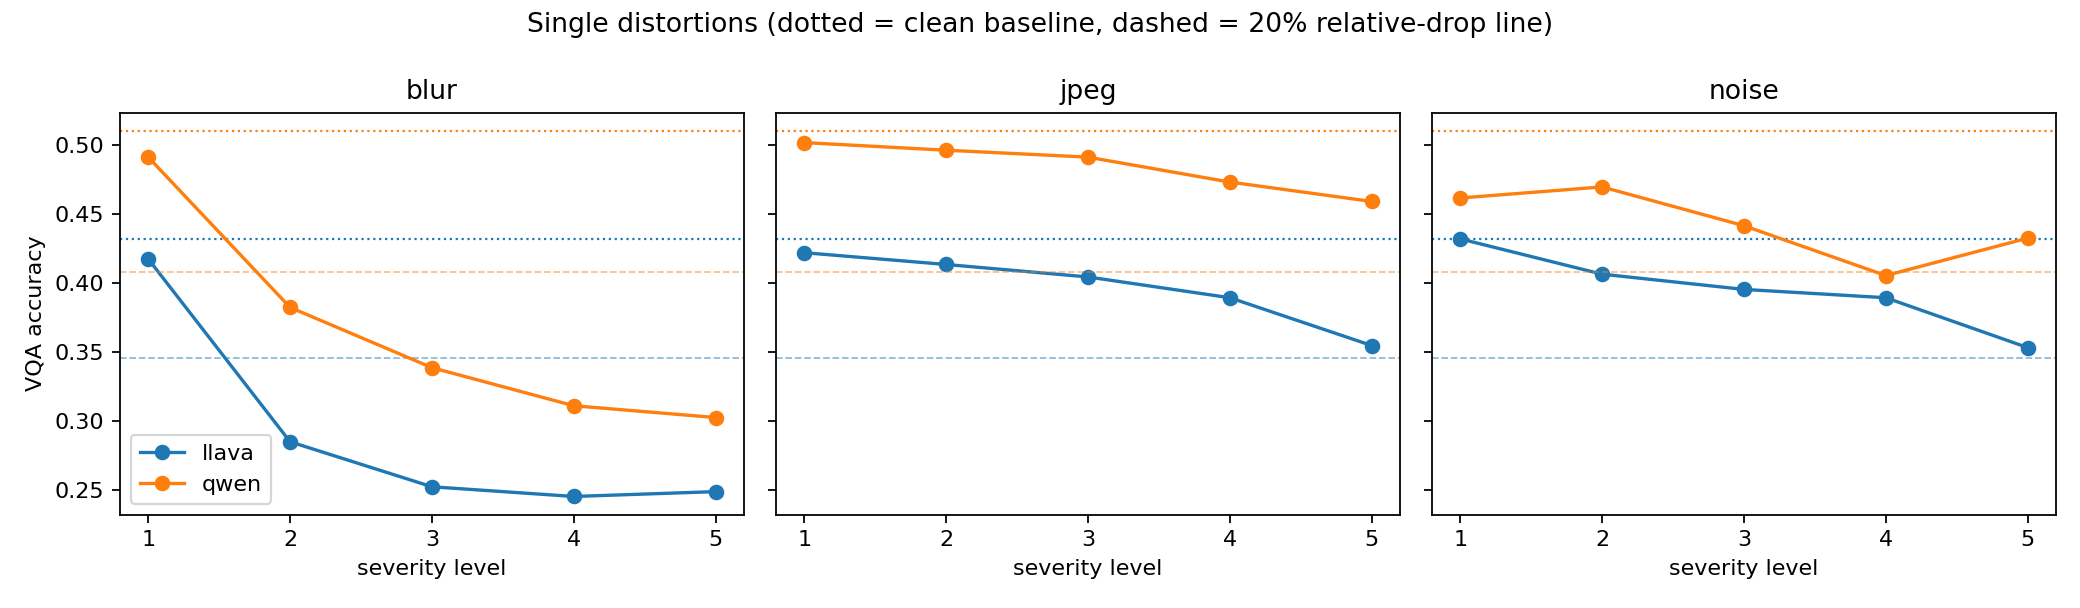

In [21]:
from IPython.display import Image, display
display(Image("/kaggle/working/analysis_ans_lenient/fig1_single_curves.png"))

In [25]:
!pip -q install statsmodels
!mkdir -p /kaggle/working/kit
!find /kaggle/input/datasets/rossierobber/files-for-bug-fixing -name "*.py" -exec cp {} /kaggle/working/kit/ \;
%cd /kaggle/working/kit
D = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant"
!python convert_legacy.py --qwen $D/vizwiz_qwen_batch_0.json --llava $D/vizwiz_llava_batch_0.json --out /kaggle/working/legacy
!python analyze.py --results /kaggle/working/legacy/results_legacy.jsonl --manifest /kaggle/working/legacy/manifest.csv --out /kaggle/working/analysis_ans_lenient --metric lenient --only-answerable

/kaggle/working/kit
qwen: 400 samples from /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_qwen_batch_0.json
llava: 400 samples from /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_llava_batch_0.json

manifest rows: 400
categories (post-hoc): {'Uncategorized': 147, 'Object Identification': 104, 'Text/Label Reading': 142, 'Item Attribute Description': 7}
answerable (approx.): {0: 201, 1: 199}
evaluations that were ERROR strings and were dropped: {}
/kaggle/working/kit/analyze.py:54: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["refusal"] = df["pred"].str.contains(REFUSAL_RE, regex=True)
--only-answerable: kept 199 of 400 images
scored 11144 evaluations | models: ['llava', 'qwen'] | images: 199 | conditions: 28 | primary metric: lenient

How verbose are the predictions? (share of answers longer than 5 words)
model
llava    22.6 %
qwen     

reading /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_qwen_batch_0.json
reading /kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant/vizwiz_llava_batch_0.json
199 questions | metric: lenient | answerable only: True
                  qwen %  llava %
cond                             
clean               51.1     43.2
blur_L1             49.1     41.8
blur_L2             38.2     28.5
blur_L3             33.9     25.2
blur_L4             31.1     24.5
blur_L5             30.3     24.9
jpeg_L1             50.2     42.2
jpeg_L2             49.6     41.4
jpeg_L3             49.1     40.5
jpeg_L4             47.3     38.9
jpeg_L5             45.9     35.5
noise_L1            46.2     43.2
noise_L2            47.0     40.7
noise_L3            44.2     39.5
noise_L4            40.6     38.9
noise_L5            43.3     35.3
blur_L2>jpeg_L2     39.2     28.3
blur_L2>noise_L2    31.4     27.6
jpeg_L2>blur_L2     38.1     28.5
jpeg_L2>noise_L2    46.

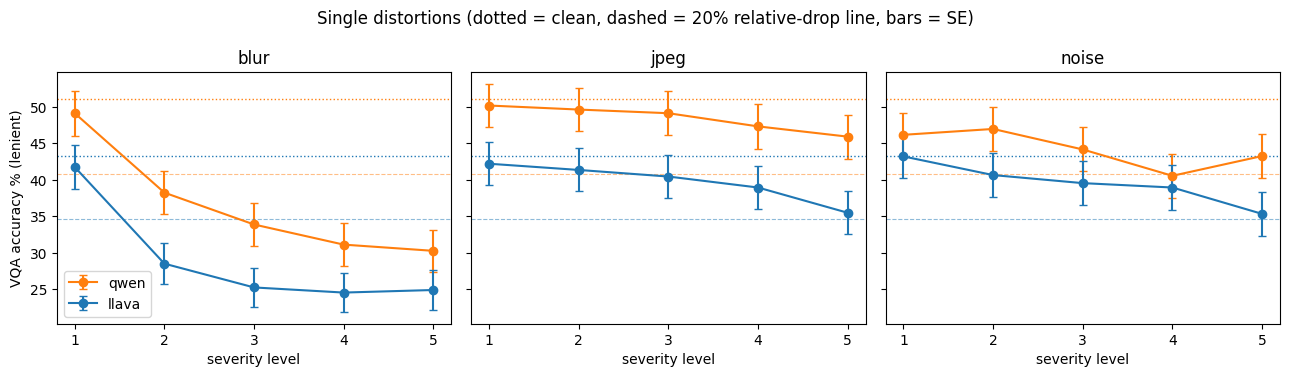

(Figure 2 skipped: set OLD_QWEN and OLD_LLAVA to the first-run JSON files to draw original vs corrected)


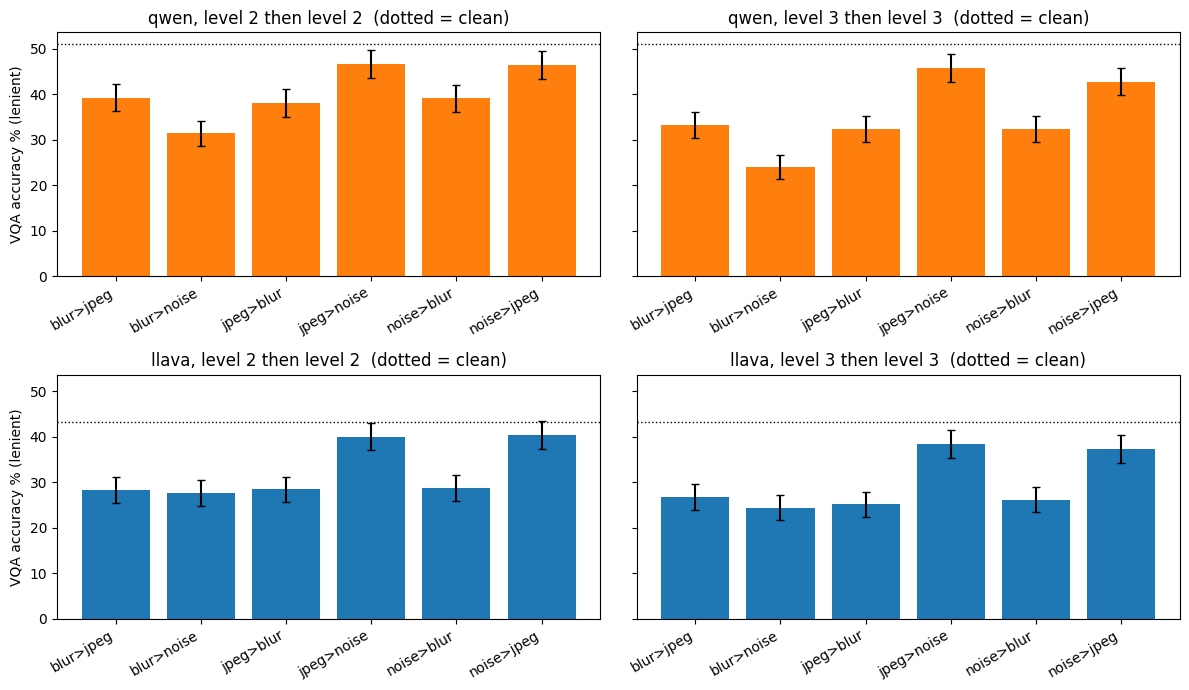

In [27]:
# ==== DYNAMIC plots from YOUR result files. Paste into ONE notebook cell and run. Nothing else is needed. ====
# It reads the two JSON files, scores every prediction with the VQA metric, and draws the figures from that.
# Change a setting below and run again: the figures and numbers update.
import glob, json, os, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ------------------------------- settings -------------------------------
DATA_DIR = "/kaggle/input/datasets/rossierobber/dataset-of-400-images-x-28variant"
QWEN_FILE  = DATA_DIR + "/vizwiz_qwen_batch_0.json"
LLAVA_FILE = DATA_DIR + "/vizwiz_llava_batch_0.json"
METRIC = "lenient"        # "lenient" = reference answer may appear inside a longer reply | "strict" = official exact match
ONLY_ANSWERABLE = True    # keep questions where fewer than 5 of the 10 human answers are "unanswerable"/"unsuitable"
OLD_QWEN, OLD_LLAVA = None, None    # optional: paths of the FIRST-run JSON files -> also draws original-vs-corrected
# ------------------------------------------------------------------------

# ---- official VQA normalisation + accuracy (same code as vqa_metric.py) ----
CONTRACTIONS = dict(p.split("=") for p in "aint=ain't|arent=aren't|cant=can't|couldve=could've|couldnt=couldn't|couldn'tve=couldn't've|couldnt've=couldn't've|didnt=didn't|doesnt=doesn't|dont=don't|hadnt=hadn't|hadnt've=hadn't've|hadn'tve=hadn't've|hasnt=hasn't|havent=haven't|hed=he'd|hed've=he'd've|he'dve=he'd've|hes=he's|howd=how'd|howll=how'll|hows=how's|Id've=I'd've|I'dve=I'd've|Im=I'm|Ive=I've|isnt=isn't|itd=it'd|itd've=it'd've|it'dve=it'd've|itll=it'll|let's=let's|maam=ma'am|mightnt=mightn't|mightnt've=mightn't've|mightn'tve=mightn't've|mightve=might've|mustnt=mustn't|mustve=must've|neednt=needn't|notve=not've|oclock=o'clock|oughtnt=oughtn't|ow's'at='ow's'at|'ows'at='ow's'at|'ow'sat='ow's'at|shant=shan't|shed've=she'd've|she'dve=she'd've|she's=she's|shouldve=should've|shouldnt=shouldn't|shouldnt've=shouldn't've|shouldn'tve=shouldn't've|somebody'd=somebodyd|somebodyd've=somebody'd've|somebody'dve=somebody'd've|somebodyll=somebody'll|somebodys=somebody's|someoned=someone'd|someoned've=someone'd've|someone'dve=someone'd've|someonell=someone'll|someones=someone's|somethingd=something'd|somethingd've=something'd've|something'dve=something'd've|somethingll=something'll|thats=that's|thered=there'd|thered've=there'd've|there'dve=there'd've|therere=there're|theres=there's|theyd=they'd|theyd've=they'd've|they'dve=they'd've|theyll=they'll|theyre=they're|theyve=they've|twas='twas|wasnt=wasn't|wed've=we'd've|we'dve=we'd've|weve=we've|werent=weren't|whatll=what'll|whatre=what're|whats=what's|whatve=what've|whens=when's|whered=where'd|wheres=where's|whereve=where've|whod=who'd|whod've=who'd've|who'dve=who'd've|wholl=who'll|whos=who's|whove=who've|whyll=why'll|whyre=why're|whys=why's|wont=won't|wouldve=would've|wouldnt=wouldn't|wouldnt've=wouldn't've|wouldn'tve=wouldn't've|yall=y'all|yall'll=y'all'll|y'allll=y'all'll|yall'd've=y'all'd've|y'alld've=y'all'd've|y'all'dve=y'all'd've|youd=you'd|youd've=you'd've|you'dve=you'd've|youll=you'll|youre=you're|youve=you've".split("|"))
MANUAL_MAP = {"none": "0", "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4",
              "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9", "ten": "10"}
ARTICLES = ["a", "an", "the"]
PERIOD_STRIP = re.compile(r"(?!<=\d)(\.)(?!\d)")
COMMA_STRIP = re.compile(r"(\d)(\,)(\d)")
PUNCT = [";", r"/", "[", "]", '"', "{", "}", "(", ")", "=", "+", "\\", "_", "-",
         ">", "<", "@", "`", ",", "?", "!"]


def process_punctuation(text):
    out = text
    for p in PUNCT:
        if (p + " " in text or " " + p in text) or (re.search(COMMA_STRIP, text) is not None):
            out = out.replace(p, "")
        else:
            out = out.replace(p, " ")
    return PERIOD_STRIP.sub("", out)


def process_digit_article(text):
    words = []
    for w in text.lower().split():
        w = MANUAL_MAP.setdefault(w, w)
        if w not in ARTICLES:
            words.append(w)
    words = [CONTRACTIONS.get(w, w) for w in words]
    return " ".join(words)


def normalize(text):
    text = str(text).replace("\n", " ").replace("\t", " ").strip()
    return process_digit_article(process_punctuation(text))


def _contains(pred_norm, ref_norm):
    """Whole-word/phrase containment (NOT raw substring: 'no' does not match 'nothing' or 'unknown')."""
    if not ref_norm:
        return False
    return re.search(r"(?<!\w)" + re.escape(ref_norm) + r"(?!\w)", pred_norm) is not None


def vqa_accuracy(prediction, references, mode="strict"):
    """
    prediction: str. references: list of the human answer strings (normally 10).
    mode="strict"  : official metric -- normalised prediction must EQUAL a reference answer.
    mode="lenient" : same leave-one-annotator-out formula, but a reference counts as a match if it appears
                     as a whole word/phrase inside the normalised prediction (forgives 'It is cola.' vs 'cola').
    """
    pred = normalize(prediction)
    refs = [normalize(r) for r in references]
    n = len(refs)
    if n == 0:
        return 0.0
    hit = (lambda r: r == pred) if mode == "strict" else (lambda r: _contains(pred, r))
    is_hit = [hit(r) for r in refs]
    total = sum(is_hit)
    accs = []
    for i in range(n):
        matches = total - (1 if is_hit[i] else 0)      # matches among the OTHER n-1 answers
        accs.append(min(1.0, matches / 3.0))
    return sum(accs) / n


# ---- reading + scoring ----
OPS = ["blur", "jpeg", "noise"]
def tidy(raw):
    """single_blur_lvl3 -> blur_L3 ; compound_blur2_jpeg2 -> blur_L2>jpeg_L2 ; clean -> clean"""
    if raw == "clean": return raw
    p = raw.split("_")
    if p[0] == "single": return f"{p[1]}_L{p[2].replace('lvl', '')}"
    (a, la), (b, lb) = [re.match(r"([a-z]+)(\d)", x).groups() for x in p[1:3]]
    return f"{a}_L{la}>{b}_L{lb}"

def load(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Files nearby: {glob.glob(os.path.dirname(path) + '/*.json')}")
    print("reading", path)
    out = {}
    for s in json.load(open(path, encoding="utf-8")):
        gt = [str(a["answer"] if isinstance(a, dict) else a) for a in s["ground_truth_answers"]]
        out[s["sample_id"]] = (gt, {tidy(c): p for c, p in s["evaluations"].items() if isinstance(p, str) and not p.startswith("ERROR:")})
    return out

def is_answerable(gt):
    return len(gt) == 10 and sum(a.strip().lower() in ("unanswerable", "unsuitable") for a in gt) < 5

def score(data, ids):
    rows = [(sid, c, vqa_accuracy(p, data[sid][0], METRIC)) for sid in ids for c, p in data[sid][1].items()]
    return pd.DataFrame(rows, columns=["sid", "cond", "acc"])

DATA = {"qwen": load(QWEN_FILE), "llava": load(LLAVA_FILE)}
ids = sorted(set(DATA["qwen"]) & set(DATA["llava"]))
if ONLY_ANSWERABLE:
    ids = [i for i in ids if is_answerable(DATA["qwen"][i][0])]
print(f"{len(ids)} questions | metric: {METRIC} | answerable only: {ONLY_ANSWERABLE}")

SC = {m: score(DATA[m], ids) for m in DATA}                                   # every prediction scored
ST = {m: SC[m].groupby("cond").acc.agg(["mean", "sem"]) * 100 for m in SC}    # mean and standard error per condition
COND_ORDER = ["clean"] + [f"{o}_L{l}" for o in OPS for l in range(1, 6)] + \
             [f"{a}_L{L}>{b}_L{L}" for L in (2, 3) for a in OPS for b in OPS if a != b]
TABLE = pd.DataFrame({f"{m} %": ST[m]["mean"].reindex(COND_ORDER).round(1) for m in ST})
print(TABLE.to_string())

COL = {"qwen": "tab:orange", "llava": "tab:blue"}
LV = list(range(1, 6))

# ---- Figure 1: single distortions (error bars = standard error over questions) ----
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, op in zip(axes, OPS):
    for m in ST:
        mean = [ST[m].loc[f"{op}_L{l}", "mean"] for l in LV]
        sem = [ST[m].loc[f"{op}_L{l}", "sem"] for l in LV]
        ax.errorbar(LV, mean, yerr=sem, marker="o", capsize=3, color=COL[m], label=m)
        clean = ST[m].loc["clean", "mean"]
        ax.axhline(clean, ls=":", color=COL[m], lw=1)
        ax.axhline(0.8 * clean, ls="--", color=COL[m], lw=.8, alpha=.5)
    ax.set_title(op); ax.set_xlabel("severity level"); ax.set_xticks(LV)
axes[0].set_ylabel(f"VQA accuracy % ({METRIC})"); axes[0].legend()
fig.suptitle("Single distortions (dotted = clean, dashed = 20% relative-drop line, bars = SE)")
plt.tight_layout(); plt.show()

# ---- Figure 2: original vs corrected pipeline (only if the first-run files are given) ----
if OLD_QWEN and OLD_LLAVA:
    OLD = {"qwen": load(OLD_QWEN), "llava": load(OLD_LLAVA)}
    STO = {m: score(OLD[m], ids).groupby("cond").acc.mean() * 100 for m in OLD}
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey="row")
    for r, m in enumerate(("qwen", "llava")):
        for k, op in enumerate(OPS):
            ax = axes[r][k]
            for tab, ls, color, label in ((STO[m], "--", "tab:gray", "original pipeline"),
                                          (ST[m]["mean"], "-", "tab:red", "corrected pipeline")):
                ax.plot(LV, [tab[f"{op}_L{l}"] for l in LV], ls, marker="o", color=color, label=label)
                ax.axhline(tab["clean"], ls=":", color=color, lw=1)
            ax.set_title(f"{m}: {op}"); ax.set_xticks(LV)
            if r == 1: ax.set_xlabel("severity level")
            if k == 0: ax.set_ylabel(f"VQA accuracy % ({METRIC})")
    axes[0][0].legend(); plt.tight_layout(); plt.show()
else:
    print("(Figure 2 skipped: set OLD_QWEN and OLD_LLAVA to the first-run JSON files to draw original vs corrected)")

# ---- Figure 3: compound distortions (first > second) ----
pairs = [(a, b) for a in OPS for b in OPS if a != b]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for r, m in enumerate(("qwen", "llava")):
    for k, L in enumerate((2, 3)):
        ax = axes[r][k]
        ys = [ST[m].loc[f"{a}_L{L}>{b}_L{L}", "mean"] for a, b in pairs]
        es = [ST[m].loc[f"{a}_L{L}>{b}_L{L}", "sem"] for a, b in pairs]
        ax.bar(range(6), ys, yerr=es, capsize=3, color=COL[m])
        ax.axhline(ST[m].loc["clean", "mean"], ls=":", color="k", lw=1)
        ax.set_xticks(range(6)); ax.set_xticklabels([f"{a}>{b}" for a, b in pairs], rotation=30, ha="right")
        ax.set_title(f"{m}, level {L} then level {L}  (dotted = clean)")
axes[0][0].set_ylabel(f"VQA accuracy % ({METRIC})"); axes[1][0].set_ylabel(f"VQA accuracy % ({METRIC})")
plt.tight_layout(); plt.show()